# Cluster Asset Impact Analysis Pipeline_hdbscan

This notebook combines HDBSCAN v11 cluster standardization and the current v2 asset impact analysis into one runnable pipeline.

## Purpose
- start from a model-specific cluster output table coming directly from a clustering notebook
- standardize that output into a reusable cluster-membership table with `developer_id`, `cluster_id`, and `cluster_label`
- join the standardized cluster-membership table back to `dev_profile_final_v4`
- summarize every currently surfaced asset and asset-adjacent signal by cluster
- compare exposed vs not exposed developers within each cluster for each signal
- keep the workflow fast and reproducible before attempting the heavier event-time version

## How To Use This Notebook
Run `clustering_v11_hdbscan_main_rule_dormant_skip_existing.ipynb` first so `dev_lifecycle_cluster_membership_v11_final` exists in DuckDB.
2. In the parameter cell, set `SOURCE_TABLE` to that model output table.
3. Set `ID_COL` to the developer id column and `CLUSTER_ID_COL` to the cluster id column from the source table.
4. If your source table already has human-readable labels, set `CLUSTER_LABEL_COL` to that column name. If not, set it to `None` and this notebook will create labels as `cluster_<cluster_id>`.
5. Set `OUTPUT_TABLE` to the standardized membership table you want to create.
6. Run the notebook top to bottom. The downstream impact analysis will automatically use the standardized output table.

## Standardized Output Schema
- `developer_id`
- `cluster_id`
- `cluster_label`

## Input assumptions
Source cluster table:
- one row per developer coming from a cluster modeling notebook
- includes a developer id column and a cluster id column
- may optionally include a cluster label column

Profile table:
- one row per developer in `dev_profile_final_v4`
- developer-level aggregated activity, persona, journey, dormancy, and effort fields


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option('display.max_colwidth', 120)
plt.style.use('ggplot')

## 1. Parameters

In [2]:
DB_PATH = 'developer_project.duckdb'

# Source cluster table produced by a model-specific notebook.
SOURCE_TABLE = 'dev_lifecycle_cluster_membership_v11_final'

# Standardized cluster-membership table created by this pipeline.
OUTPUT_TABLE = 'cluster_membership_hdbscan_v11'

# Source column mappings.
ID_COL = 'developer_id'
CLUSTER_ID_COL = 'cluster_key'
CLUSTER_LABEL_COL = None  # Source uses cluster_key; standardized labels will be generated.

# Downstream analysis reads from the standardized output table.
CLUSTER_TABLE = OUTPUT_TABLE
PROFILE_TABLE = 'dev_profile_final_v4'

CLUSTER_PROFILE_TABLE = 'cluster_profile_asset_base_v2'
CLUSTER_ASSET_CATALOG_TABLE = 'cluster_asset_catalog_v2'
CLUSTER_ASSET_LONG_TABLE = 'cluster_asset_long_v2'
CLUSTER_ASSET_SUMMARY_TABLE = 'cluster_asset_summary_v2'
CLUSTER_ASSET_EXPOSURE_TABLE = 'cluster_asset_exposure_by_cluster_v2'
CLUSTER_EXPOSED_OUTCOME_TABLE = 'cluster_asset_outcomes_exposed_v2'
CLUSTER_ASSET_INTENSITY_TABLE = 'cluster_asset_intensity_by_cluster_v2'
CLUSTER_ASSET_EXPOSED_PROFILE_TABLE = 'cluster_asset_exposed_profile_v2'
CLUSTER_ASSET_PRIORITY_TABLE = 'cluster_asset_priority_by_cluster_v2'
CLUSTER_PERSONA_PROFILE_TABLE = 'cluster_persona_profile_v2'
CLUSTER_JOURNEY_PROFILE_TABLE = 'cluster_journey_profile_v2'
CLUSTER_JOURNEY_STATE_PROFILE_TABLE = 'cluster_journey_state_profile_v2'
CLUSTER_LIFECYCLE_PROFILE_TABLE = 'cluster_lifecycle_profile_v2'
CLUSTER_DORMANCY_PROFILE_TABLE = 'cluster_dormancy_profile_v2'
CLUSTER_EFFORT_PROFILE_TABLE = 'cluster_effort_profile_v2'
CLUSTER_ACTIVITY_DEBUG_TABLE = 'cluster_recent_activity_debug_v2'

MIN_EXPOSED_DEVELOPERS = 100


## 2. Connect And Validate Source/Profile Inputs


In [3]:
con = duckdb.connect(DB_PATH)

available_tables = set(con.execute('SHOW TABLES').fetchdf()['name'].tolist())
required_tables = [SOURCE_TABLE, PROFILE_TABLE]
missing_tables = [t for t in required_tables if t not in available_tables]
if missing_tables:
    raise ValueError(f'Missing required tables: {missing_tables}')

source_cols = con.execute(f"PRAGMA table_info({SOURCE_TABLE})").fetchdf()['name'].tolist()
required_source_cols = [ID_COL, CLUSTER_ID_COL]
missing_source_cols = [c for c in required_source_cols if c not in source_cols]
if missing_source_cols:
    raise ValueError(f'Missing required source columns in {SOURCE_TABLE}: {missing_source_cols}')

if CLUSTER_LABEL_COL is not None and CLUSTER_LABEL_COL not in source_cols:
    raise ValueError(f'CLUSTER_LABEL_COL={CLUSTER_LABEL_COL!r} not found in {SOURCE_TABLE}')

profile_cols = con.execute(f"PRAGMA table_info({PROFILE_TABLE})").fetchdf()['name'].tolist()

display(pd.DataFrame({'required_table': required_tables}))
print(f'Source table: {SOURCE_TABLE}')
print('Source columns available:', len(source_cols))
print(f'Profile table: {PROFILE_TABLE}')
print('Profile columns available:', len(profile_cols))
display(pd.DataFrame({'source_column': source_cols}))

display(Markdown('### Source Sample Rows'))
source_preview_cols = [c for c in [ID_COL, CLUSTER_ID_COL] + ([CLUSTER_LABEL_COL] if CLUSTER_LABEL_COL is not None else []) if c in source_cols]
display(con.execute(f"SELECT {', '.join(source_preview_cols)} FROM {SOURCE_TABLE} LIMIT 10").fetchdf())

display(Markdown('### Source Cluster Counts Preview'))
display(con.execute(f"SELECT {CLUSTER_ID_COL} AS source_cluster_id, COUNT(*) AS developers FROM {SOURCE_TABLE} GROUP BY 1 ORDER BY developers DESC, source_cluster_id LIMIT 20").fetchdf())


,required_table
0,dev_lifecycle_cluster_membership_v11_final
1,dev_profile_final_v4


Source table: dev_lifecycle_cluster_membership_v11_final
Source columns available: 10
Profile table: dev_profile_final_v4
Profile columns available: 145


,source_column
0,developer_id
1,stratum
2,hdbscan_cluster
3,cluster_probability
4,outlier_score
5,cluster_key
6,adoption_direction
7,proposed_business_label
8,interpretation_notes
9,recommended_action


### Source Sample Rows

,developer_id,cluster_key
0,10298028,active_2
1,10377454,active_2
2,9988724,active_3
3,10468700,active_2
4,10373059,active_2
5,10548540,active_2
6,9467742,active_2
7,10310334,active_2
8,10254134,active_2
9,10528815,active_2


### Source Cluster Counts Preview

,source_cluster_id,developers
0,Dormant_Low_Depth,2466341
1,unactivated,1718912
2,Dormant_Former_Builders,1662813
3,Dormant_One_Time_Users,1175698
4,at_risk_0,436278
5,at_risk_5,366453
6,at_risk_2,210376
7,at_risk_3,206877
8,active_5,155153
9,at_risk_1,145076


## 3. Build Standardized Cluster Membership Table


In [5]:
if CLUSTER_LABEL_COL is None:
    standardize_sql = f"""
    CREATE OR REPLACE TABLE {OUTPUT_TABLE} AS
    SELECT
        {ID_COL} AS developer_id,
        {CLUSTER_ID_COL} AS cluster_id,
        'cluster_' || CAST({CLUSTER_ID_COL} AS VARCHAR) AS cluster_label
    FROM {SOURCE_TABLE}
    """
else:
    standardize_sql = f"""
    CREATE OR REPLACE TABLE {OUTPUT_TABLE} AS
    SELECT
        {ID_COL} AS developer_id,
        {CLUSTER_ID_COL} AS cluster_id,
        {CLUSTER_LABEL_COL} AS cluster_label
    FROM {SOURCE_TABLE}
    """

print(standardize_sql)
con.execute(standardize_sql)
print(f'Created standardized table: {OUTPUT_TABLE}')



    CREATE OR REPLACE TABLE cluster_membership_hdbscan_v11 AS
    SELECT
        developer_id AS developer_id,
        cluster_key AS cluster_id,
        'cluster_' || CAST(cluster_key AS VARCHAR) AS cluster_label
    FROM dev_lifecycle_cluster_membership_v11_final
    
Created standardized table: cluster_membership_hdbscan_v11


## 4. Validate Standardized Cluster Table


In [6]:
cluster_cols = con.execute(f"PRAGMA table_info({CLUSTER_TABLE})").fetchdf()['name'].tolist()
required_cluster_cols = ['developer_id', 'cluster_id', 'cluster_label']
missing_cluster_cols = [c for c in required_cluster_cols if c not in cluster_cols]
if missing_cluster_cols:
    raise ValueError(f'{CLUSTER_TABLE} is missing required columns: {missing_cluster_cols}')

display(Markdown('### Standardized Row Count'))
display(con.execute(f'SELECT COUNT(*) AS n_rows FROM {CLUSTER_TABLE}').fetchdf())

display(Markdown('### Standardized Null Check'))
display(con.execute(f"""
SELECT
    SUM(CASE WHEN developer_id IS NULL THEN 1 ELSE 0 END) AS null_developer_id,
    SUM(CASE WHEN cluster_id IS NULL THEN 1 ELSE 0 END) AS null_cluster_id,
    SUM(CASE WHEN cluster_label IS NULL THEN 1 ELSE 0 END) AS null_cluster_label
FROM {CLUSTER_TABLE}
""").fetchdf())

display(Markdown('### Output Sample Rows'))
display(con.execute(f'SELECT * FROM {CLUSTER_TABLE} LIMIT 10').fetchdf())

display(Markdown('### Output Cluster Counts'))
display(con.execute(f"""
SELECT cluster_label, COUNT(*) AS developers
FROM {CLUSTER_TABLE}
GROUP BY 1
ORDER BY developers DESC, cluster_label
""").fetchdf())

profile_cols = con.execute(f"PRAGMA table_info({PROFILE_TABLE})").fetchdf()['name'].tolist()
print('Standardized cluster table columns:', cluster_cols)
print('Profile table columns:', len(profile_cols))


### Standardized Row Count

,n_rows
0,9379190


### Standardized Null Check

,null_developer_id,null_cluster_id,null_cluster_label
0,0.0,0.0,0.0


### Output Sample Rows

,developer_id,cluster_id,cluster_label
0,10298028,active_2,cluster_active_2
1,10377454,active_2,cluster_active_2
2,9988724,active_3,cluster_active_3
3,10468700,active_2,cluster_active_2
4,10373059,active_2,cluster_active_2
5,10548540,active_2,cluster_active_2
6,9467742,active_2,cluster_active_2
7,10310334,active_2,cluster_active_2
8,10254134,active_2,cluster_active_2
9,10528815,active_2,cluster_active_2


### Output Cluster Counts

,cluster_label,developers
0,cluster_Dormant_Low_Depth,2466341
1,cluster_unactivated,1718912
2,cluster_Dormant_Former_Builders,1662813
3,cluster_Dormant_One_Time_Users,1175698
4,cluster_at_risk_0,436278
5,cluster_at_risk_5,366453
6,cluster_at_risk_2,210376
7,cluster_at_risk_3,206877
8,cluster_active_5,155153
9,cluster_at_risk_1,145076


Standardized cluster table columns: ['developer_id', 'cluster_id', 'cluster_label']
Profile table columns: 145


## 5. Build Asset Catalog

These are the currently available asset and asset-adjacent signals already surfaced in `dev_profile_final_v4`.

Transformed helper columns are intentionally excluded so this notebook stays focused on interpretable underlying signals.

In [7]:
def col_exists(col):
    return col in profile_cols

asset_catalog = [
    {'asset_name': 'dli_training', 'column_name': 'lifetime_dli_training_count', 'asset_group': 'activity_asset', 'asset_role': 'learning_activity', 'signal_type': 'count', 'analysis_role': 'rankable_activity_asset'},
    {'asset_name': 'webinar', 'column_name': 'lifetime_webinar_count', 'asset_group': 'activity_asset', 'asset_role': 'learning_activity', 'signal_type': 'count', 'analysis_role': 'rankable_activity_asset'},
    {'asset_name': 'devzone_download', 'column_name': 'lifetime_devzone_download_count', 'asset_group': 'activity_asset', 'asset_role': 'download_activity', 'signal_type': 'count', 'analysis_role': 'rankable_activity_asset'},
    {'asset_name': 'ngc_download', 'column_name': 'lifetime_ngc_download_count', 'asset_group': 'activity_asset', 'asset_role': 'download_activity', 'signal_type': 'count', 'analysis_role': 'rankable_activity_asset'},
    {'asset_name': 'forum_contribution', 'column_name': 'lifetime_forum_count', 'asset_group': 'activity_asset', 'asset_role': 'community_activity', 'signal_type': 'count', 'analysis_role': 'rankable_activity_asset'},
    {'asset_name': 'bug_filed', 'column_name': 'lifetime_bug_count', 'asset_group': 'activity_asset', 'asset_role': 'community_activity', 'signal_type': 'count', 'analysis_role': 'rankable_activity_asset'},
    {'asset_name': 'hackathon', 'column_name': 'lifetime_hackathon_count', 'asset_group': 'activity_asset', 'asset_role': 'community_activity', 'signal_type': 'count', 'analysis_role': 'rankable_activity_asset'},
    {'asset_name': 'api_usage', 'column_name': 'lifetime_api_count', 'asset_group': 'outcome_signal', 'asset_role': 'product_adoption', 'signal_type': 'count', 'analysis_role': 'likely_outcome'},
    {'asset_name': 'discover_count', 'column_name': 'lifetime_discover_count', 'asset_group': 'cluster_descriptor', 'asset_role': 'journey_descriptor', 'signal_type': 'count', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'learn_count', 'column_name': 'lifetime_learn_count', 'asset_group': 'cluster_descriptor', 'asset_role': 'journey_descriptor', 'signal_type': 'count', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'evaluate_count', 'column_name': 'lifetime_evaluate_count', 'asset_group': 'cluster_descriptor', 'asset_role': 'journey_descriptor', 'signal_type': 'count', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'build_count_lifetime', 'column_name': 'lifetime_build_count', 'asset_group': 'cluster_descriptor', 'asset_role': 'journey_descriptor', 'signal_type': 'count', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'champion_count_lifetime', 'column_name': 'lifetime_champion_count', 'asset_group': 'cluster_descriptor', 'asset_role': 'journey_descriptor', 'signal_type': 'count', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'build_count_0_30d', 'column_name': 'build_count_0_30d', 'asset_group': 'cluster_descriptor', 'asset_role': 'recent_behavior_descriptor', 'signal_type': 'count', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'build_count_30_90d', 'column_name': 'build_count_30_90d', 'asset_group': 'cluster_descriptor', 'asset_role': 'recent_behavior_descriptor', 'signal_type': 'count', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'build_count_90_180d', 'column_name': 'build_count_90_180d', 'asset_group': 'cluster_descriptor', 'asset_role': 'recent_behavior_descriptor', 'signal_type': 'count', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'build_share_0_30d', 'column_name': 'build_share_0_30d', 'asset_group': 'cluster_descriptor', 'asset_role': 'recent_behavior_descriptor', 'signal_type': 'rate', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'build_velocity_0_30_vs_30_90', 'column_name': 'build_velocity_0_30_vs_30_90', 'asset_group': 'cluster_descriptor', 'asset_role': 'recent_behavior_descriptor', 'signal_type': 'rate', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'weighted_recent_build', 'column_name': 'weighted_recent_build', 'asset_group': 'cluster_descriptor', 'asset_role': 'recent_behavior_descriptor', 'signal_type': 'count', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'active_non_builder_0_30d', 'column_name': 'active_non_builder_0_30d', 'asset_group': 'cluster_descriptor', 'asset_role': 'recent_behavior_descriptor', 'signal_type': 'binary', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'low_volume_builder_0_30d', 'column_name': 'low_volume_builder_0_30d', 'asset_group': 'cluster_descriptor', 'asset_role': 'recent_behavior_descriptor', 'signal_type': 'binary', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'recent_build_flag', 'column_name': 'recent_build_flag', 'asset_group': 'cluster_descriptor', 'asset_role': 'recent_behavior_descriptor', 'signal_type': 'binary', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'recent_champion_flag', 'column_name': 'recent_champion_flag', 'asset_group': 'cluster_descriptor', 'asset_role': 'recent_behavior_descriptor', 'signal_type': 'binary', 'analysis_role': 'cluster_behavior_descriptor'}
]

available_assets = [asset for asset in asset_catalog if col_exists(asset['column_name'])]
missing_assets = [asset['column_name'] for asset in asset_catalog if not col_exists(asset['column_name'])]

if not available_assets:
    raise ValueError('No asset-related columns from the catalog were found in dev_profile_final_v4')

asset_catalog_df = pd.DataFrame(available_assets)
display(asset_catalog_df)
print('Asset rows in scope:', len(asset_catalog_df))
if missing_assets:
    print('Catalog columns not present in profile table:', missing_assets)

,asset_name,column_name,asset_group,asset_role,signal_type,analysis_role
0,dli_training,lifetime_dli_training_count,activity_asset,learning_activity,count,rankable_activity_asset
1,webinar,lifetime_webinar_count,activity_asset,learning_activity,count,rankable_activity_asset
2,devzone_download,lifetime_devzone_download_count,activity_asset,download_activity,count,rankable_activity_asset
3,ngc_download,lifetime_ngc_download_count,activity_asset,download_activity,count,rankable_activity_asset
4,forum_contribution,lifetime_forum_count,activity_asset,community_activity,count,rankable_activity_asset
5,bug_filed,lifetime_bug_count,activity_asset,community_activity,count,rankable_activity_asset
6,hackathon,lifetime_hackathon_count,activity_asset,community_activity,count,rankable_activity_asset
7,api_usage,lifetime_api_count,outcome_signal,product_adoption,count,likely_outcome
8,discover_count,lifetime_discover_count,cluster_descriptor,journey_descriptor,count,cluster_behavior_descriptor
9,learn_count,lifetime_learn_count,cluster_descriptor,journey_descriptor,count,cluster_behavior_descriptor


Asset rows in scope: 23


## 6. Build Base Cluster-Profile Table And Long Asset Table

In [8]:
base_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_PROFILE_TABLE} AS
SELECT
    c.developer_id,
    c.cluster_id,
    c.cluster_label,
    p.*
FROM {CLUSTER_TABLE} c
JOIN {PROFILE_TABLE} p USING (developer_id)
"""

con.execute(base_sql)
con.register('asset_catalog_df_view', asset_catalog_df)
con.execute(f'CREATE OR REPLACE TABLE {CLUSTER_ASSET_CATALOG_TABLE} AS SELECT * FROM asset_catalog_df_view')

asset_selects = []
for asset in available_assets:
    column_name = asset['column_name']
    asset_selects.append(f"""
    SELECT
        developer_id,
        cluster_id,
        cluster_label,
        '{asset['asset_name']}' AS asset_name,
        '{asset['asset_group']}' AS asset_group,
        '{asset['asset_role']}' AS asset_role,
        '{asset['analysis_role']}' AS analysis_role,
        '{asset['signal_type']}' AS signal_type,
        '{column_name}' AS source_column,
        COALESCE(CAST({column_name} AS DOUBLE), 0.0) AS exposure_value,
        CASE WHEN COALESCE(CAST({column_name} AS DOUBLE), 0.0) > 0 THEN 1 ELSE 0 END AS exposed_flag
    FROM {CLUSTER_PROFILE_TABLE}
    """)

long_asset_sql = f"CREATE OR REPLACE TABLE {CLUSTER_ASSET_LONG_TABLE} AS\n" + "\nUNION ALL\n".join(asset_selects)
con.execute(long_asset_sql)

display(con.execute(f'SELECT COUNT(*) AS n_rows, COUNT(DISTINCT developer_id) AS distinct_developers FROM {CLUSTER_PROFILE_TABLE}').fetchdf())
display(con.execute(f'SELECT COUNT(*) AS asset_rows, COUNT(DISTINCT asset_name) AS distinct_assets FROM {CLUSTER_ASSET_LONG_TABLE}').fetchdf())
display(con.execute(f'SELECT * FROM {CLUSTER_ASSET_LONG_TABLE} ORDER BY cluster_label, asset_group, asset_name LIMIT 10').fetchdf())

,n_rows,distinct_developers
0,9379190,9379190


,asset_rows,distinct_assets
0,215721370,23


,developer_id,cluster_id,cluster_label,asset_name,asset_group,asset_role,analysis_role,signal_type,source_column,exposure_value,exposed_flag
0,446717,Dormant_Former_Builders,cluster_Dormant_Former_Builders,bug_filed,activity_asset,community_activity,rankable_activity_asset,count,lifetime_bug_count,0.0,0
1,6724406,Dormant_Former_Builders,cluster_Dormant_Former_Builders,bug_filed,activity_asset,community_activity,rankable_activity_asset,count,lifetime_bug_count,0.0,0
2,3127921,Dormant_Former_Builders,cluster_Dormant_Former_Builders,bug_filed,activity_asset,community_activity,rankable_activity_asset,count,lifetime_bug_count,0.0,0
3,3032086,Dormant_Former_Builders,cluster_Dormant_Former_Builders,bug_filed,activity_asset,community_activity,rankable_activity_asset,count,lifetime_bug_count,0.0,0
4,8090257,Dormant_Former_Builders,cluster_Dormant_Former_Builders,bug_filed,activity_asset,community_activity,rankable_activity_asset,count,lifetime_bug_count,0.0,0
5,3224086,Dormant_Former_Builders,cluster_Dormant_Former_Builders,bug_filed,activity_asset,community_activity,rankable_activity_asset,count,lifetime_bug_count,0.0,0
6,2914393,Dormant_Former_Builders,cluster_Dormant_Former_Builders,bug_filed,activity_asset,community_activity,rankable_activity_asset,count,lifetime_bug_count,0.0,0
7,3854994,Dormant_Former_Builders,cluster_Dormant_Former_Builders,bug_filed,activity_asset,community_activity,rankable_activity_asset,count,lifetime_bug_count,0.0,0
8,6112801,Dormant_Former_Builders,cluster_Dormant_Former_Builders,bug_filed,activity_asset,community_activity,rankable_activity_asset,count,lifetime_bug_count,0.0,0
9,5056928,Dormant_Former_Builders,cluster_Dormant_Former_Builders,bug_filed,activity_asset,community_activity,rankable_activity_asset,count,lifetime_bug_count,0.0,0


## 7. Cluster Size And Signal Coverage Summary

In [9]:
summary_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_ASSET_SUMMARY_TABLE} AS
WITH per_dev_asset_counts AS (
    SELECT
        developer_id,
        cluster_label,
        SUM(CASE WHEN analysis_role = 'rankable_activity_asset' THEN exposed_flag ELSE 0 END) AS rankable_activity_assets_exposed,
        SUM(CASE WHEN analysis_role = 'cluster_behavior_descriptor' THEN exposed_flag ELSE 0 END) AS behavior_descriptors_active,
        SUM(CASE WHEN analysis_role = 'likely_outcome' THEN exposed_flag ELSE 0 END) AS likely_outcomes_active
    FROM {CLUSTER_ASSET_LONG_TABLE}
    GROUP BY 1,2
)
SELECT
    b.cluster_label,
    COUNT(*) AS developers,
    AVG(a.rankable_activity_assets_exposed) AS avg_rankable_activity_assets_exposed,
    AVG(a.behavior_descriptors_active) AS avg_behavior_descriptors_active,
    AVG(a.likely_outcomes_active) AS avg_likely_outcomes_active,
    AVG(b.activity_count_0_30d) AS avg_activity_count_0_30d,
    AVG(b.activity_count_30_90d) AS avg_activity_count_30_90d,
    AVG(b.activity_count_90_180d) AS avg_activity_count_90_180d,
    MEDIAN(b.activity_count_0_30d) AS median_activity_count_0_30d,
    AVG(b.high_effort_count_0_30d) AS avg_high_effort_count_0_30d,
    MEDIAN(b.high_effort_count_0_30d) AS median_high_effort_count_0_30d,
    AVG(CASE WHEN b.activity_count_0_30d > 0 THEN 1.0 ELSE 0.0 END) AS pct_any_activity_0_30d,
    AVG(CASE WHEN b.activity_count_30_90d > 0 THEN 1.0 ELSE 0.0 END) AS pct_any_activity_30_90d,
    AVG(CASE WHEN b.activity_count_90_180d > 0 THEN 1.0 ELSE 0.0 END) AS pct_any_activity_90_180d,
    AVG(CASE WHEN b.dormancy_status = 'Active' THEN 1.0 ELSE 0.0 END) AS pct_active,
    AVG(CASE WHEN b.dormancy_status = 'At_Risk' THEN 1.0 ELSE 0.0 END) AS pct_at_risk,
    AVG(CASE WHEN b.dormancy_status = 'Cooling' THEN 1.0 ELSE 0.0 END) AS pct_cooling,
    AVG(CASE WHEN b.dormancy_status = 'Dormant' THEN 1.0 ELSE 0.0 END) AS pct_dormant,
    AVG(CASE WHEN b.behavior_journey_stage_30d = 'Builder' THEN 1.0 ELSE 0.0 END) AS pct_builder,
    AVG(CASE WHEN b.behavior_journey_stage_30d = 'Evaluator' THEN 1.0 ELSE 0.0 END) AS pct_evaluator,
    AVG(CASE WHEN b.behavior_journey_stage_30d = 'Explorer' THEN 1.0 ELSE 0.0 END) AS pct_explorer,
    AVG(CASE WHEN b.behavior_journey_stage_30d = 'Learner' THEN 1.0 ELSE 0.0 END) AS pct_learner,
    AVG(CASE WHEN b.persona = 'CUDA' THEN 1.0 ELSE 0.0 END) AS pct_cuda,
    AVG(CASE WHEN b.persona = 'GenAI' THEN 1.0 ELSE 0.0 END) AS pct_genai,
    AVG(CASE WHEN b.persona = 'Robotics' THEN 1.0 ELSE 0.0 END) AS pct_robotics,
    AVG(CASE WHEN b.persona = 'Simulation' THEN 1.0 ELSE 0.0 END) AS pct_simulation,
    AVG(CASE WHEN b.persona = 'Learning_Community' THEN 1.0 ELSE 0.0 END) AS pct_learning_community,
    AVG(CASE WHEN b.persona = 'Unknown' THEN 1.0 ELSE 0.0 END) AS pct_unknown_persona
FROM {CLUSTER_PROFILE_TABLE} b
JOIN per_dev_asset_counts a USING (developer_id, cluster_label)
GROUP BY 1
ORDER BY developers DESC, cluster_label
"""

persona_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_PERSONA_PROFILE_TABLE} AS
SELECT cluster_label, persona AS persona_bucket, COUNT(*) AS developers,
       COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY cluster_label) AS pct_within_cluster
FROM {CLUSTER_PROFILE_TABLE}
GROUP BY 1,2
"""

journey_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_JOURNEY_PROFILE_TABLE} AS
SELECT cluster_label, behavior_journey_stage_30d AS journey_bucket, COUNT(*) AS developers,
       COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY cluster_label) AS pct_within_cluster
FROM {CLUSTER_PROFILE_TABLE}
GROUP BY 1,2
"""

journey_state_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_JOURNEY_STATE_PROFILE_TABLE} AS
SELECT cluster_label, current_journey_state_30d AS journey_state_bucket, COUNT(*) AS developers,
       COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY cluster_label) AS pct_within_cluster
FROM {CLUSTER_PROFILE_TABLE}
GROUP BY 1,2
"""

lifecycle_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_LIFECYCLE_PROFILE_TABLE} AS
SELECT cluster_label, final_lifecycle_status AS lifecycle_bucket, COUNT(*) AS developers,
       COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY cluster_label) AS pct_within_cluster
FROM {CLUSTER_PROFILE_TABLE}
GROUP BY 1,2
"""

dormancy_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_DORMANCY_PROFILE_TABLE} AS
SELECT cluster_label, dormancy_status AS dormancy_bucket, COUNT(*) AS developers,
       COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY cluster_label) AS pct_within_cluster
FROM {CLUSTER_PROFILE_TABLE}
GROUP BY 1,2
"""

effort_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_EFFORT_PROFILE_TABLE} AS
SELECT cluster_label, developer_effort_level AS effort_bucket, COUNT(*) AS developers,
       COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY cluster_label) AS pct_within_cluster
FROM {CLUSTER_PROFILE_TABLE}
GROUP BY 1,2
"""

activity_debug_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_ACTIVITY_DEBUG_TABLE} AS
SELECT
    cluster_label,
    COUNT(*) AS developers,
    AVG(activity_count_0_30d) AS avg_activity_count_0_30d,
    AVG(activity_count_30_90d) AS avg_activity_count_30_90d,
    AVG(activity_count_90_180d) AS avg_activity_count_90_180d,
    MEDIAN(activity_count_0_30d) AS median_activity_count_0_30d,
    MEDIAN(activity_count_30_90d) AS median_activity_count_30_90d,
    MEDIAN(activity_count_90_180d) AS median_activity_count_90_180d,
    AVG(CASE WHEN activity_count_0_30d > 0 THEN 1.0 ELSE 0.0 END) AS pct_any_activity_0_30d,
    AVG(CASE WHEN activity_count_30_90d > 0 THEN 1.0 ELSE 0.0 END) AS pct_any_activity_30_90d,
    AVG(CASE WHEN activity_count_90_180d > 0 THEN 1.0 ELSE 0.0 END) AS pct_any_activity_90_180d,
    AVG(CASE WHEN dormancy_status = 'Active' THEN 1.0 ELSE 0.0 END) AS pct_active,
    AVG(CASE WHEN dormancy_status = 'Dormant' THEN 1.0 ELSE 0.0 END) AS pct_dormant,
    AVG(CASE WHEN dormancy_status = 'Unactivated' THEN 1.0 ELSE 0.0 END) AS pct_unactivated
FROM {CLUSTER_PROFILE_TABLE}
GROUP BY 1
ORDER BY developers DESC
"""

con.execute(summary_sql)
con.execute(persona_sql)
con.execute(journey_sql)
con.execute(journey_state_sql)
con.execute(lifecycle_sql)
con.execute(dormancy_sql)
con.execute(effort_sql)
con.execute(activity_debug_sql)
display(con.execute(f'SELECT * FROM {CLUSTER_ASSET_SUMMARY_TABLE}').fetchdf())

,cluster_label,developers,avg_rankable_activity_assets_exposed,avg_behavior_descriptors_active,avg_likely_outcomes_active,avg_activity_count_0_30d,avg_activity_count_30_90d,avg_activity_count_90_180d,median_activity_count_0_30d,avg_high_effort_count_0_30d,...,pct_builder,pct_evaluator,pct_explorer,pct_learner,pct_cuda,pct_genai,pct_robotics,pct_simulation,pct_learning_community,pct_unknown_persona
0,cluster_Dormant_Low_Depth,2466341,0.875027,2.115176,0.016475,0.000000,0.000000,0.000000,0.0,0.000000,...,0.003034,0.001489,0.000000,0.000000,0.529681,0.193532,0.075879,0.058576,0.098306,0.044026
1,cluster_unactivated,1718912,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.005613,0.164257,0.025388,0.033632,0.018843,0.752267
2,cluster_Dormant_Former_Builders,1662813,1.037641,2.222047,0.001307,0.000000,0.000000,0.000000,0.0,0.000000,...,0.096564,0.000302,0.000000,0.000000,0.686126,0.063688,0.052965,0.105529,0.016625,0.075067
3,cluster_Dormant_One_Time_Users,1175698,0.088561,1.000000,0.015666,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.230721,0.371202,0.067288,0.086561,0.051406,0.192822
4,cluster_at_risk_0,436278,0.735309,2.434450,0.021193,0.000000,0.000000,3.318189,0.0,0.000000,...,0.053968,0.001011,0.000000,0.000000,0.386978,0.342655,0.096294,0.030277,0.072048,0.071748
5,cluster_at_risk_5,366453,0.953781,2.304607,0.049076,0.000000,0.000000,0.000000,0.0,0.000000,...,0.102439,0.000000,0.000000,0.000000,0.552390,0.201109,0.131485,0.034567,0.038420,0.042030
6,cluster_at_risk_2,210376,0.876778,1.937208,0.013576,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.168674,0.584515,0.085314,0.018785,0.102726,0.039986
7,cluster_at_risk_3,206877,0.102322,1.102878,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.096101,0.596301,0.035814,0.031130,0.099895,0.140760
8,cluster_active_5,155153,0.019787,2.015288,0.001953,1.000000,0.000000,0.003203,1.0,0.985079,...,0.000000,0.985079,0.000000,0.014921,0.008508,0.844541,0.019001,0.017028,0.005620,0.105303
9,cluster_at_risk_1,145076,1.000110,2.000000,0.000041,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.620654,0.216073,0.015137,0.047292,0.032721,0.068123


## 8. Exposure Summary By Cluster And Asset/Signal

In [10]:
exposure_summary_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_ASSET_EXPOSURE_TABLE} AS
SELECT
    cluster_label,
    asset_group,
    asset_role,
    analysis_role,
    signal_type,
    asset_name,
    source_column,
    COUNT(*) AS developers,
    SUM(exposed_flag) AS exposed_developers,
    AVG(exposed_flag) AS exposure_rate,
    AVG(exposure_value) AS avg_exposure_value_all,
    AVG(CASE WHEN exposed_flag = 1 THEN exposure_value END) AS avg_exposure_value_exposed,
    MEDIAN(CASE WHEN exposed_flag = 1 THEN exposure_value END) AS median_exposure_value_exposed
FROM {CLUSTER_ASSET_LONG_TABLE}
GROUP BY 1,2,3,4,5,6,7
"""

con.execute(exposure_summary_sql)
display(con.execute(f'SELECT * FROM {CLUSTER_ASSET_EXPOSURE_TABLE} ORDER BY cluster_label, asset_group, exposure_rate DESC, asset_name').fetchdf())

,cluster_label,asset_group,asset_role,analysis_role,signal_type,asset_name,source_column,developers,exposed_developers,exposure_rate,avg_exposure_value_all,avg_exposure_value_exposed,median_exposure_value_exposed
0,cluster_Dormant_Former_Builders,activity_asset,download_activity,rankable_activity_asset,count,devzone_download,lifetime_devzone_download_count,1662813,1615556.0,0.971580,11.667154,12.008433,2.0
1,cluster_Dormant_Former_Builders,activity_asset,download_activity,rankable_activity_asset,count,ngc_download,lifetime_ngc_download_count,1662813,62596.0,0.037645,0.484018,12.857563,2.0
2,cluster_Dormant_Former_Builders,activity_asset,learning_activity,rankable_activity_asset,count,dli_training,lifetime_dli_training_count,1662813,23562.0,0.014170,0.026366,1.860665,1.0
3,cluster_Dormant_Former_Builders,activity_asset,community_activity,rankable_activity_asset,count,forum_contribution,lifetime_forum_count,1662813,15363.0,0.009239,0.062306,6.743670,2.0
4,cluster_Dormant_Former_Builders,activity_asset,learning_activity,rankable_activity_asset,count,webinar,lifetime_webinar_count,1662813,7371.0,0.004433,0.007976,1.799213,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,cluster_unactivated,cluster_descriptor,recent_behavior_descriptor,cluster_behavior_descriptor,binary,low_volume_builder_0_30d,low_volume_builder_0_30d,1718912,0.0,0.000000,0.000000,NaN,NaN
594,cluster_unactivated,cluster_descriptor,recent_behavior_descriptor,cluster_behavior_descriptor,binary,recent_build_flag,recent_build_flag,1718912,0.0,0.000000,0.000000,NaN,NaN
595,cluster_unactivated,cluster_descriptor,recent_behavior_descriptor,cluster_behavior_descriptor,binary,recent_champion_flag,recent_champion_flag,1718912,0.0,0.000000,0.000000,NaN,NaN
596,cluster_unactivated,cluster_descriptor,recent_behavior_descriptor,cluster_behavior_descriptor,count,weighted_recent_build,weighted_recent_build,1718912,0.0,0.000000,0.000000,NaN,NaN


## 9. Exposed vs Not Exposed Outcomes Within Each Cluster And Signal

This is the first-pass asset impact readout. It is descriptive, not causal.

In [11]:
outcomes_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_EXPOSED_OUTCOME_TABLE} AS
SELECT
    l.cluster_label,
    l.asset_group,
    l.asset_role,
    l.analysis_role,
    l.signal_type,
    l.asset_name,
    l.source_column,
    CASE WHEN l.exposed_flag = 1 THEN 'Exposed' ELSE 'Not Exposed' END AS exposure_status,
    COUNT(*) AS developers,
    AVG(l.exposure_value) AS avg_exposure_value,
    MEDIAN(l.exposure_value) AS median_exposure_value,
    AVG(b.activity_count_0_30d) AS avg_activity_count_0_30d,
    MEDIAN(b.activity_count_0_30d) AS median_activity_count_0_30d,
    AVG(b.high_effort_count_0_30d) AS avg_high_effort_count_0_30d,
    MEDIAN(b.high_effort_count_0_30d) AS median_high_effort_count_0_30d,
    AVG(b.activity_velocity_0_30_vs_30_90) AS avg_activity_velocity,
    AVG(b.weighted_recent_activity) AS avg_weighted_recent_activity,
    AVG(b.lifetime_api_count) AS avg_lifetime_api_count,
    AVG(CASE WHEN b.dormancy_status = 'Active' THEN 1.0 ELSE 0.0 END) AS pct_active,
    AVG(CASE WHEN b.behavior_journey_stage_30d = 'Builder' THEN 1.0 ELSE 0.0 END) AS pct_builder,
    AVG(CASE WHEN b.developer_effort_level IN ('high effort', 'very high effort') THEN 1.0 ELSE 0.0 END) AS pct_high_effort_level
FROM {CLUSTER_ASSET_LONG_TABLE} l
JOIN {CLUSTER_PROFILE_TABLE} b
  ON l.developer_id = b.developer_id
 AND l.cluster_id = b.cluster_id
 AND l.cluster_label = b.cluster_label
GROUP BY 1, 2, 3, 4, 5, 6, 7, 8
ORDER BY l.cluster_label, l.analysis_role, l.asset_name, exposure_status
"""

con.execute(outcomes_sql)
display(con.execute(f'SELECT * FROM {CLUSTER_EXPOSED_OUTCOME_TABLE}').fetchdf())

,cluster_label,asset_group,asset_role,analysis_role,signal_type,asset_name,source_column,exposure_status,developers,avg_exposure_value,...,avg_activity_count_0_30d,median_activity_count_0_30d,avg_high_effort_count_0_30d,median_high_effort_count_0_30d,avg_activity_velocity,avg_weighted_recent_activity,avg_lifetime_api_count,pct_active,pct_builder,pct_high_effort_level
0,cluster_Dormant_Former_Builders,cluster_descriptor,recent_behavior_descriptor,cluster_behavior_descriptor,binary,active_non_builder_0_30d,active_non_builder_0_30d,Not Exposed,1662813,0.000000,...,0.0,0.0,0.0,0.0,NaN,0.0,0.00397,0.0,0.096564,0.171949
1,cluster_Dormant_Former_Builders,cluster_descriptor,recent_behavior_descriptor,cluster_behavior_descriptor,count,build_count_0_30d,build_count_0_30d,Not Exposed,1662813,0.000000,...,0.0,0.0,0.0,0.0,NaN,0.0,0.00397,0.0,0.096564,0.171949
2,cluster_Dormant_Former_Builders,cluster_descriptor,recent_behavior_descriptor,cluster_behavior_descriptor,count,build_count_30_90d,build_count_30_90d,Not Exposed,1662813,0.000000,...,0.0,0.0,0.0,0.0,NaN,0.0,0.00397,0.0,0.096564,0.171949
3,cluster_Dormant_Former_Builders,cluster_descriptor,recent_behavior_descriptor,cluster_behavior_descriptor,count,build_count_90_180d,build_count_90_180d,Not Exposed,1662813,0.000000,...,0.0,0.0,0.0,0.0,NaN,0.0,0.00397,0.0,0.096564,0.171949
4,cluster_Dormant_Former_Builders,cluster_descriptor,journey_descriptor,cluster_behavior_descriptor,count,build_count_lifetime,lifetime_build_count,Exposed,1662813,10.166352,...,0.0,0.0,0.0,0.0,NaN,0.0,0.00397,0.0,0.096564,0.171949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,cluster_unactivated,activity_asset,learning_activity,rankable_activity_asset,count,dli_training,lifetime_dli_training_count,Not Exposed,1718912,0.000000,...,0.0,0.0,0.0,0.0,NaN,0.0,0.00000,0.0,0.000000,0.000000
872,cluster_unactivated,activity_asset,community_activity,rankable_activity_asset,count,forum_contribution,lifetime_forum_count,Not Exposed,1718912,0.000000,...,0.0,0.0,0.0,0.0,NaN,0.0,0.00000,0.0,0.000000,0.000000
873,cluster_unactivated,activity_asset,community_activity,rankable_activity_asset,count,hackathon,lifetime_hackathon_count,Not Exposed,1718912,0.000000,...,0.0,0.0,0.0,0.0,NaN,0.0,0.00000,0.0,0.000000,0.000000
874,cluster_unactivated,activity_asset,download_activity,rankable_activity_asset,count,ngc_download,lifetime_ngc_download_count,Not Exposed,1718912,0.000000,...,0.0,0.0,0.0,0.0,NaN,0.0,0.00000,0.0,0.000000,0.000000


## 10. Breadth, Intensity, And Volume Readouts

This section summarizes cluster activity assets using three simpler concepts: breadth, intensity, and total volume.

It is descriptive only. The goal is to show which assets are most common, most intense, and largest by total usage within each cluster.

In [12]:
intensity_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_ASSET_INTENSITY_TABLE} AS
SELECT
    cluster_label,
    asset_group,
    asset_role,
    analysis_role,
    signal_type,
    asset_name,
    source_column,
    COUNT(*) AS developers,
    SUM(exposed_flag) AS exposed_developers,
    AVG(exposure_value) AS avg_exposure_value_all,
    AVG(CASE WHEN exposed_flag = 1 THEN exposure_value END) AS avg_exposure_value_exposed,
    MEDIAN(CASE WHEN exposed_flag = 1 THEN exposure_value END) AS median_exposure_value_exposed,
    QUANTILE_CONT(CASE WHEN exposed_flag = 1 THEN exposure_value END, 0.90) AS p90_exposure_value_exposed,
    SUM(exposure_value) AS total_exposure_value,
    SUM(exposure_value) * 1.0 / NULLIF(COUNT(*), 0) AS asset_volume_per_cluster_developer,
    SUM(exposure_value) * 1.0 / NULLIF(SUM(exposed_flag), 0) AS asset_volume_per_exposed_developer,
    SUM(exposure_value) * 1.0 / NULLIF(SUM(SUM(exposure_value)) OVER (PARTITION BY asset_name), 0) AS share_of_asset_volume
FROM {CLUSTER_ASSET_LONG_TABLE}
WHERE signal_type IN ('count', 'rate')
GROUP BY 1,2,3,4,5,6,7
"""

profile_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_ASSET_EXPOSED_PROFILE_TABLE} AS
WITH cluster_asset_grid AS (
    SELECT DISTINCT
        c.cluster_label,
        a.asset_group,
        a.asset_role,
        a.analysis_role,
        a.signal_type,
        a.asset_name,
        a.column_name AS source_column
    FROM (SELECT DISTINCT cluster_label FROM {CLUSTER_PROFILE_TABLE}) c
    CROSS JOIN {CLUSTER_ASSET_CATALOG_TABLE} a
),
exposed_only AS (
    SELECT
        l.cluster_label,
        l.asset_group,
        l.asset_role,
        l.analysis_role,
        l.signal_type,
        l.asset_name,
        l.source_column,
        COUNT(*) AS exposed_developers,
        AVG(l.exposure_value) AS avg_exposure_value_exposed,
        MEDIAN(l.exposure_value) AS median_exposure_value_exposed,
        AVG(CASE WHEN b.persona = 'CUDA' THEN 1.0 ELSE 0.0 END) AS pct_cuda,
        AVG(CASE WHEN b.persona = 'GenAI' THEN 1.0 ELSE 0.0 END) AS pct_genai,
        AVG(CASE WHEN b.persona = 'Robotics' THEN 1.0 ELSE 0.0 END) AS pct_robotics,
        AVG(CASE WHEN b.persona = 'Simulation' THEN 1.0 ELSE 0.0 END) AS pct_simulation,
        AVG(CASE WHEN b.persona = 'Learning_Community' THEN 1.0 ELSE 0.0 END) AS pct_learning_community,
        AVG(CASE WHEN b.persona = 'Unknown' THEN 1.0 ELSE 0.0 END) AS pct_unknown_persona,
        AVG(CASE WHEN b.behavior_journey_stage_30d = 'Builder' THEN 1.0 ELSE 0.0 END) AS pct_builder,
        AVG(CASE WHEN b.behavior_journey_stage_30d = 'Evaluator' THEN 1.0 ELSE 0.0 END) AS pct_evaluator,
        AVG(CASE WHEN b.behavior_journey_stage_30d = 'Explorer' THEN 1.0 ELSE 0.0 END) AS pct_explorer,
        AVG(CASE WHEN b.behavior_journey_stage_30d = 'Learner' THEN 1.0 ELSE 0.0 END) AS pct_learner,
        AVG(CASE WHEN b.dormancy_status = 'Active' THEN 1.0 ELSE 0.0 END) AS pct_active,
        AVG(CASE WHEN b.dormancy_status = 'At_Risk' THEN 1.0 ELSE 0.0 END) AS pct_at_risk,
        AVG(CASE WHEN b.dormancy_status = 'Cooling' THEN 1.0 ELSE 0.0 END) AS pct_cooling,
        AVG(CASE WHEN b.dormancy_status = 'Dormant' THEN 1.0 ELSE 0.0 END) AS pct_dormant,
        AVG(CASE WHEN b.developer_effort_level = 'very high effort' THEN 1.0 ELSE 0.0 END) AS pct_very_high_effort,
        AVG(CASE WHEN b.developer_effort_level = 'high effort' THEN 1.0 ELSE 0.0 END) AS pct_high_effort,
        AVG(CASE WHEN b.developer_effort_level = 'medium effort' THEN 1.0 ELSE 0.0 END) AS pct_medium_effort,
        AVG(CASE WHEN b.developer_effort_level = 'low effort' THEN 1.0 ELSE 0.0 END) AS pct_low_effort
    FROM {CLUSTER_ASSET_LONG_TABLE} l
    JOIN {CLUSTER_PROFILE_TABLE} b
      ON l.developer_id = b.developer_id
     AND l.cluster_id = b.cluster_id
     AND l.cluster_label = b.cluster_label
    WHERE l.exposed_flag = 1
    GROUP BY 1,2,3,4,5,6,7
)
SELECT
    g.cluster_label,
    g.asset_group,
    g.asset_role,
    g.analysis_role,
    g.signal_type,
    g.asset_name,
    g.source_column,
    COALESCE(e.exposed_developers, 0) AS exposed_developers,
    COALESCE(e.avg_exposure_value_exposed, 0.0) AS avg_exposure_value_exposed,
    COALESCE(e.median_exposure_value_exposed, 0.0) AS median_exposure_value_exposed,
    COALESCE(e.pct_cuda, 0.0) AS pct_cuda,
    COALESCE(e.pct_genai, 0.0) AS pct_genai,
    COALESCE(e.pct_robotics, 0.0) AS pct_robotics,
    COALESCE(e.pct_simulation, 0.0) AS pct_simulation,
    COALESCE(e.pct_learning_community, 0.0) AS pct_learning_community,
    COALESCE(e.pct_unknown_persona, 0.0) AS pct_unknown_persona,
    COALESCE(e.pct_builder, 0.0) AS pct_builder,
    COALESCE(e.pct_evaluator, 0.0) AS pct_evaluator,
    COALESCE(e.pct_explorer, 0.0) AS pct_explorer,
    COALESCE(e.pct_learner, 0.0) AS pct_learner,
    COALESCE(e.pct_active, 0.0) AS pct_active,
    COALESCE(e.pct_at_risk, 0.0) AS pct_at_risk,
    COALESCE(e.pct_cooling, 0.0) AS pct_cooling,
    COALESCE(e.pct_dormant, 0.0) AS pct_dormant,
    COALESCE(e.pct_very_high_effort, 0.0) AS pct_very_high_effort,
    COALESCE(e.pct_high_effort, 0.0) AS pct_high_effort,
    COALESCE(e.pct_medium_effort, 0.0) AS pct_medium_effort,
    COALESCE(e.pct_low_effort, 0.0) AS pct_low_effort
FROM cluster_asset_grid g
LEFT JOIN exposed_only e
  ON g.cluster_label = e.cluster_label
 AND g.asset_group = e.asset_group
 AND g.asset_role = e.asset_role
 AND g.analysis_role = e.analysis_role
 AND g.signal_type = e.signal_type
 AND g.asset_name = e.asset_name
 AND g.source_column = e.source_column
"""

con.execute(intensity_sql)
con.execute(profile_sql)

priority_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_ASSET_PRIORITY_TABLE} AS
SELECT
    i.cluster_label,
    i.asset_group,
    i.asset_role,
    i.analysis_role,
    i.signal_type,
    i.asset_name,
    i.source_column,
    i.developers AS cluster_developers,
    i.exposed_developers,
    e.exposure_rate,
    i.avg_exposure_value_all,
    i.avg_exposure_value_exposed,
    i.median_exposure_value_exposed,
    i.p90_exposure_value_exposed,
    i.total_exposure_value,
    i.asset_volume_per_cluster_developer,
    i.asset_volume_per_exposed_developer,
    i.share_of_asset_volume,
    ROW_NUMBER() OVER (
        PARTITION BY i.cluster_label
        ORDER BY i.asset_volume_per_cluster_developer DESC, i.exposed_developers DESC, i.avg_exposure_value_exposed DESC, i.asset_name
    ) AS rank_by_total_volume,
    ROW_NUMBER() OVER (
        PARTITION BY i.cluster_label
        ORDER BY e.exposure_rate DESC, i.exposed_developers DESC, i.asset_name
    ) AS rank_by_breadth,
    ROW_NUMBER() OVER (
        PARTITION BY i.cluster_label
        ORDER BY i.avg_exposure_value_exposed DESC, i.exposed_developers DESC, i.asset_name
    ) AS rank_by_intensity
FROM {CLUSTER_ASSET_INTENSITY_TABLE} i
JOIN {CLUSTER_ASSET_EXPOSURE_TABLE} e
  ON i.cluster_label = e.cluster_label
 AND i.asset_group = e.asset_group
 AND i.asset_role = e.asset_role
 AND i.analysis_role = e.analysis_role
 AND i.signal_type = e.signal_type
 AND i.asset_name = e.asset_name
 AND i.source_column = e.source_column
WHERE i.analysis_role = 'rankable_activity_asset'
"""

con.execute(priority_sql)
display(con.execute(f'SELECT * FROM {CLUSTER_ASSET_PRIORITY_TABLE} ORDER BY cluster_label, rank_by_total_volume LIMIT 10').fetchdf())

display(Markdown('### Cluster Size And Exposure Overview'))
display(con.execute(f'SELECT * FROM {CLUSTER_ASSET_SUMMARY_TABLE} ORDER BY developers DESC LIMIT 10').fetchdf())

display(Markdown('### Asset Catalog In Scope'))
display(con.execute(f'SELECT * FROM {CLUSTER_ASSET_CATALOG_TABLE} ORDER BY asset_group, asset_name LIMIT 10').fetchdf())

display(Markdown('### Rankable Activity Asset Exposure Rates'))
display(con.execute(f"""
SELECT *
FROM {CLUSTER_ASSET_EXPOSURE_TABLE}
WHERE analysis_role = 'rankable_activity_asset'
ORDER BY exposure_rate DESC, exposed_developers DESC, cluster_label
LIMIT 20
""").fetchdf())

display(Markdown('### Cluster Behavior Descriptor Exposure Rates'))
display(con.execute(f"""
SELECT *
FROM {CLUSTER_ASSET_EXPOSURE_TABLE}
WHERE analysis_role = 'cluster_behavior_descriptor'
ORDER BY exposure_rate DESC, exposed_developers DESC, cluster_label
LIMIT 20
""").fetchdf())

display(Markdown('### Cluster Activity Window Debug Summary'))
display(con.execute(f"""
SELECT *
FROM {CLUSTER_ACTIVITY_DEBUG_TABLE}
ORDER BY developers DESC
LIMIT 10
""").fetchdf())

display(Markdown('### Count And Rate Intensity By Cluster'))
display(con.execute(f"""
SELECT
    cluster_label,
    asset_name,
    asset_group,
    signal_type,
    exposed_developers,
    avg_exposure_value_exposed,
    median_exposure_value_exposed,
    p90_exposure_value_exposed,
    total_exposure_value,
    asset_volume_per_cluster_developer,
    asset_volume_per_exposed_developer,
    share_of_asset_volume
FROM {CLUSTER_ASSET_INTENSITY_TABLE}
WHERE analysis_role = 'rankable_activity_asset'
ORDER BY asset_name, avg_exposure_value_exposed DESC, exposed_developers DESC
LIMIT 10
""").fetchdf())

display(Markdown('### Exposed Population Composition By Cluster And Asset'))
display(con.execute(f"""
SELECT
    cluster_label,
    asset_name,
    asset_group,
    exposed_developers,
    avg_exposure_value_exposed,
    pct_cuda,
    pct_genai,
    pct_robotics,
    pct_simulation,
    pct_learning_community,
    pct_builder,
    pct_evaluator,
    pct_explorer,
    pct_learner,
    pct_active,
    pct_high_effort,
    pct_very_high_effort
FROM {CLUSTER_ASSET_EXPOSED_PROFILE_TABLE}
WHERE analysis_role = 'rankable_activity_asset'
ORDER BY asset_name, exposed_developers DESC, cluster_label
LIMIT 10
""").fetchdf())

display(Markdown('### Cluster Persona Counts'))
display(con.execute(f"SELECT * FROM {CLUSTER_PERSONA_PROFILE_TABLE} ORDER BY cluster_label, developers DESC LIMIT 10").fetchdf())

display(Markdown('### Cluster Journey Counts'))
display(con.execute(f"SELECT * FROM {CLUSTER_JOURNEY_PROFILE_TABLE} ORDER BY cluster_label, developers DESC LIMIT 10").fetchdf())

display(Markdown('### Top Activity Assets Within Each Cluster By Normalized Cluster Volume'))
display(con.execute(f"""
SELECT
    cluster_label,
    rank_by_total_volume,
    asset_name,
    asset_group,
    signal_type,
    asset_role,
    exposed_developers,
    exposure_rate,
    avg_exposure_value_exposed,
    median_exposure_value_exposed,
    total_exposure_value,
    asset_volume_per_cluster_developer,
    asset_volume_per_exposed_developer,
    share_of_asset_volume
FROM {CLUSTER_ASSET_PRIORITY_TABLE}
WHERE rank_by_total_volume <= 10
ORDER BY cluster_label, rank_by_total_volume
LIMIT 10
""").fetchdf())

display(Markdown('### Top Activity Assets Within Each Cluster By Breadth'))
display(con.execute(f"""
SELECT
    cluster_label,
    rank_by_breadth,
    asset_name,
    exposed_developers,
    exposure_rate,
    avg_exposure_value_exposed,
    median_exposure_value_exposed,
    total_exposure_value,
    asset_volume_per_cluster_developer
FROM {CLUSTER_ASSET_PRIORITY_TABLE}
WHERE rank_by_breadth <= 10
ORDER BY cluster_label, rank_by_breadth
LIMIT 10
""").fetchdf())

display(Markdown('### Top Activity Assets Within Each Cluster By Intensity'))
display(con.execute(f"""
SELECT
    cluster_label,
    rank_by_intensity,
    asset_name,
    exposed_developers,
    exposure_rate,
    avg_exposure_value_exposed,
    median_exposure_value_exposed,
    p90_exposure_value_exposed,
    total_exposure_value,
    asset_volume_per_cluster_developer,
    asset_volume_per_exposed_developer
FROM {CLUSTER_ASSET_PRIORITY_TABLE}
WHERE rank_by_intensity <= 10
ORDER BY cluster_label, rank_by_intensity
LIMIT 10
""").fetchdf())

,cluster_label,asset_group,asset_role,analysis_role,signal_type,asset_name,source_column,cluster_developers,exposed_developers,exposure_rate,...,avg_exposure_value_exposed,median_exposure_value_exposed,p90_exposure_value_exposed,total_exposure_value,asset_volume_per_cluster_developer,asset_volume_per_exposed_developer,share_of_asset_volume,rank_by_total_volume,rank_by_breadth,rank_by_intensity
0,cluster_Dormant_Former_Builders,activity_asset,download_activity,rankable_activity_asset,count,devzone_download,lifetime_devzone_download_count,1662813,1615556.0,0.971580,...,12.008433,2.0,12.0,19400296.0,11.667154,12.008433,0.488149,1,1,2
1,cluster_Dormant_Former_Builders,activity_asset,download_activity,rankable_activity_asset,count,ngc_download,lifetime_ngc_download_count,1662813,62596.0,0.037645,...,12.857563,2.0,16.0,804832.0,0.484018,12.857563,0.104252,2,2,1
2,cluster_Dormant_Former_Builders,activity_asset,community_activity,rankable_activity_asset,count,forum_contribution,lifetime_forum_count,1662813,15363.0,0.009239,...,6.743670,2.0,15.0,103603.0,0.062306,6.743670,0.132137,3,4,3
3,cluster_Dormant_Former_Builders,activity_asset,learning_activity,rankable_activity_asset,count,dli_training,lifetime_dli_training_count,1662813,23562.0,0.014170,...,1.860665,1.0,3.0,43841.0,0.026366,1.860665,0.022667,4,3,5
4,cluster_Dormant_Former_Builders,activity_asset,learning_activity,rankable_activity_asset,count,webinar,lifetime_webinar_count,1662813,7371.0,0.004433,...,1.799213,1.0,3.0,13262.0,0.007976,1.799213,0.041443,5,5,6
5,cluster_Dormant_Former_Builders,activity_asset,community_activity,rankable_activity_asset,count,bug_filed,lifetime_bug_count,1662813,803.0,0.000483,...,5.262765,2.0,14.0,4226.0,0.002541,5.262765,0.036705,6,6,4
6,cluster_Dormant_Former_Builders,activity_asset,community_activity,rankable_activity_asset,count,hackathon,lifetime_hackathon_count,1662813,152.0,0.000091,...,1.111842,1.0,1.9,169.0,0.000102,1.111842,0.135961,7,7,7
7,cluster_Dormant_Low_Depth,activity_asset,download_activity,rankable_activity_asset,count,devzone_download,lifetime_devzone_download_count,2466341,1464156.0,0.593655,...,3.317153,2.0,7.0,4856830.0,1.969245,3.317153,0.122207,1,1,4
8,cluster_Dormant_Low_Depth,activity_asset,learning_activity,rankable_activity_asset,count,dli_training,lifetime_dli_training_count,2466341,584746.0,0.237090,...,1.704721,1.0,3.0,996829.0,0.404173,1.704721,0.515395,2,2,6
9,cluster_Dormant_Low_Depth,activity_asset,community_activity,rankable_activity_asset,count,forum_contribution,lifetime_forum_count,2466341,33798.0,0.013704,...,5.243565,2.0,9.0,177222.0,0.071856,5.243565,0.226032,3,4,2


### Cluster Size And Exposure Overview

,cluster_label,developers,avg_rankable_activity_assets_exposed,avg_behavior_descriptors_active,avg_likely_outcomes_active,avg_activity_count_0_30d,avg_activity_count_30_90d,avg_activity_count_90_180d,median_activity_count_0_30d,avg_high_effort_count_0_30d,...,pct_builder,pct_evaluator,pct_explorer,pct_learner,pct_cuda,pct_genai,pct_robotics,pct_simulation,pct_learning_community,pct_unknown_persona
0,cluster_Dormant_Low_Depth,2466341,0.875027,2.115176,0.016475,0.0,0.0,0.000000,0.0,0.000000,...,0.003034,0.001489,0.0,0.000000,0.529681,0.193532,0.075879,0.058576,0.098306,0.044026
1,cluster_unactivated,1718912,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.000000,0.005613,0.164257,0.025388,0.033632,0.018843,0.752267
2,cluster_Dormant_Former_Builders,1662813,1.037641,2.222047,0.001307,0.0,0.0,0.000000,0.0,0.000000,...,0.096564,0.000302,0.0,0.000000,0.686126,0.063688,0.052965,0.105529,0.016625,0.075067
3,cluster_Dormant_One_Time_Users,1175698,0.088561,1.000000,0.015666,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.000000,0.230721,0.371202,0.067288,0.086561,0.051406,0.192822
4,cluster_at_risk_0,436278,0.735309,2.434450,0.021193,0.0,0.0,3.318189,0.0,0.000000,...,0.053968,0.001011,0.0,0.000000,0.386978,0.342655,0.096294,0.030277,0.072048,0.071748
5,cluster_at_risk_5,366453,0.953781,2.304607,0.049076,0.0,0.0,0.000000,0.0,0.000000,...,0.102439,0.000000,0.0,0.000000,0.552390,0.201109,0.131485,0.034567,0.038420,0.042030
6,cluster_at_risk_2,210376,0.876778,1.937208,0.013576,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.000000,0.168674,0.584515,0.085314,0.018785,0.102726,0.039986
7,cluster_at_risk_3,206877,0.102322,1.102878,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.000000,0.096101,0.596301,0.035814,0.031130,0.099895,0.140760
8,cluster_active_5,155153,0.019787,2.015288,0.001953,1.0,0.0,0.003203,1.0,0.985079,...,0.000000,0.985079,0.0,0.014921,0.008508,0.844541,0.019001,0.017028,0.005620,0.105303
9,cluster_at_risk_1,145076,1.000110,2.000000,0.000041,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.000000,0.620654,0.216073,0.015137,0.047292,0.032721,0.068123


### Asset Catalog In Scope

,asset_name,column_name,asset_group,asset_role,signal_type,analysis_role
0,bug_filed,lifetime_bug_count,activity_asset,community_activity,count,rankable_activity_asset
1,devzone_download,lifetime_devzone_download_count,activity_asset,download_activity,count,rankable_activity_asset
2,dli_training,lifetime_dli_training_count,activity_asset,learning_activity,count,rankable_activity_asset
3,forum_contribution,lifetime_forum_count,activity_asset,community_activity,count,rankable_activity_asset
4,hackathon,lifetime_hackathon_count,activity_asset,community_activity,count,rankable_activity_asset
5,ngc_download,lifetime_ngc_download_count,activity_asset,download_activity,count,rankable_activity_asset
6,webinar,lifetime_webinar_count,activity_asset,learning_activity,count,rankable_activity_asset
7,active_non_builder_0_30d,active_non_builder_0_30d,cluster_descriptor,recent_behavior_descriptor,binary,cluster_behavior_descriptor
8,build_count_0_30d,build_count_0_30d,cluster_descriptor,recent_behavior_descriptor,count,cluster_behavior_descriptor
9,build_count_30_90d,build_count_30_90d,cluster_descriptor,recent_behavior_descriptor,count,cluster_behavior_descriptor


...

,cluster_label,rank_by_total_volume,asset_name,asset_group,signal_type,asset_role,exposed_developers,exposure_rate,avg_exposure_value_exposed,median_exposure_value_exposed,total_exposure_value,asset_volume_per_cluster_developer,asset_volume_per_exposed_developer,share_of_asset_volume
0,cluster_Dormant_Former_Builders,1,devzone_download,activity_asset,count,download_activity,1615556.0,0.971580,12.008433,2.0,19400296.0,11.667154,12.008433,0.488149
1,cluster_Dormant_Former_Builders,2,ngc_download,activity_asset,count,download_activity,62596.0,0.037645,12.857563,2.0,804832.0,0.484018,12.857563,0.104252
2,cluster_Dormant_Former_Builders,3,forum_contribution,activity_asset,count,community_activity,15363.0,0.009239,6.743670,2.0,103603.0,0.062306,6.743670,0.132137
3,cluster_Dormant_Former_Builders,4,dli_training,activity_asset,count,learning_activity,23562.0,0.014170,1.860665,1.0,43841.0,0.026366,1.860665,0.022667
4,cluster_Dormant_Former_Builders,5,webinar,activity_asset,count,learning_activity,7371.0,0.004433,1.799213,1.0,13262.0,0.007976,1.799213,0.041443
5,cluster_Dormant_Former_Builders,6,bug_filed,activity_asset,count,community_activity,803.0,0.000483,5.262765,2.0,4226.0,0.002541,5.262765,0.036705
6,cluster_Dormant_Former_Builders,7,hackathon,activity_asset,count,community_activity,152.0,0.000091,1.111842,1.0,169.0,0.000102,1.111842,0.135961
7,cluster_Dormant_Low_Depth,1,devzone_download,activity_asset,count,download_activity,1464156.0,0.593655,3.317153,2.0,4856830.0,1.969245,3.317153,0.122207
8,cluster_Dormant_Low_Depth,2,dli_training,activity_asset,count,learning_activity,584746.0,0.237090,1.704721,1.0,996829.0,0.404173,1.704721,0.515395
9,cluster_Dormant_Low_Depth,3,forum_contribution,activity_asset,count,community_activity,33798.0,0.013704,5.243565,2.0,177222.0,0.071856,5.243565,0.226032


### Top Activity Assets Within Each Cluster By Breadth

,cluster_label,rank_by_breadth,asset_name,exposed_developers,exposure_rate,avg_exposure_value_exposed,median_exposure_value_exposed,total_exposure_value,asset_volume_per_cluster_developer
0,cluster_Dormant_Former_Builders,1,devzone_download,1615556.0,0.971580,12.008433,2.0,19400296.0,11.667154
1,cluster_Dormant_Former_Builders,2,ngc_download,62596.0,0.037645,12.857563,2.0,804832.0,0.484018
2,cluster_Dormant_Former_Builders,3,dli_training,23562.0,0.014170,1.860665,1.0,43841.0,0.026366
3,cluster_Dormant_Former_Builders,4,forum_contribution,15363.0,0.009239,6.743670,2.0,103603.0,0.062306
4,cluster_Dormant_Former_Builders,5,webinar,7371.0,0.004433,1.799213,1.0,13262.0,0.007976
5,cluster_Dormant_Former_Builders,6,bug_filed,803.0,0.000483,5.262765,2.0,4226.0,0.002541
6,cluster_Dormant_Former_Builders,7,hackathon,152.0,0.000091,1.111842,1.0,169.0,0.000102
7,cluster_Dormant_Low_Depth,1,devzone_download,1464156.0,0.593655,3.317153,2.0,4856830.0,1.969245
8,cluster_Dormant_Low_Depth,2,dli_training,584746.0,0.237090,1.704721,1.0,996829.0,0.404173
9,cluster_Dormant_Low_Depth,3,webinar,58721.0,0.023809,2.078030,1.0,122024.0,0.049476


### Top Activity Assets Within Each Cluster By Intensity

,cluster_label,rank_by_intensity,asset_name,exposed_developers,exposure_rate,avg_exposure_value_exposed,median_exposure_value_exposed,p90_exposure_value_exposed,total_exposure_value,asset_volume_per_cluster_developer,asset_volume_per_exposed_developer
0,cluster_Dormant_Former_Builders,1,ngc_download,62596.0,0.037645,12.857563,2.0,16.0,804832.0,0.484018,12.857563
1,cluster_Dormant_Former_Builders,2,devzone_download,1615556.0,0.971580,12.008433,2.0,12.0,19400296.0,11.667154,12.008433
2,cluster_Dormant_Former_Builders,3,forum_contribution,15363.0,0.009239,6.743670,2.0,15.0,103603.0,0.062306,6.743670
3,cluster_Dormant_Former_Builders,4,bug_filed,803.0,0.000483,5.262765,2.0,14.0,4226.0,0.002541,5.262765
4,cluster_Dormant_Former_Builders,5,dli_training,23562.0,0.014170,1.860665,1.0,3.0,43841.0,0.026366,1.860665
5,cluster_Dormant_Former_Builders,6,webinar,7371.0,0.004433,1.799213,1.0,3.0,13262.0,0.007976,1.799213
6,cluster_Dormant_Former_Builders,7,hackathon,152.0,0.000091,1.111842,1.0,1.9,169.0,0.000102,1.111842
7,cluster_Dormant_Low_Depth,1,bug_filed,3486.0,0.001413,8.409352,2.0,20.0,29315.0,0.011886,8.409352
8,cluster_Dormant_Low_Depth,2,forum_contribution,33798.0,0.013704,5.243565,2.0,9.0,177222.0,0.071856,5.243565
9,cluster_Dormant_Low_Depth,3,ngc_download,12873.0,0.005219,3.970869,2.0,6.0,51117.0,0.020726,3.970869


## 11. Visualizations

These charts are meant to make the cluster differences easier to read than raw tables.

Run this step after the summary, exposure, intensity, exposed-profile, and ranking tables have been created.

<positron-console-cell-13>:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


## Cluster-By-Cluster Breakdown

### Cluster: `cluster_Dormant_Low_Depth` (2,466,341 developers)

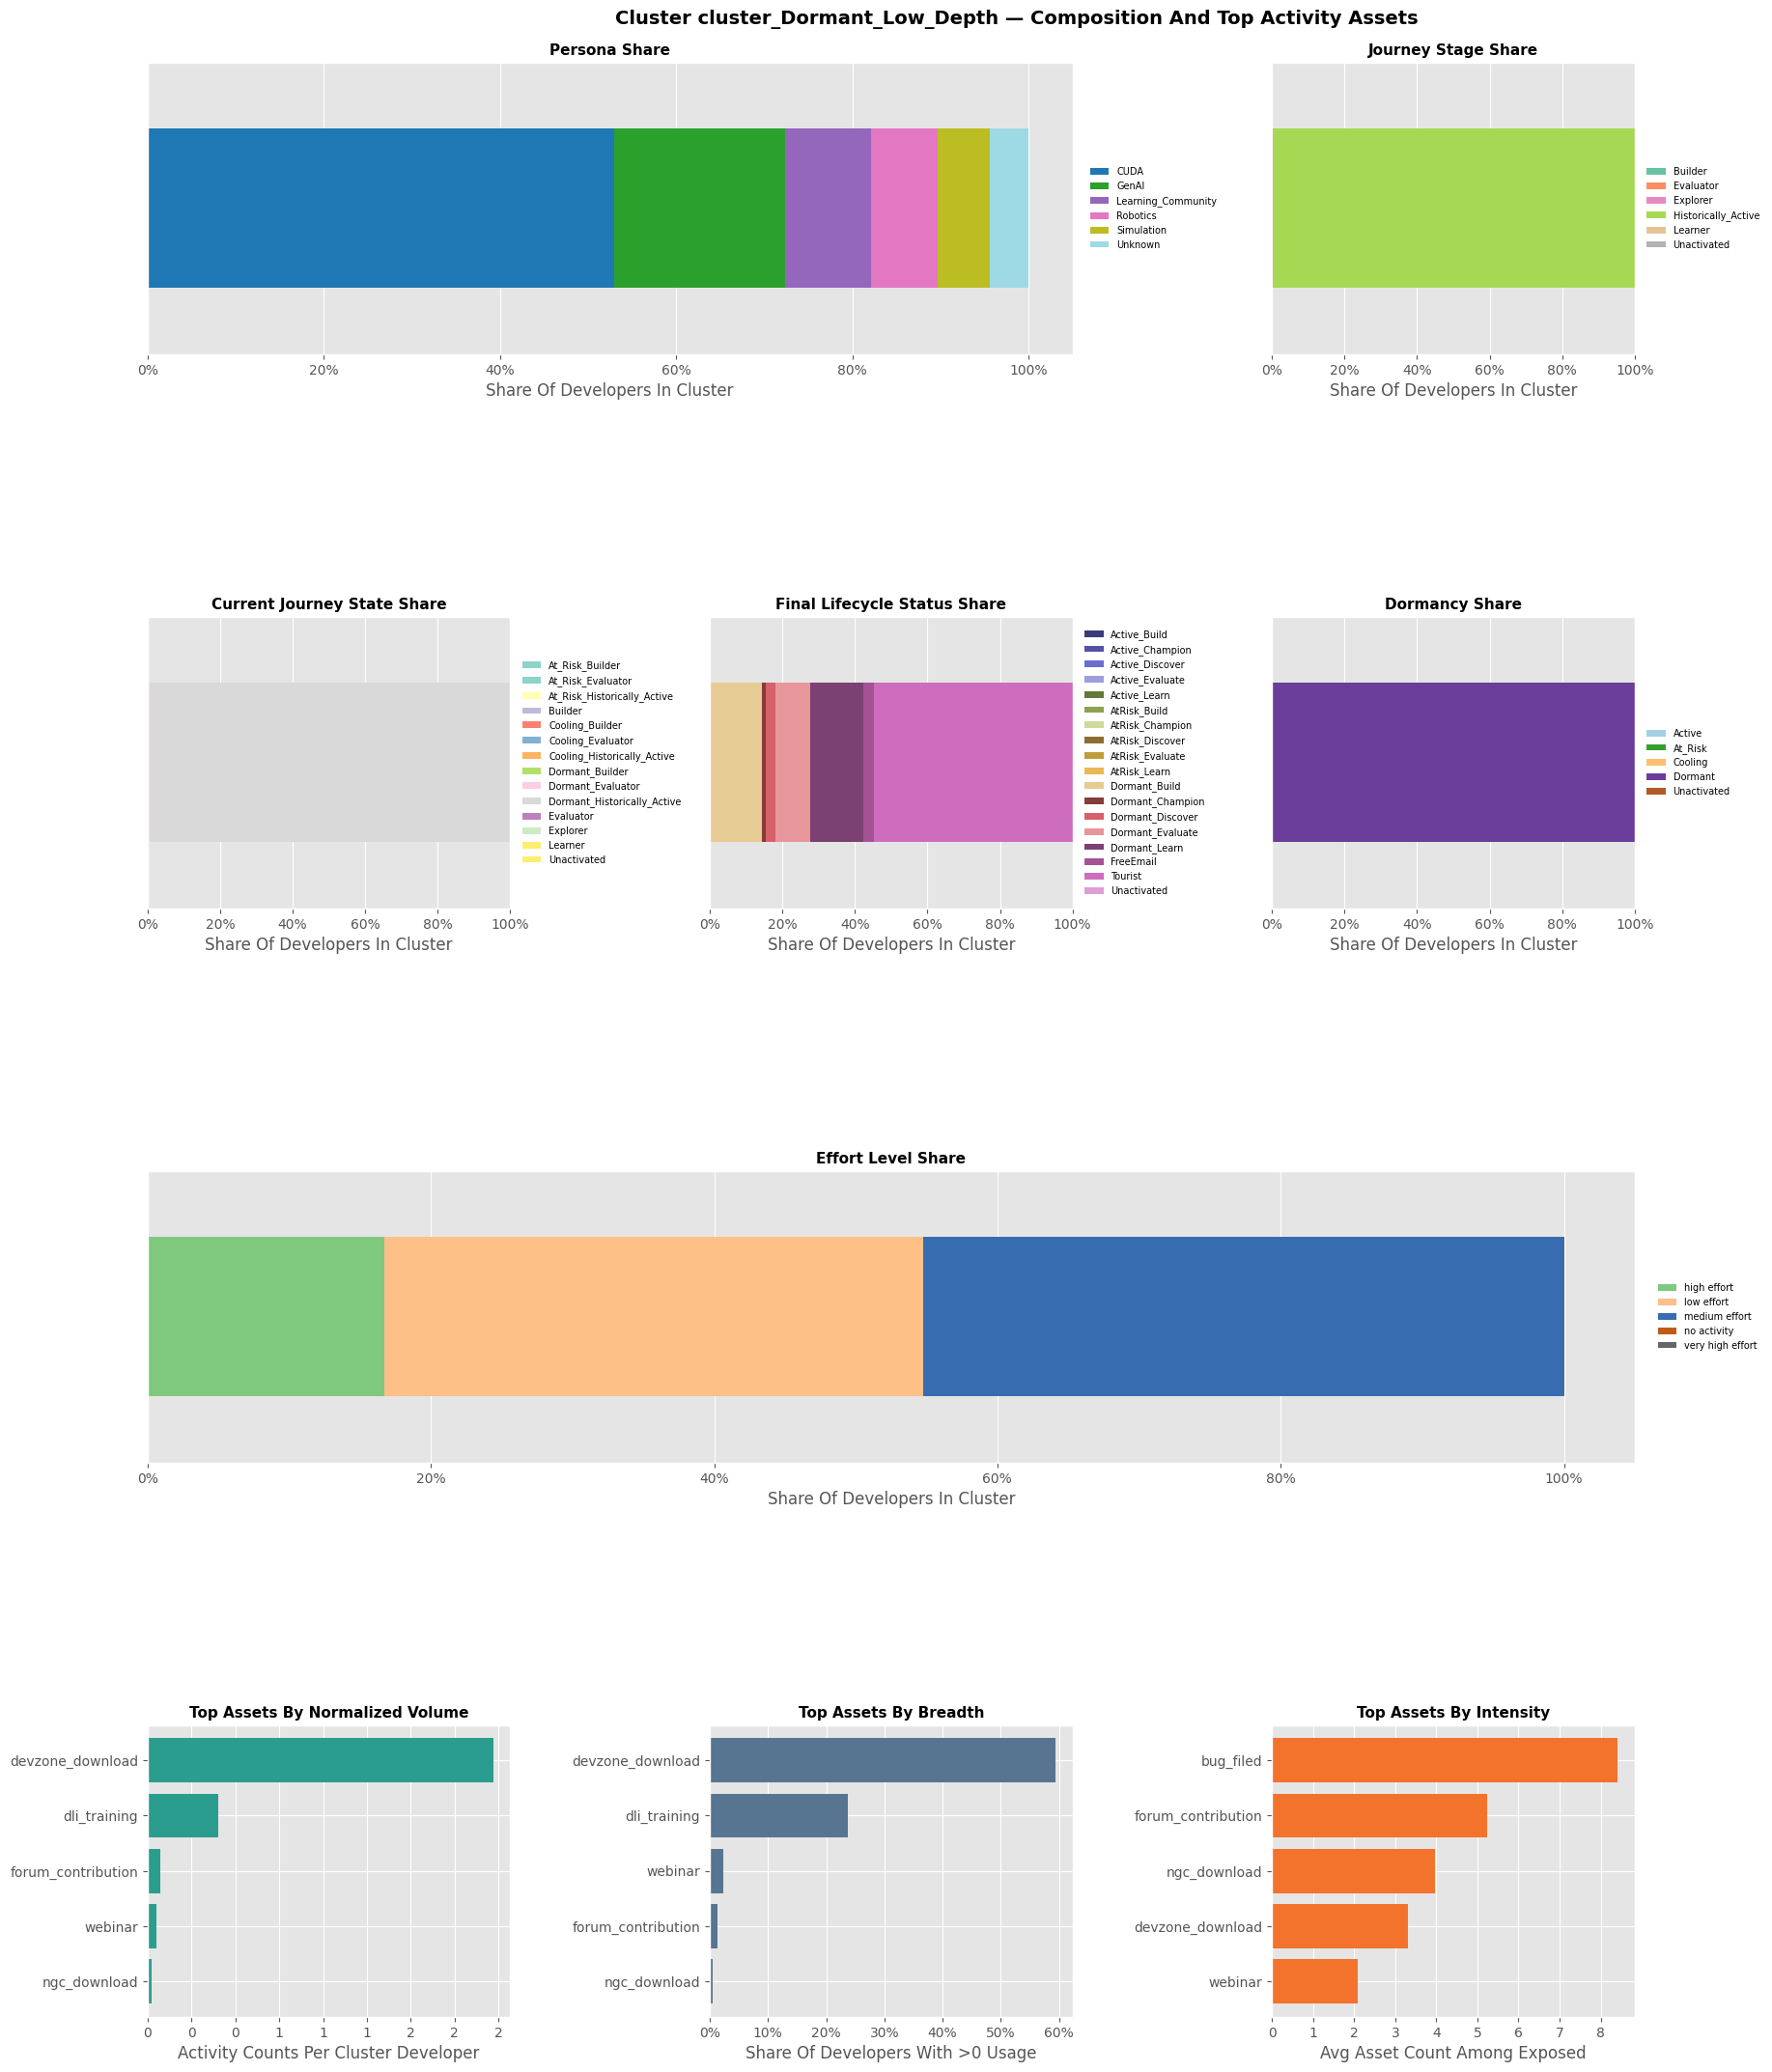

### Cluster: `cluster_unactivated` (1,718,912 developers)

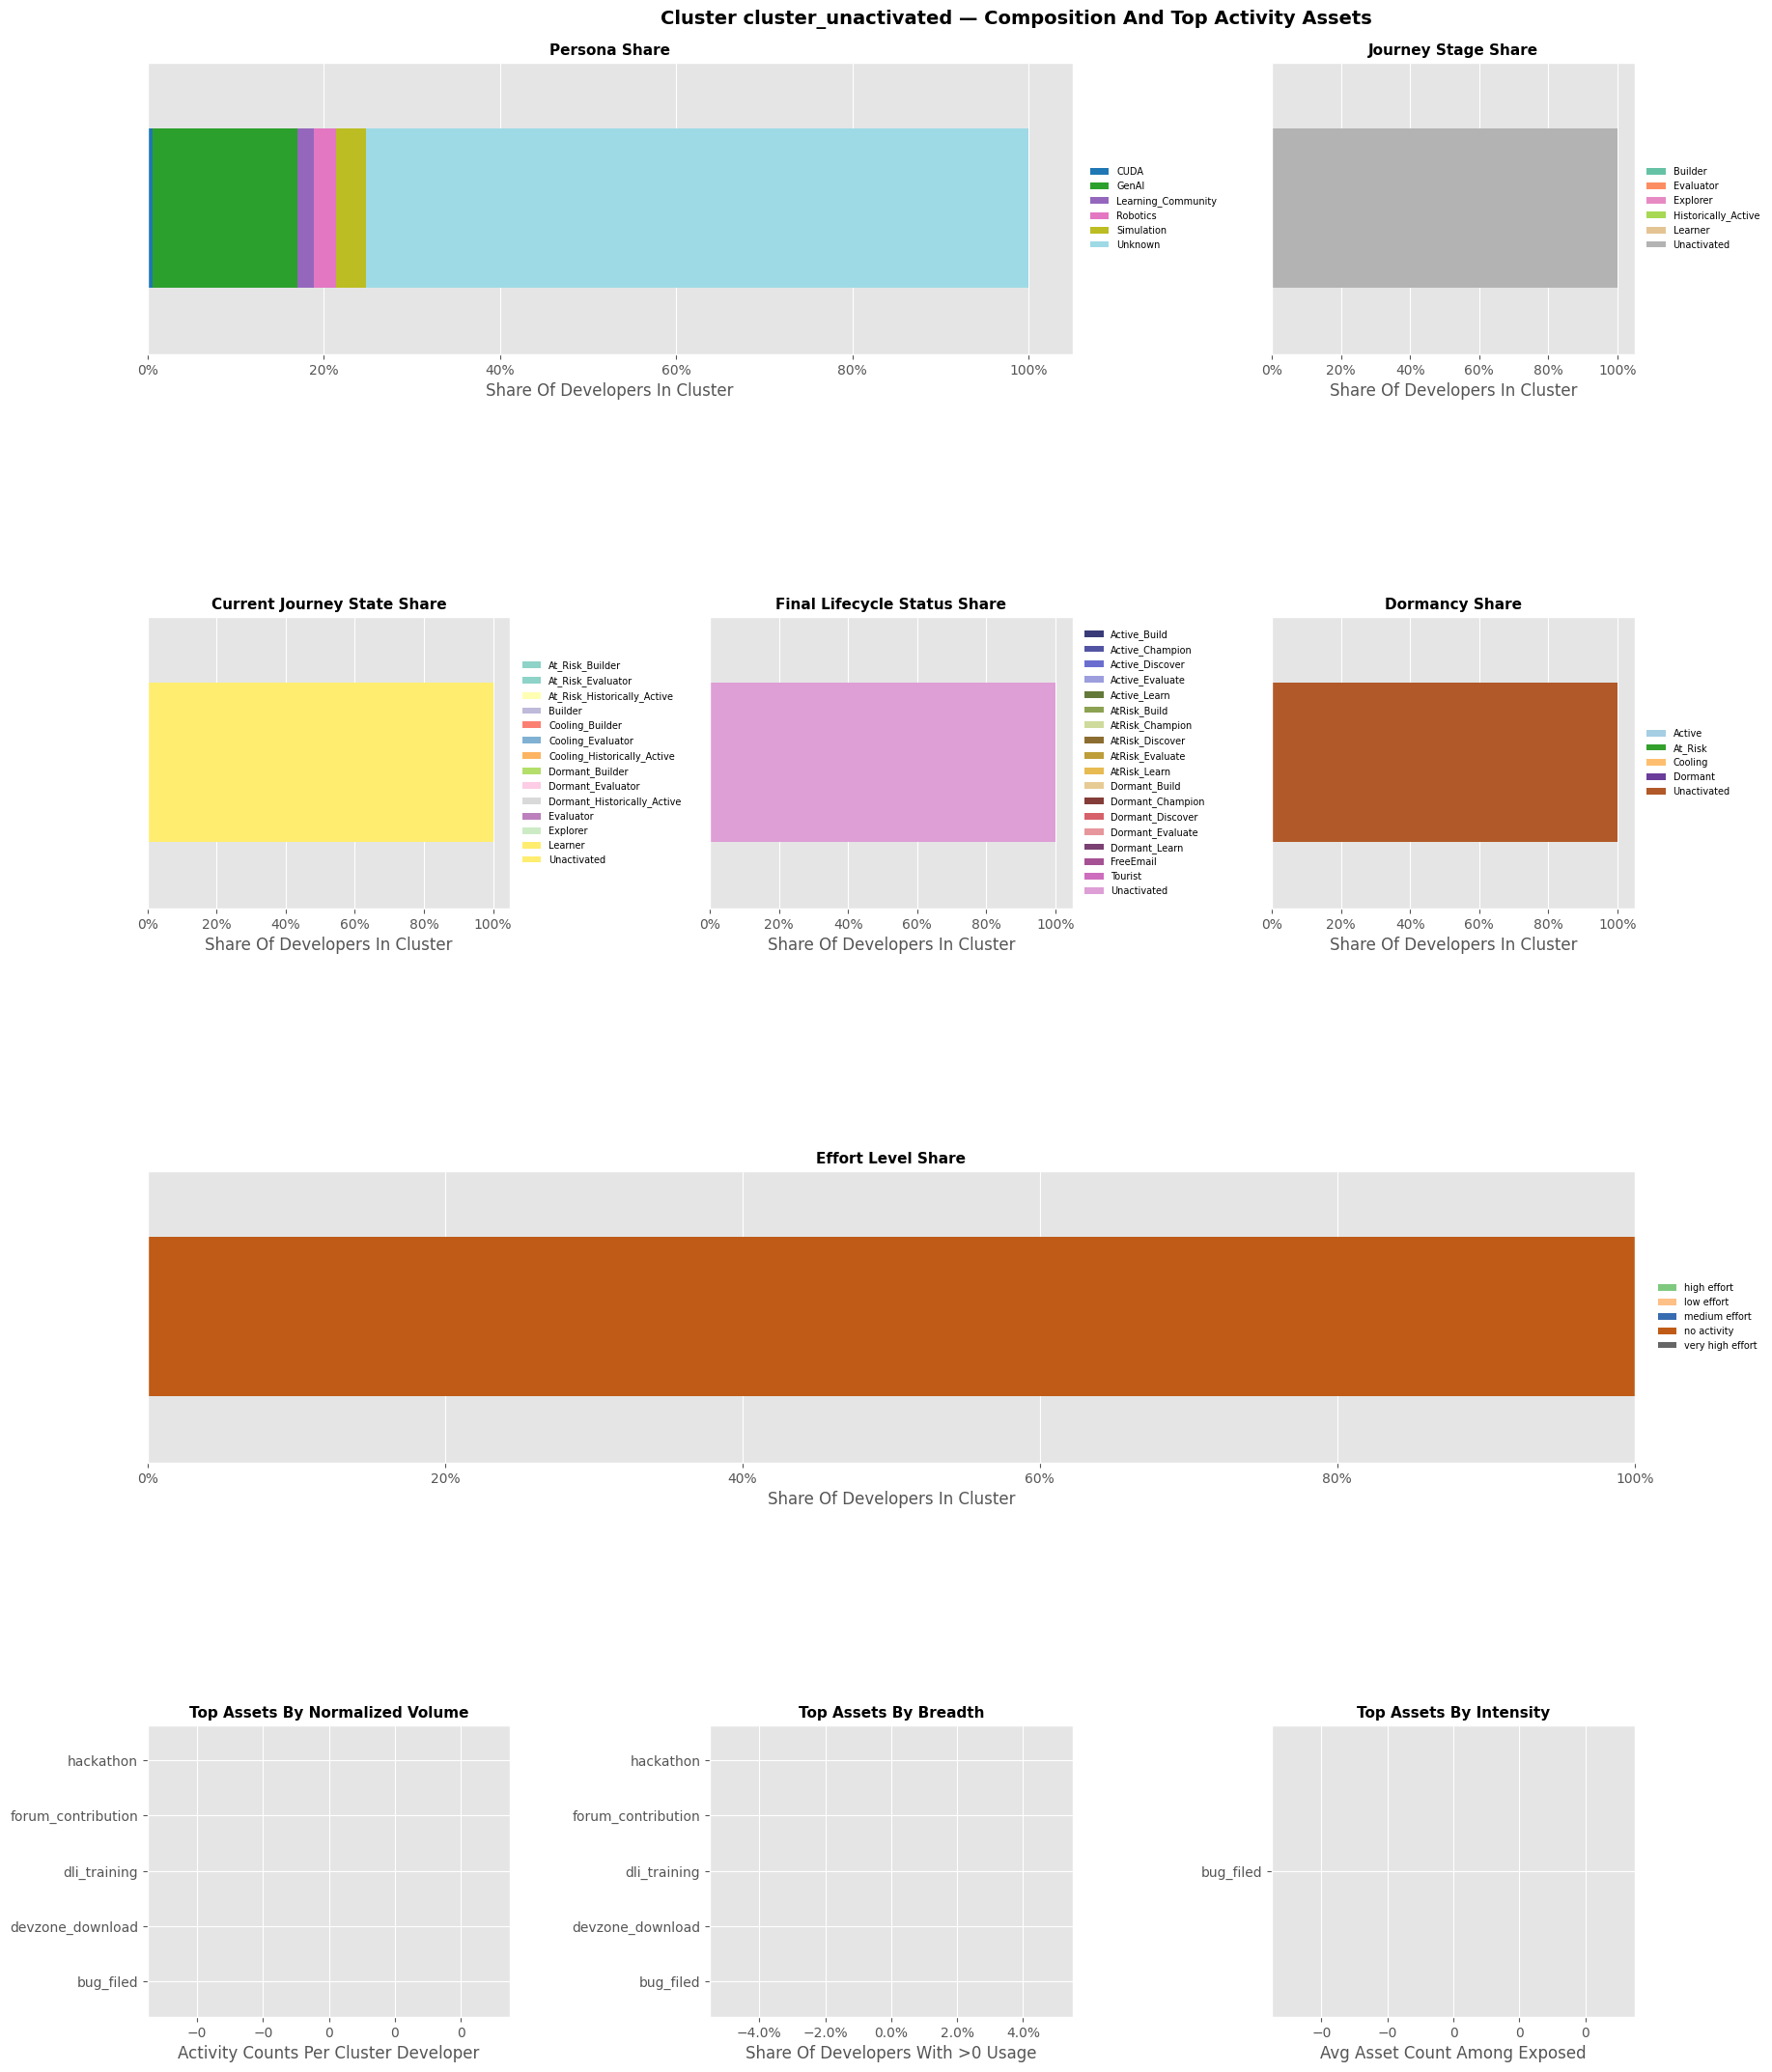

### Cluster: `cluster_Dormant_Former_Builders` (1,662,813 developers)

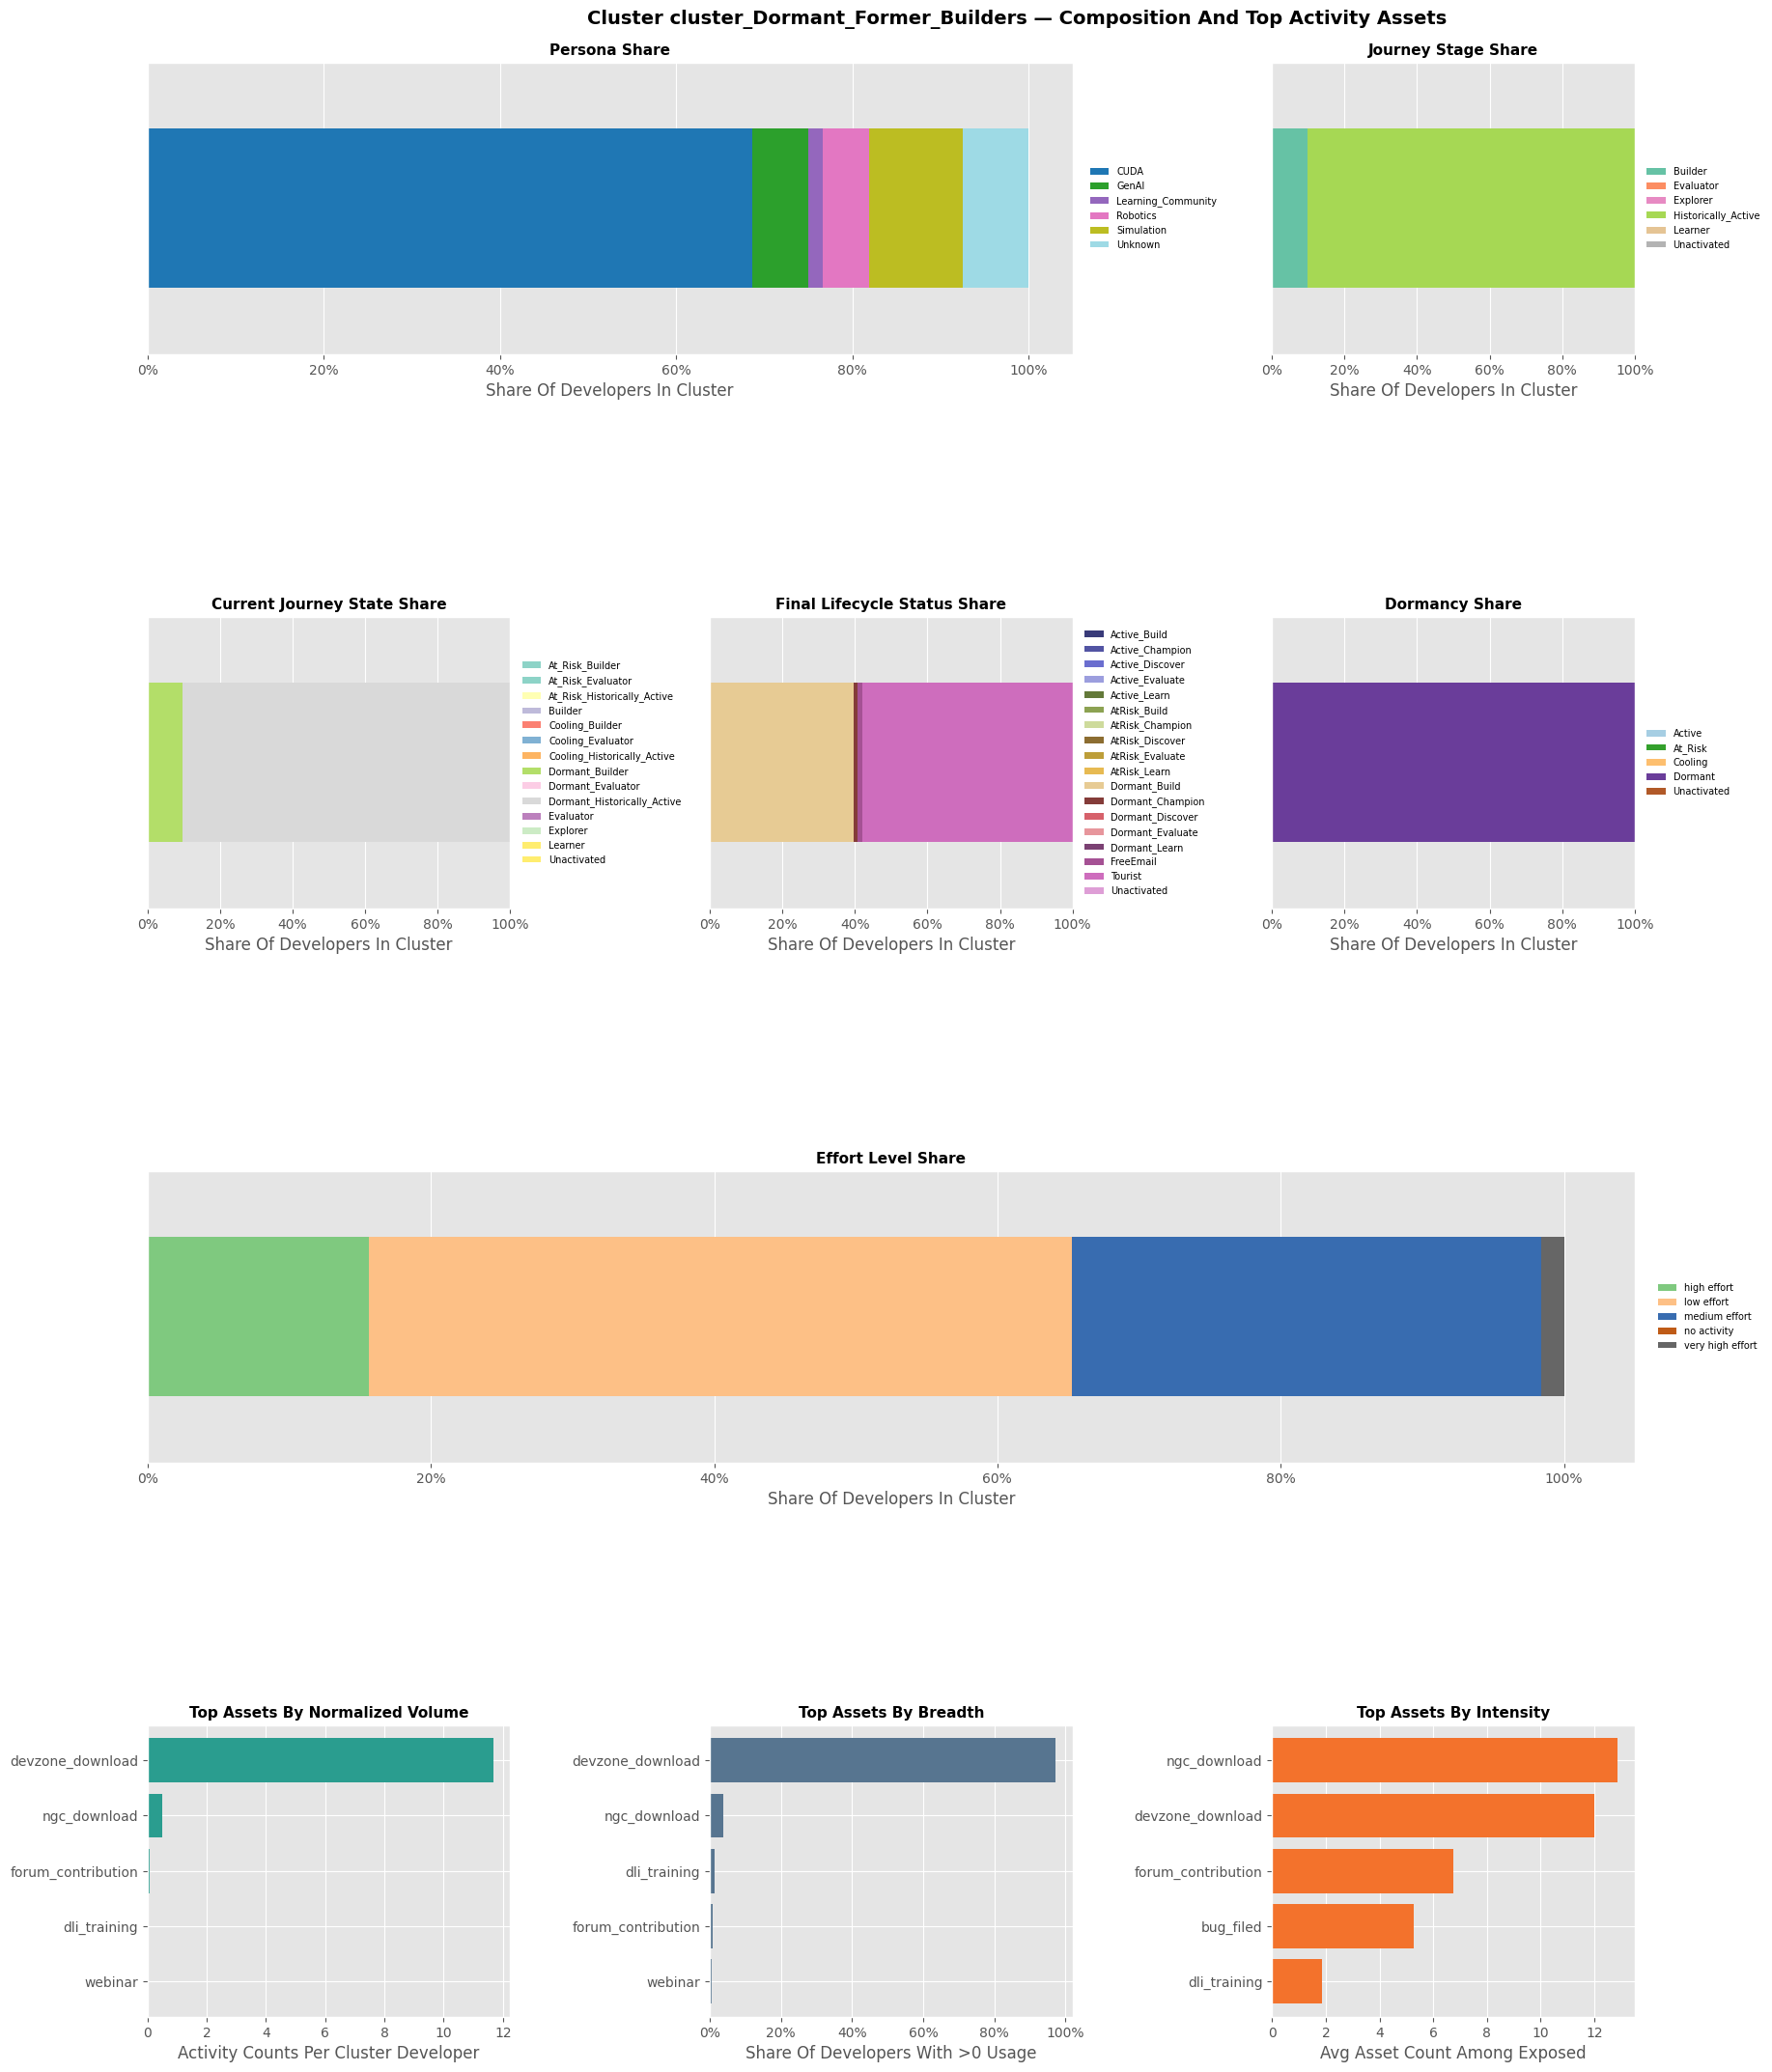

### Cluster: `cluster_Dormant_One_Time_Users` (1,175,698 developers)

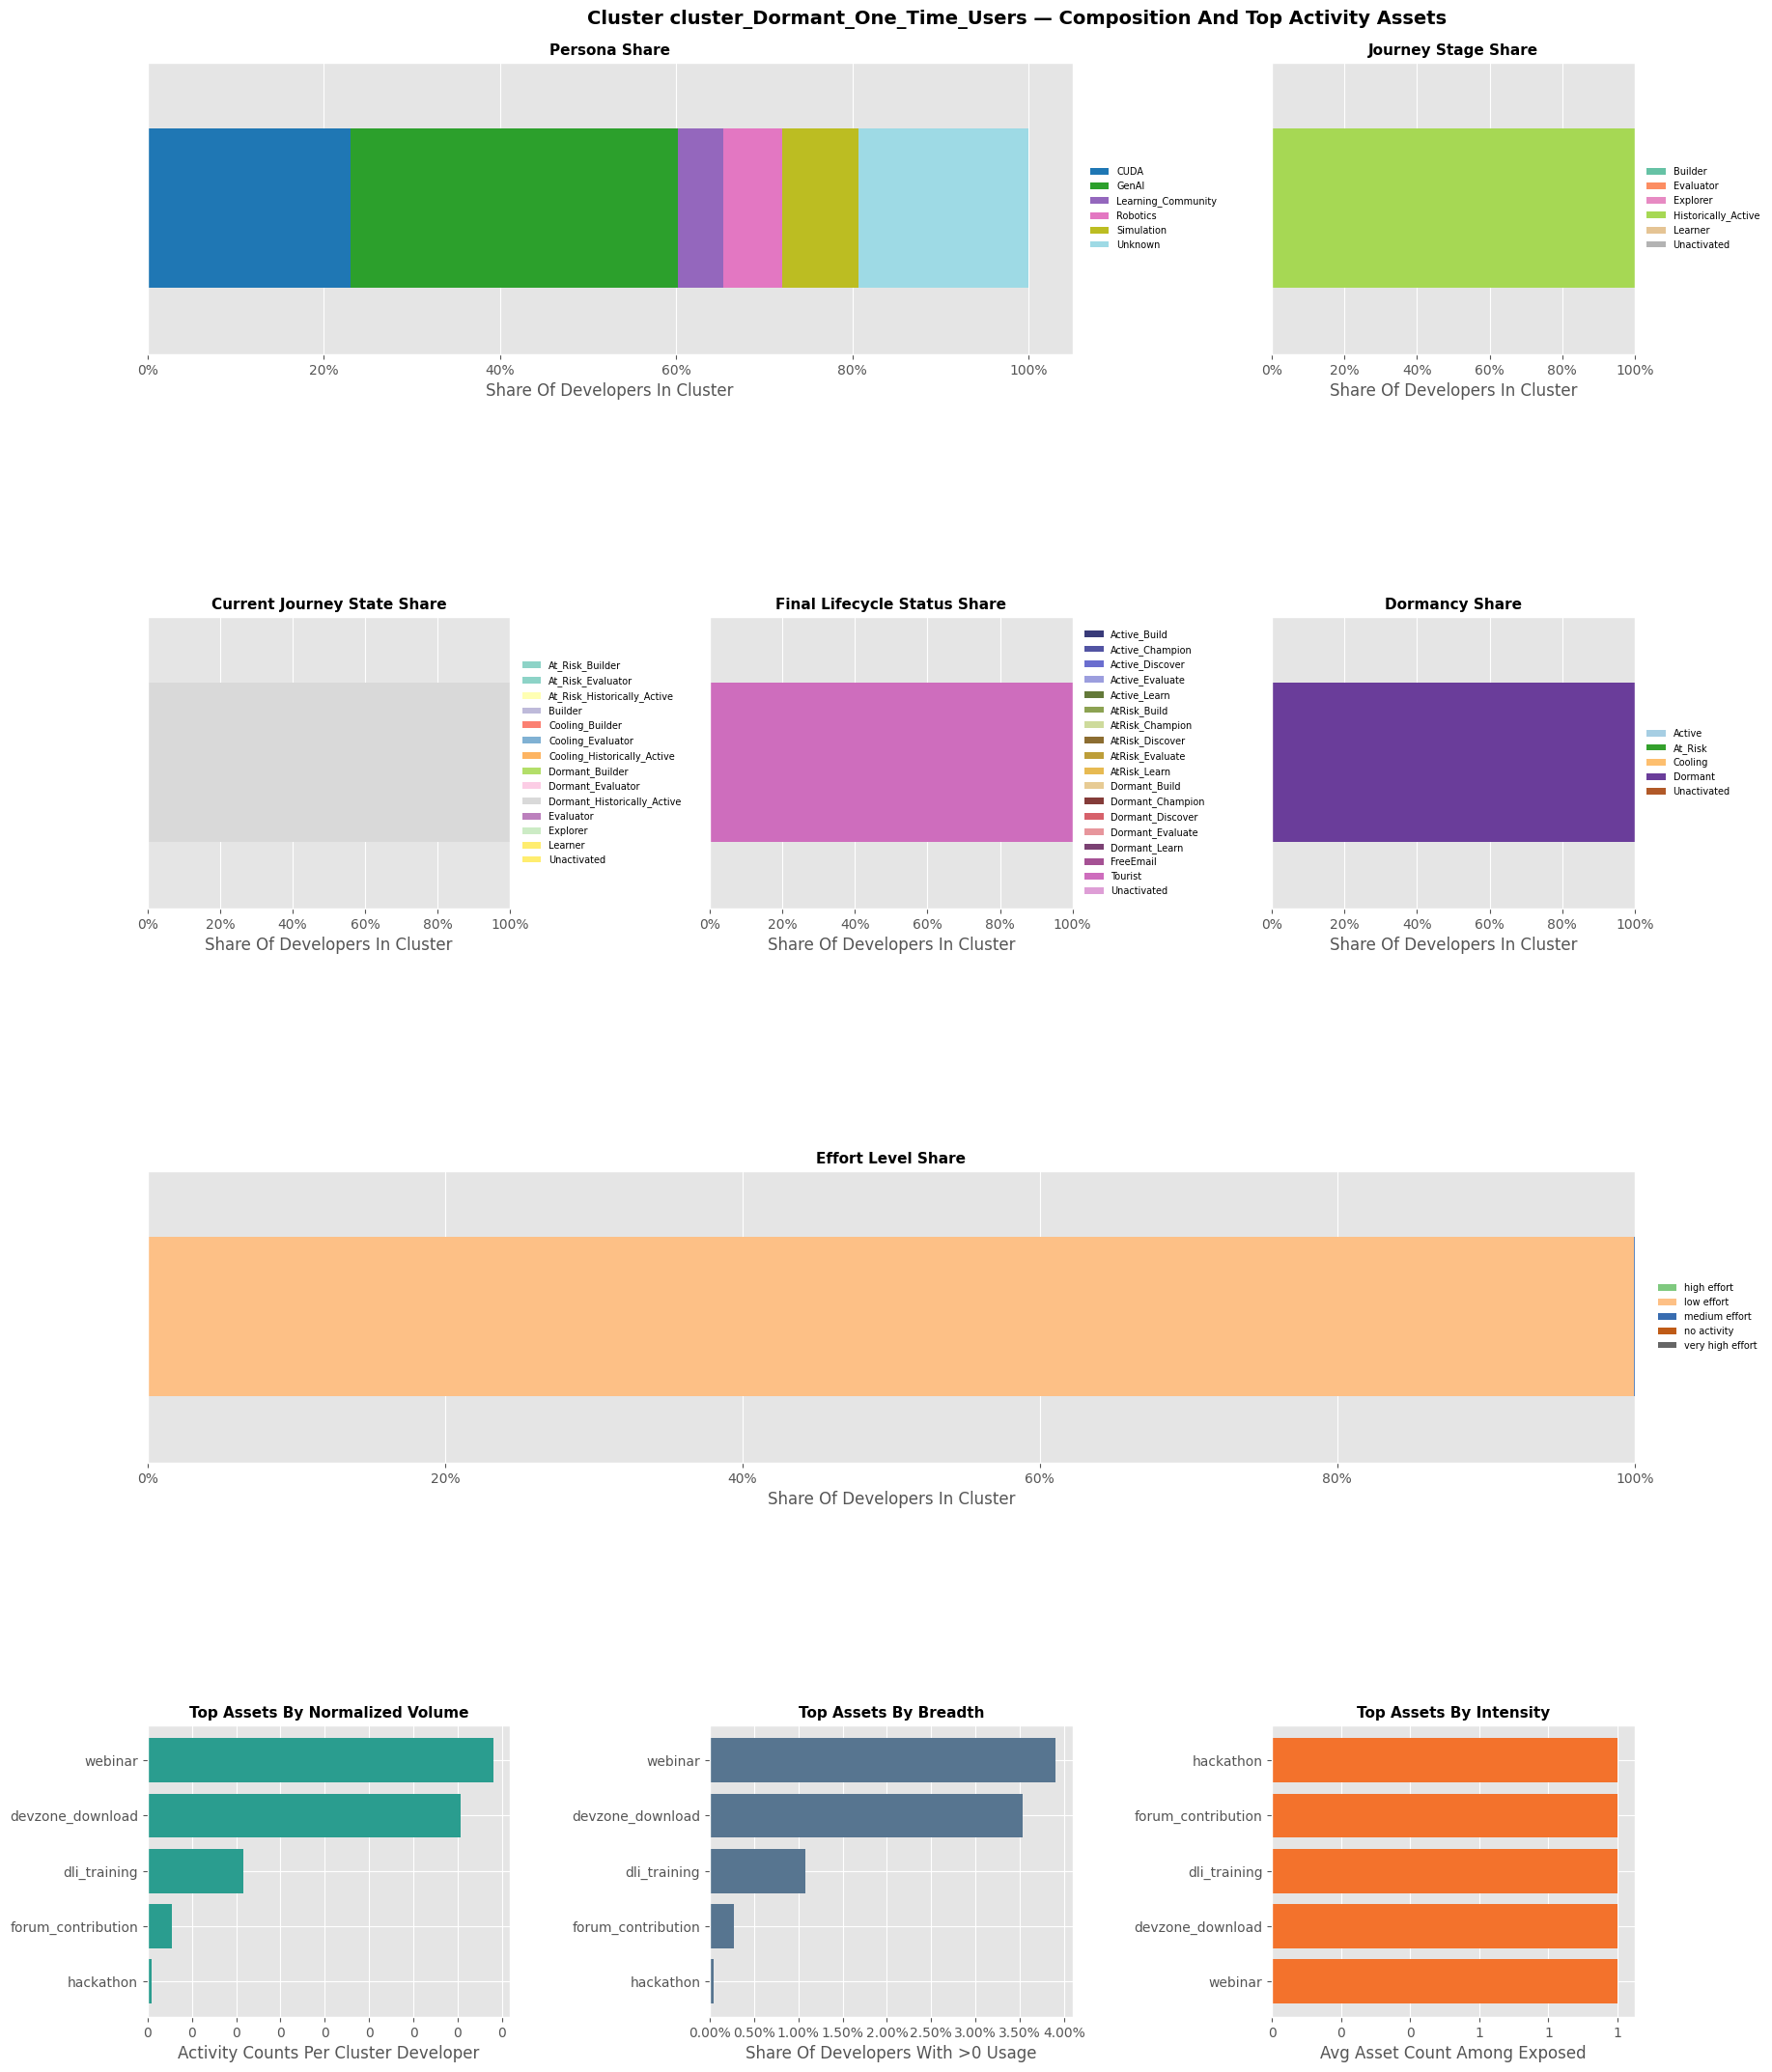

### Cluster: `cluster_at_risk_0` (436,278 developers)

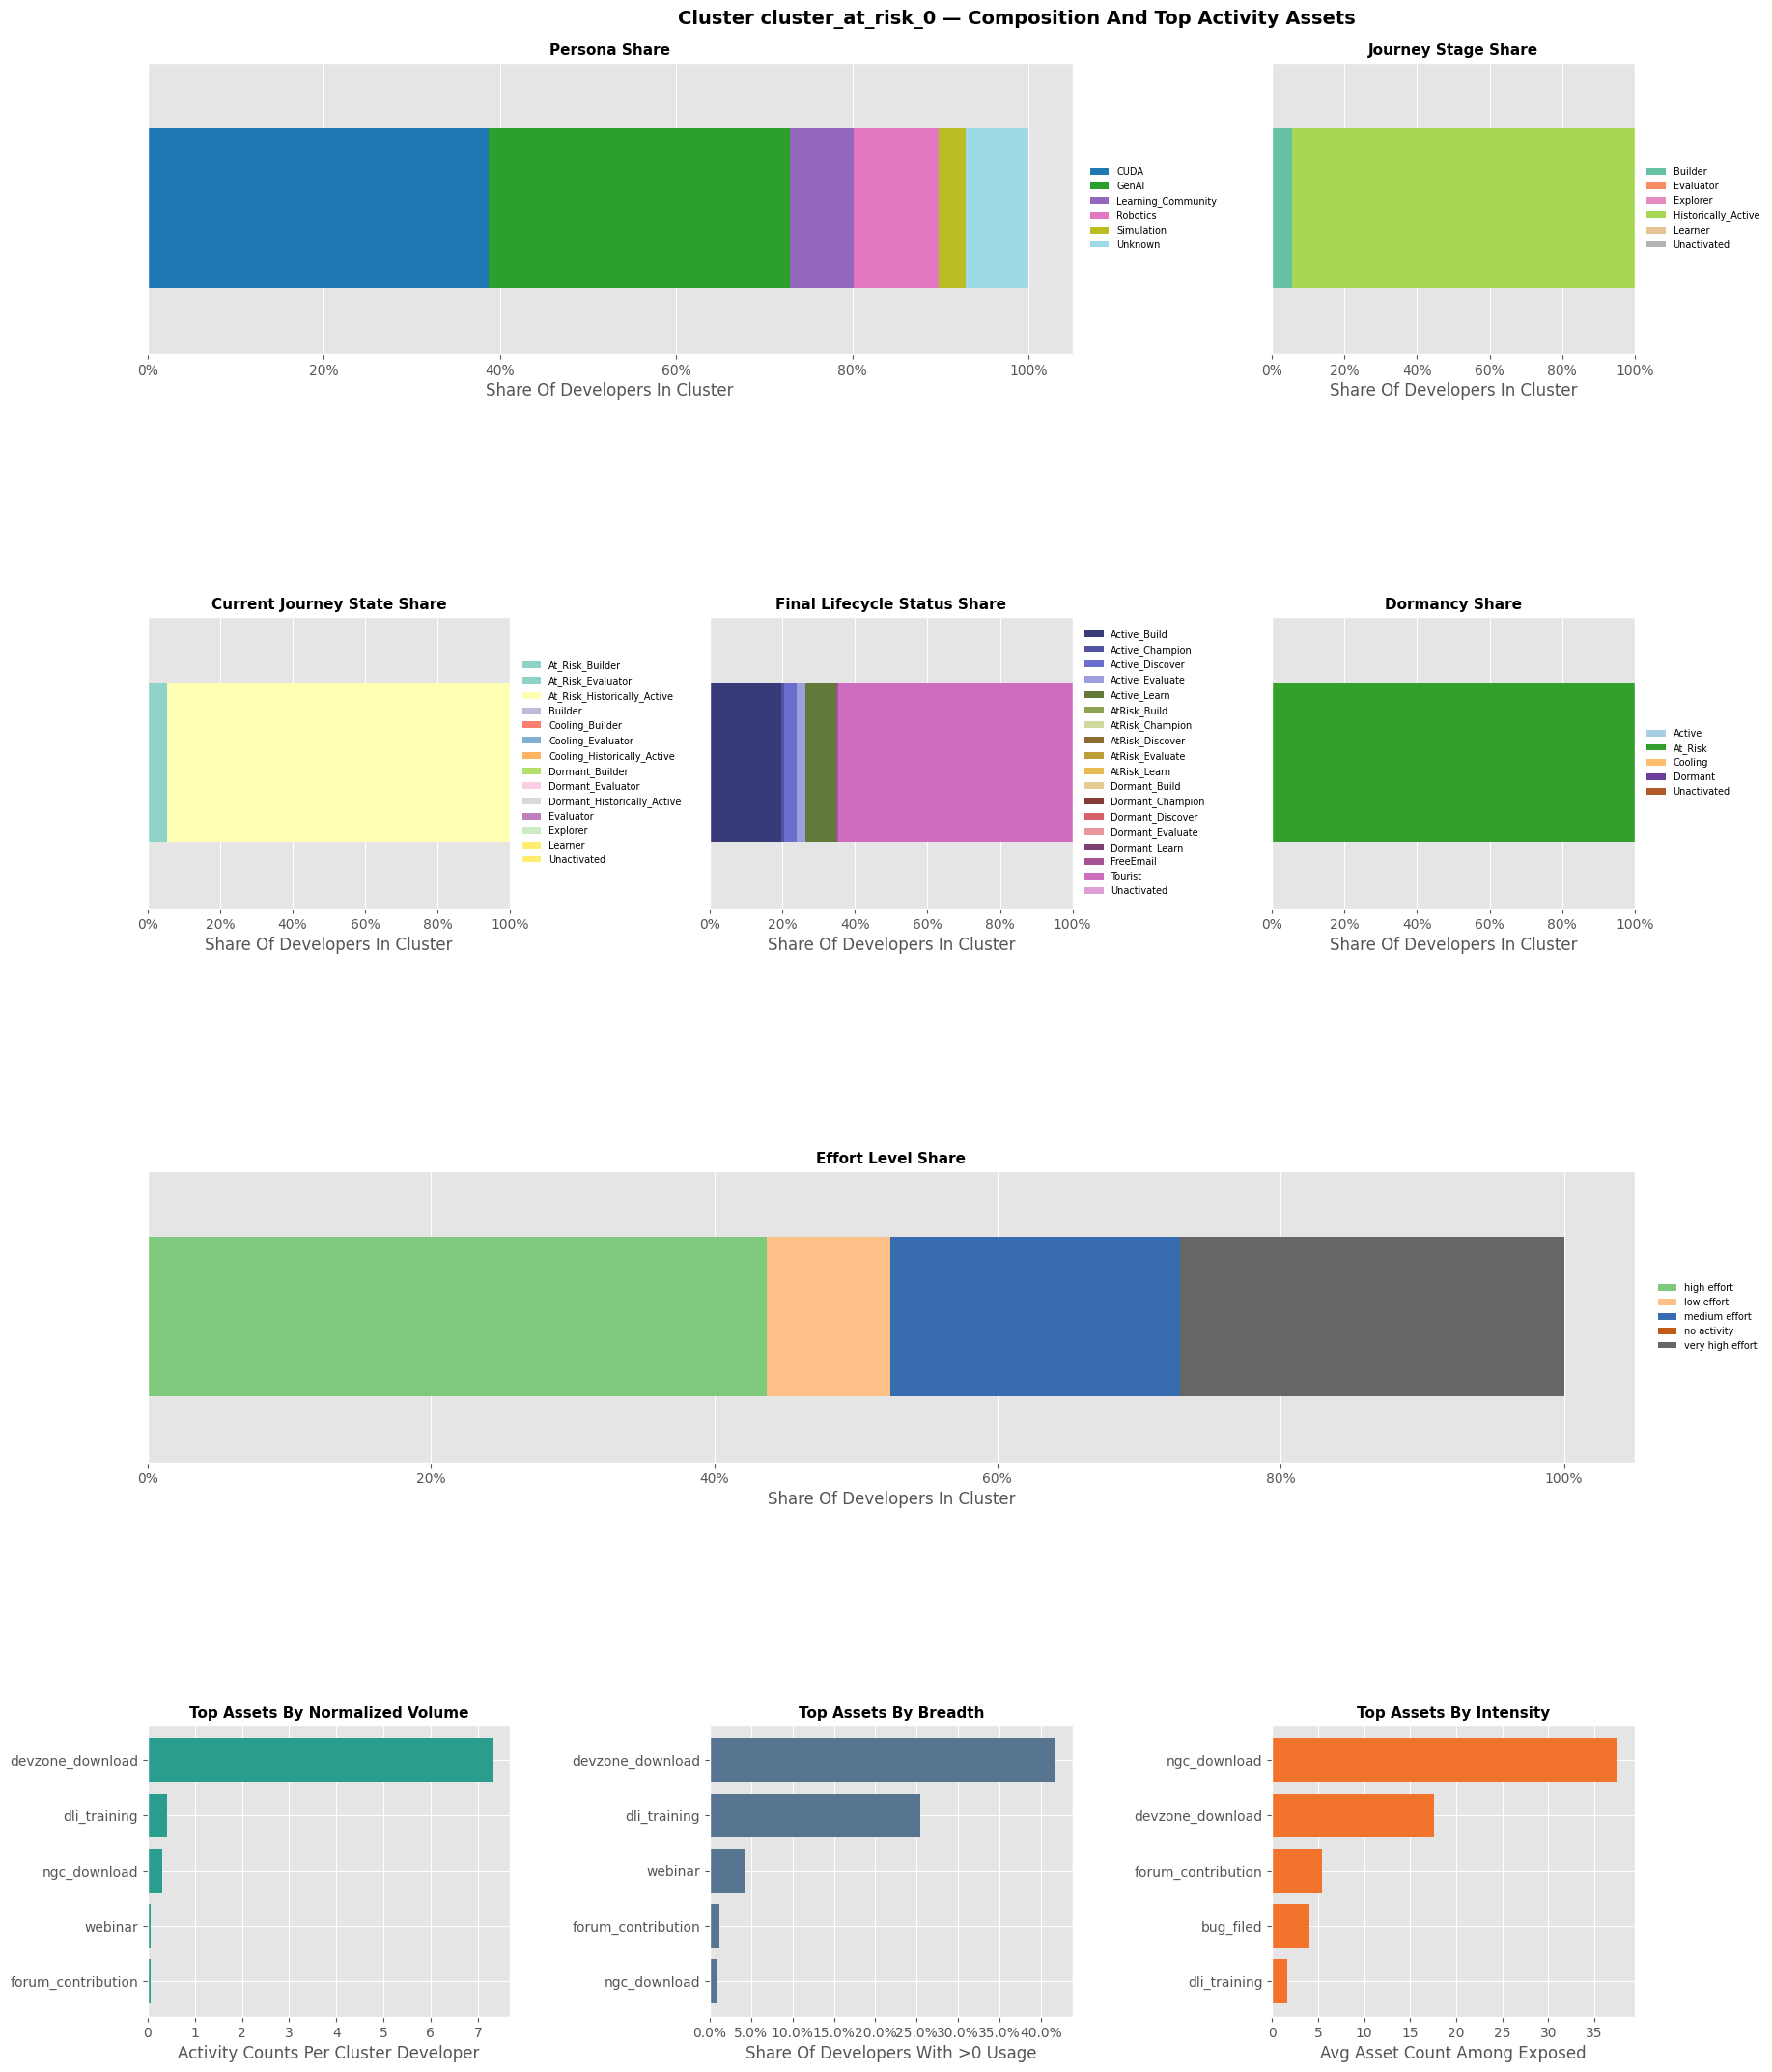

### Cluster: `cluster_at_risk_5` (366,453 developers)

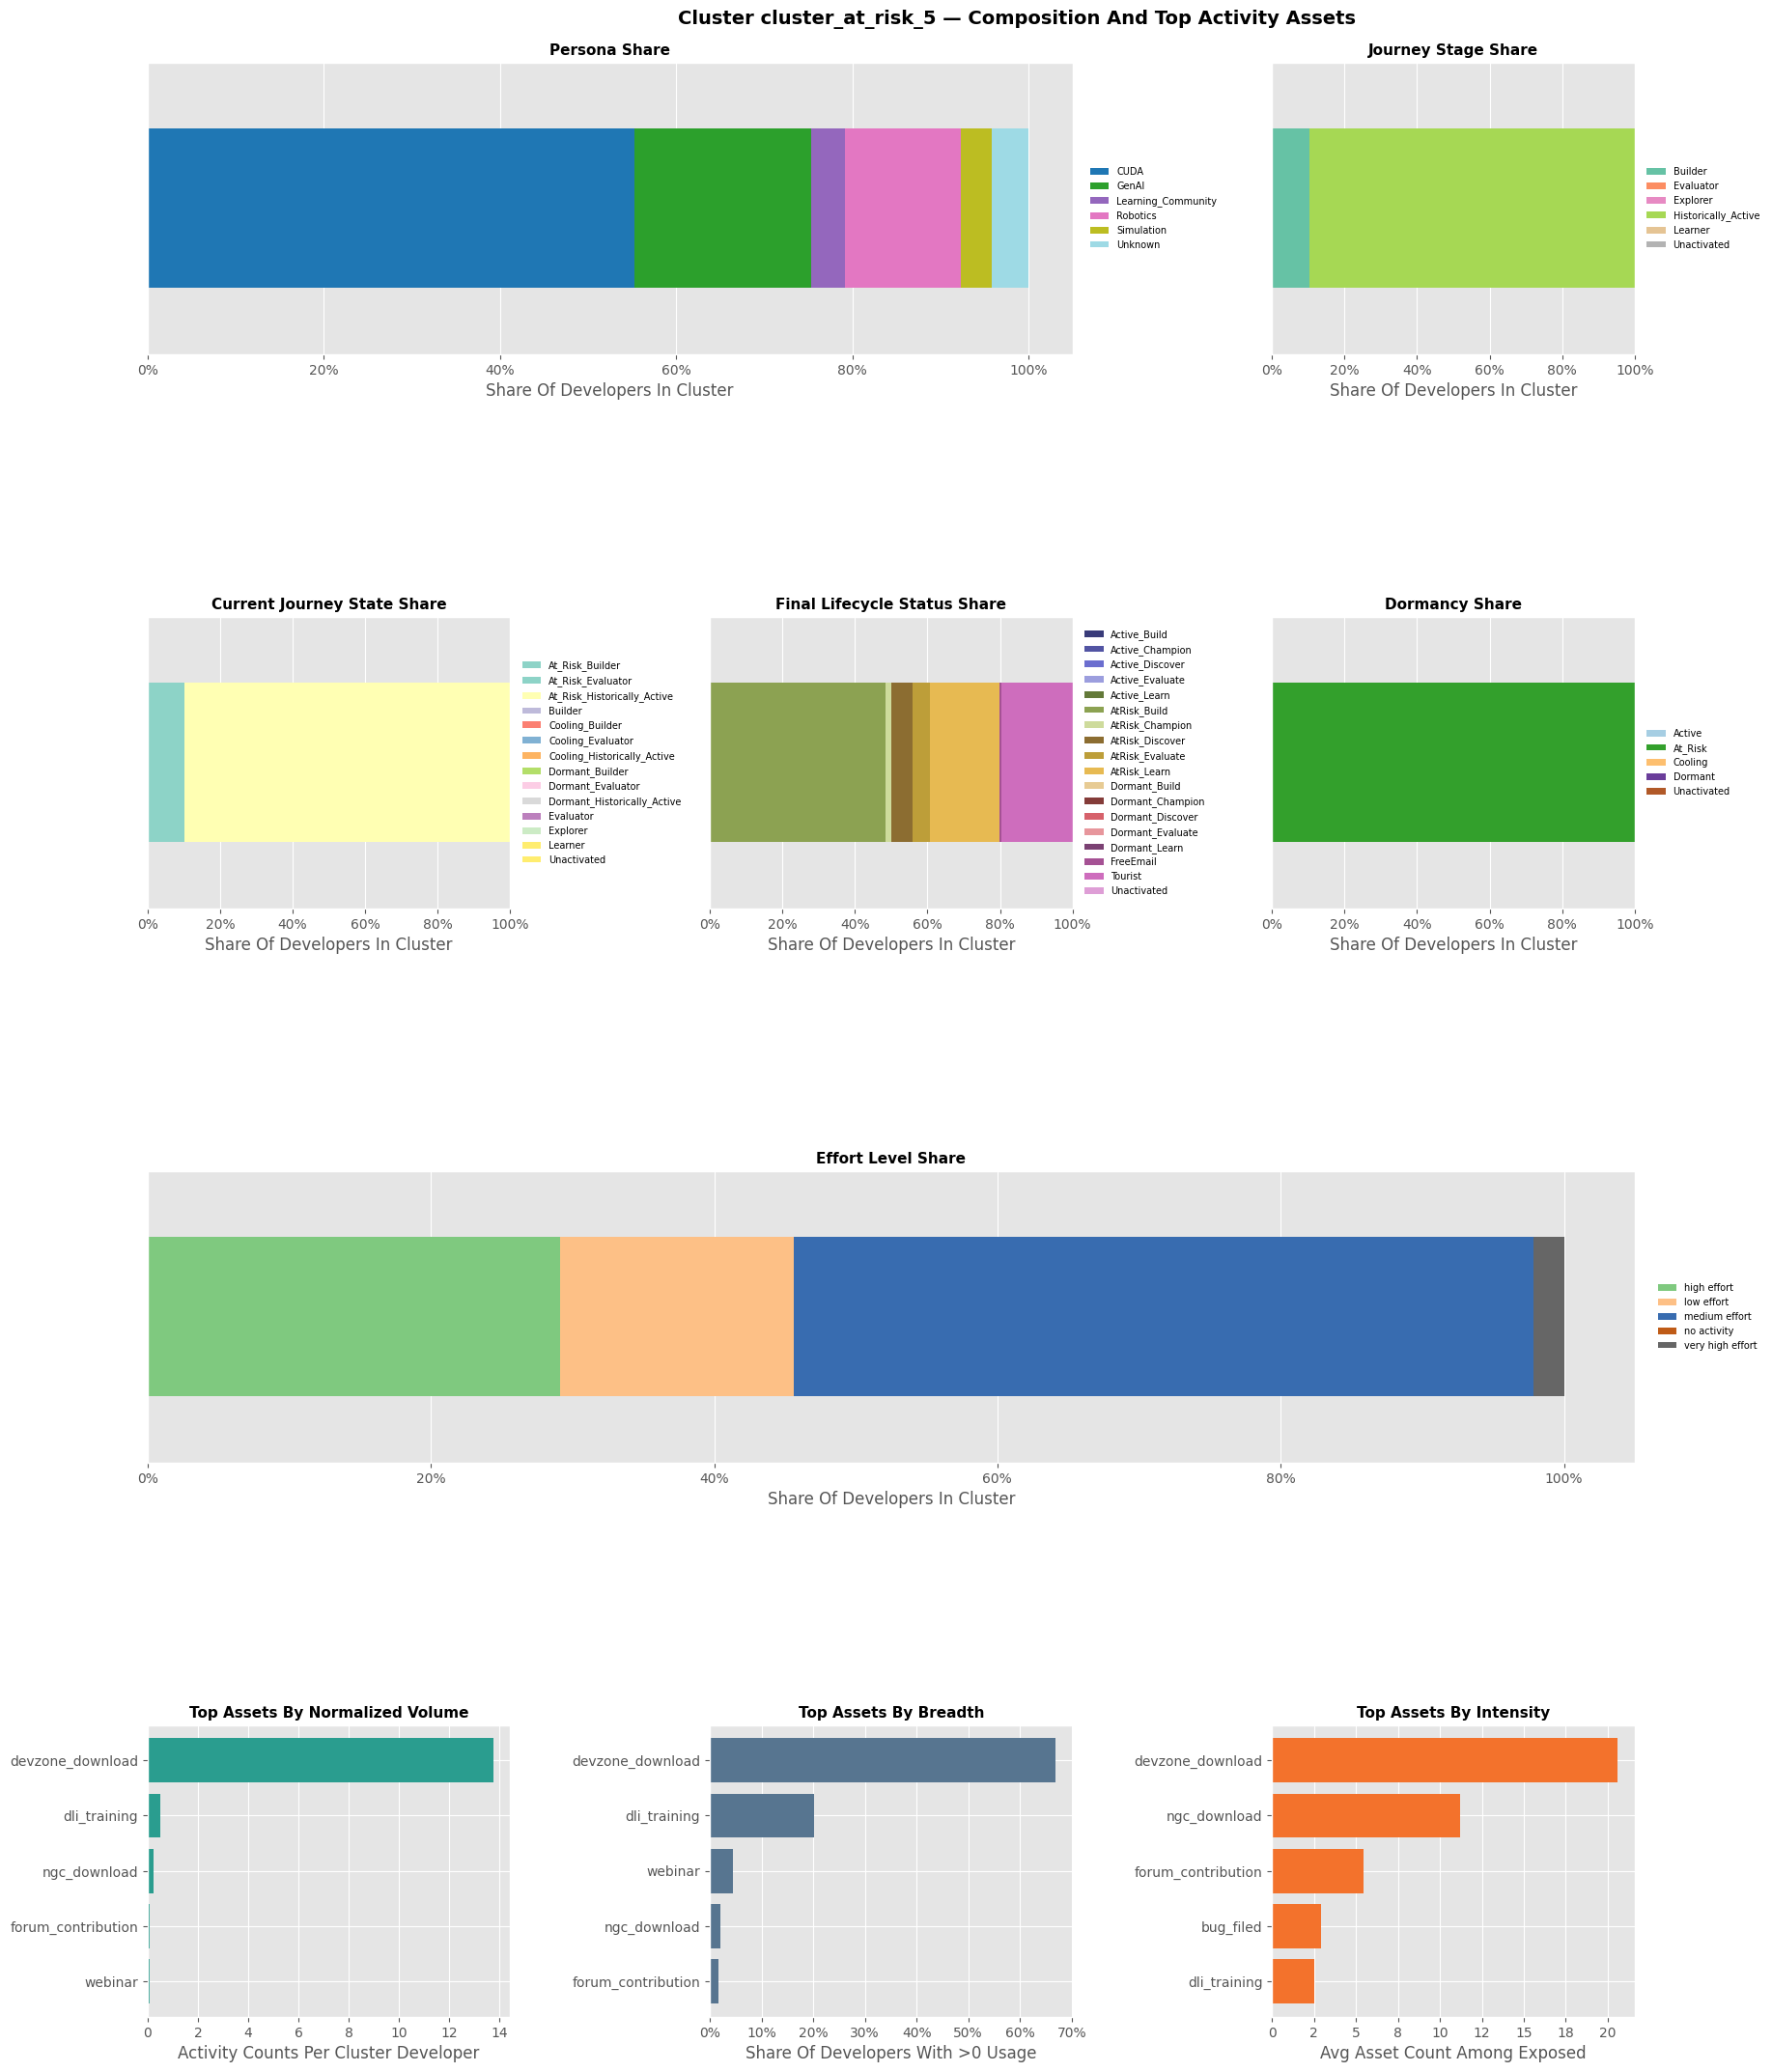

### Cluster: `cluster_at_risk_2` (210,376 developers)

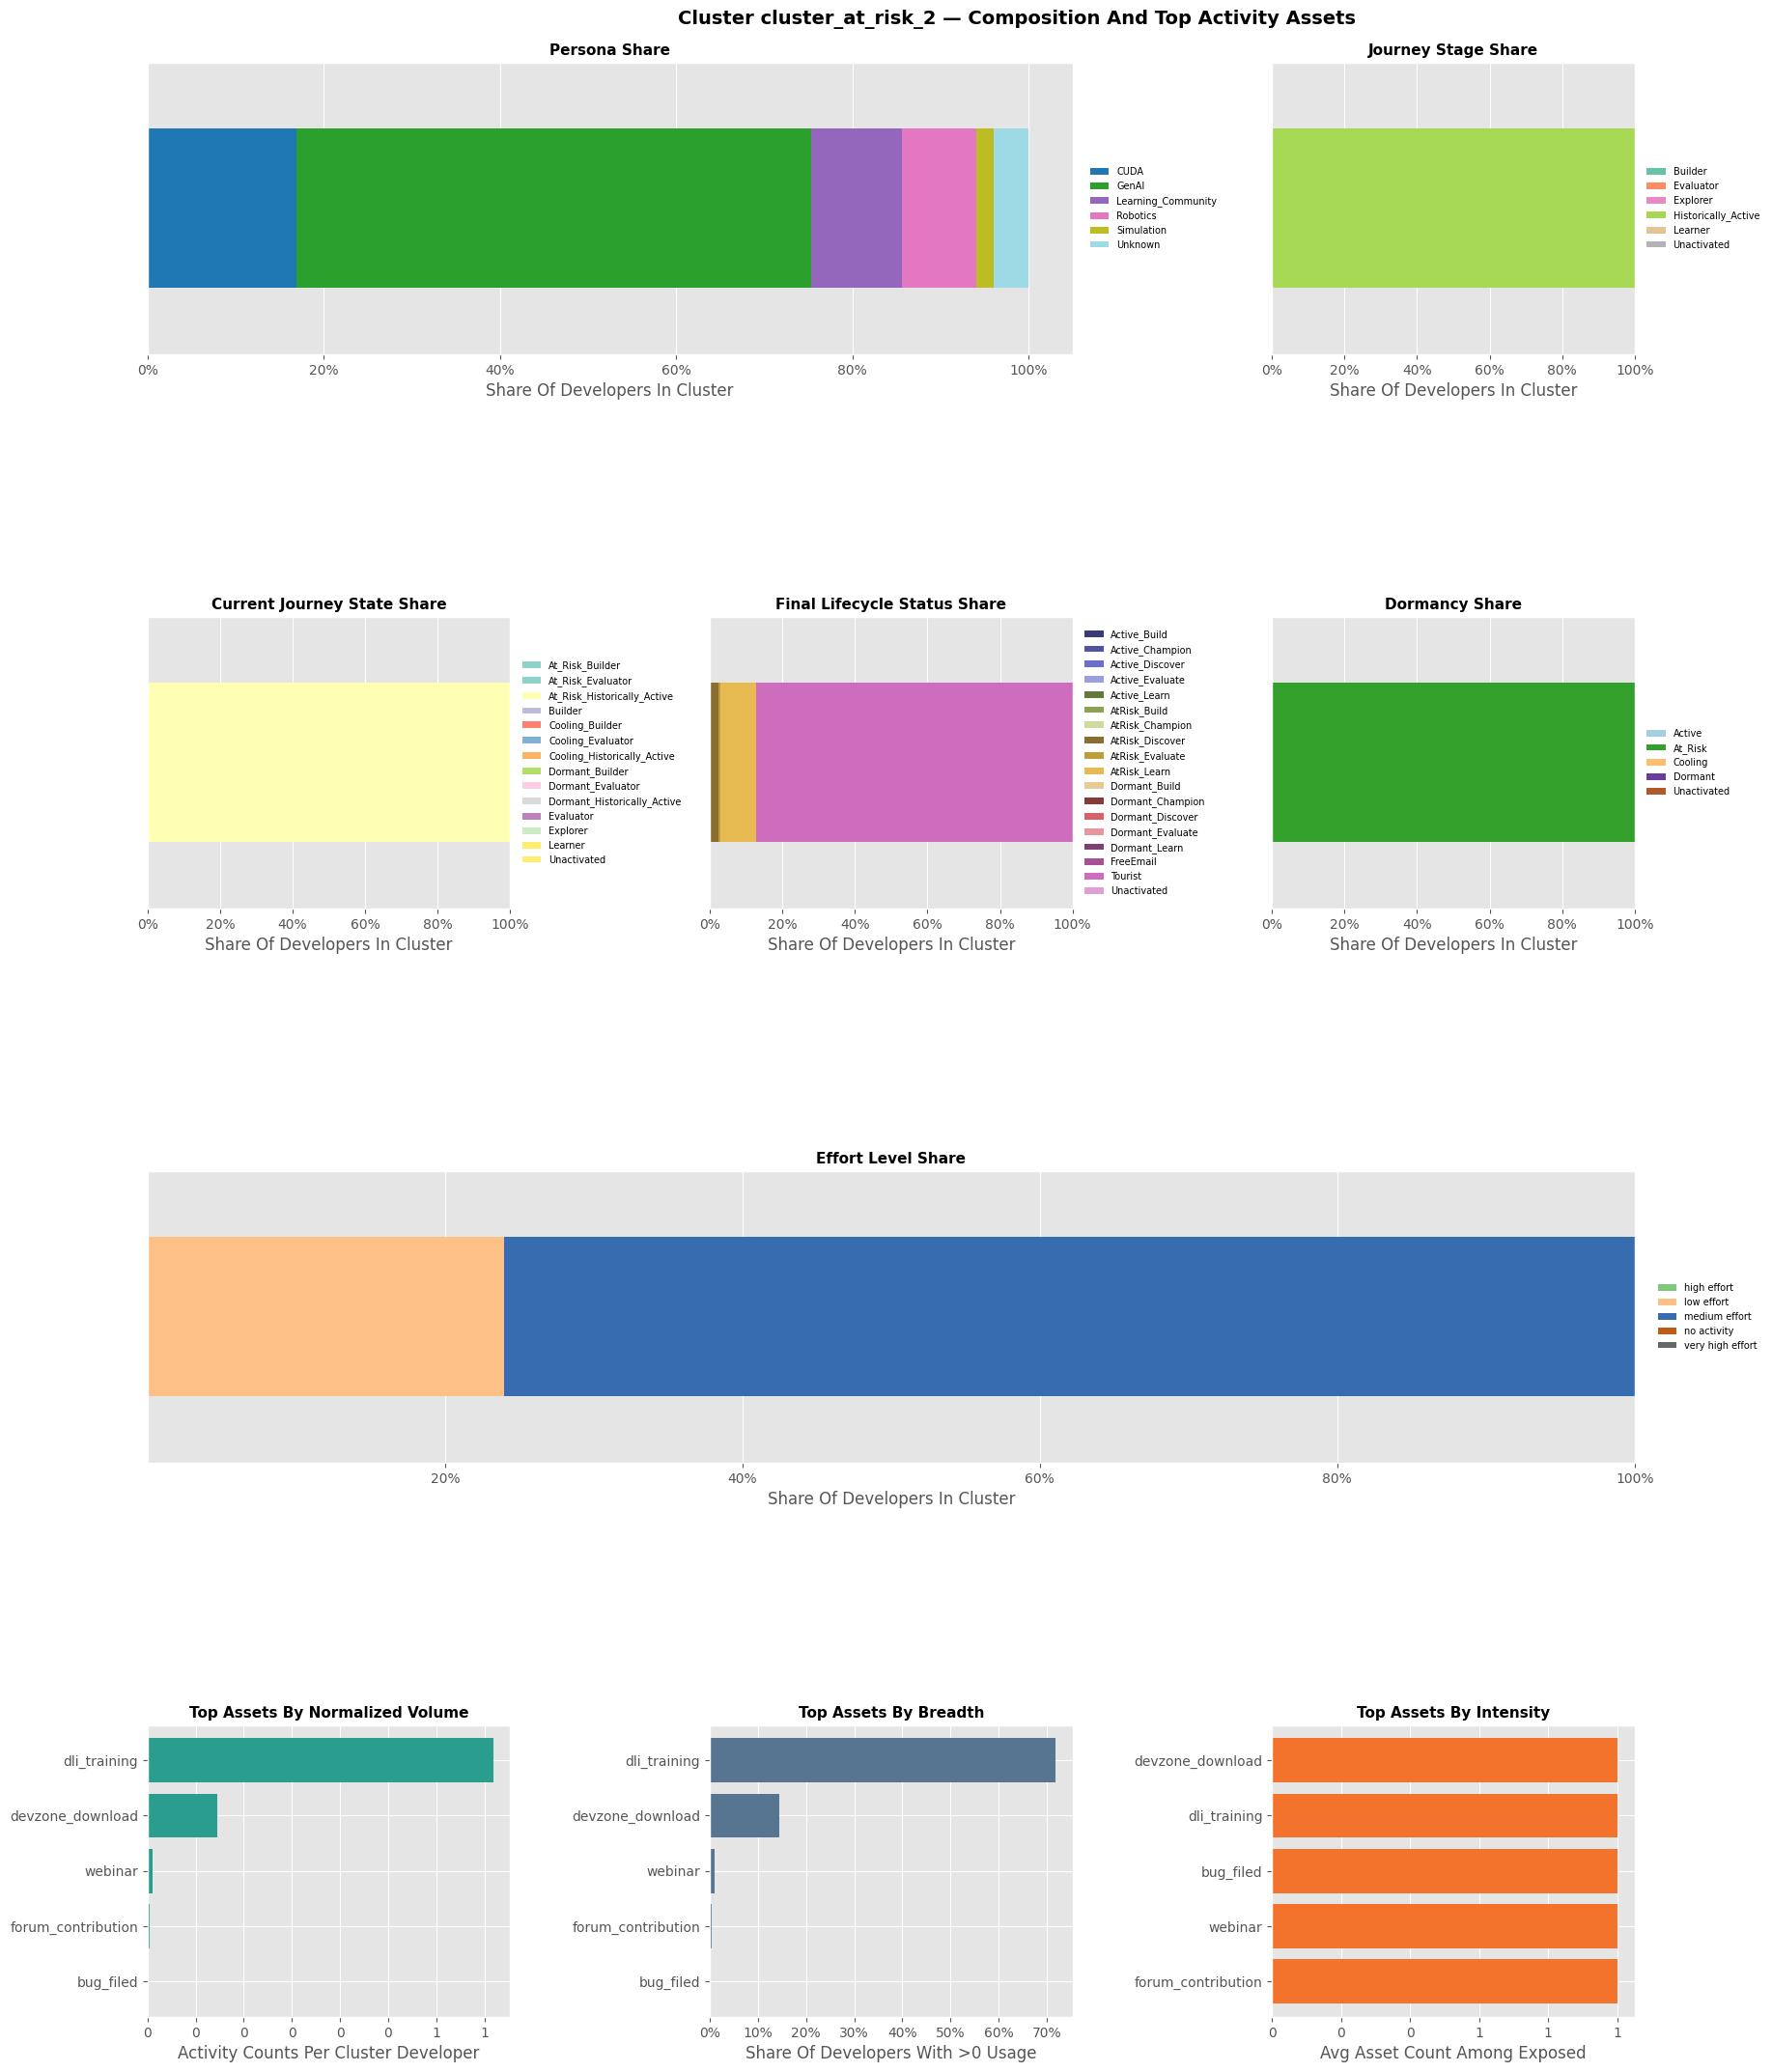

### Cluster: `cluster_at_risk_3` (206,877 developers)

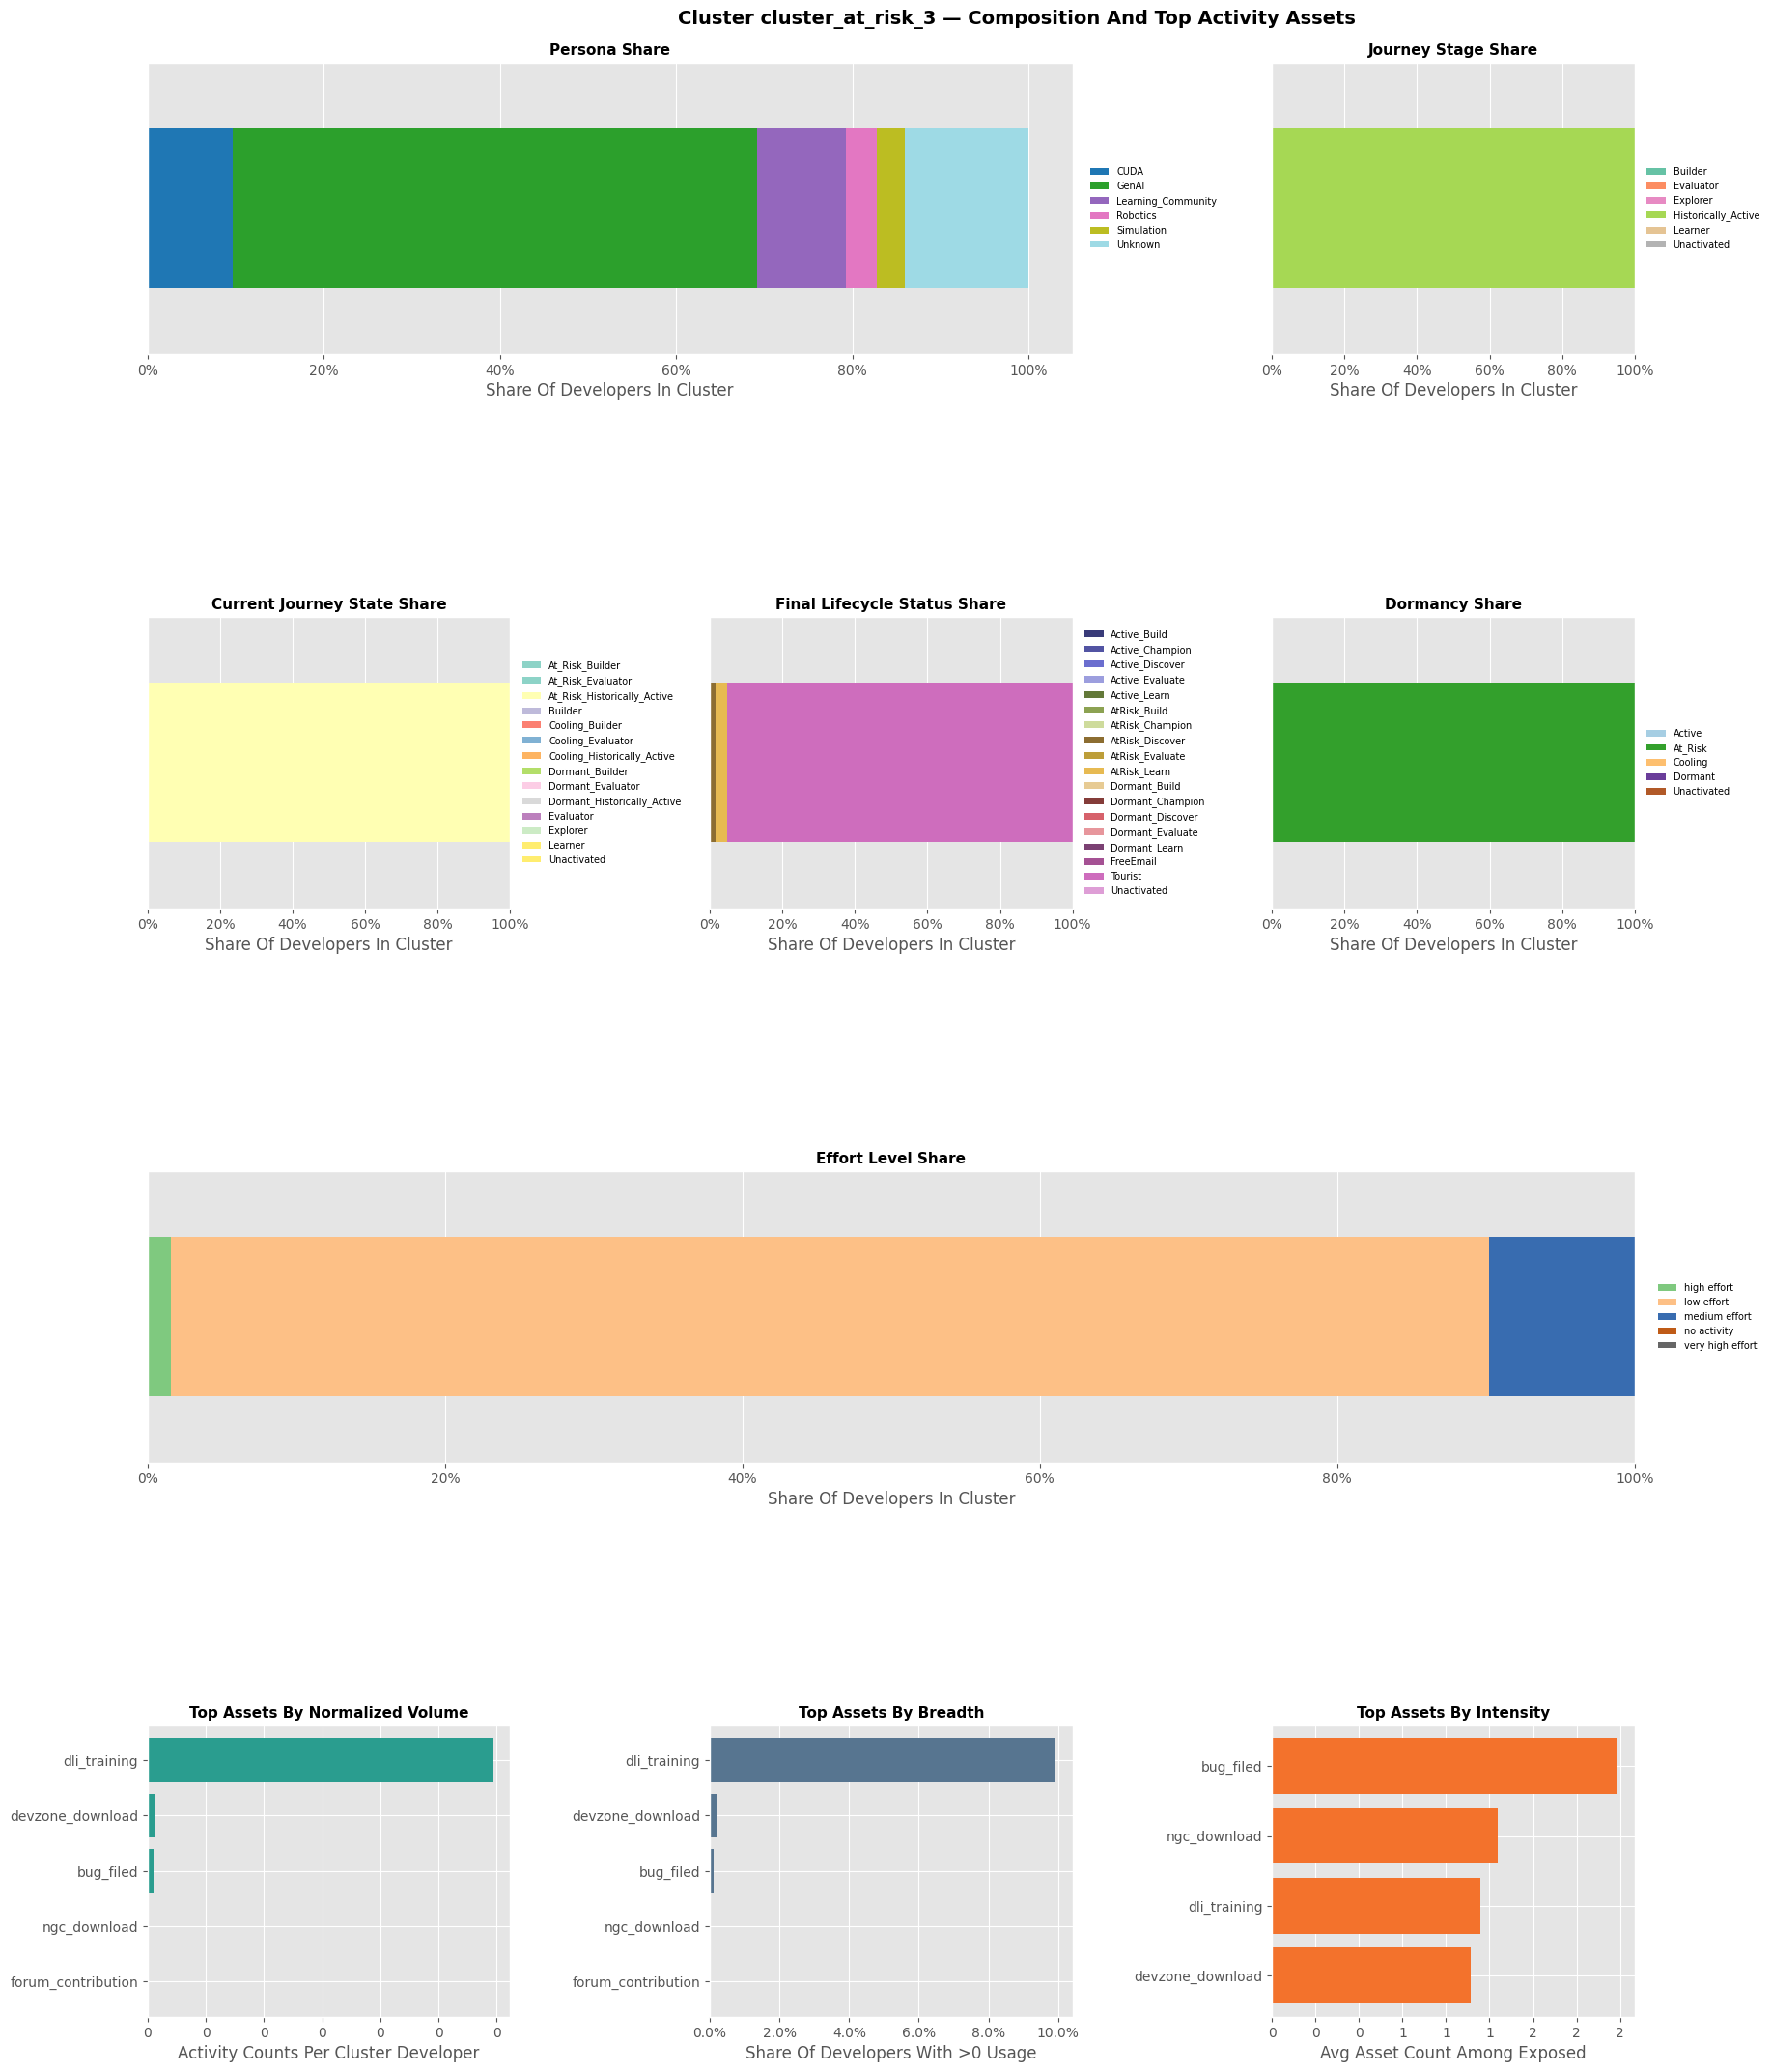

### Cluster: `cluster_active_5` (155,153 developers)

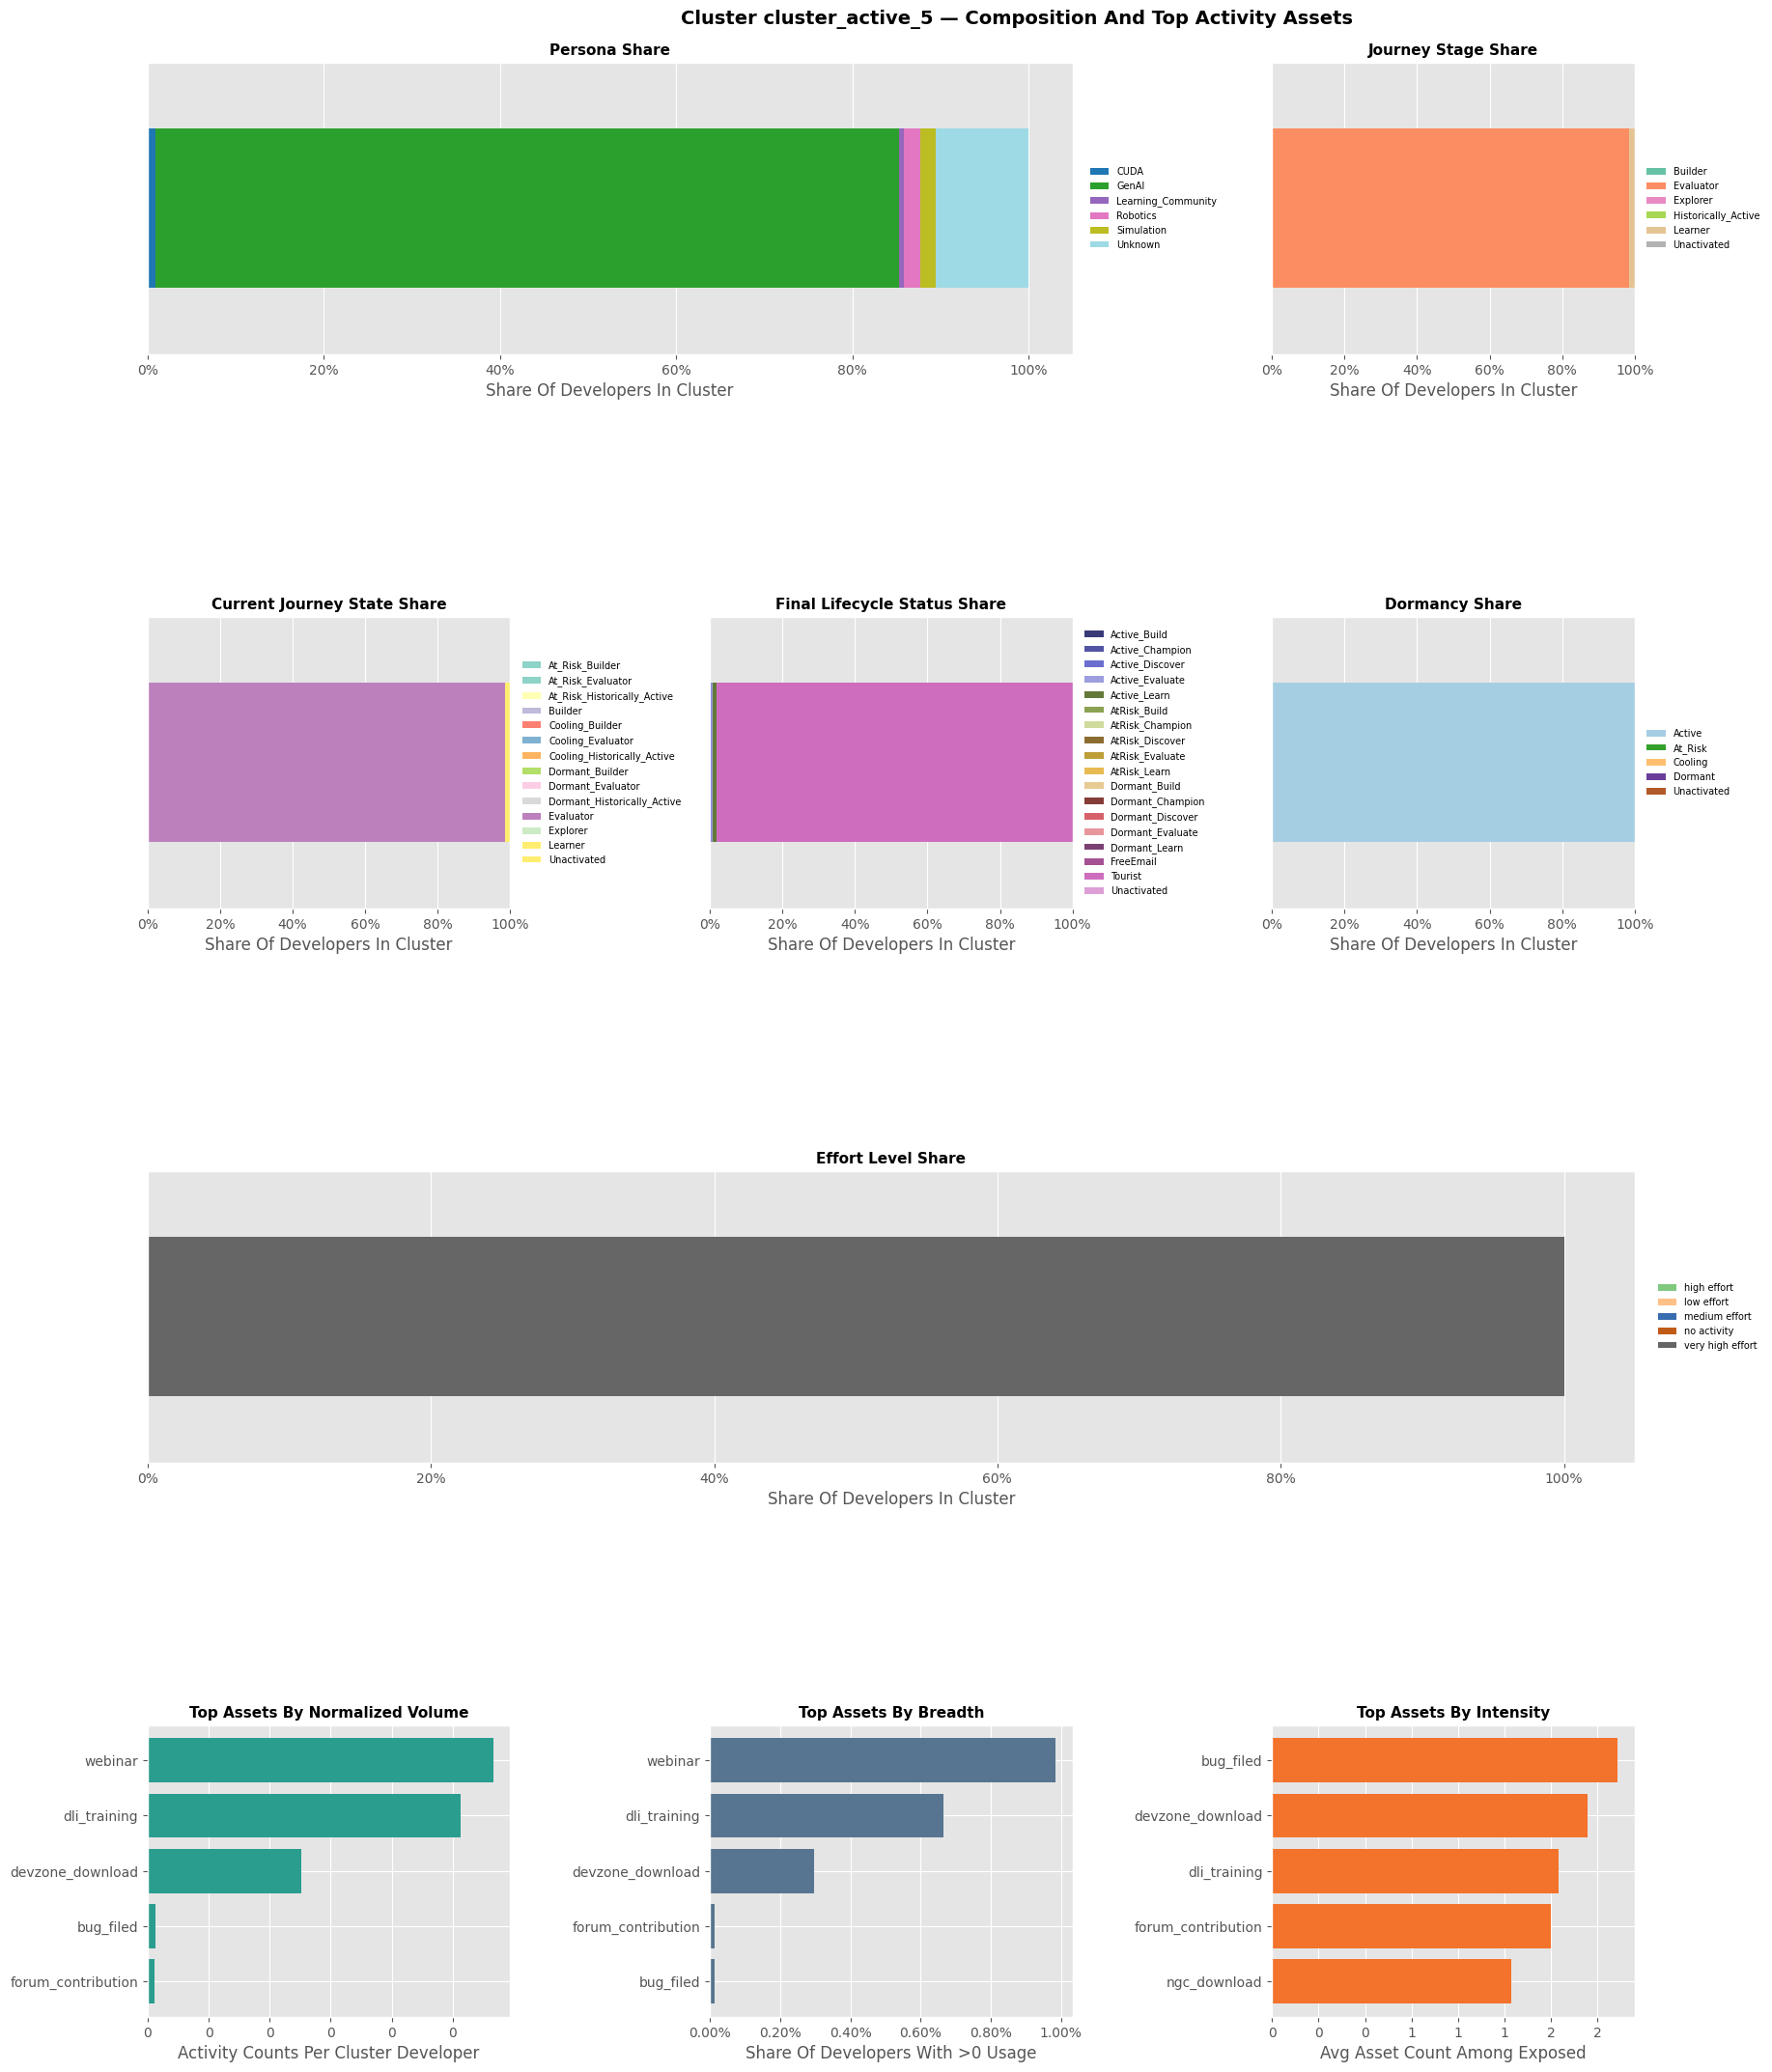

### Cluster: `cluster_at_risk_1` (145,076 developers)

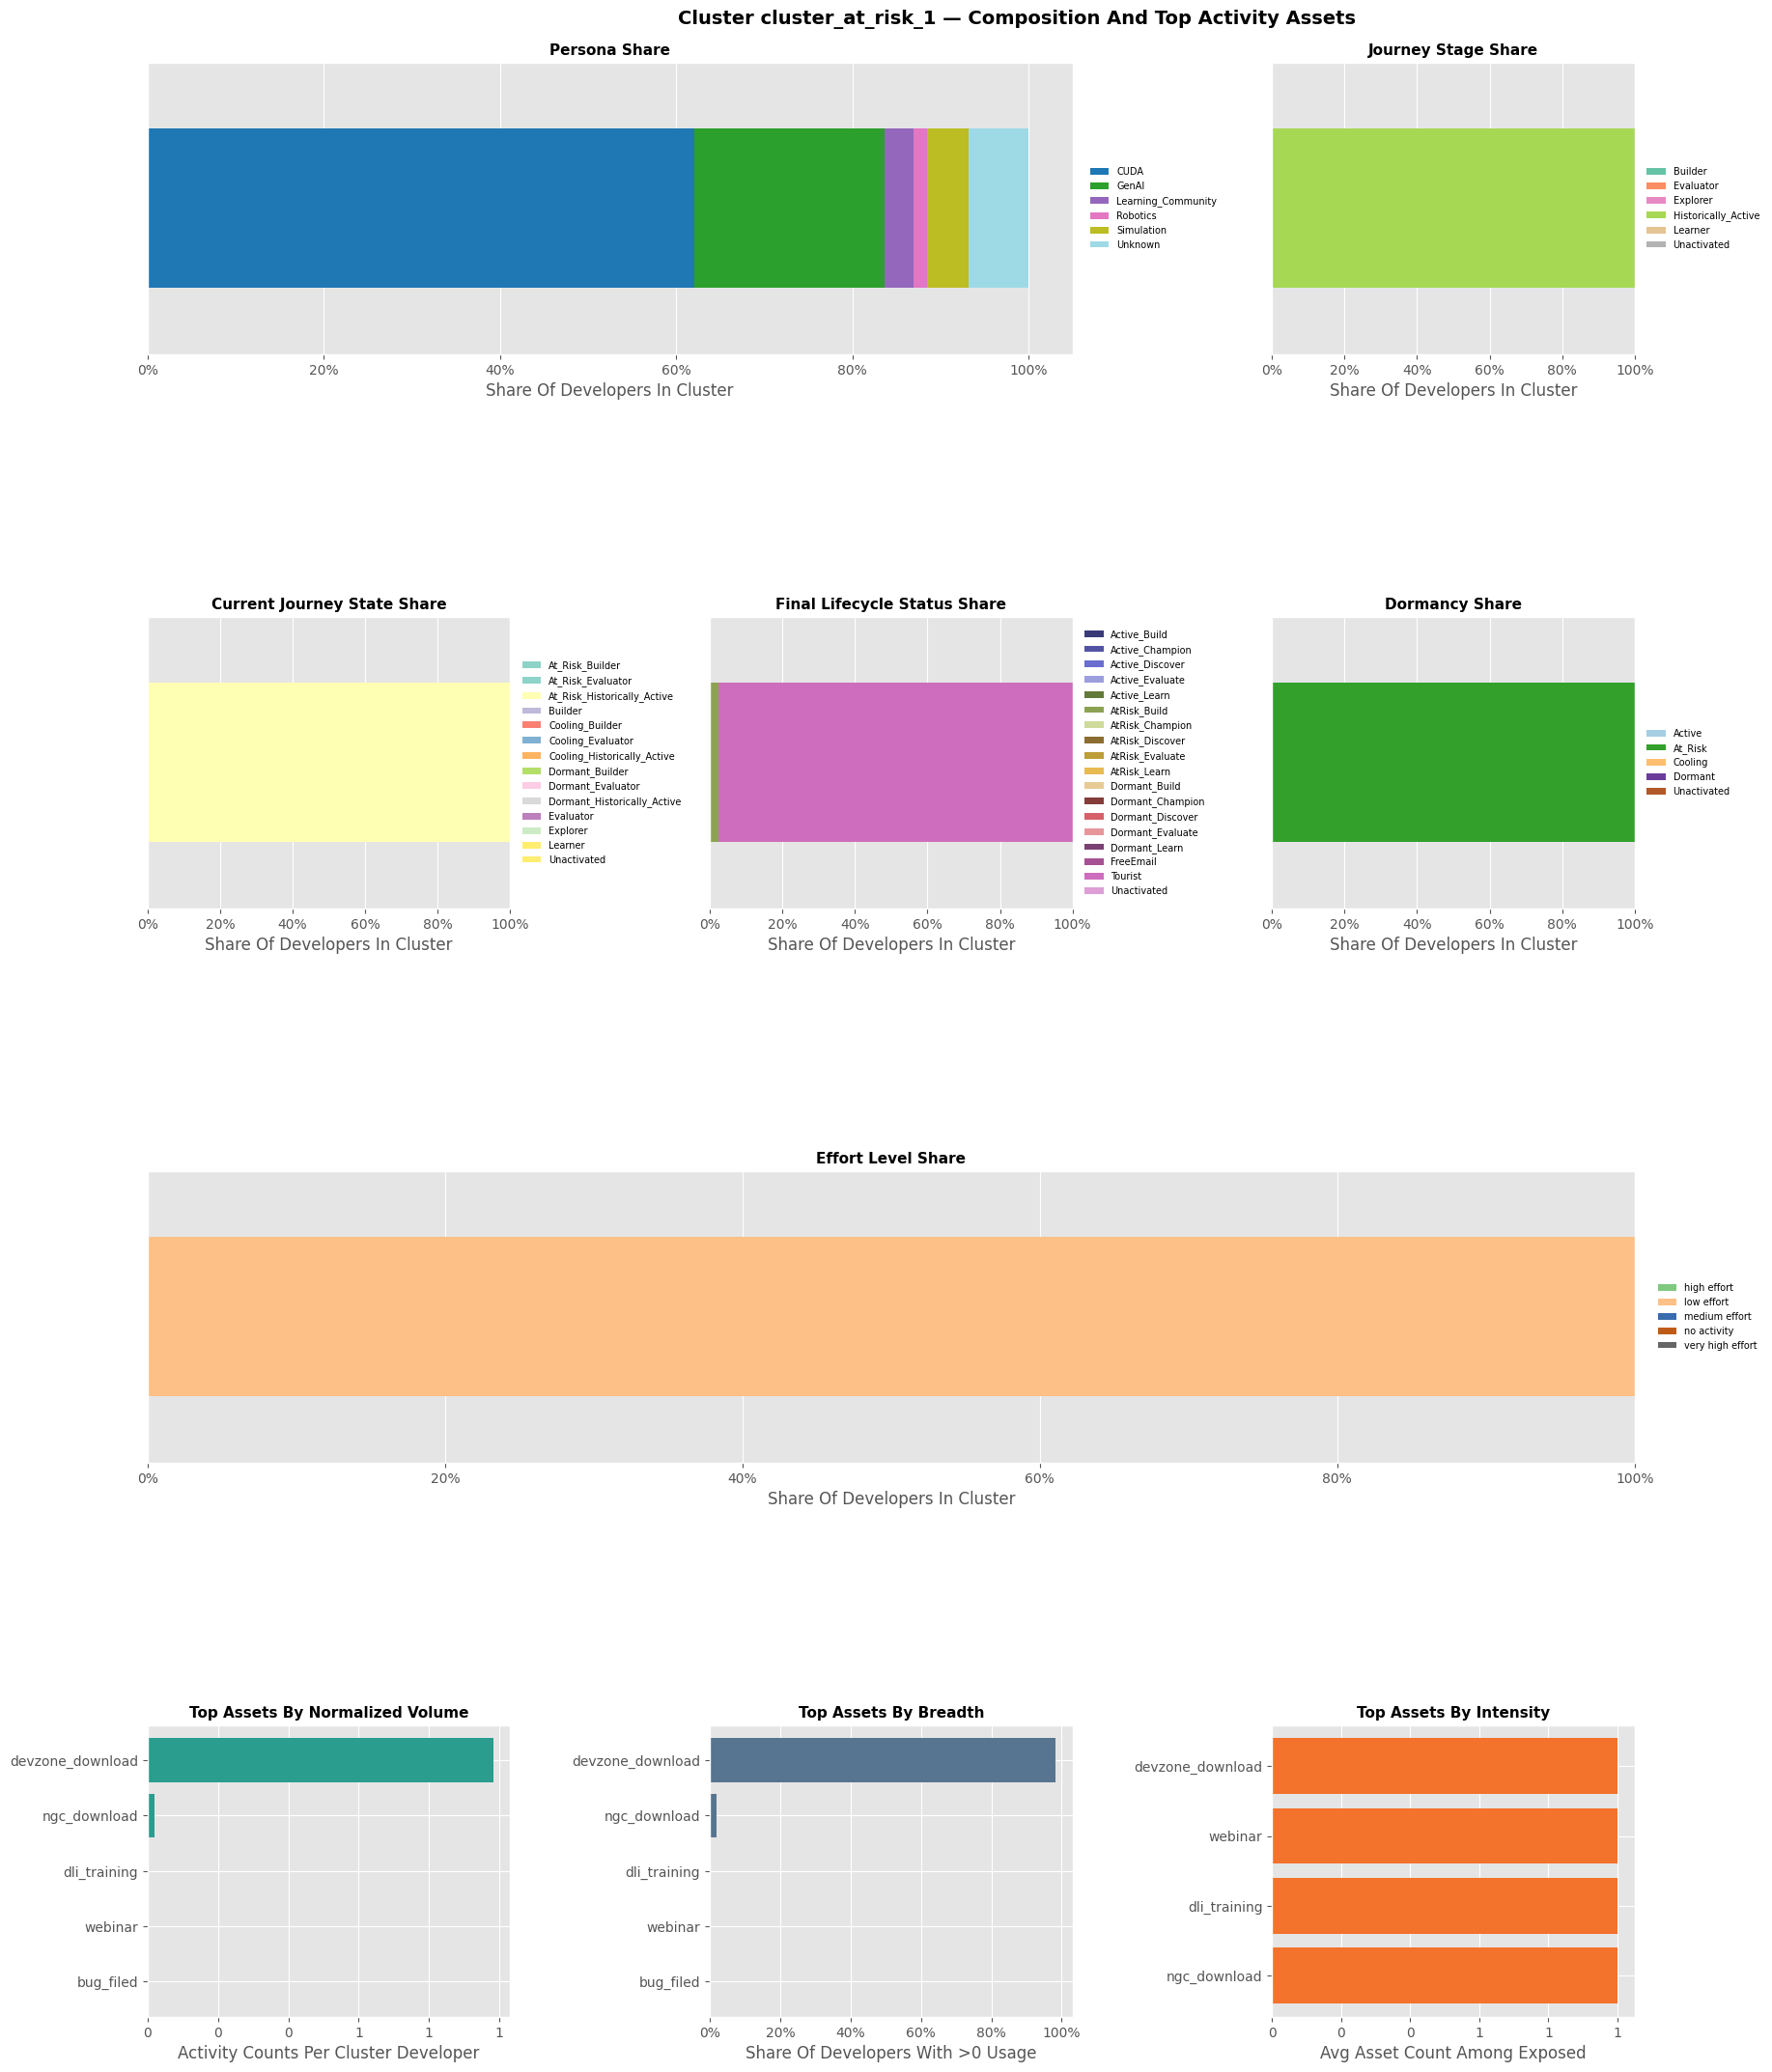

### Cluster: `cluster_at_risk_4` (119,117 developers)

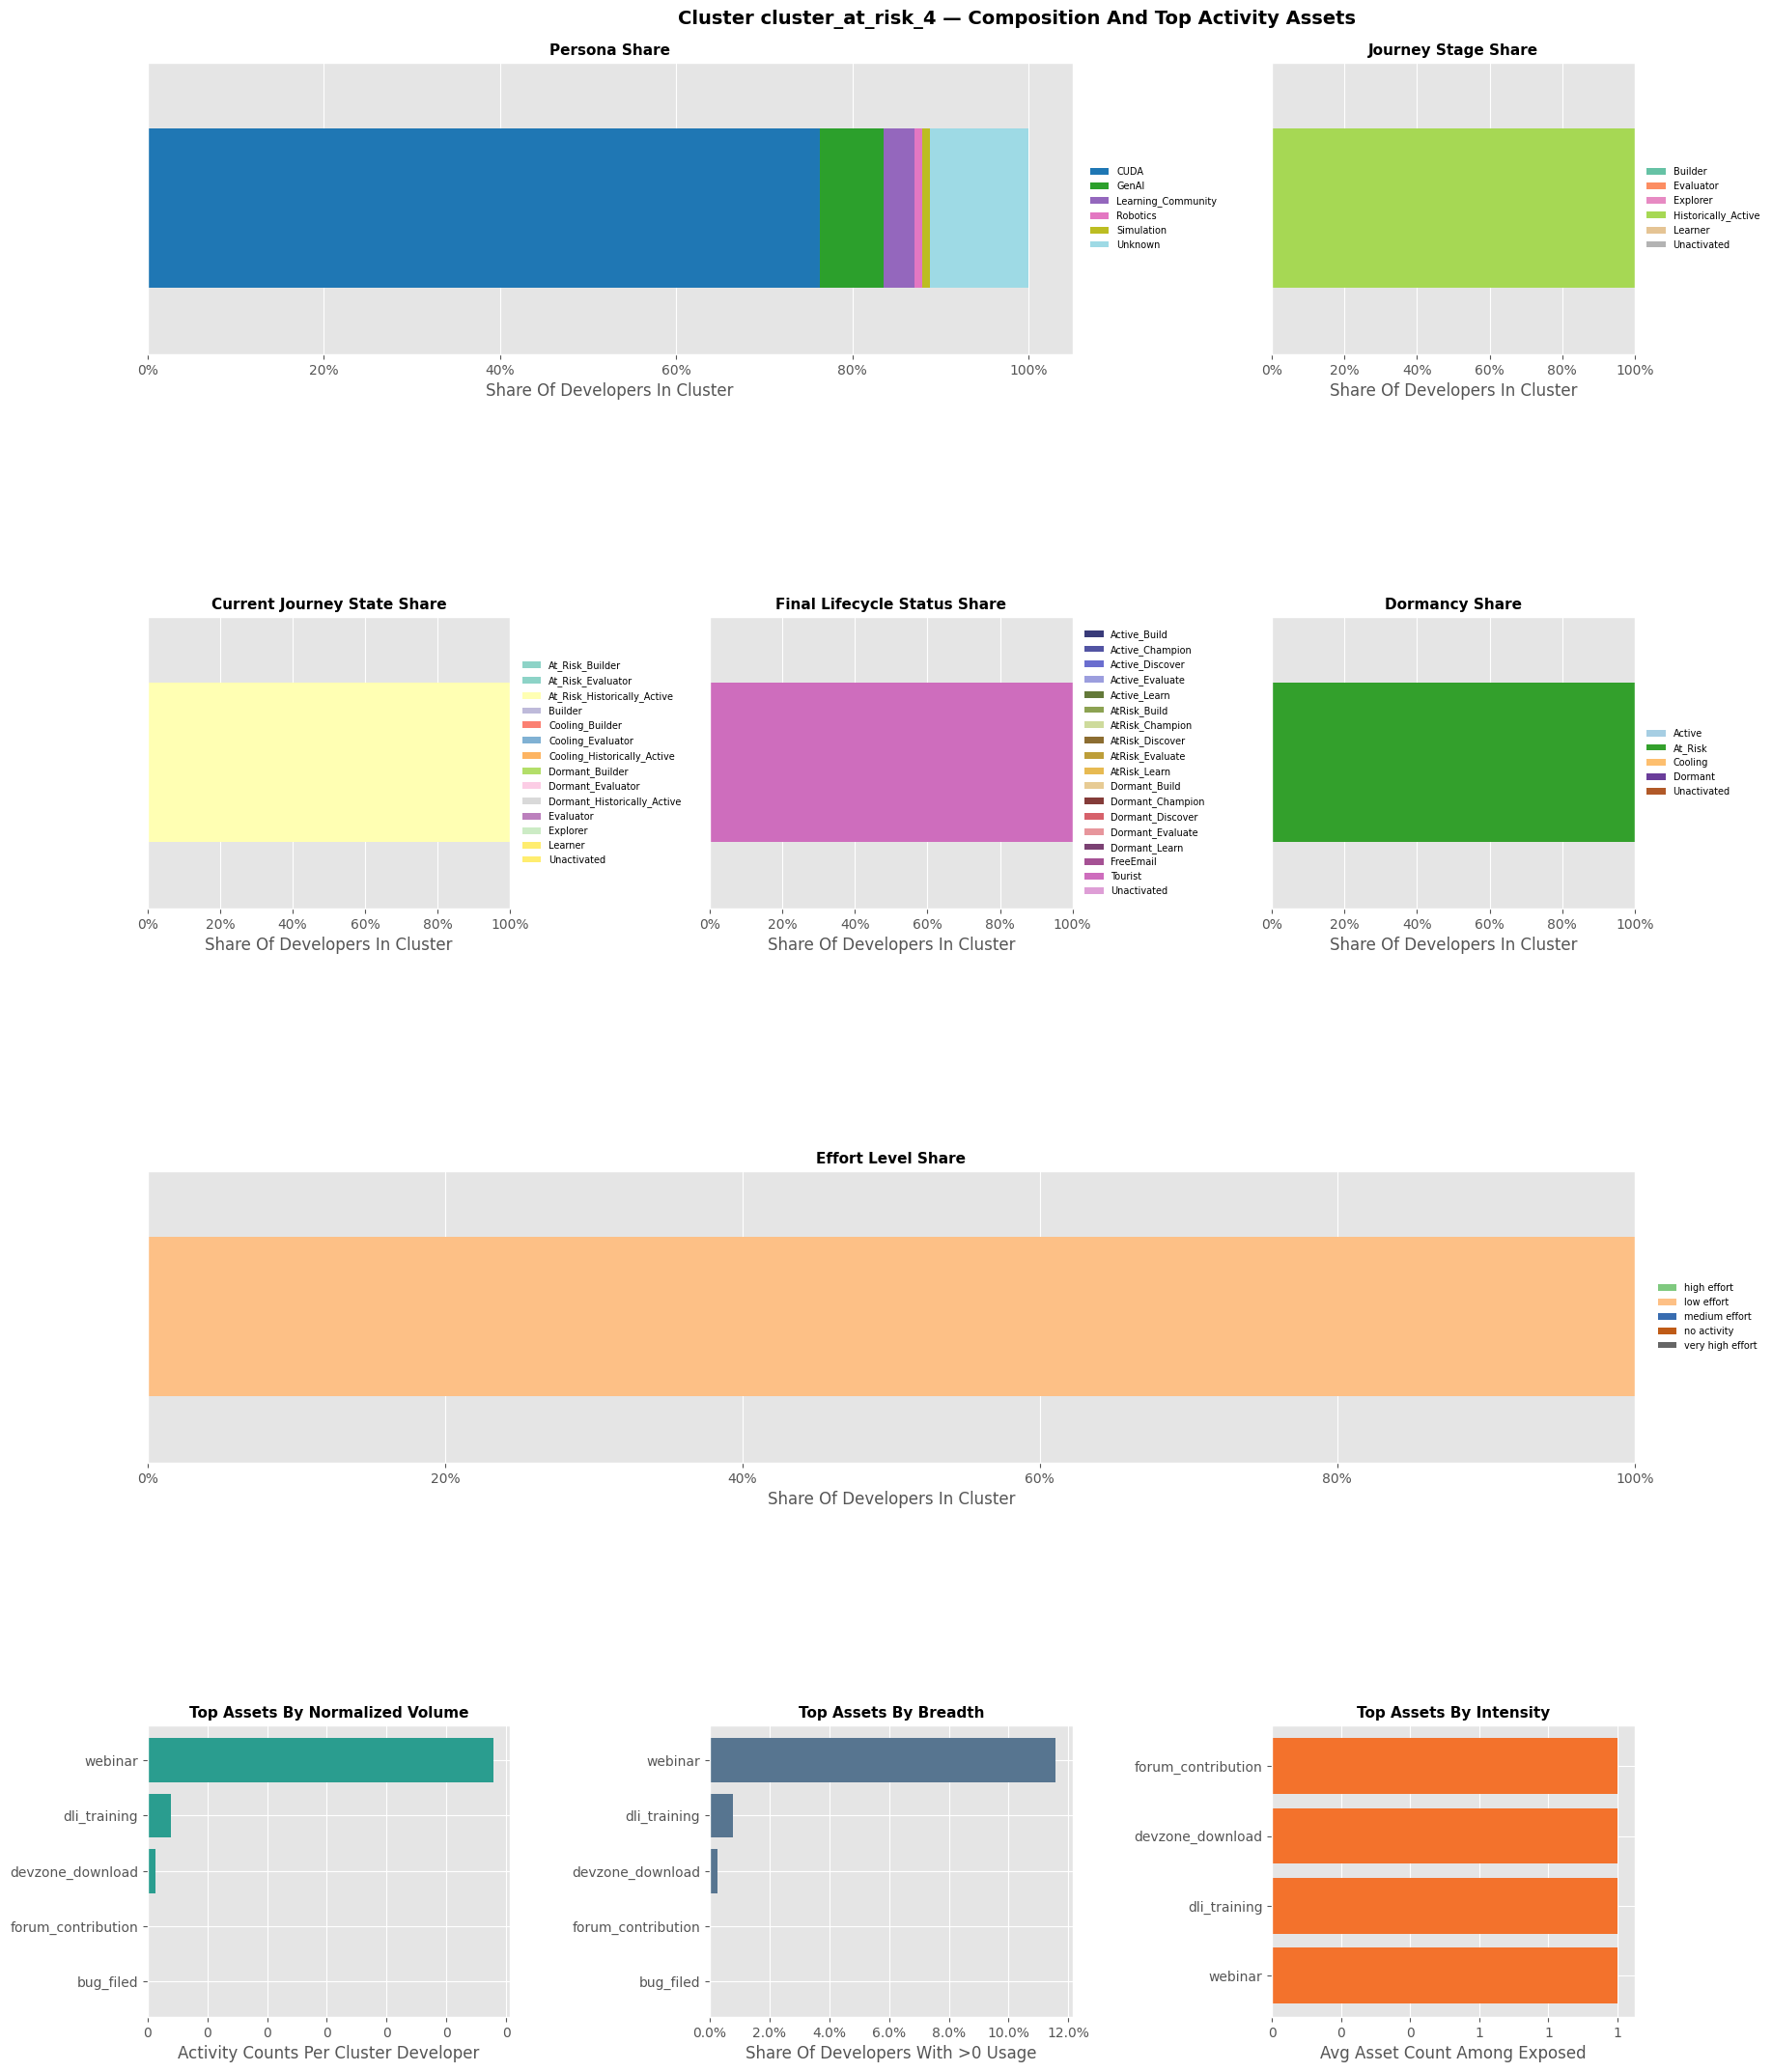

### Cluster: `cluster_active_noise` (105,812 developers)

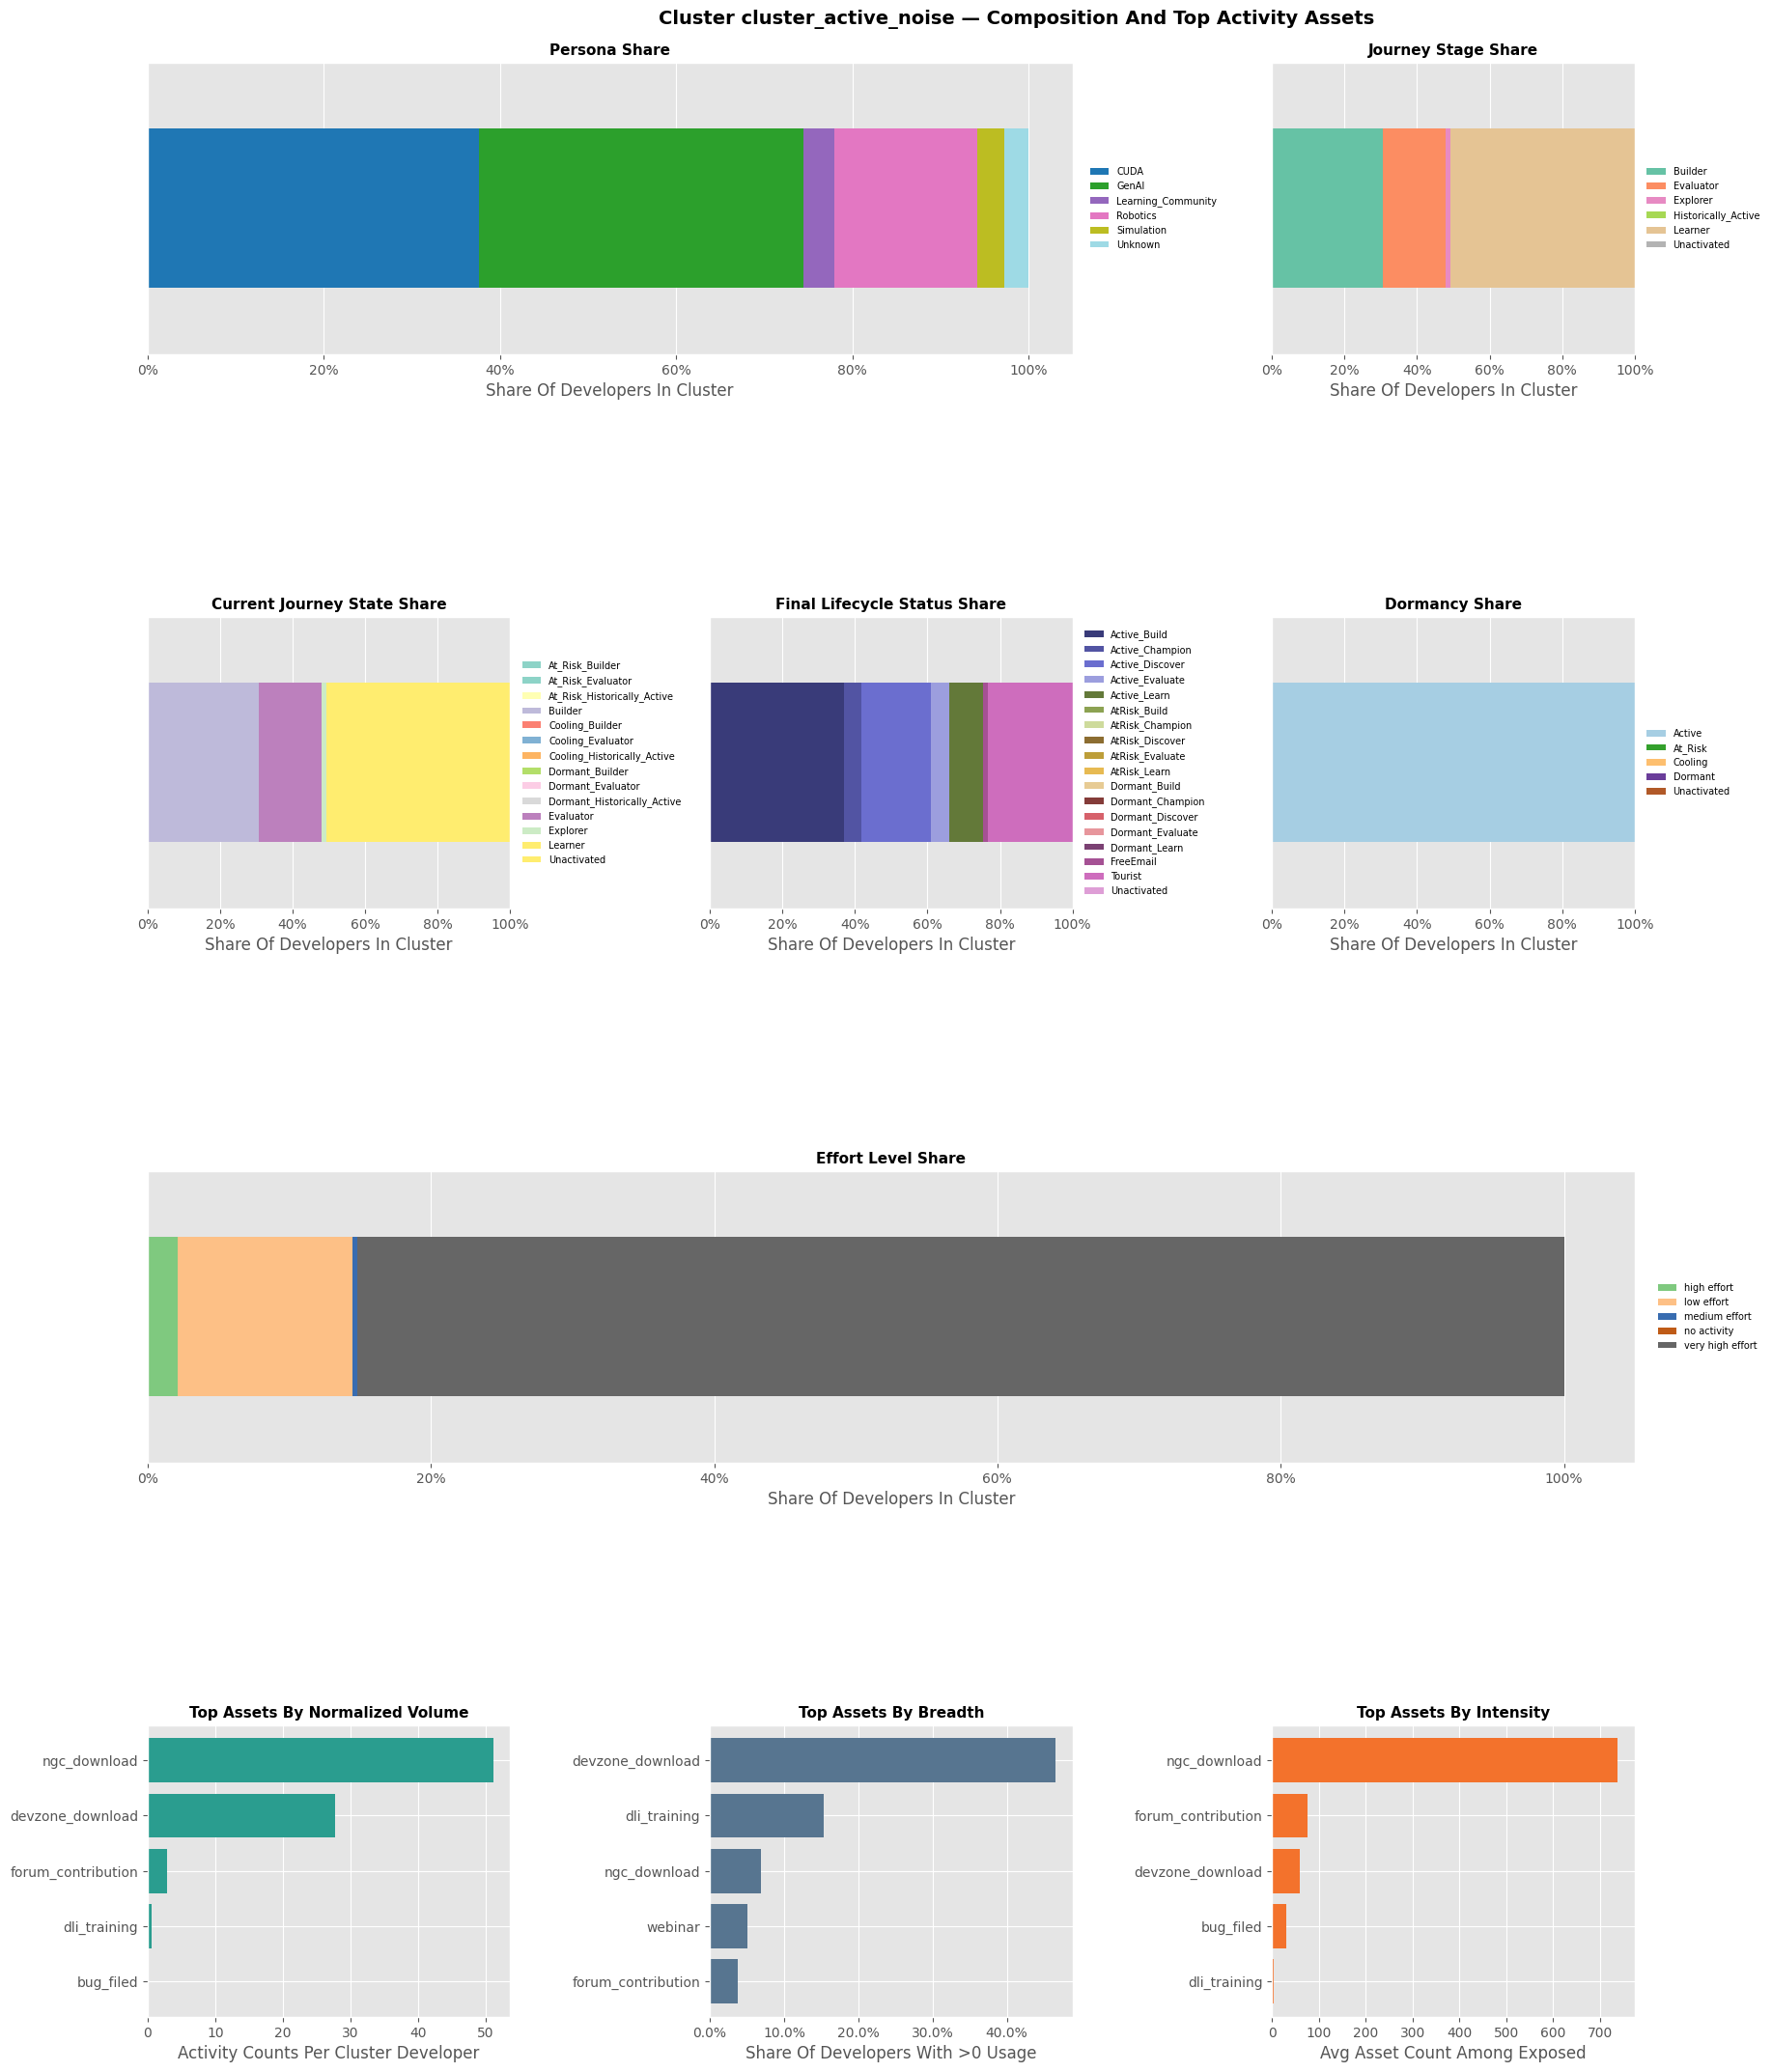

### Cluster: `cluster_at_risk_noise` (96,700 developers)

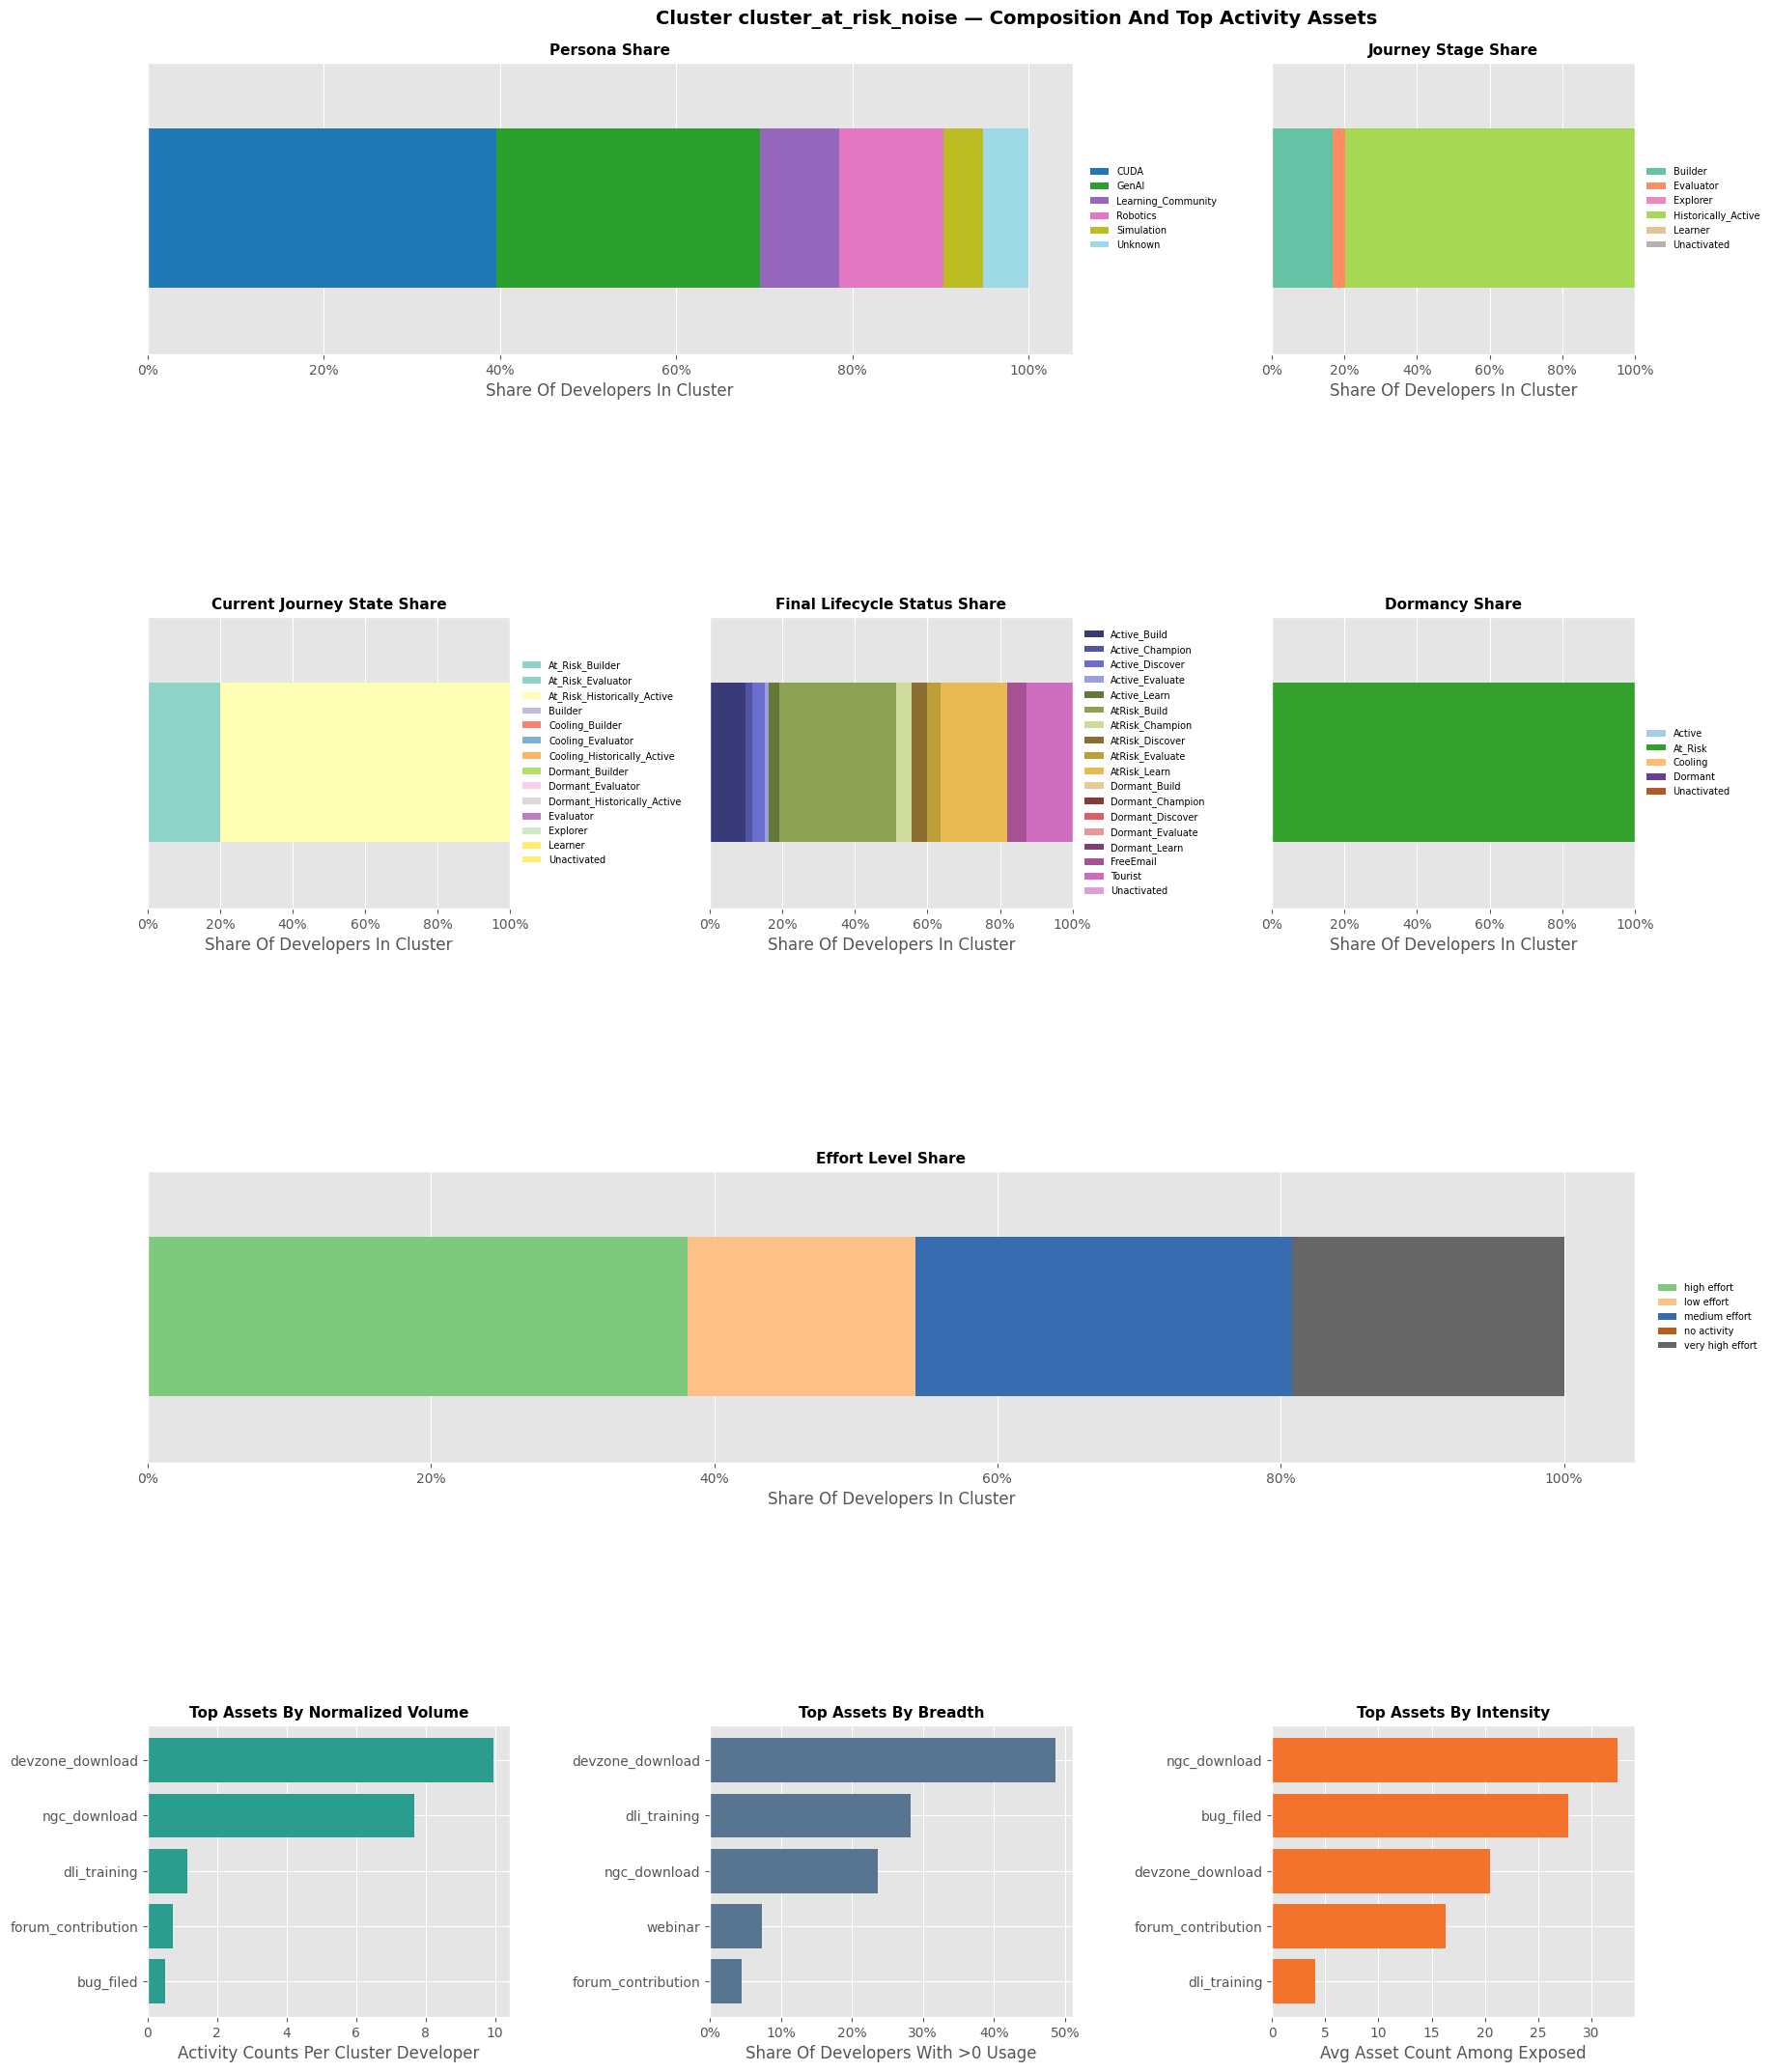

### Cluster: `cluster_cooling_1` (83,580 developers)

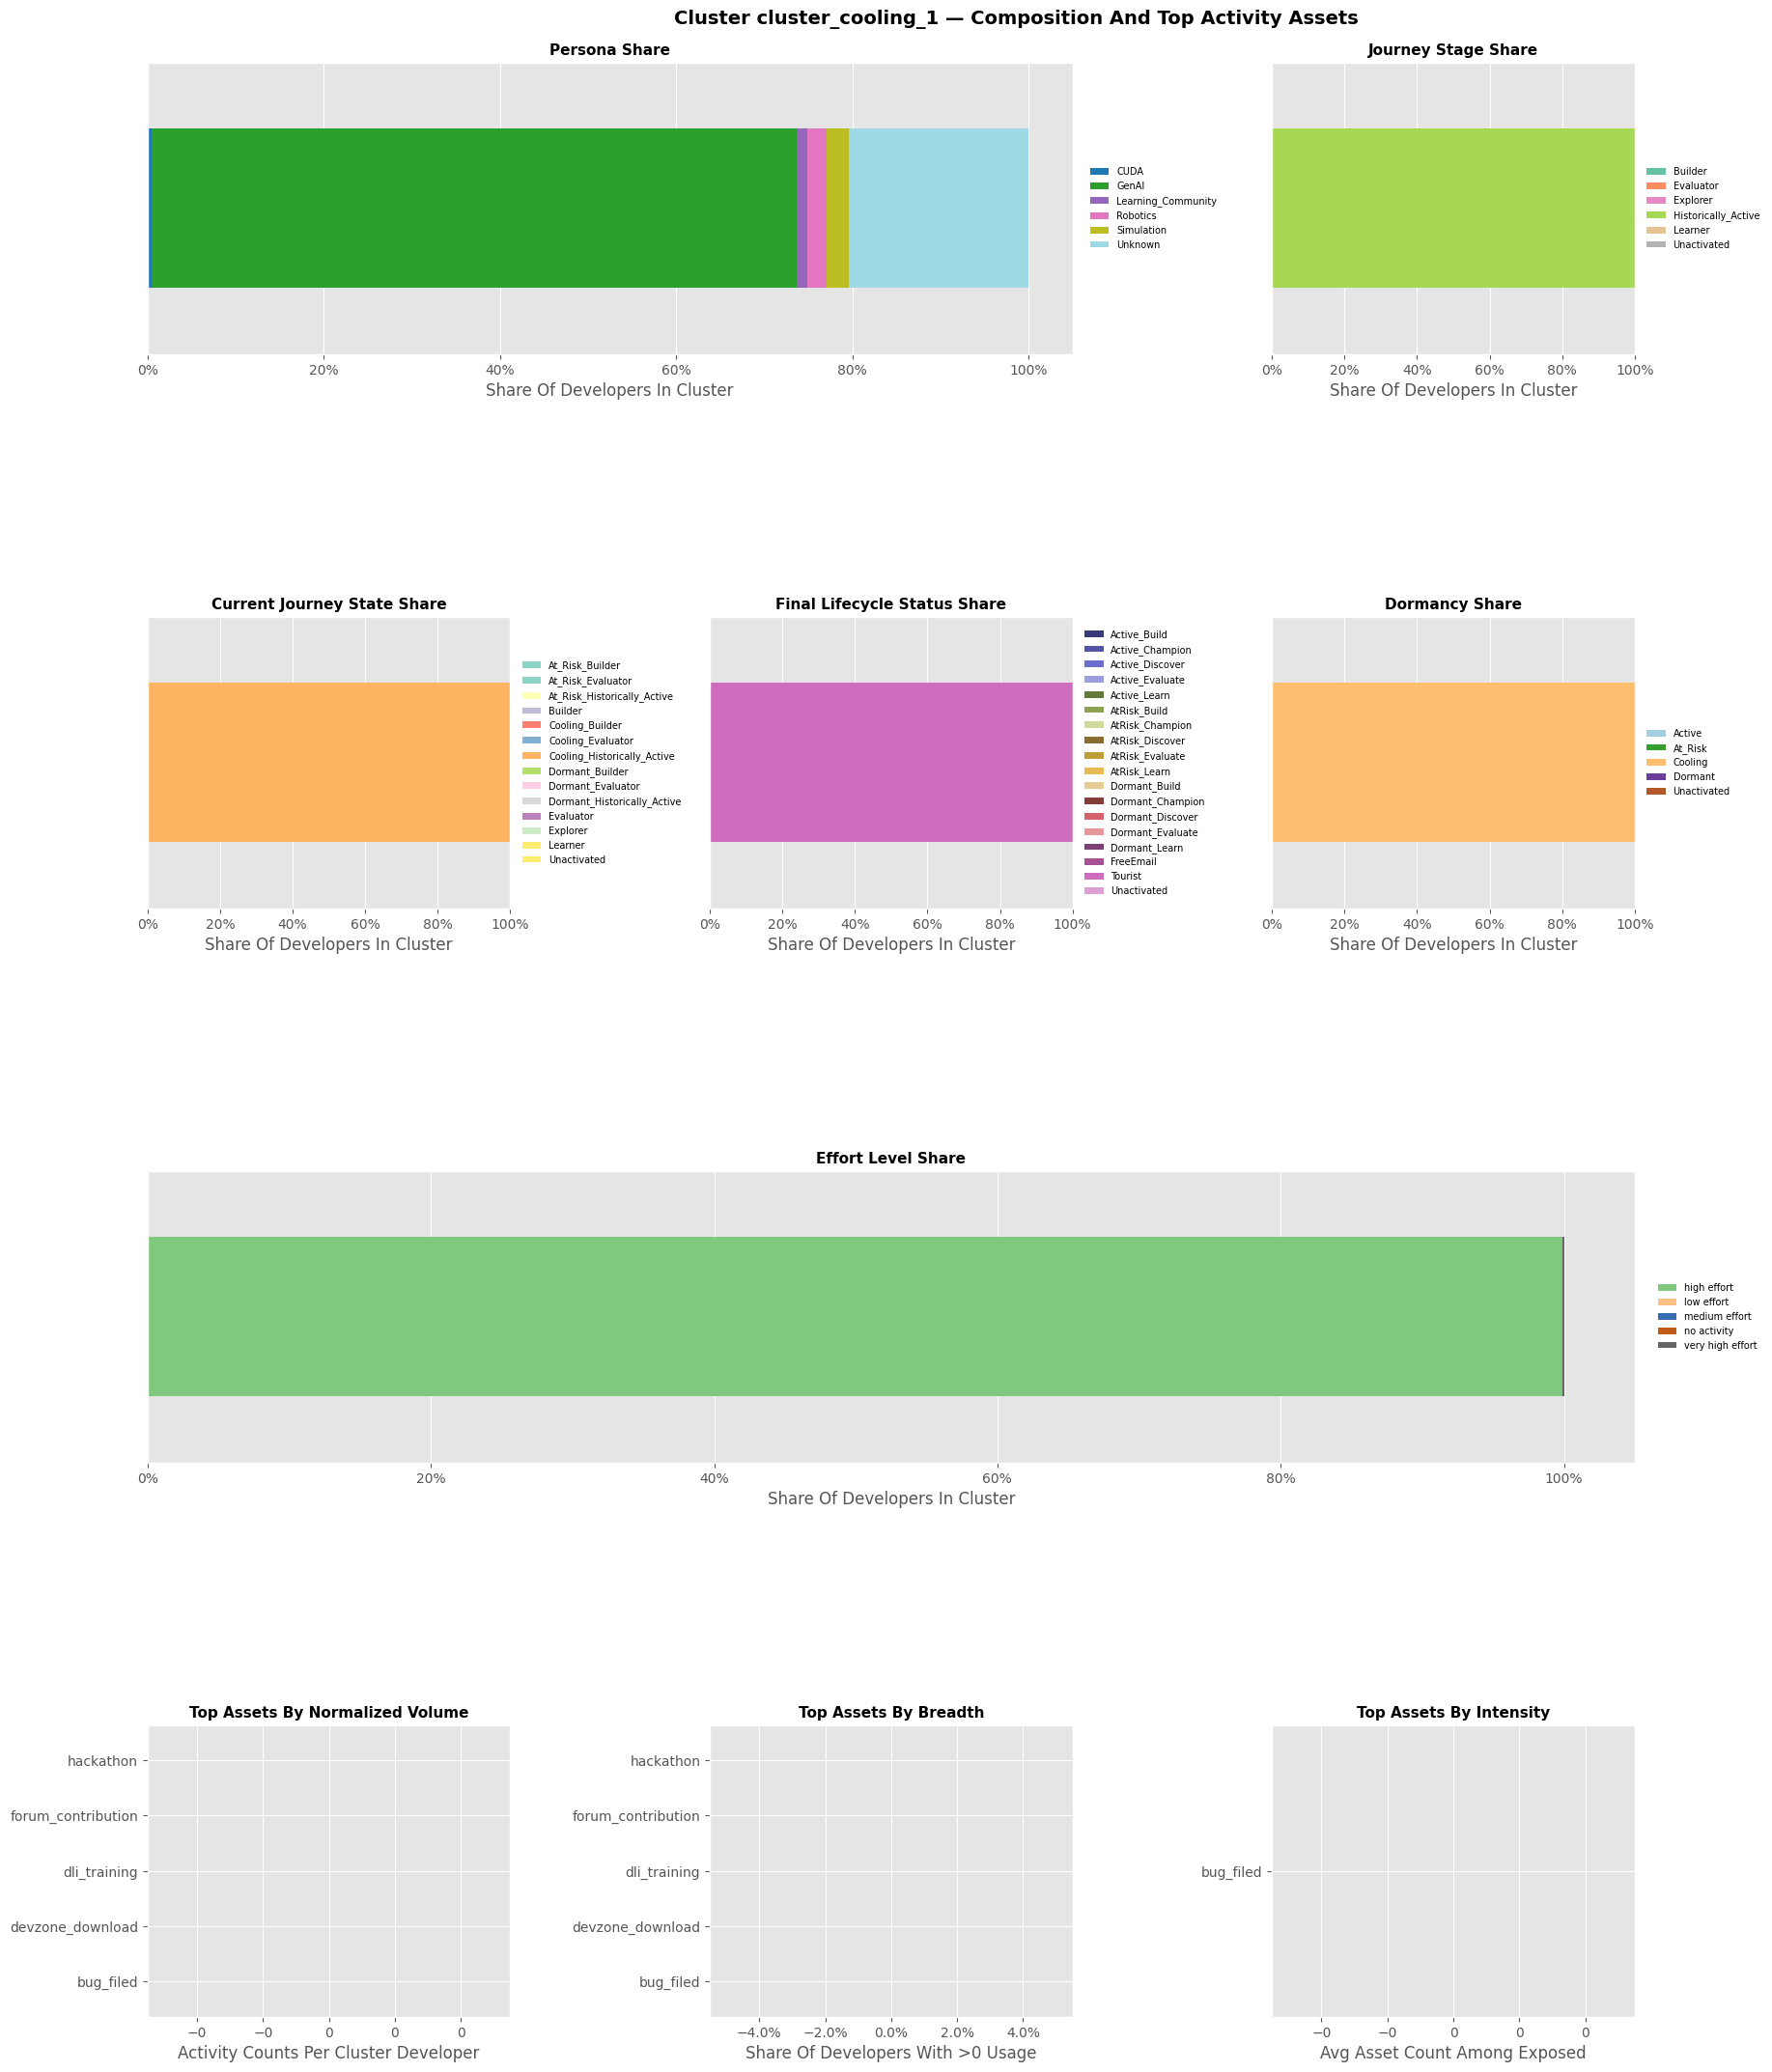

### Cluster: `cluster_cooling_noise` (81,570 developers)

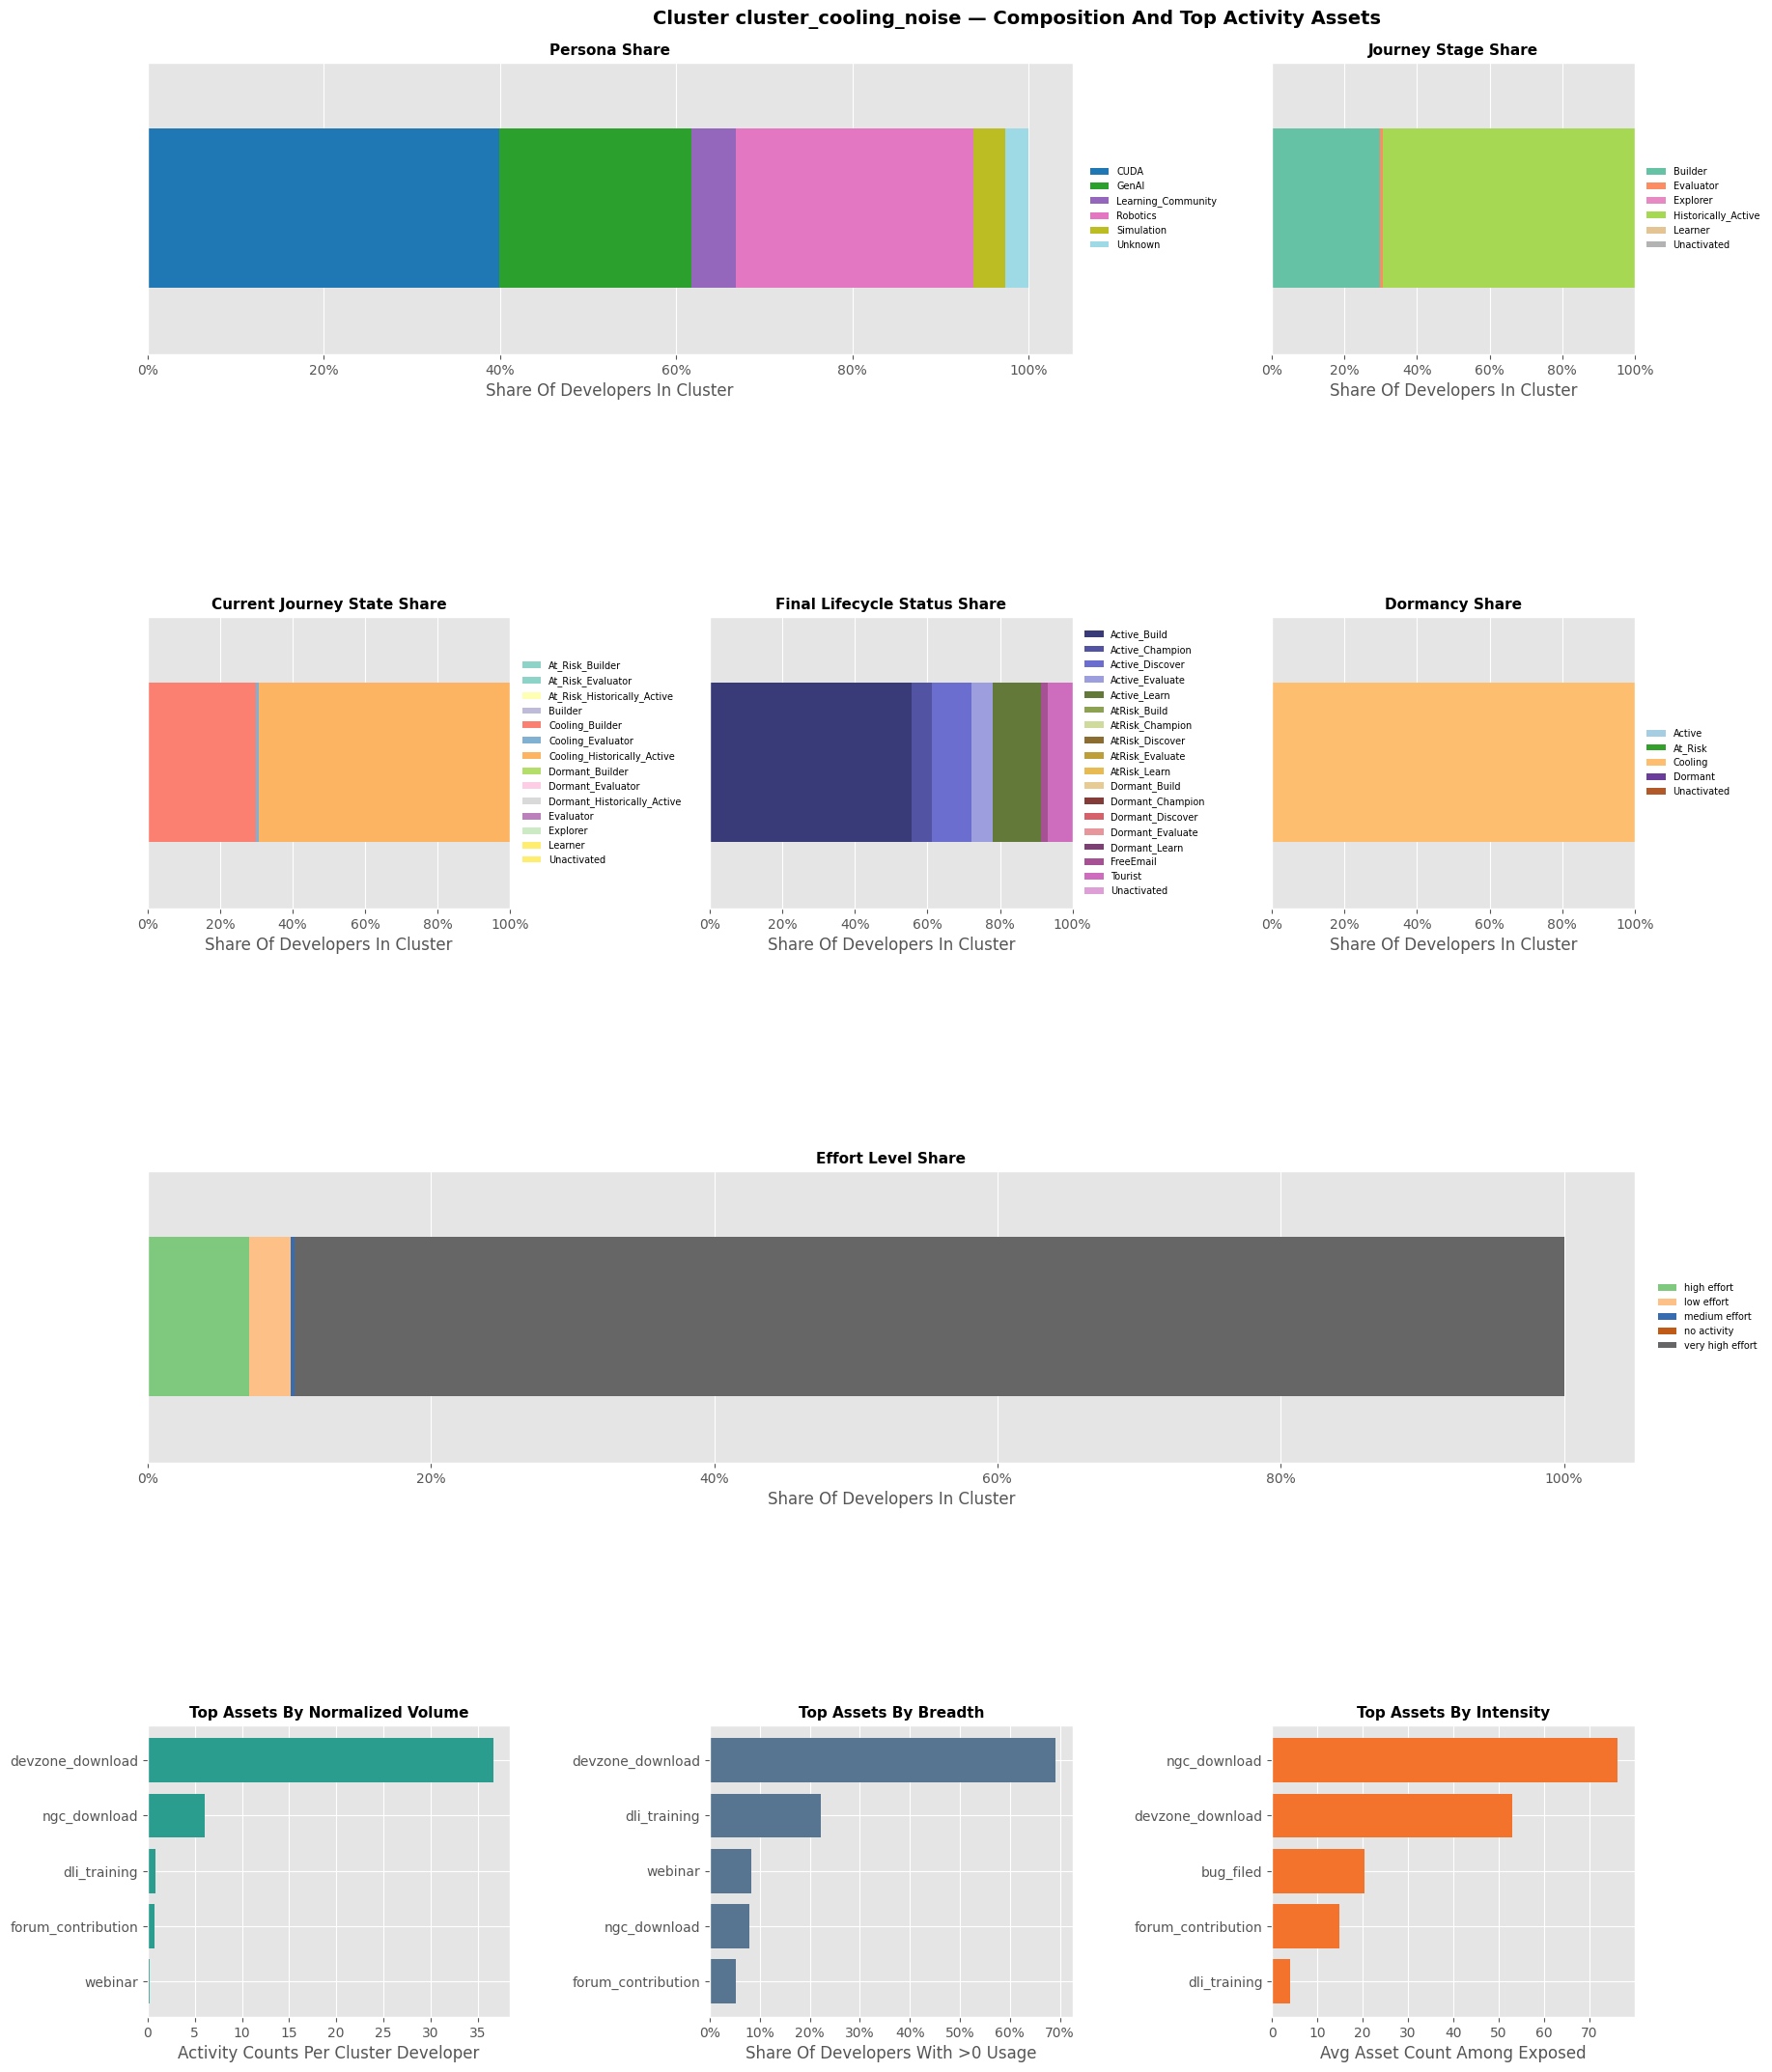

### Cluster: `cluster_active_2` (66,664 developers)

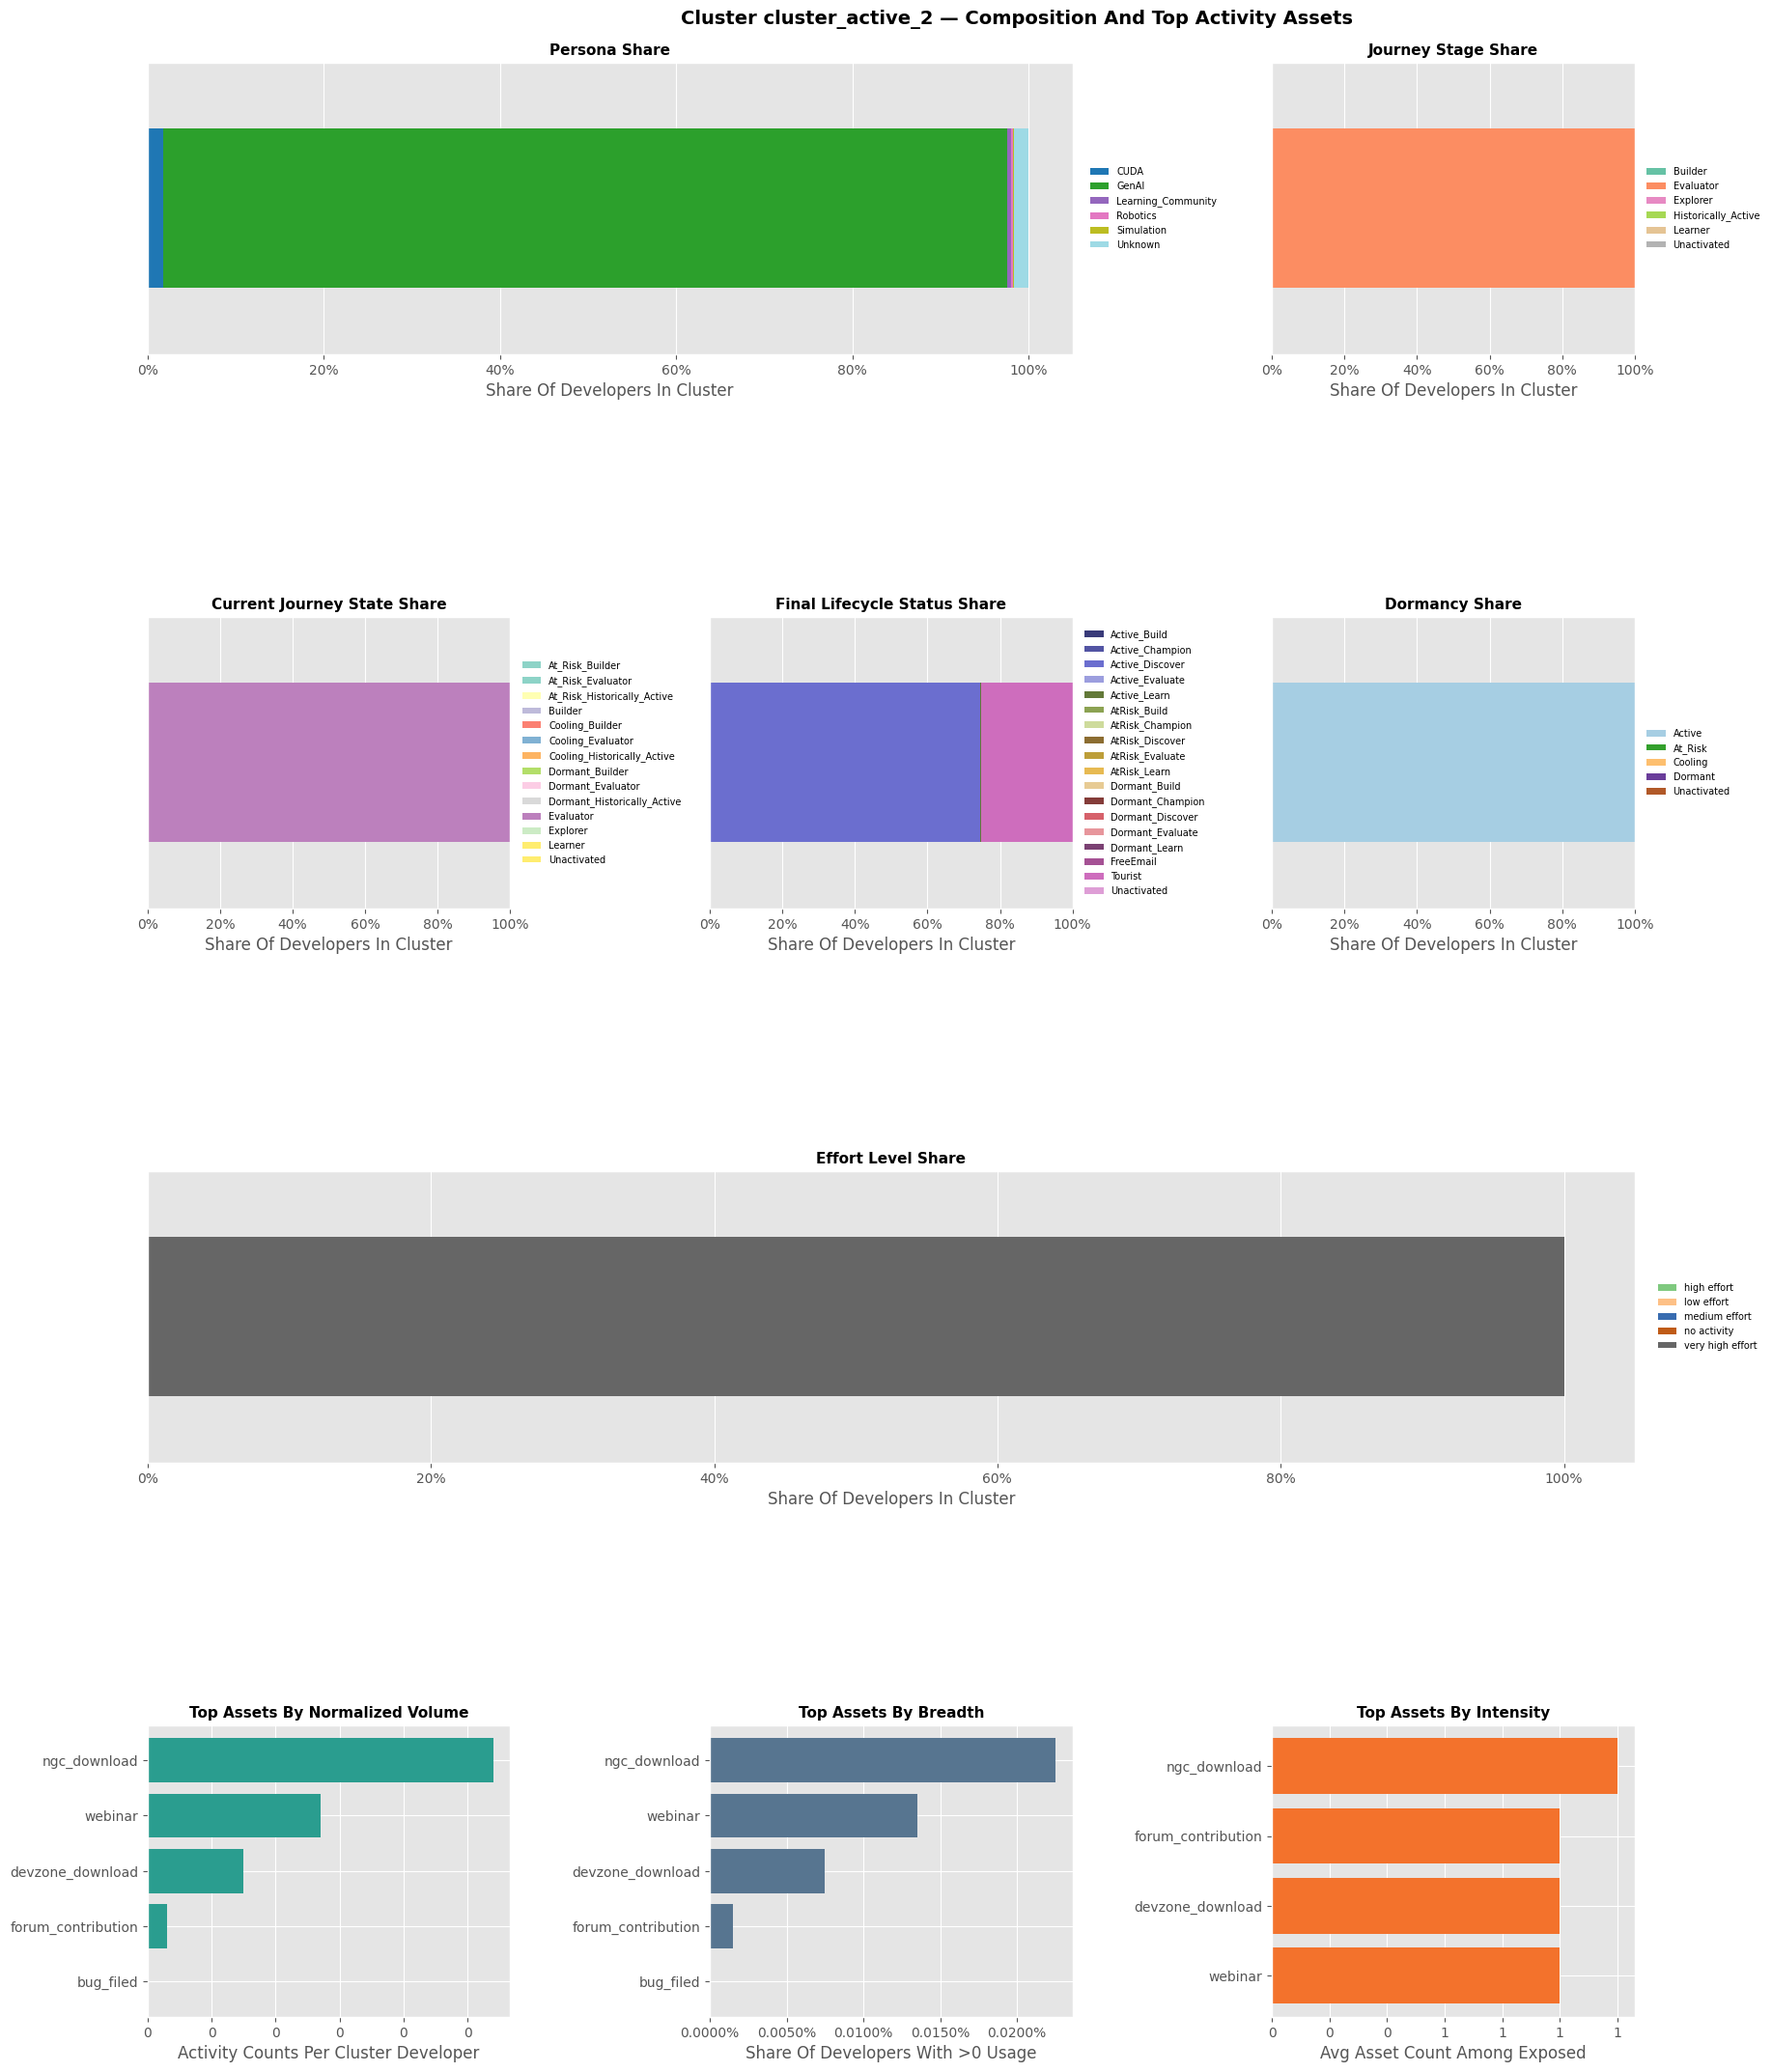

### Cluster: `cluster_cooling_6` (56,797 developers)

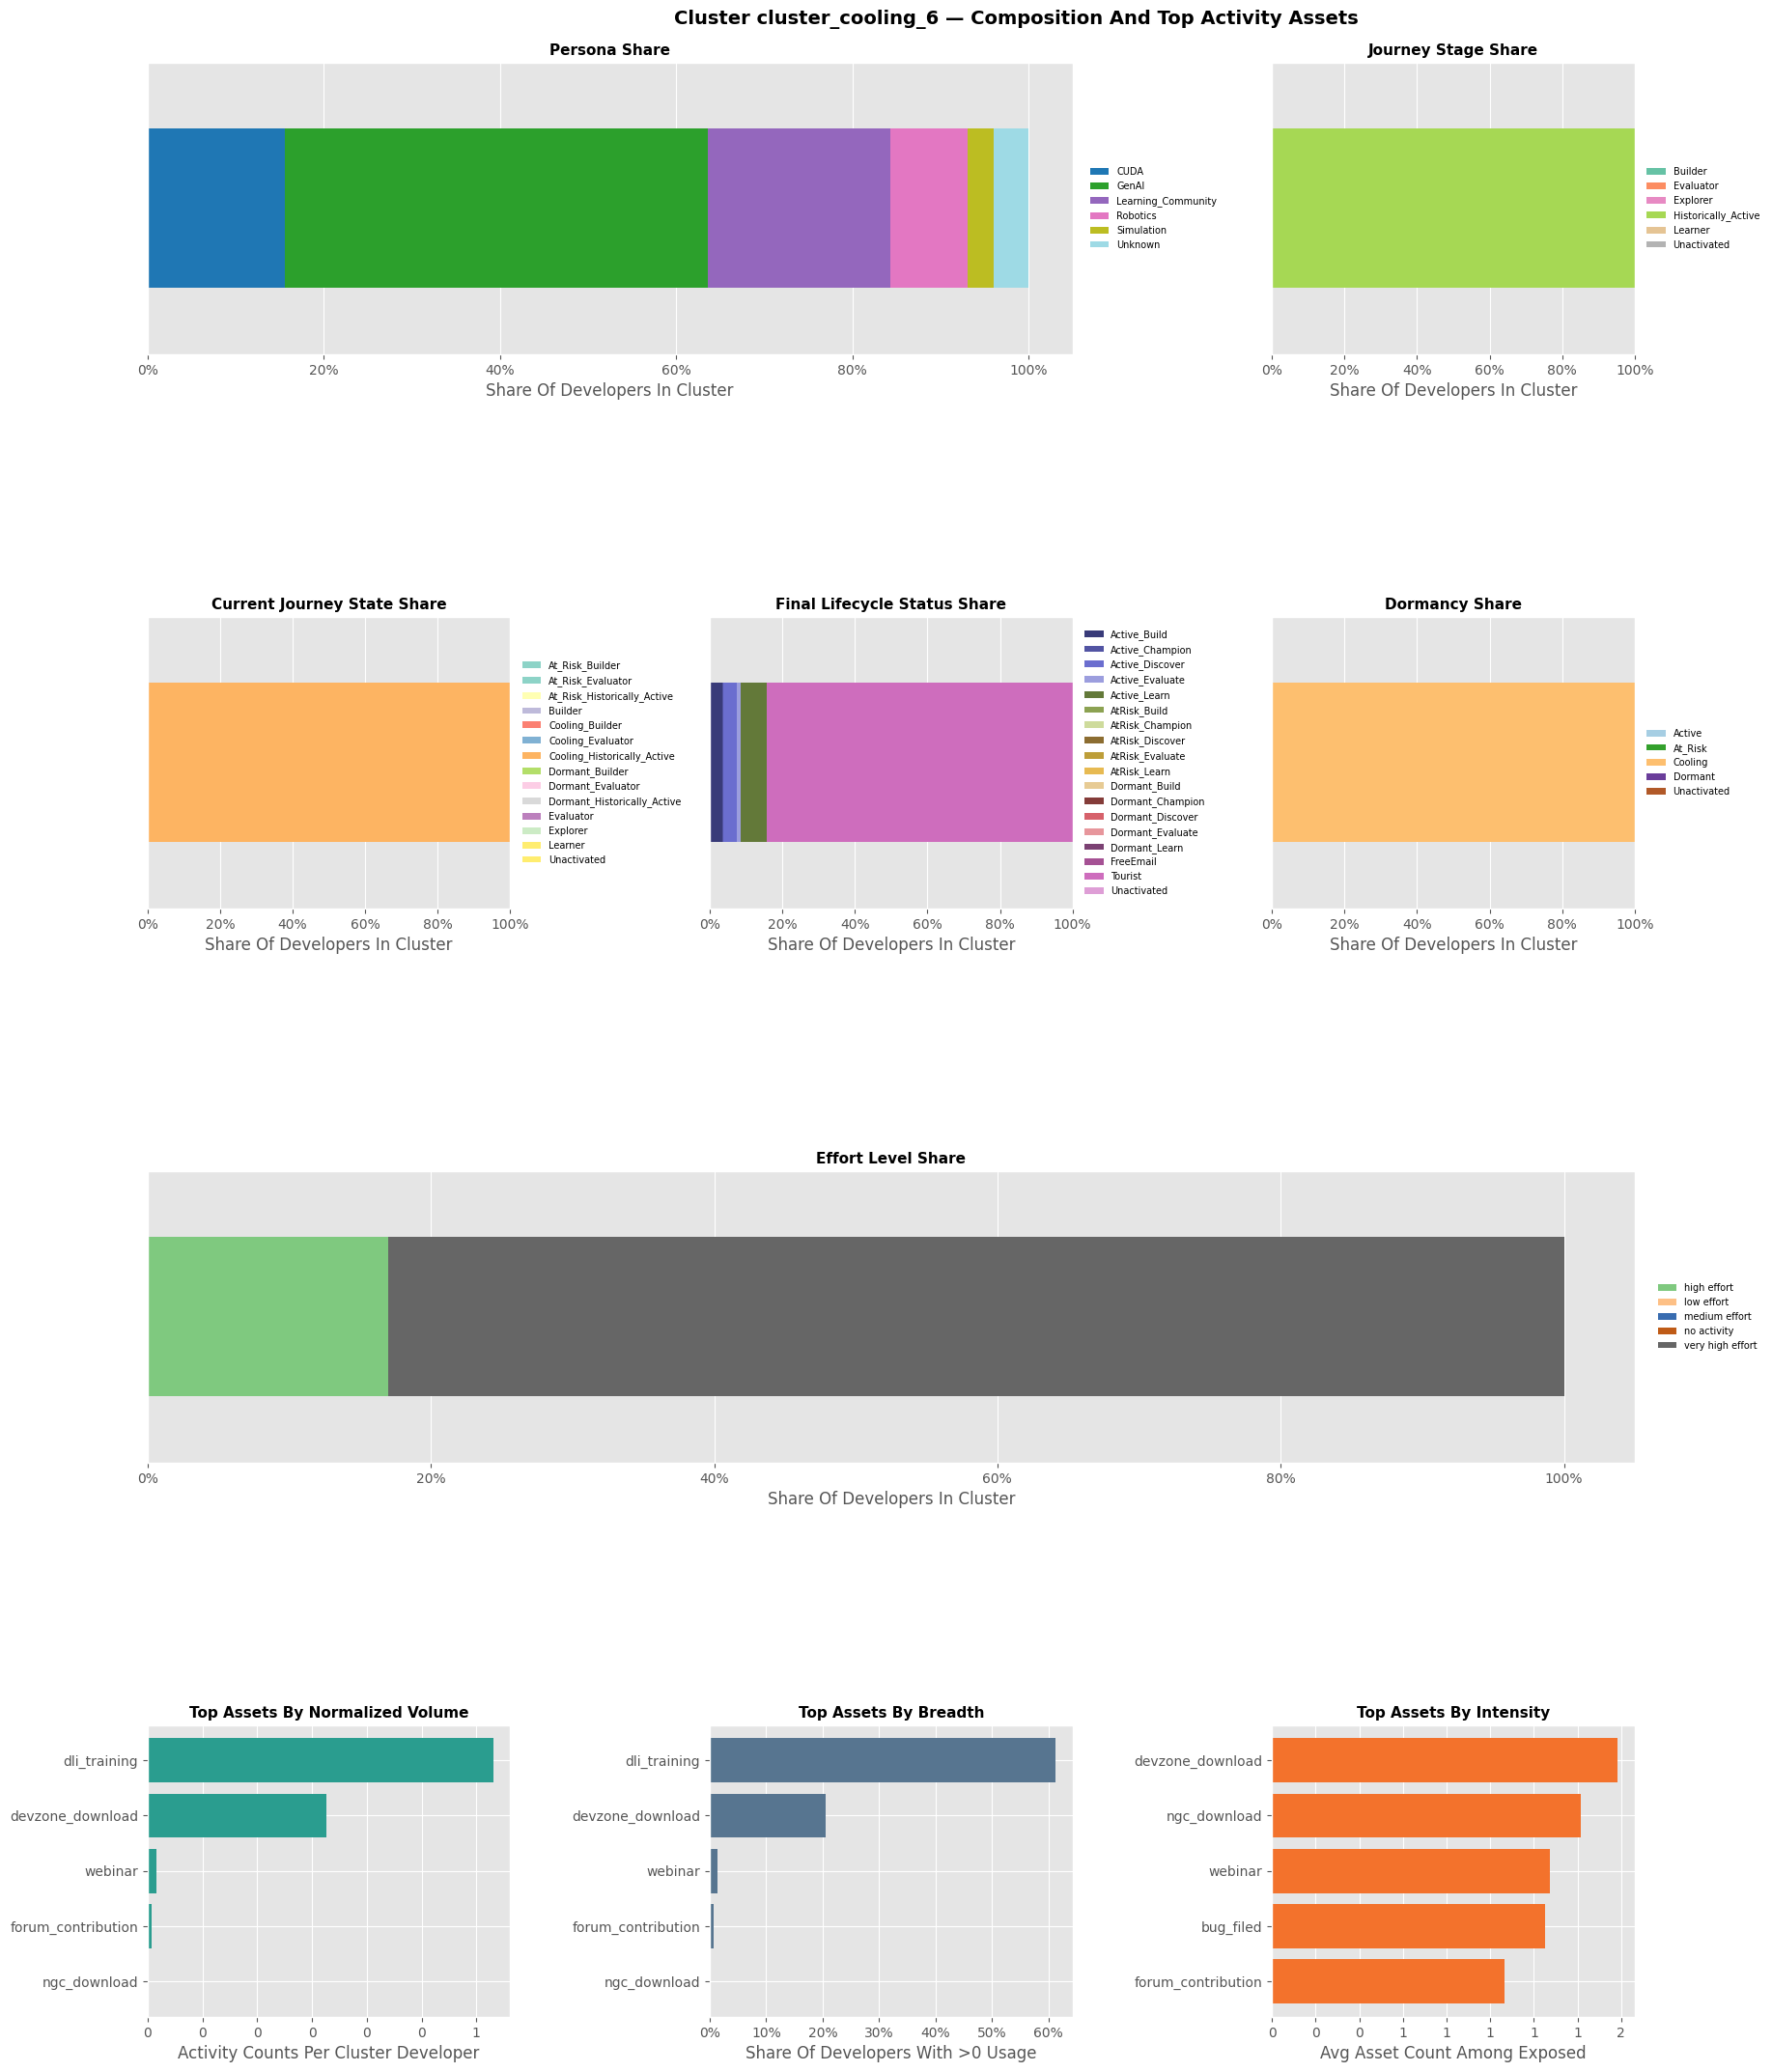

### Cluster: `cluster_cooling_4` (35,406 developers)

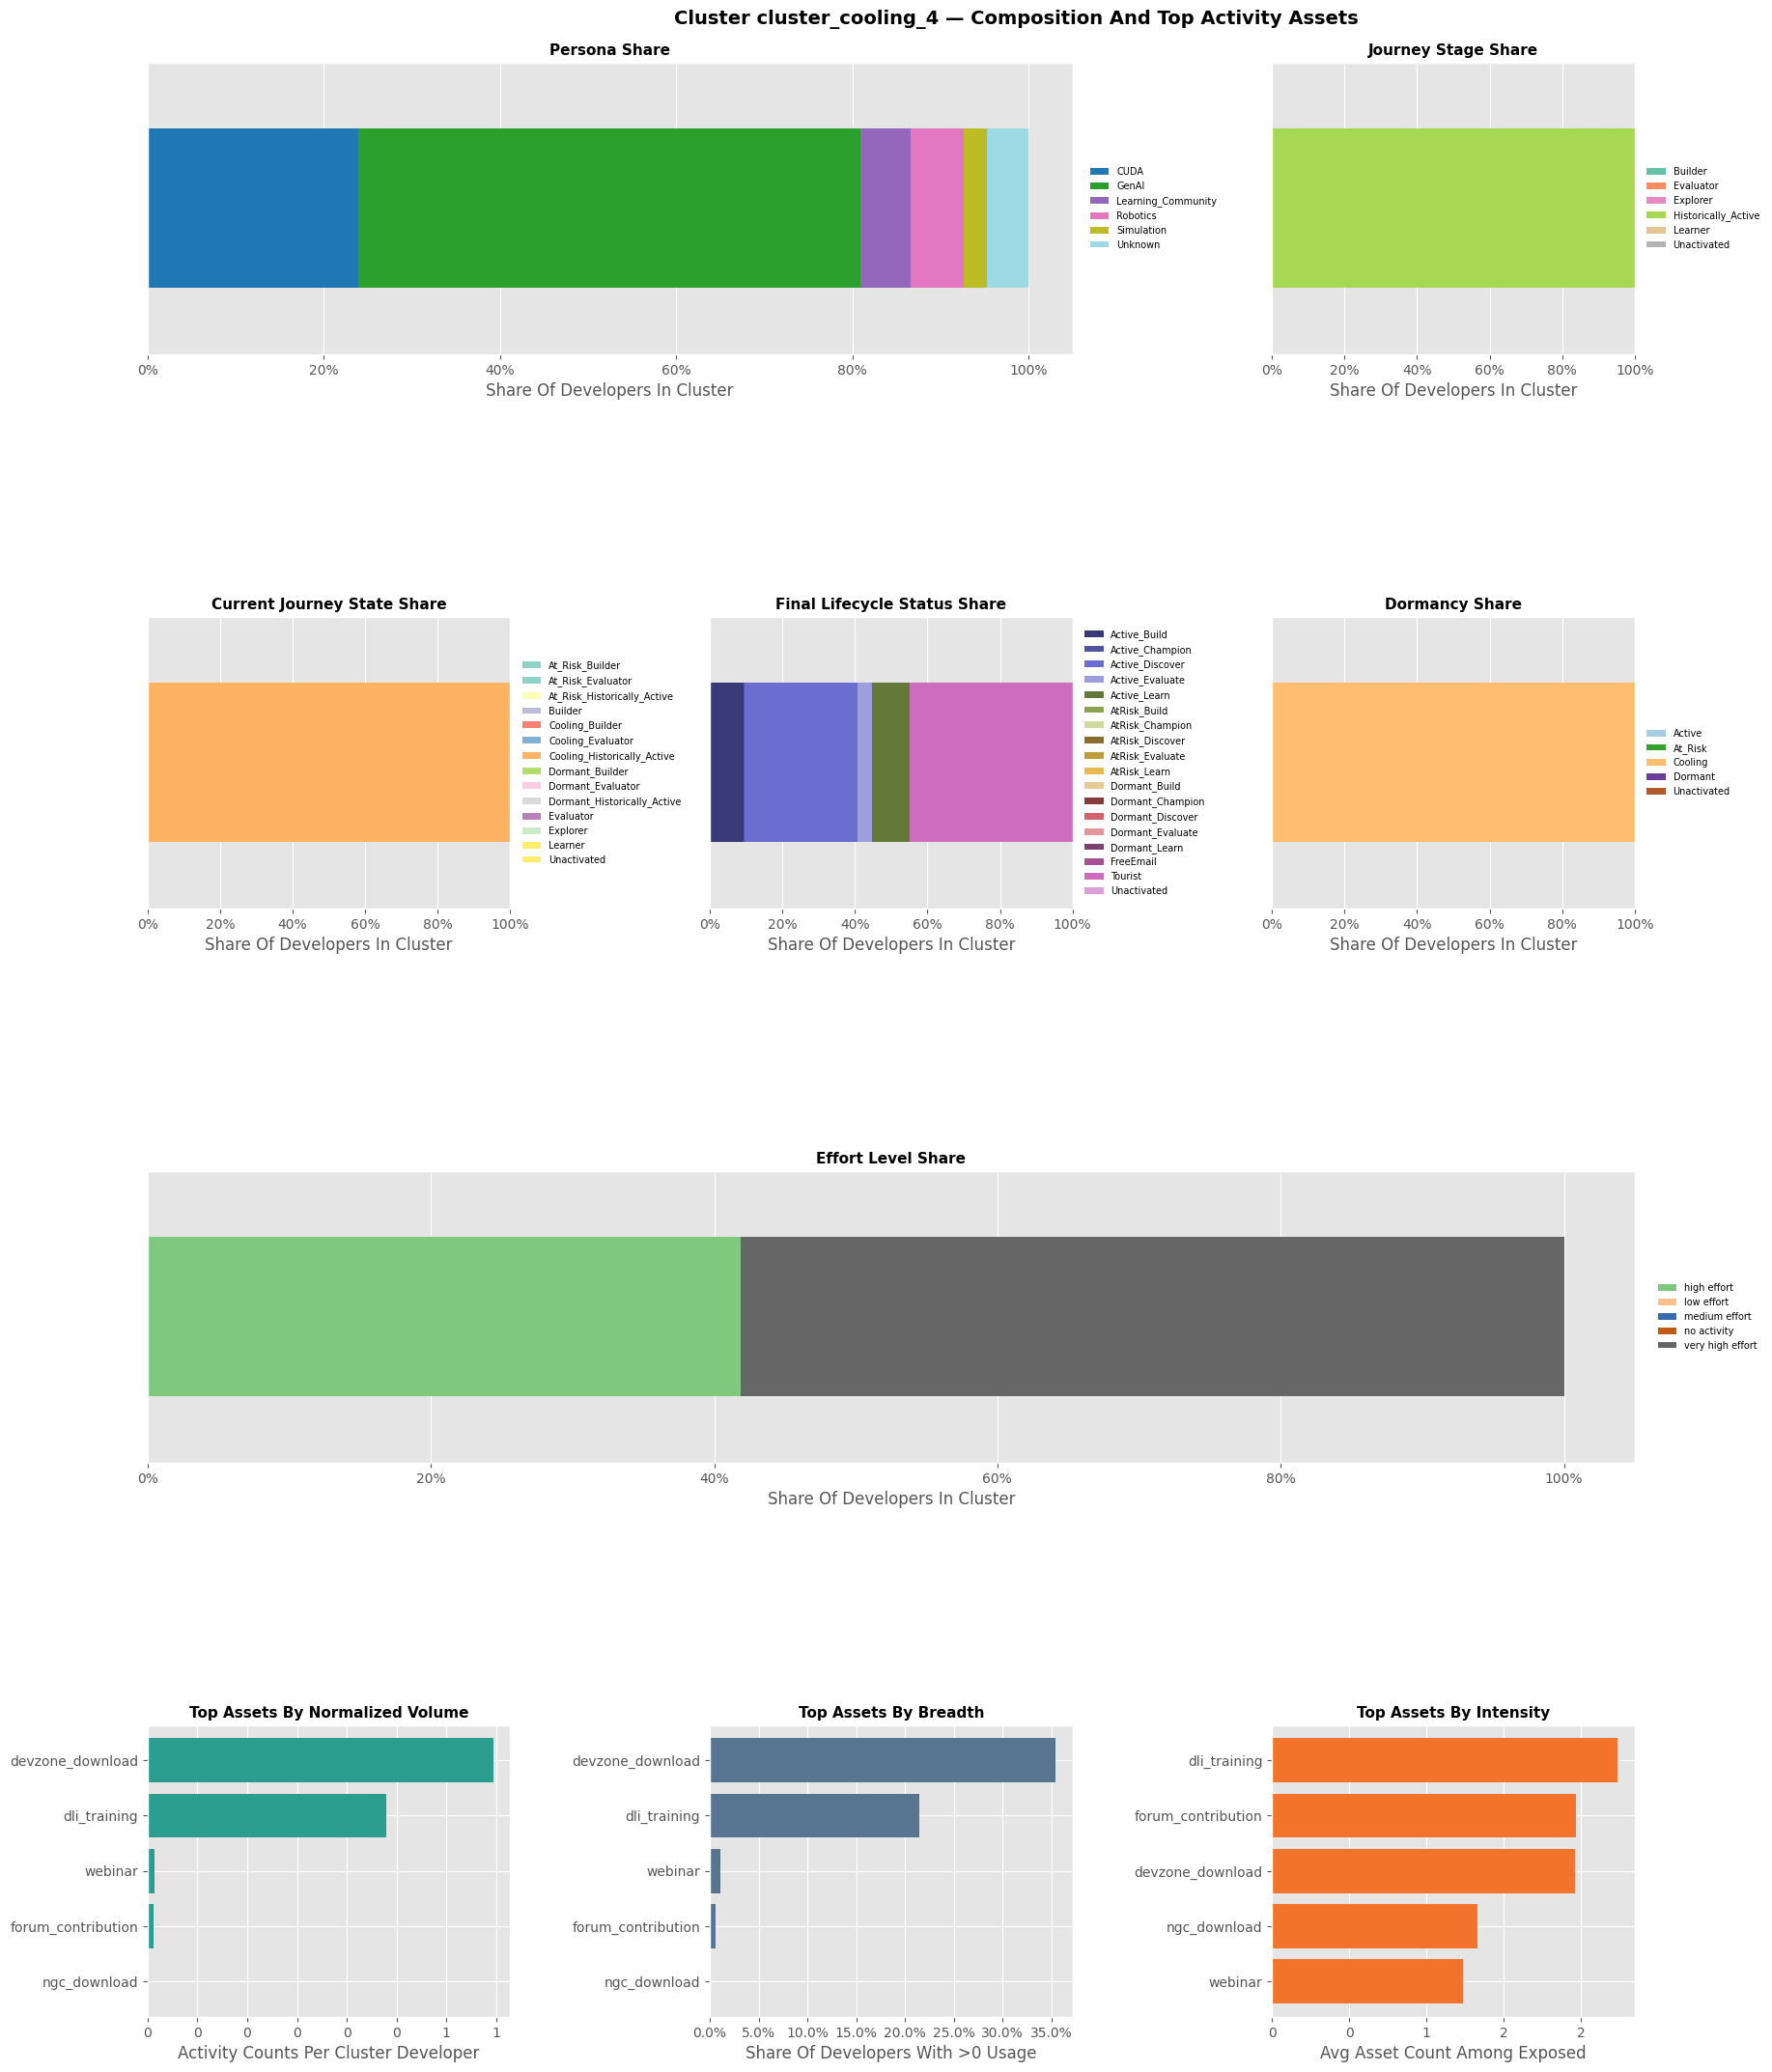

### Cluster: `cluster_active_3` (29,405 developers)

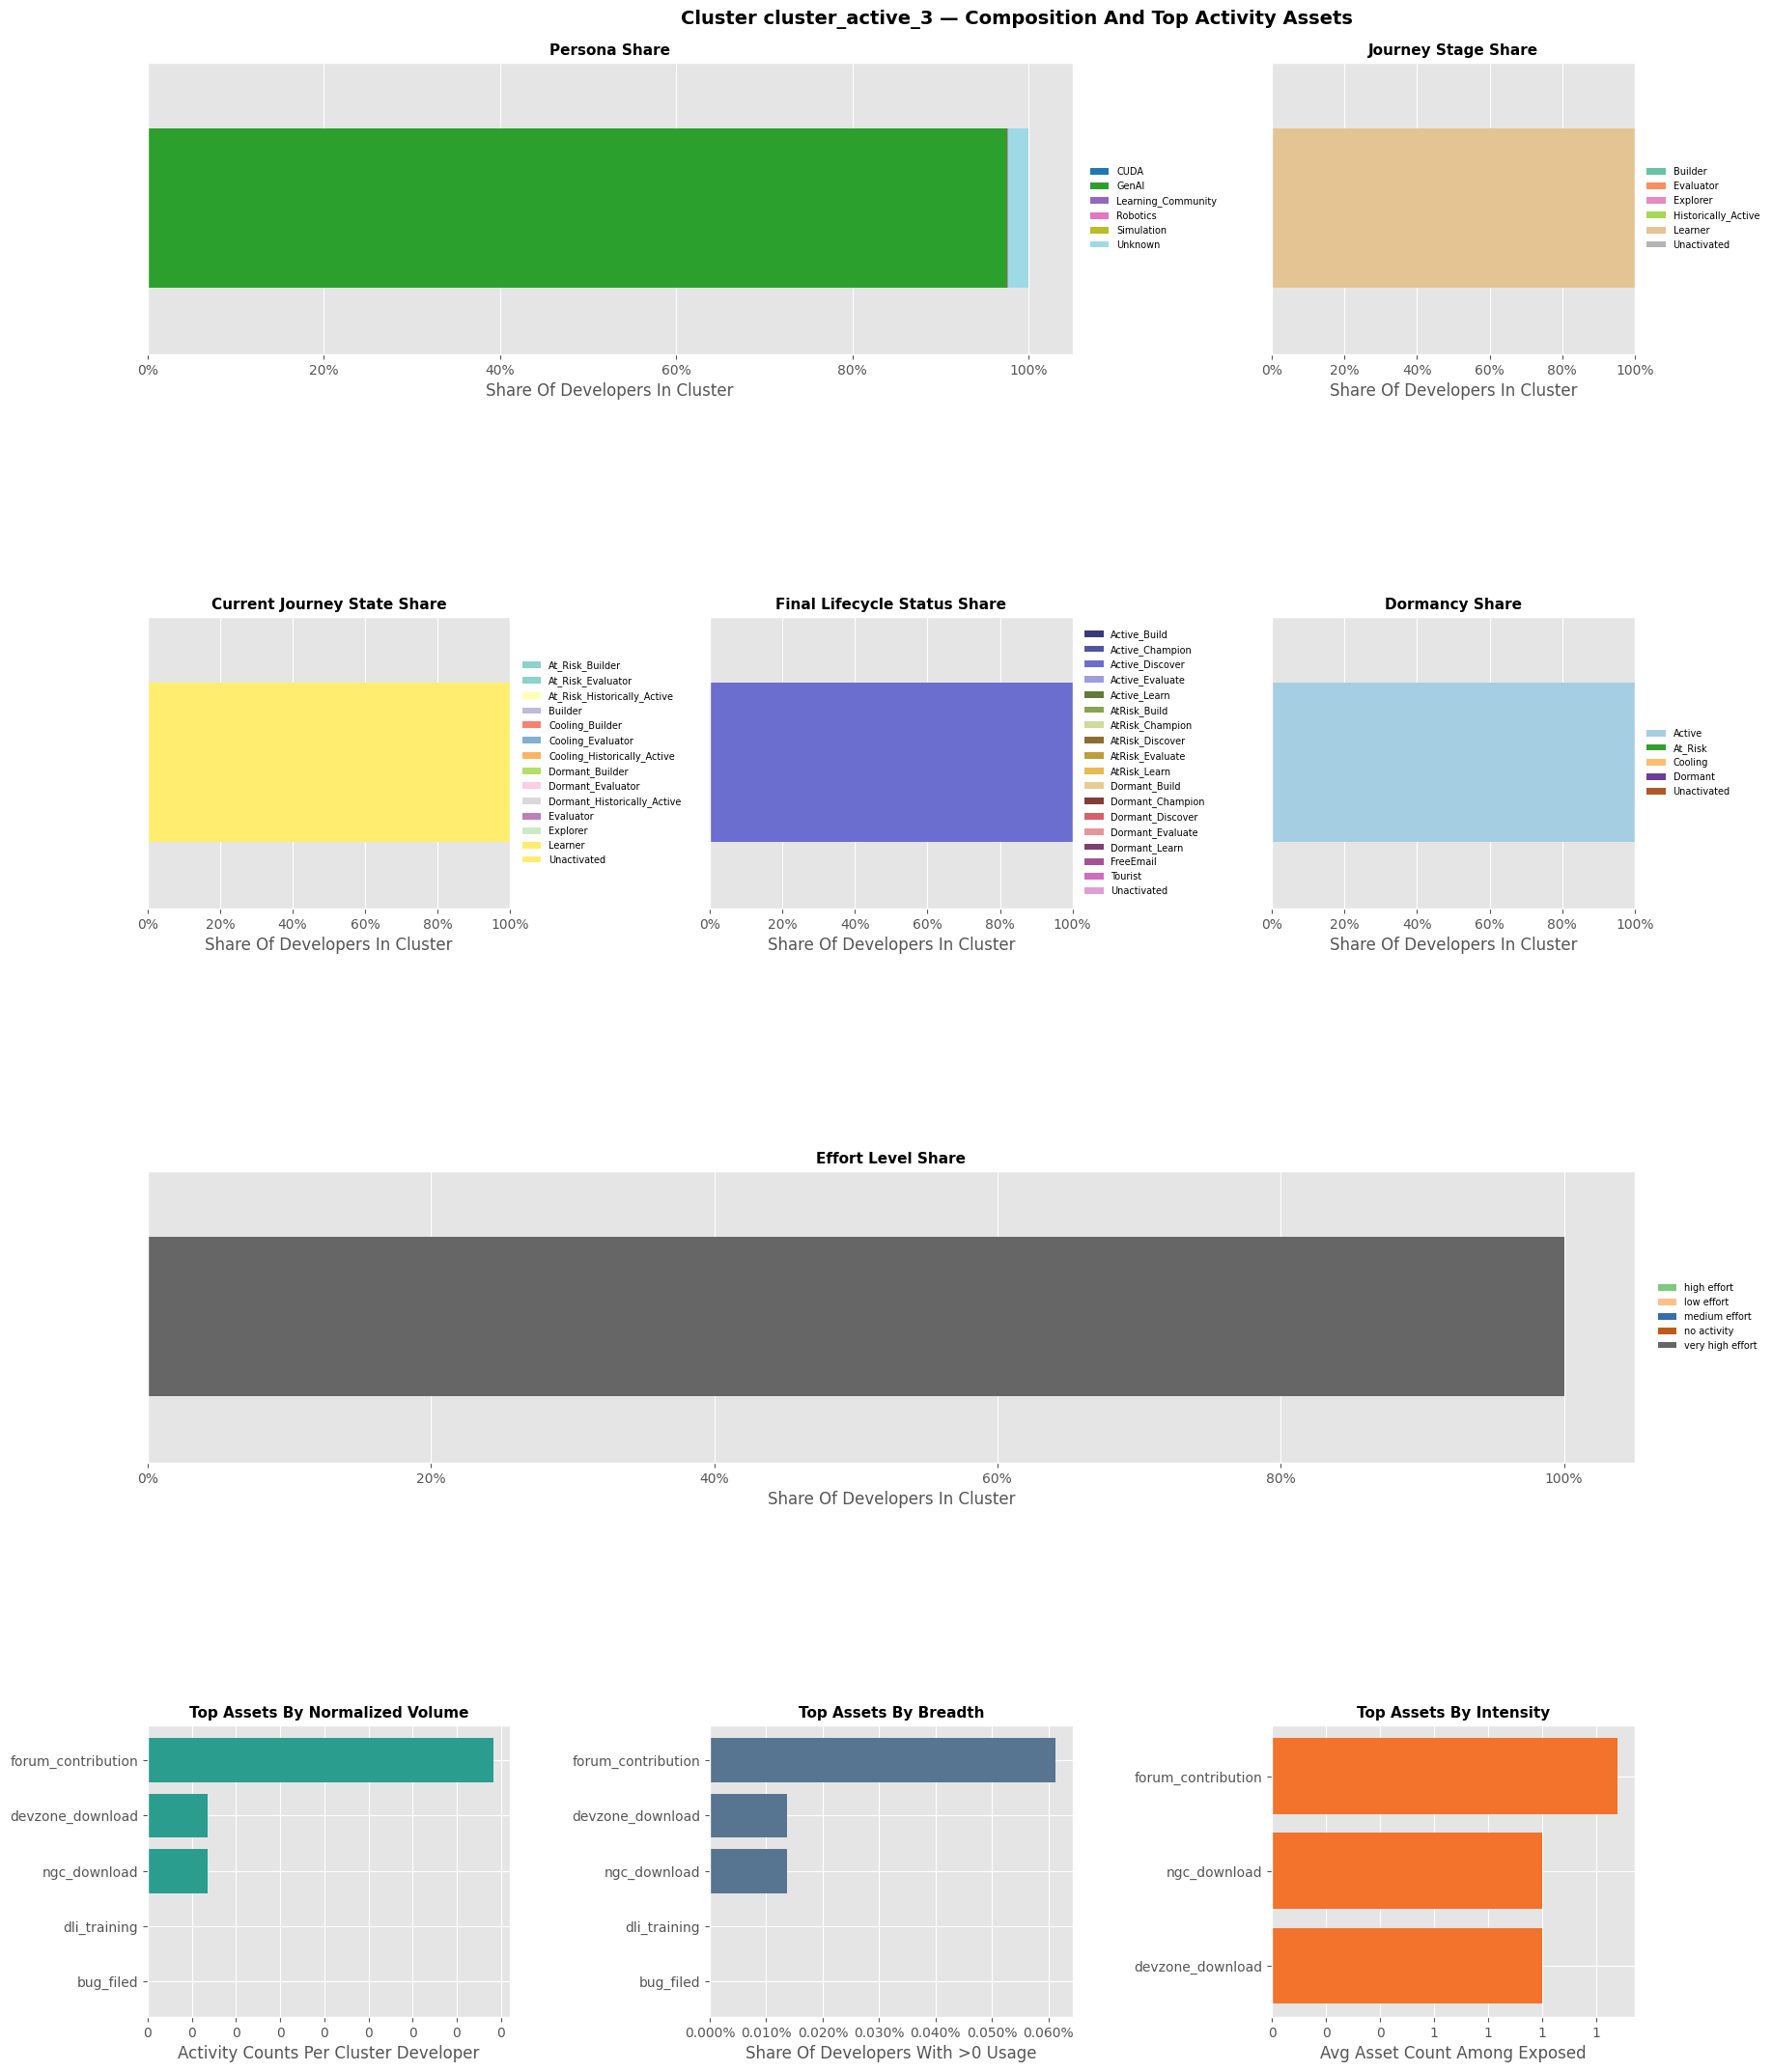

### Cluster: `cluster_cooling_5` (26,703 developers)

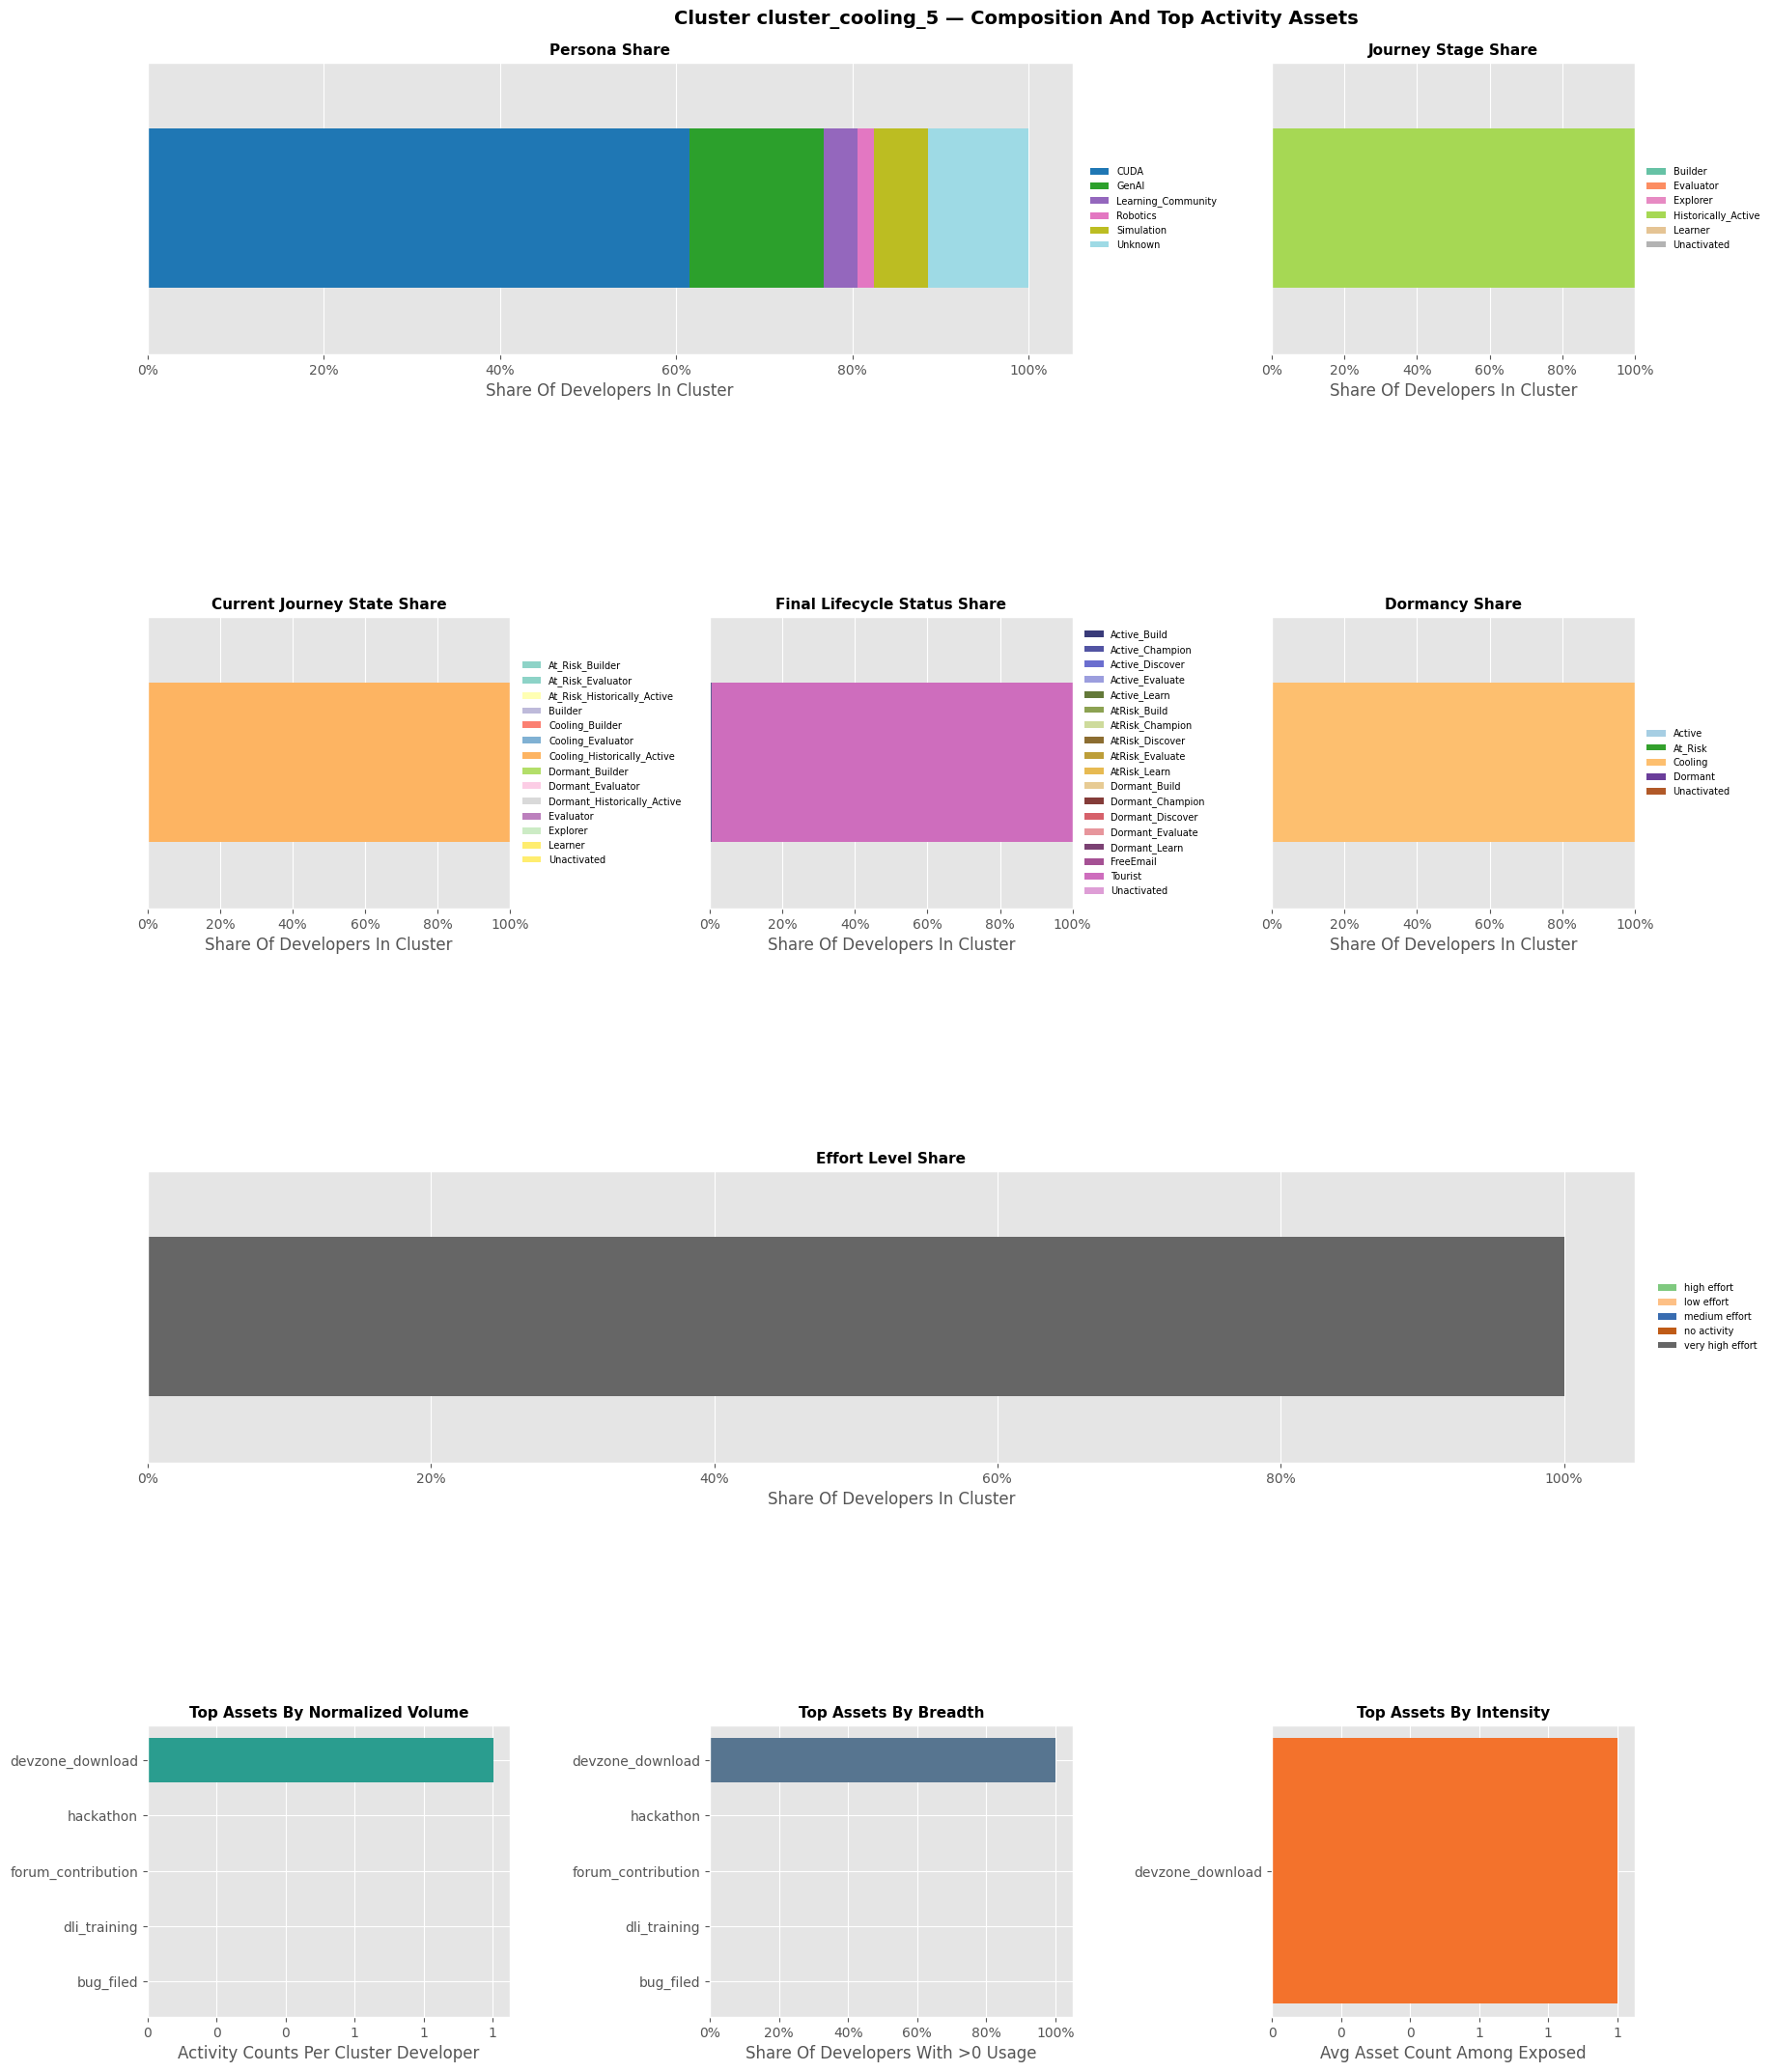

### Cluster: `cluster_cooling_2` (25,489 developers)

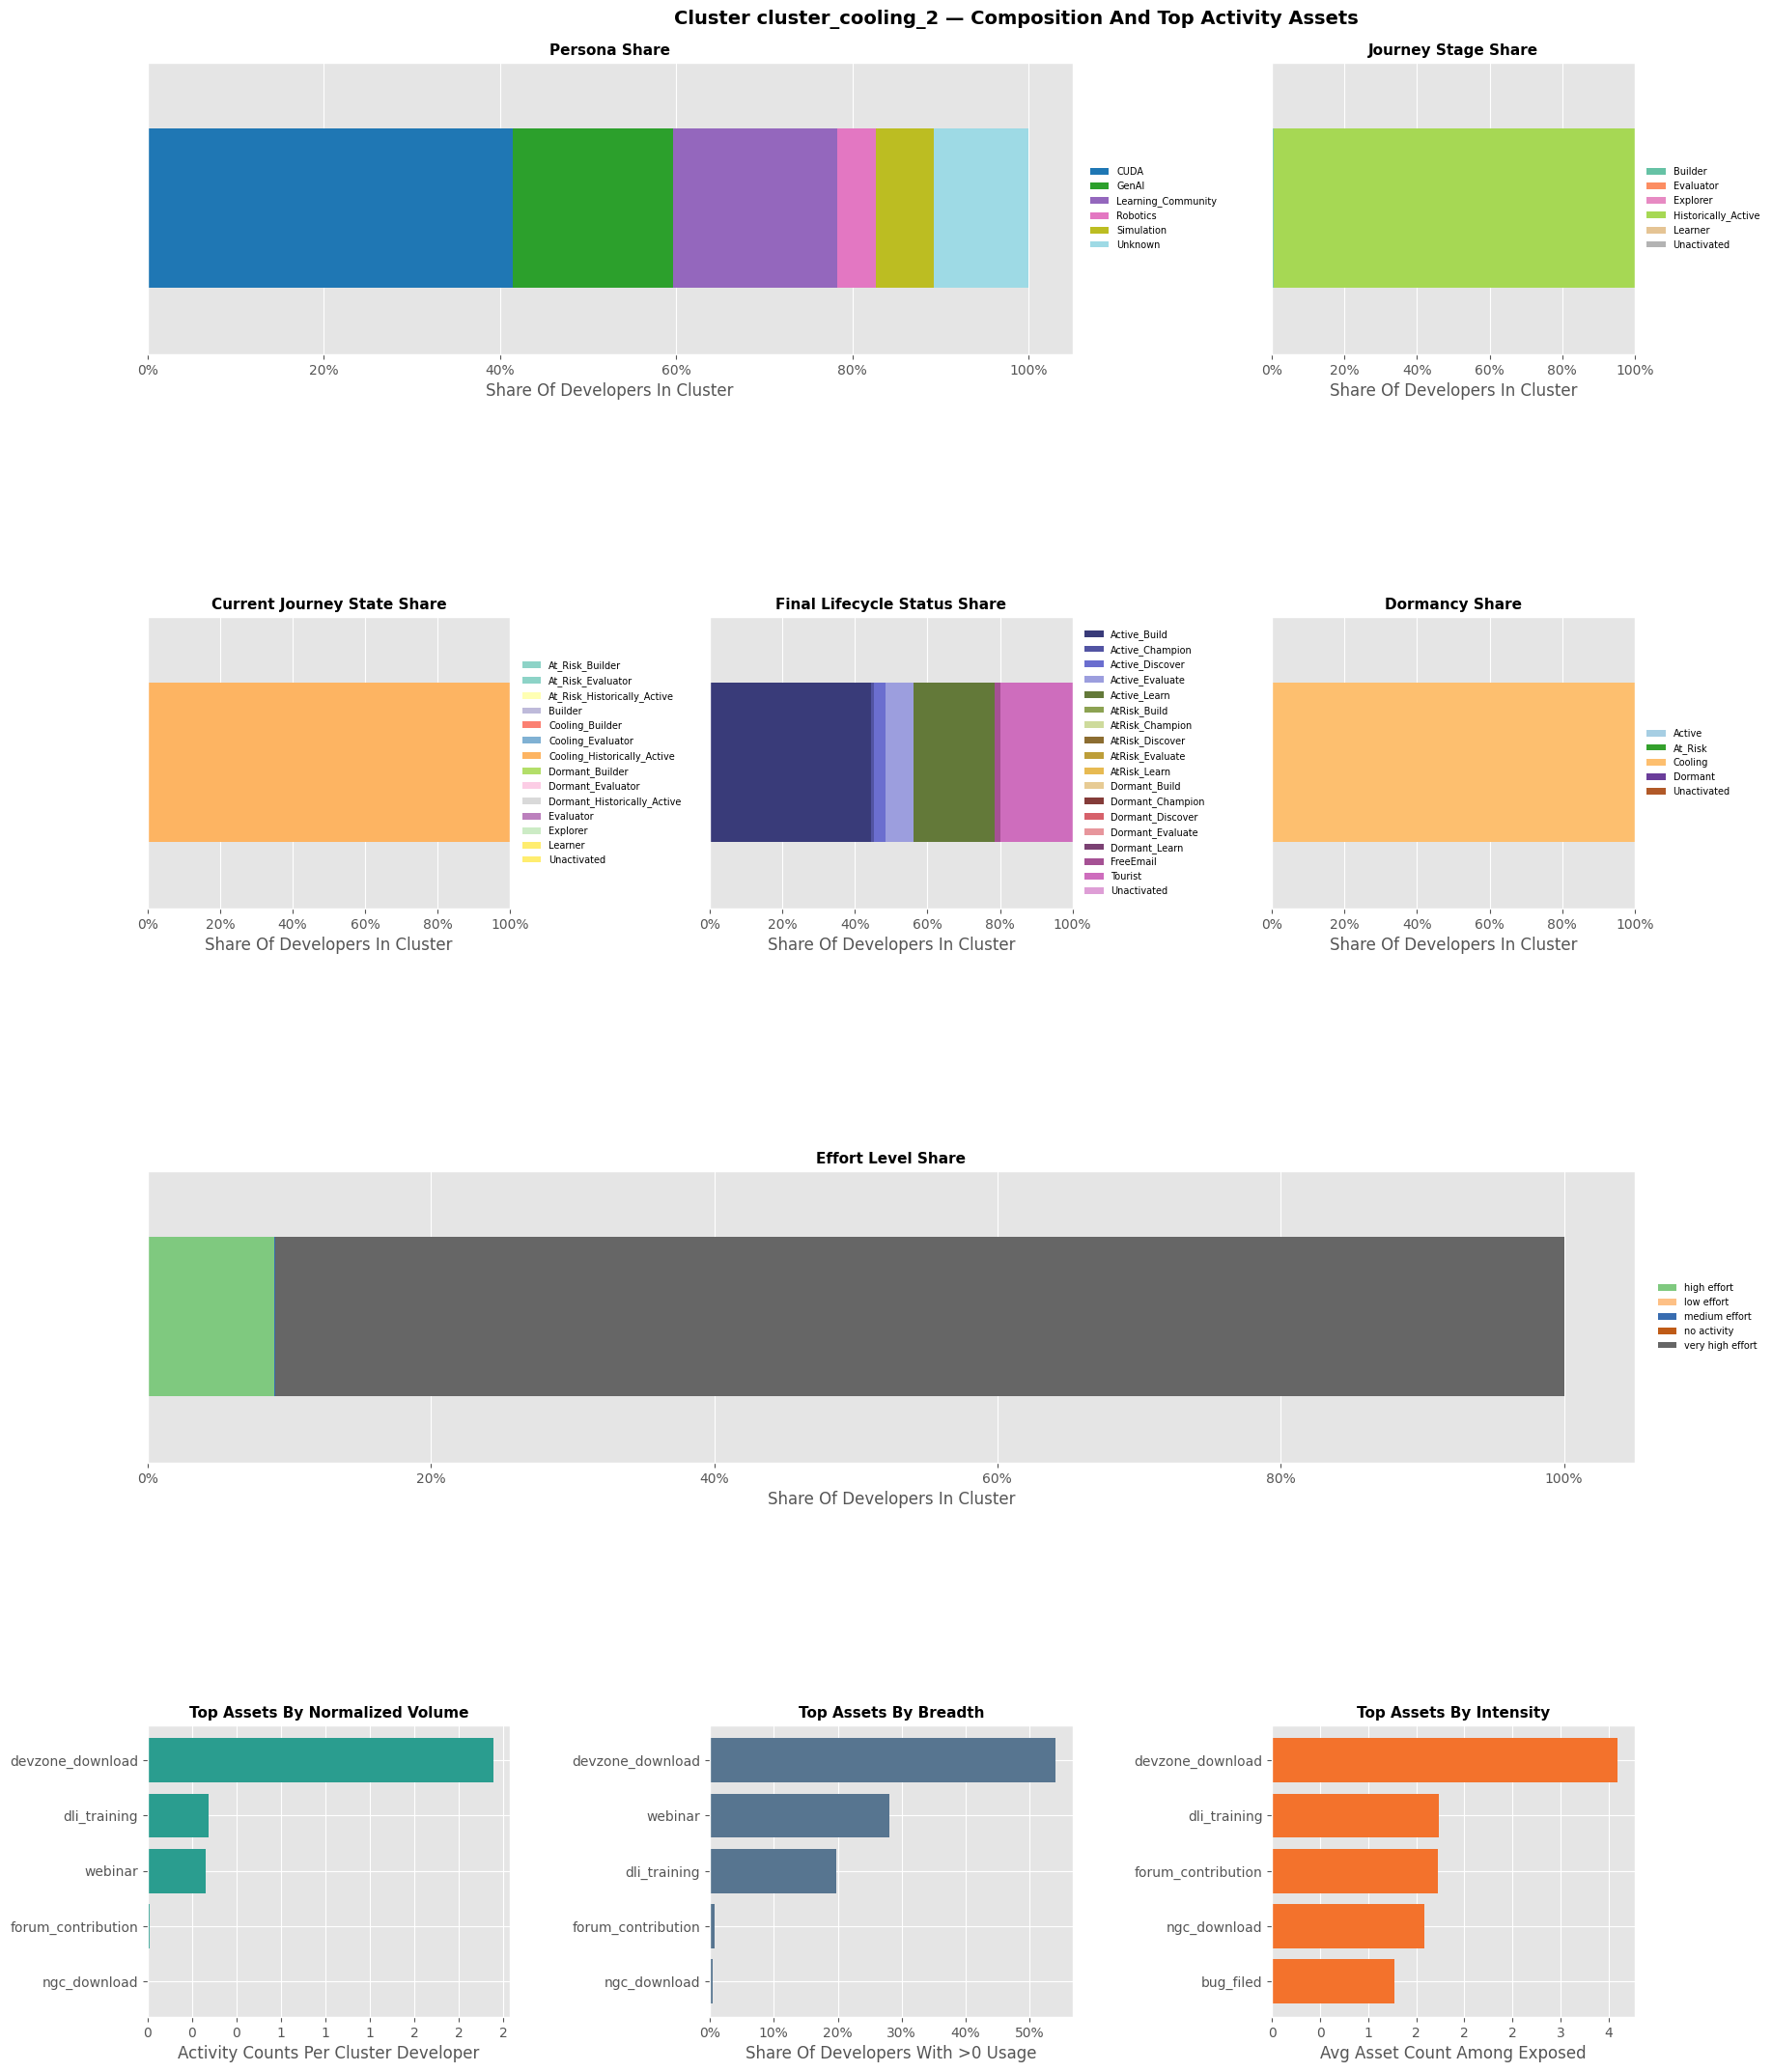

### Cluster: `cluster_active_1` (24,638 developers)

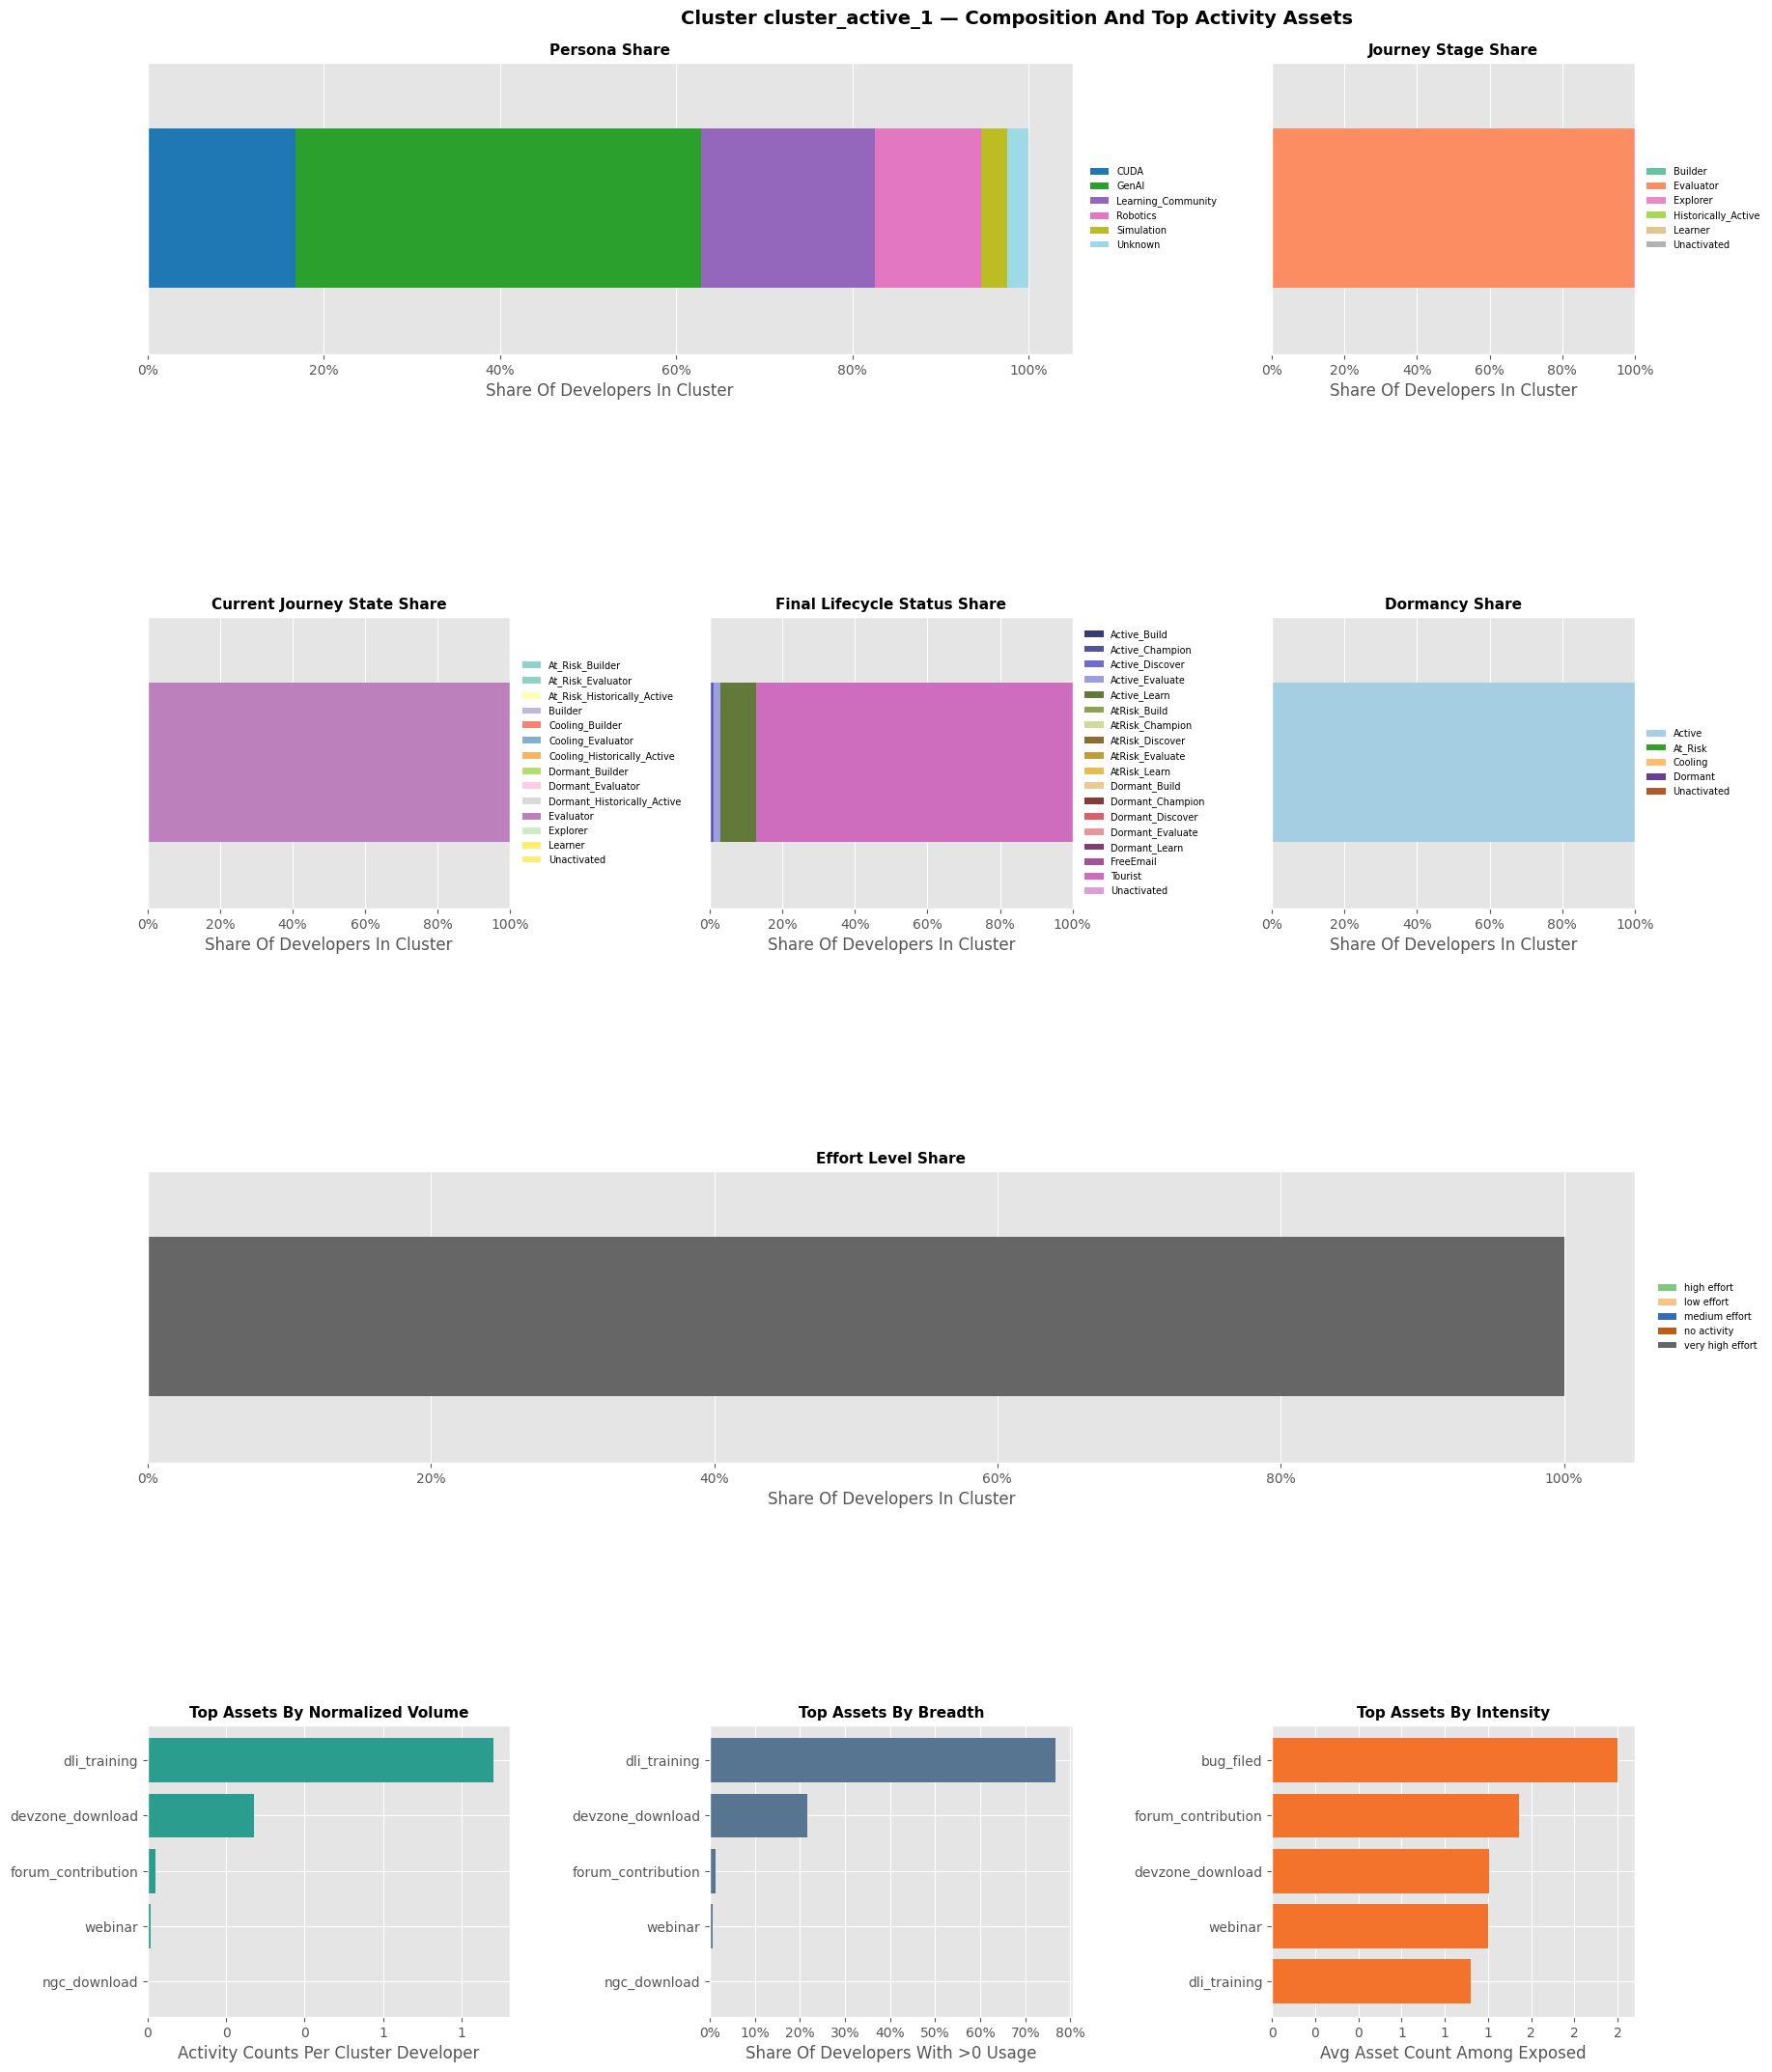

### Cluster: `cluster_cooling_0` (23,934 developers)

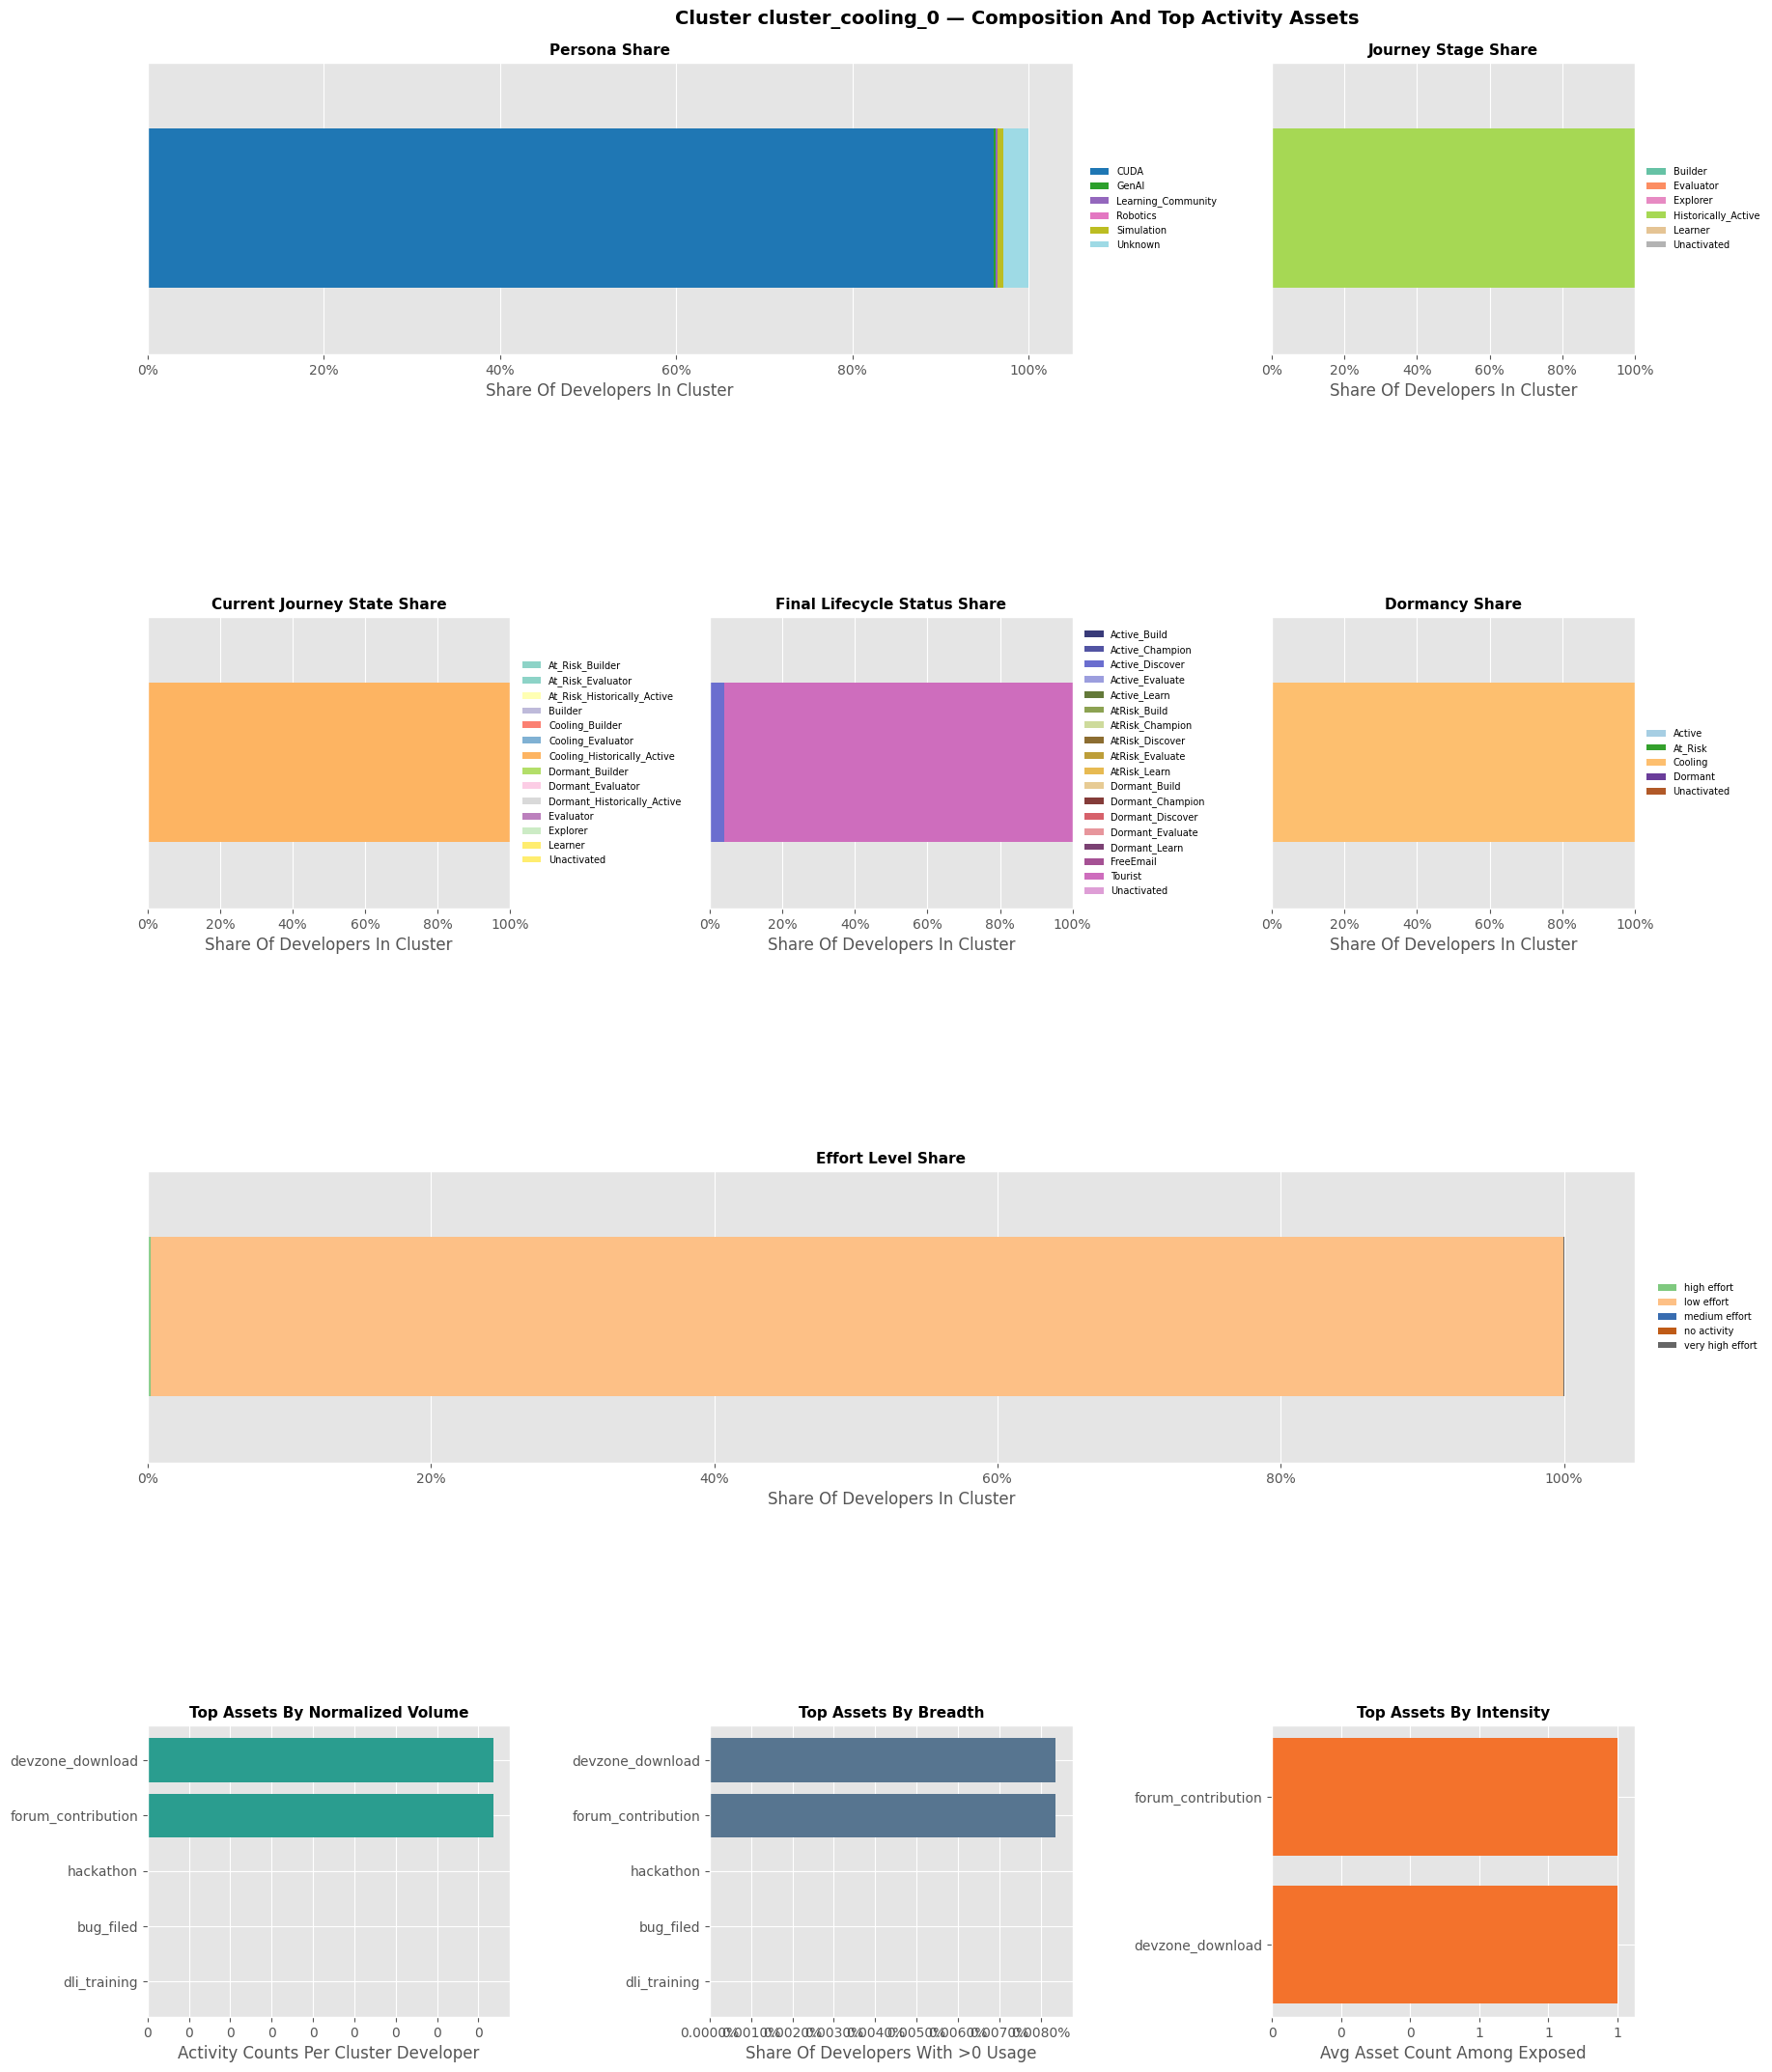

### Cluster: `cluster_cooling_3` (23,021 developers)

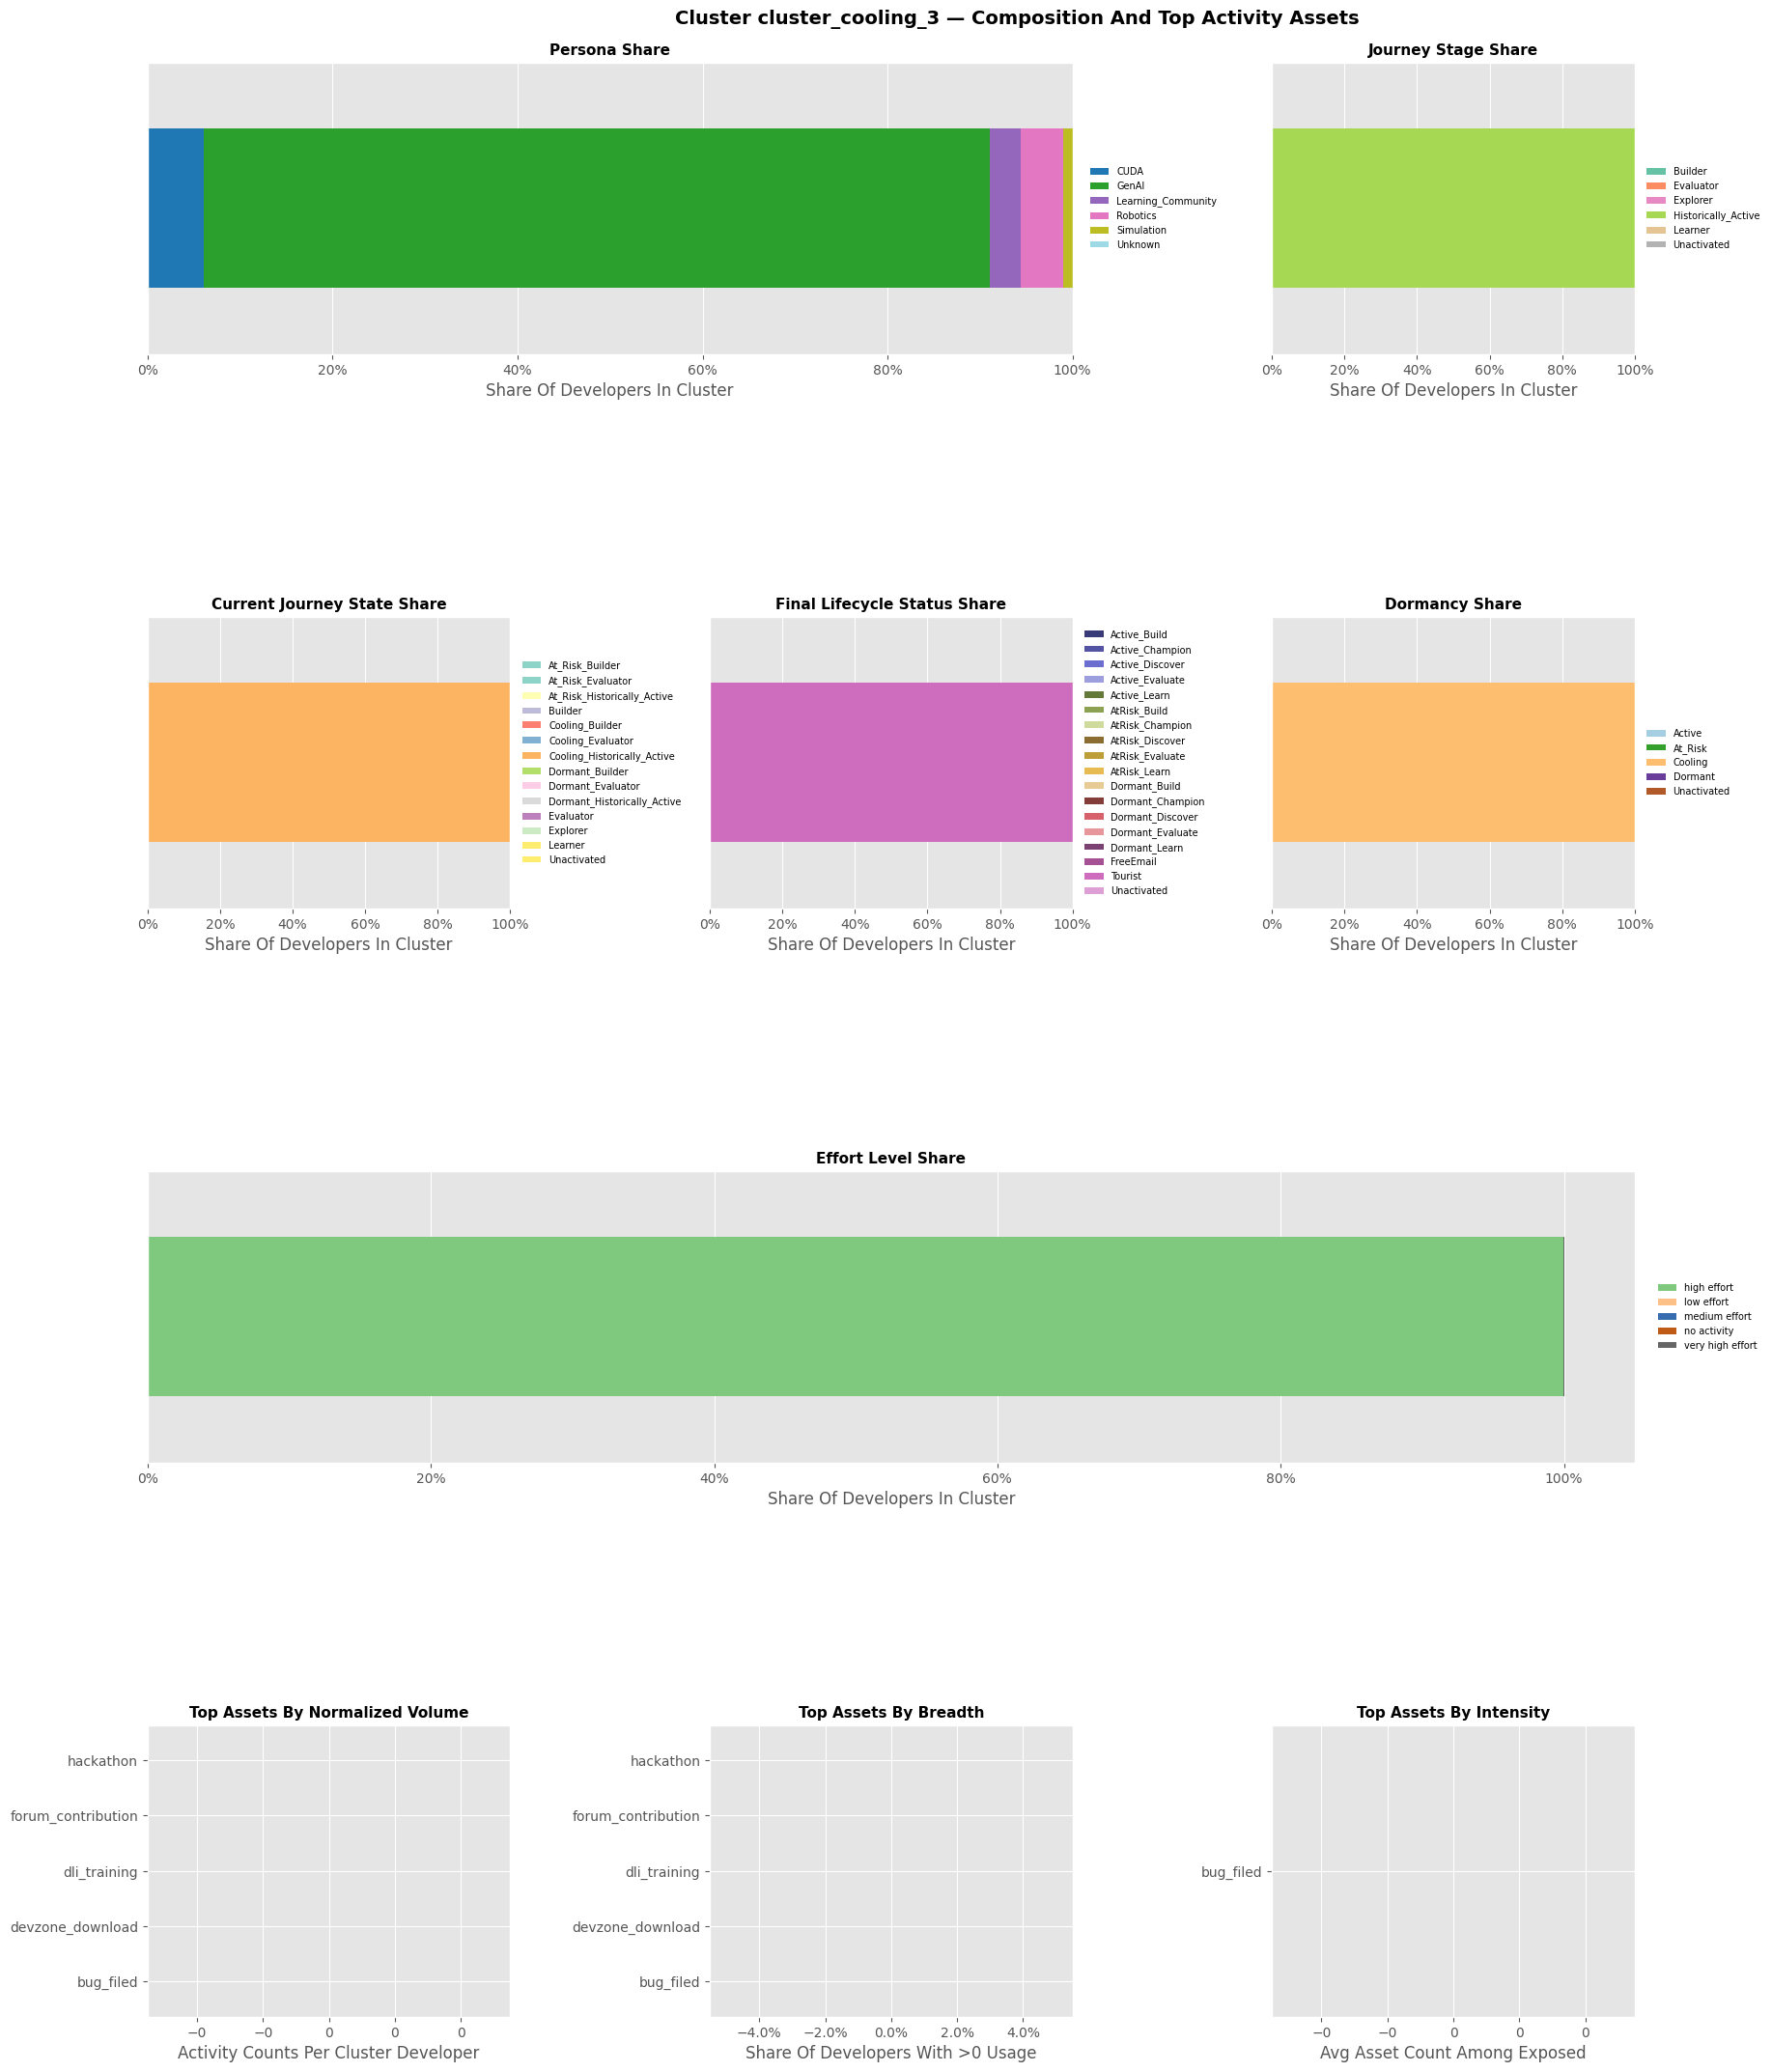

### Cluster: `cluster_active_4` (18,420 developers)

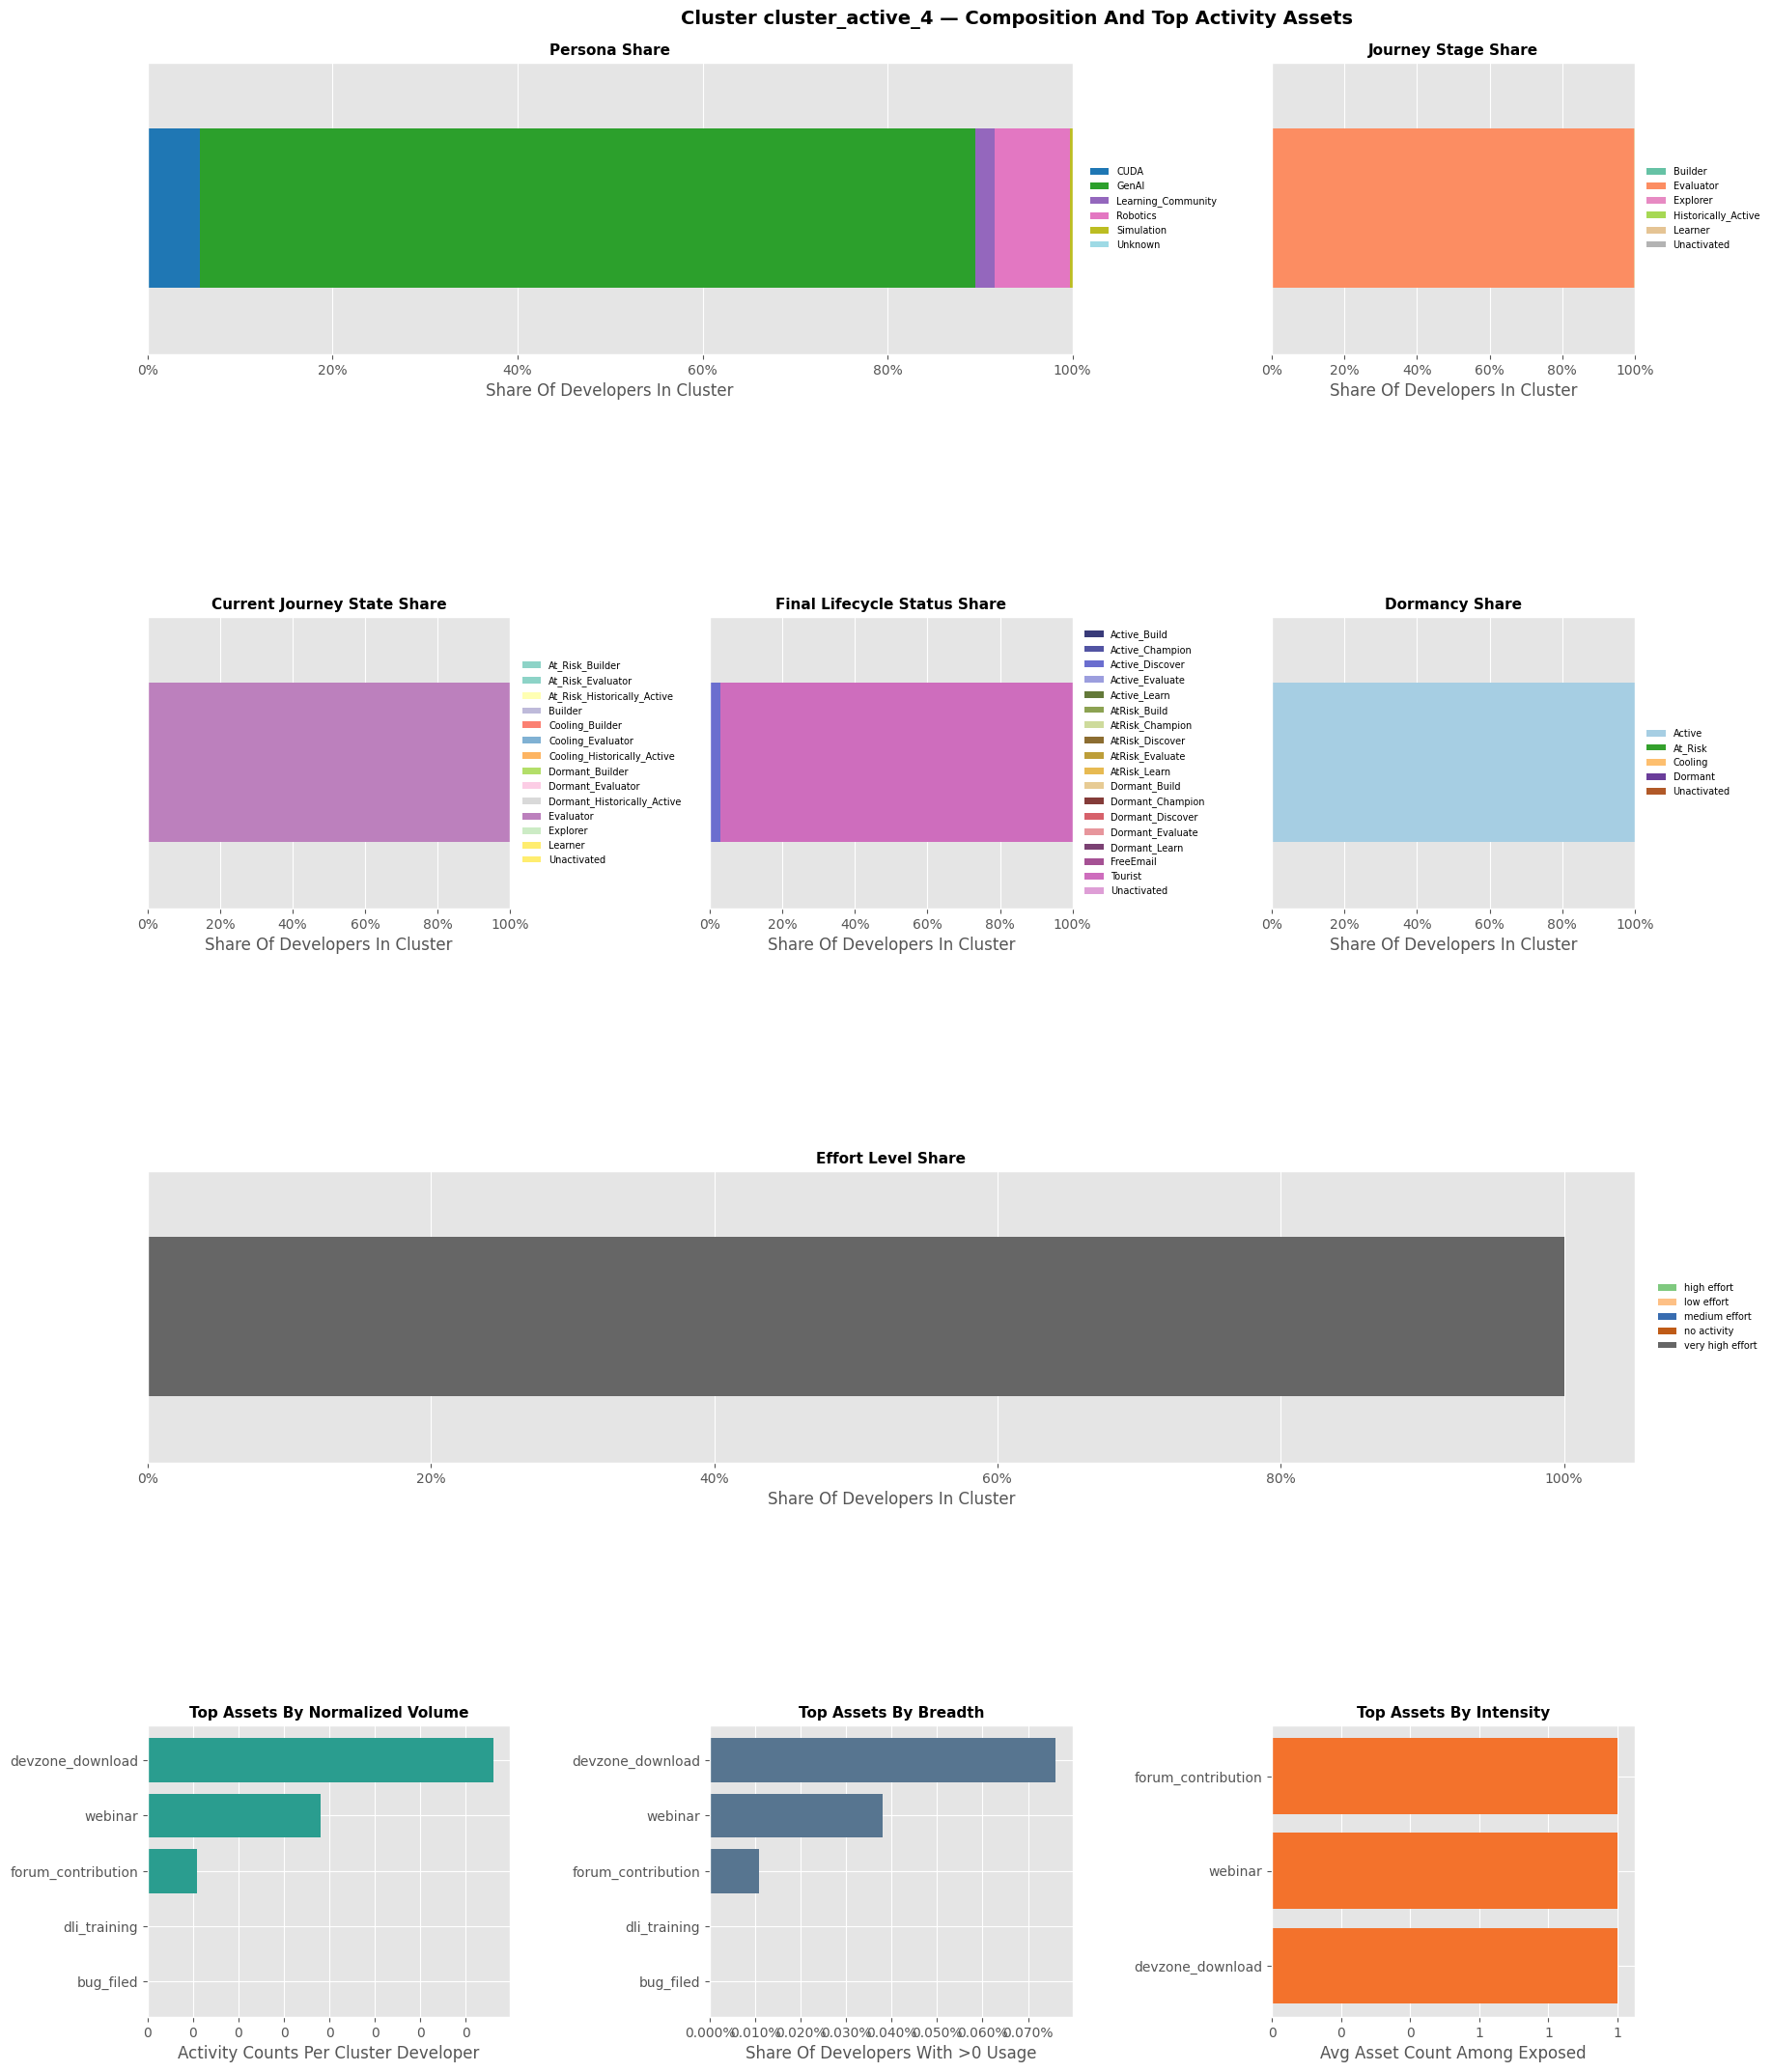

### Cluster: `cluster_active_0` (17,957 developers)

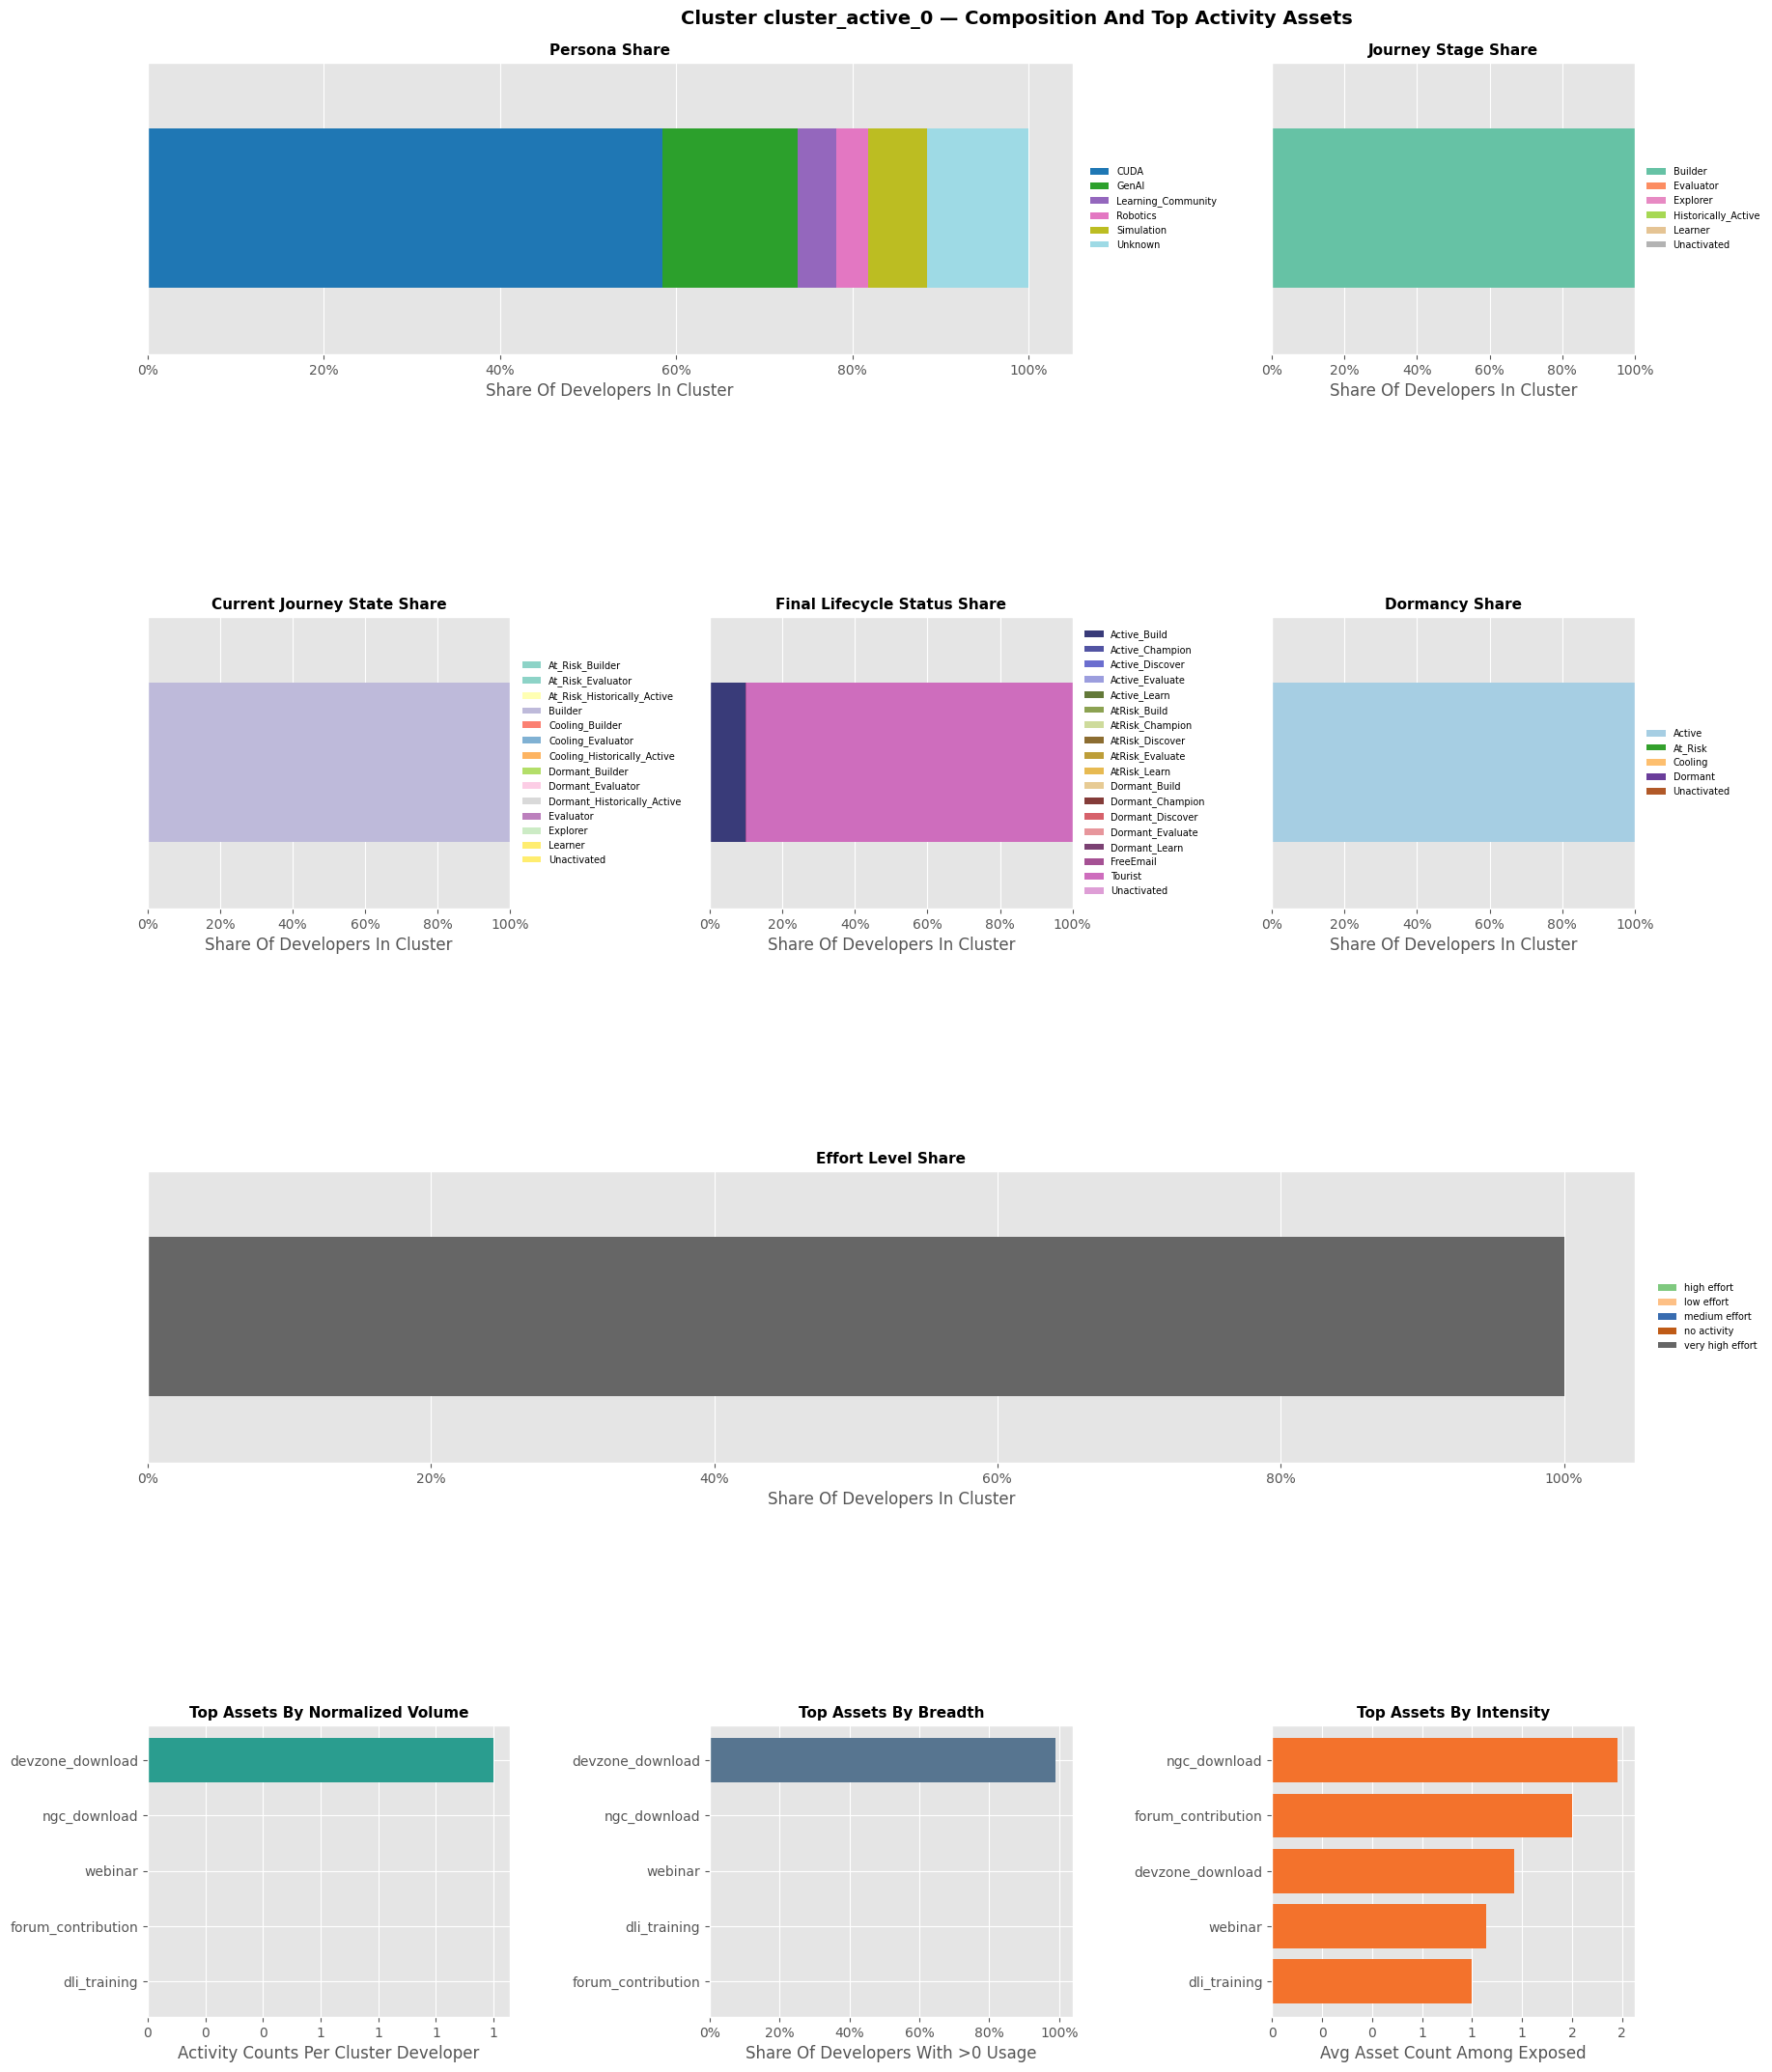

## Aggregate Overview Across Clusters

### Cluster-Level Activity And Exposure Overview

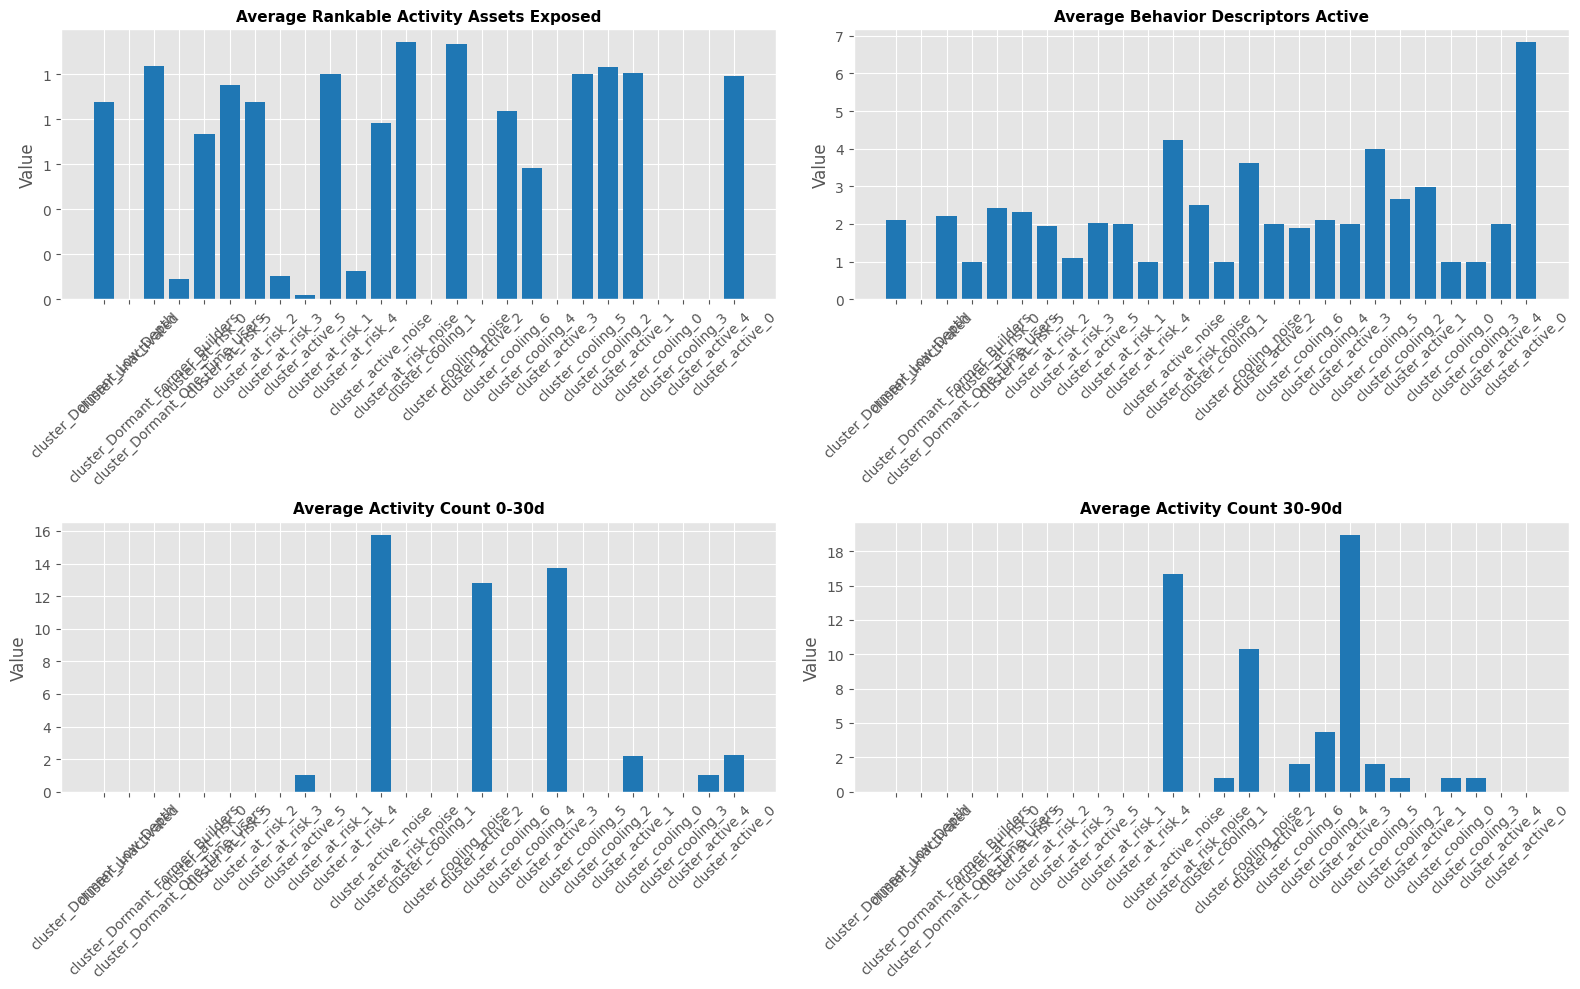

### Persona Share By Cluster

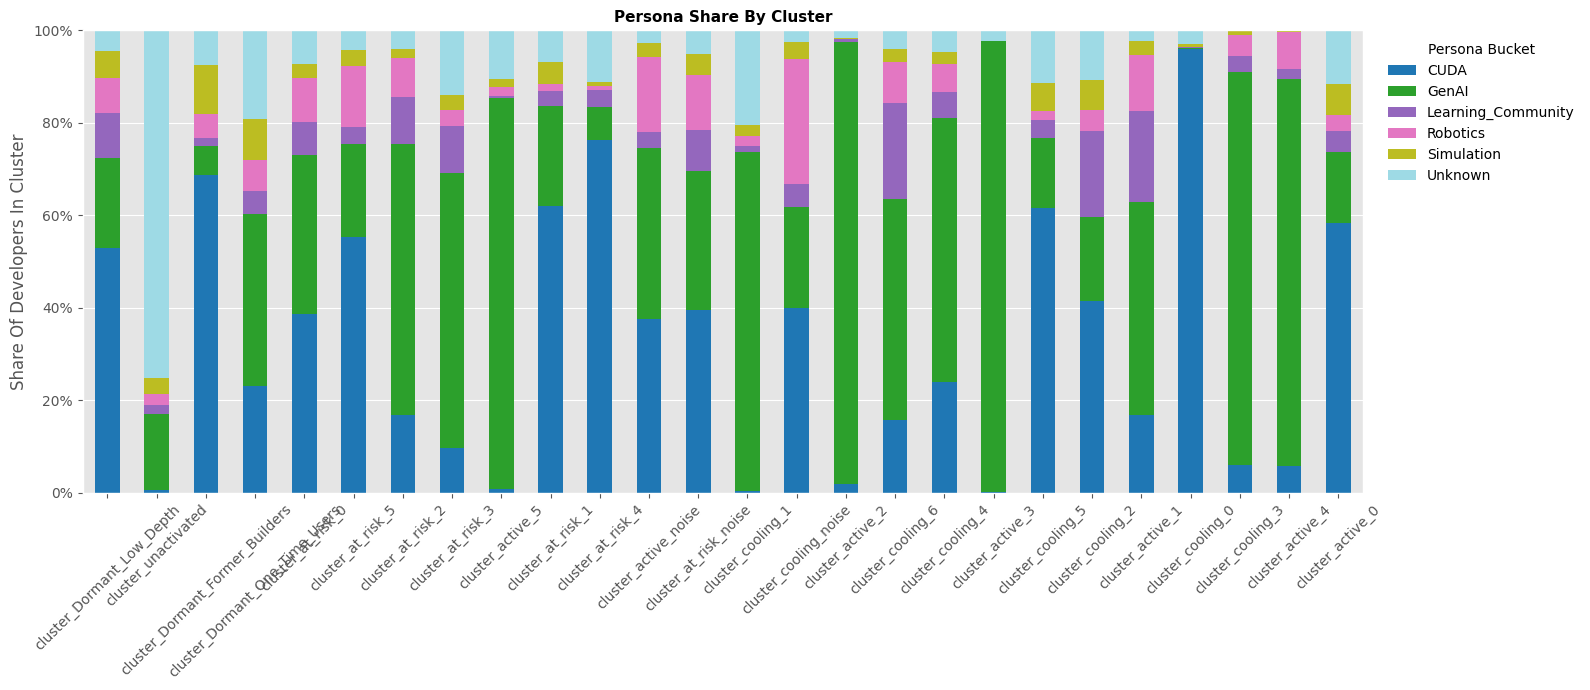

### Journey Stage Share By Cluster

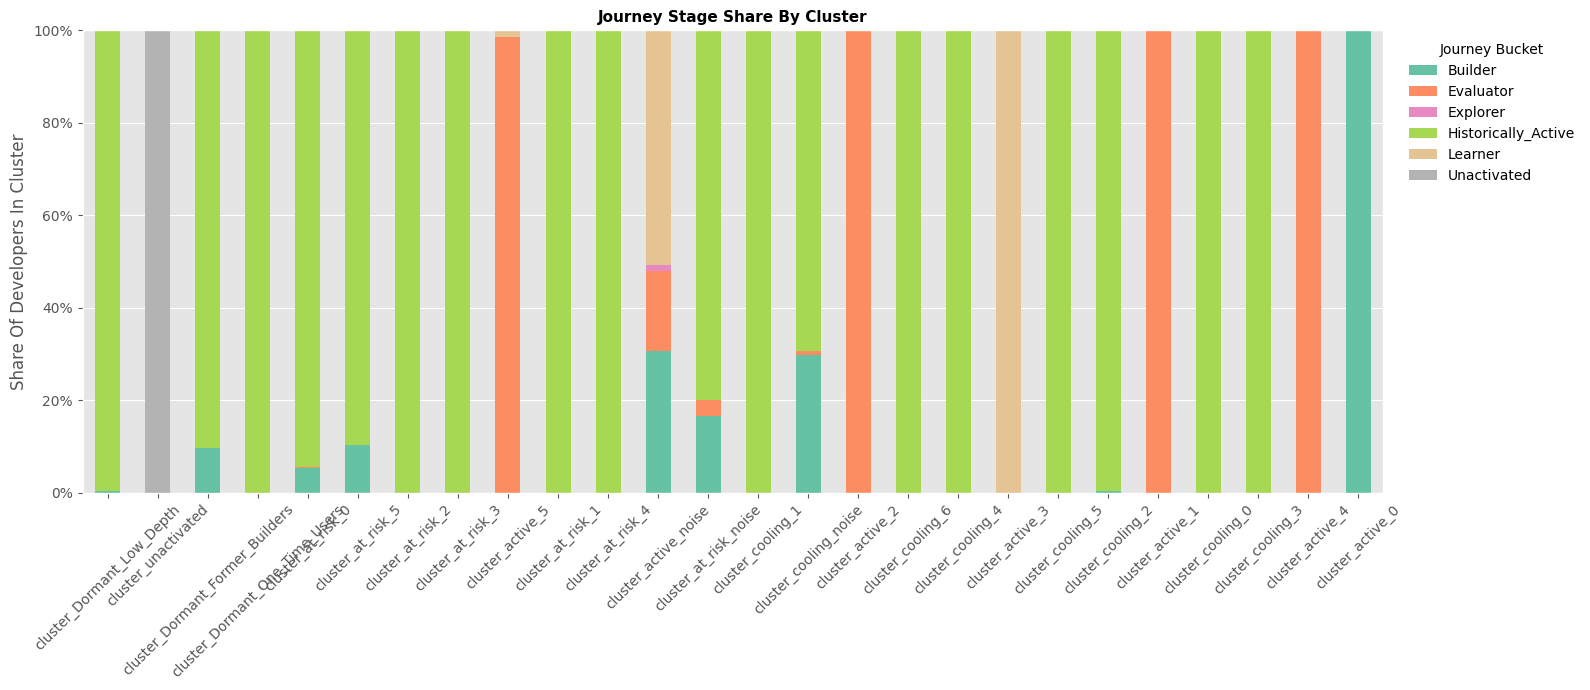

### Current Journey State Share By Cluster

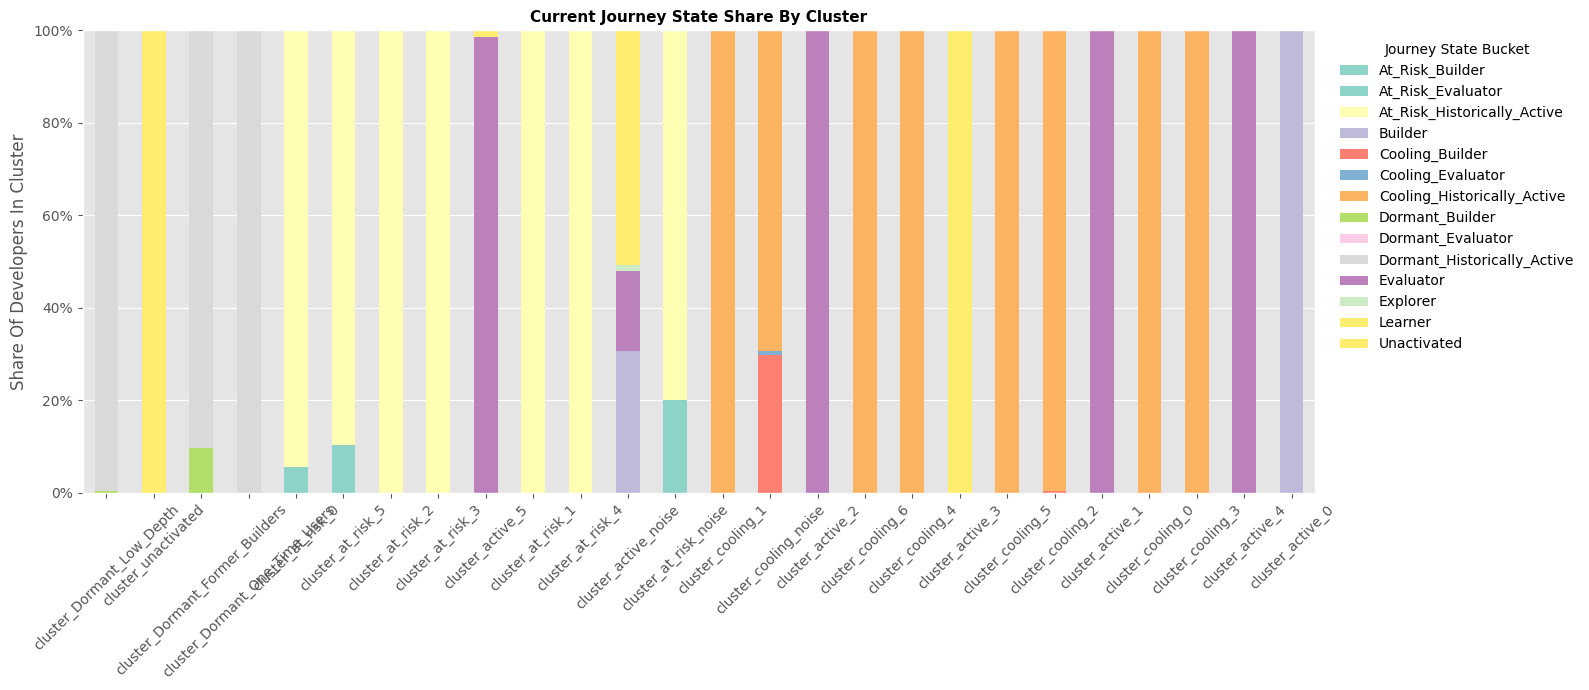

### Final Lifecycle Status Share By Cluster

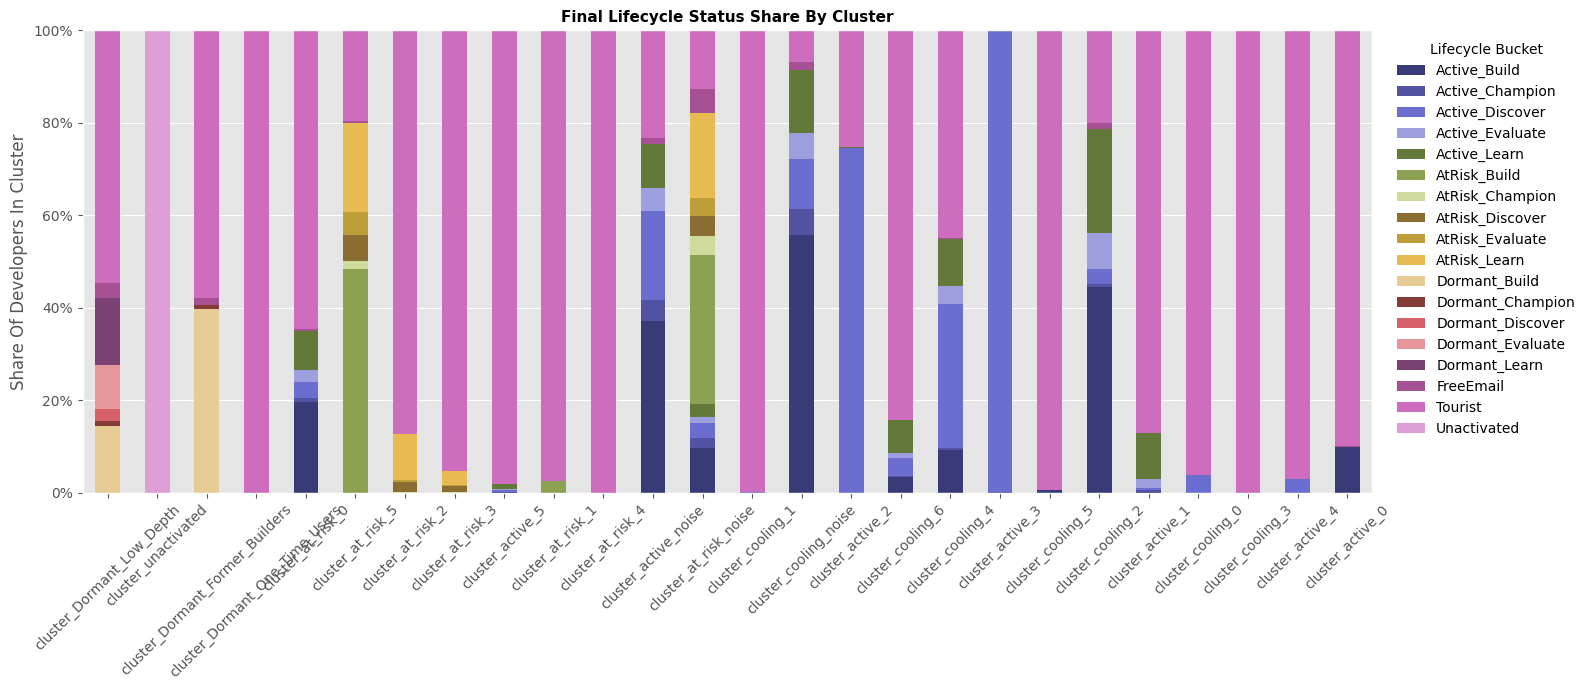

### Dormancy Share By Cluster

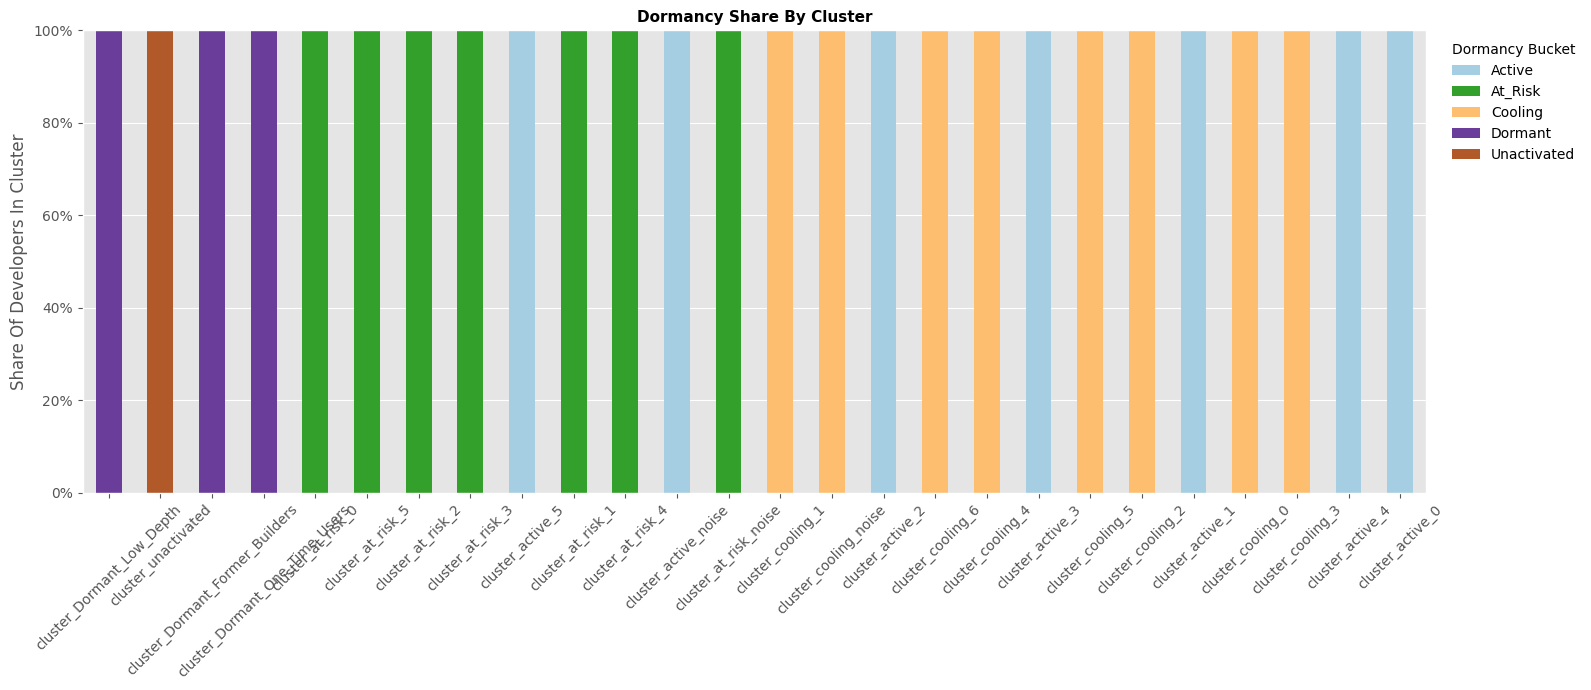

### Effort Level Share By Cluster

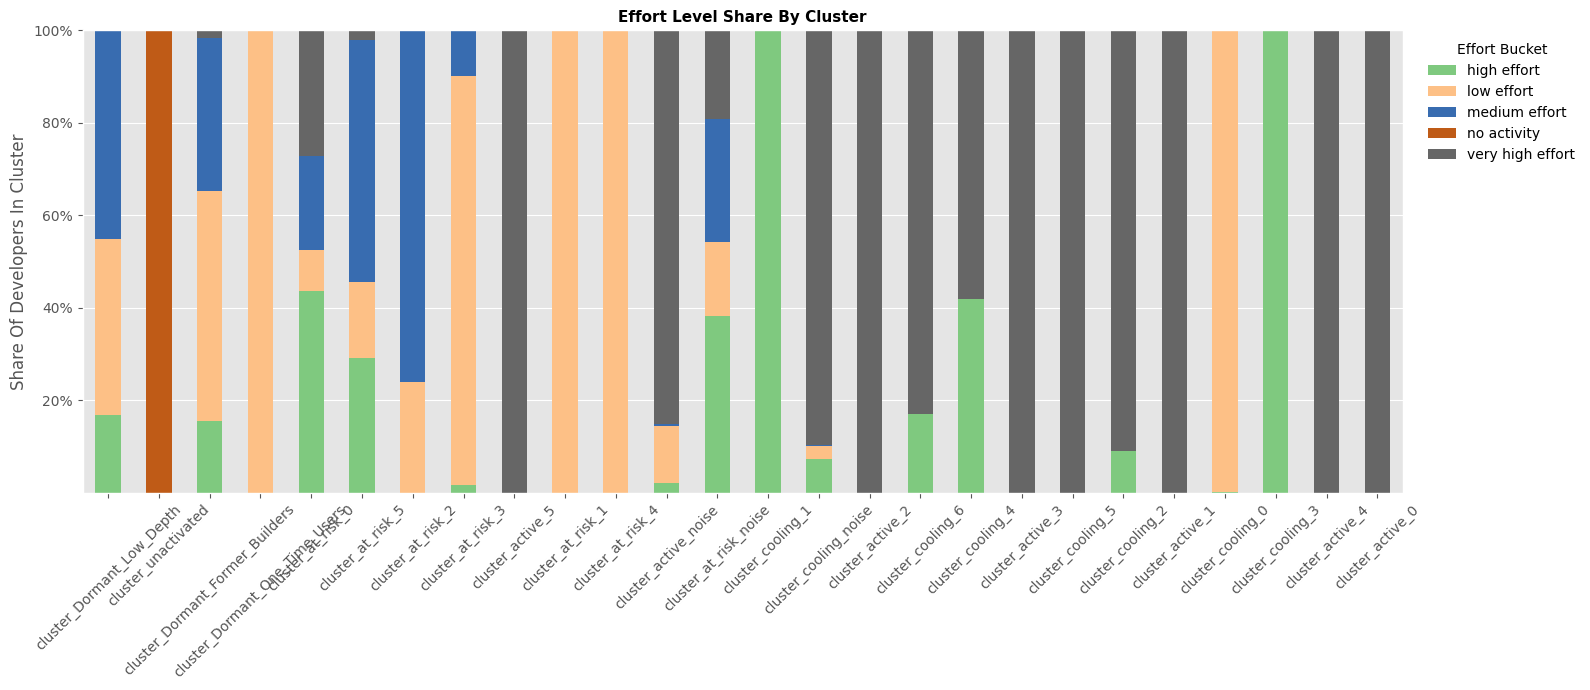

## Per-Asset Views

<positron-console-cell-13>:224: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
<positron-console-cell-13>:225: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


### Asset View: `dli_training`

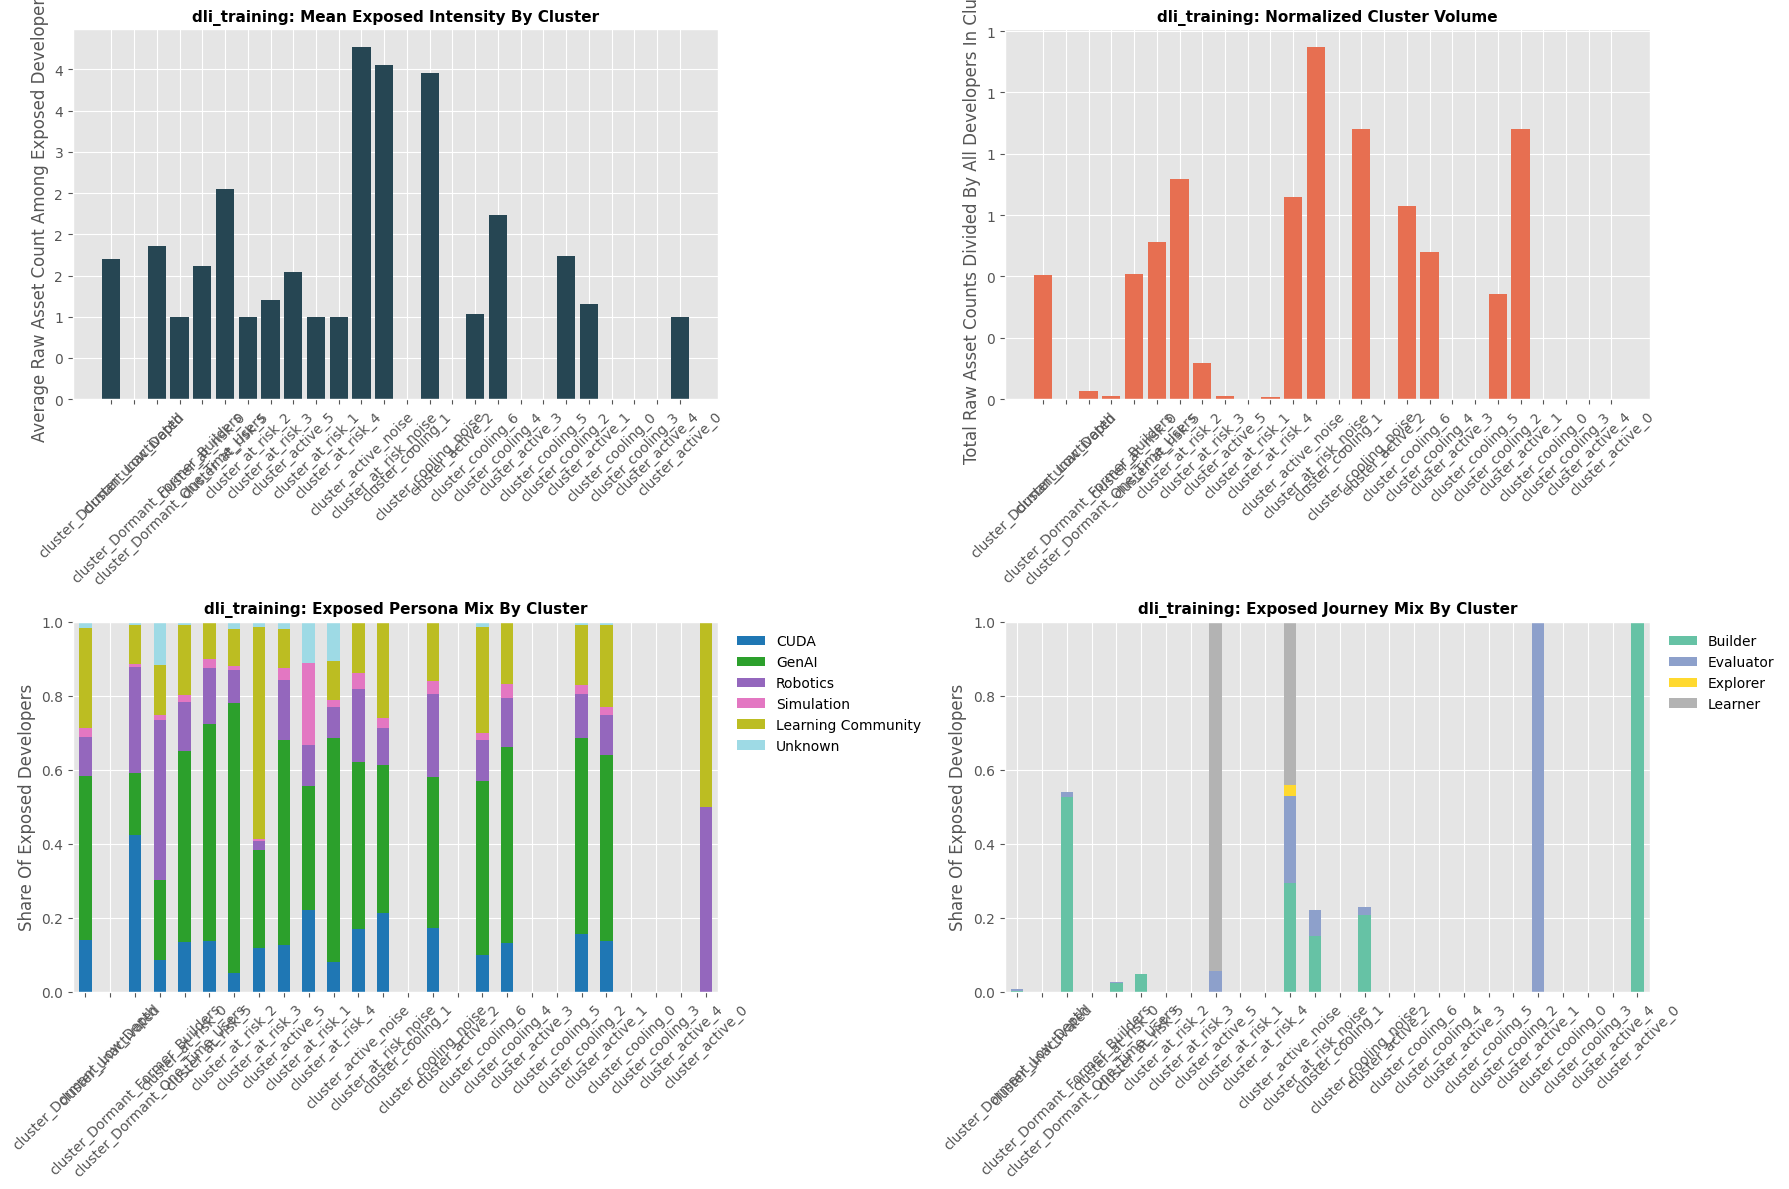

### Asset View: `webinar`

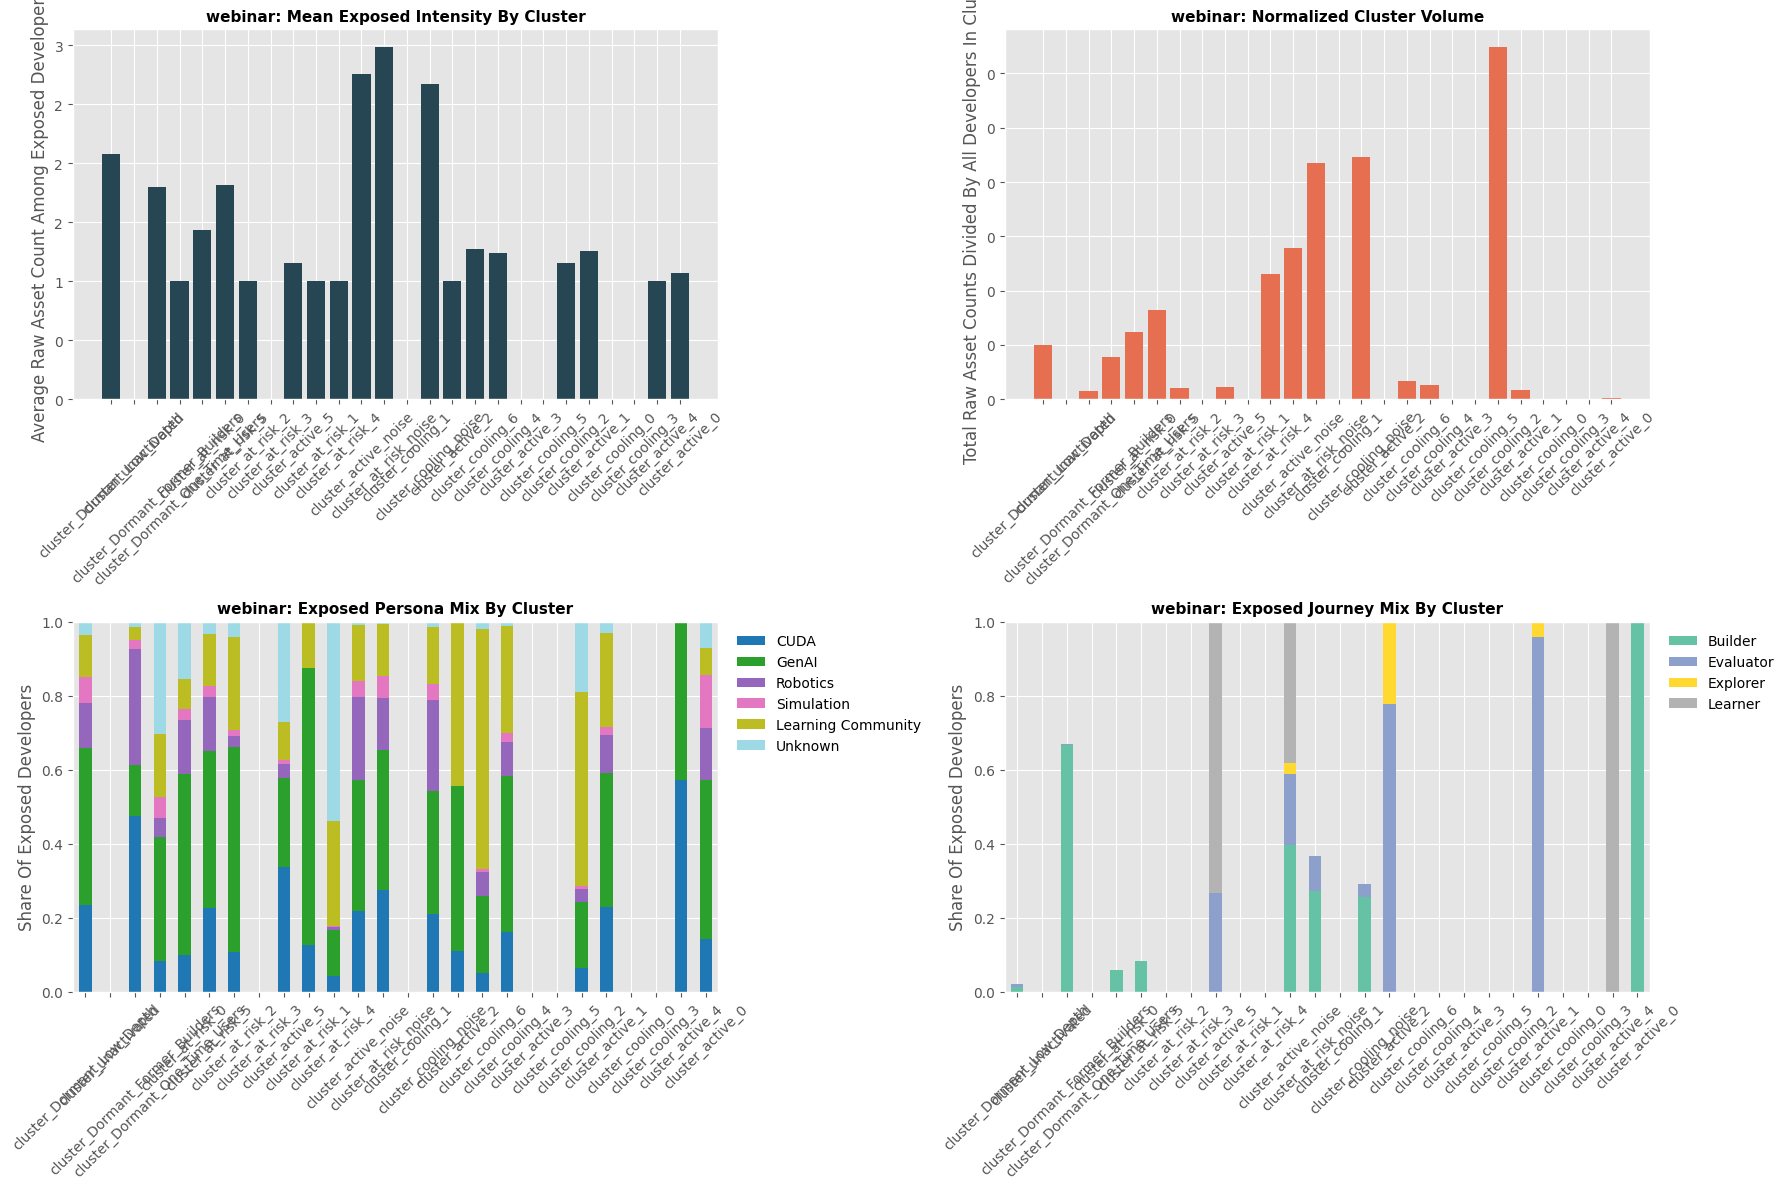

### Asset View: `forum_contribution`

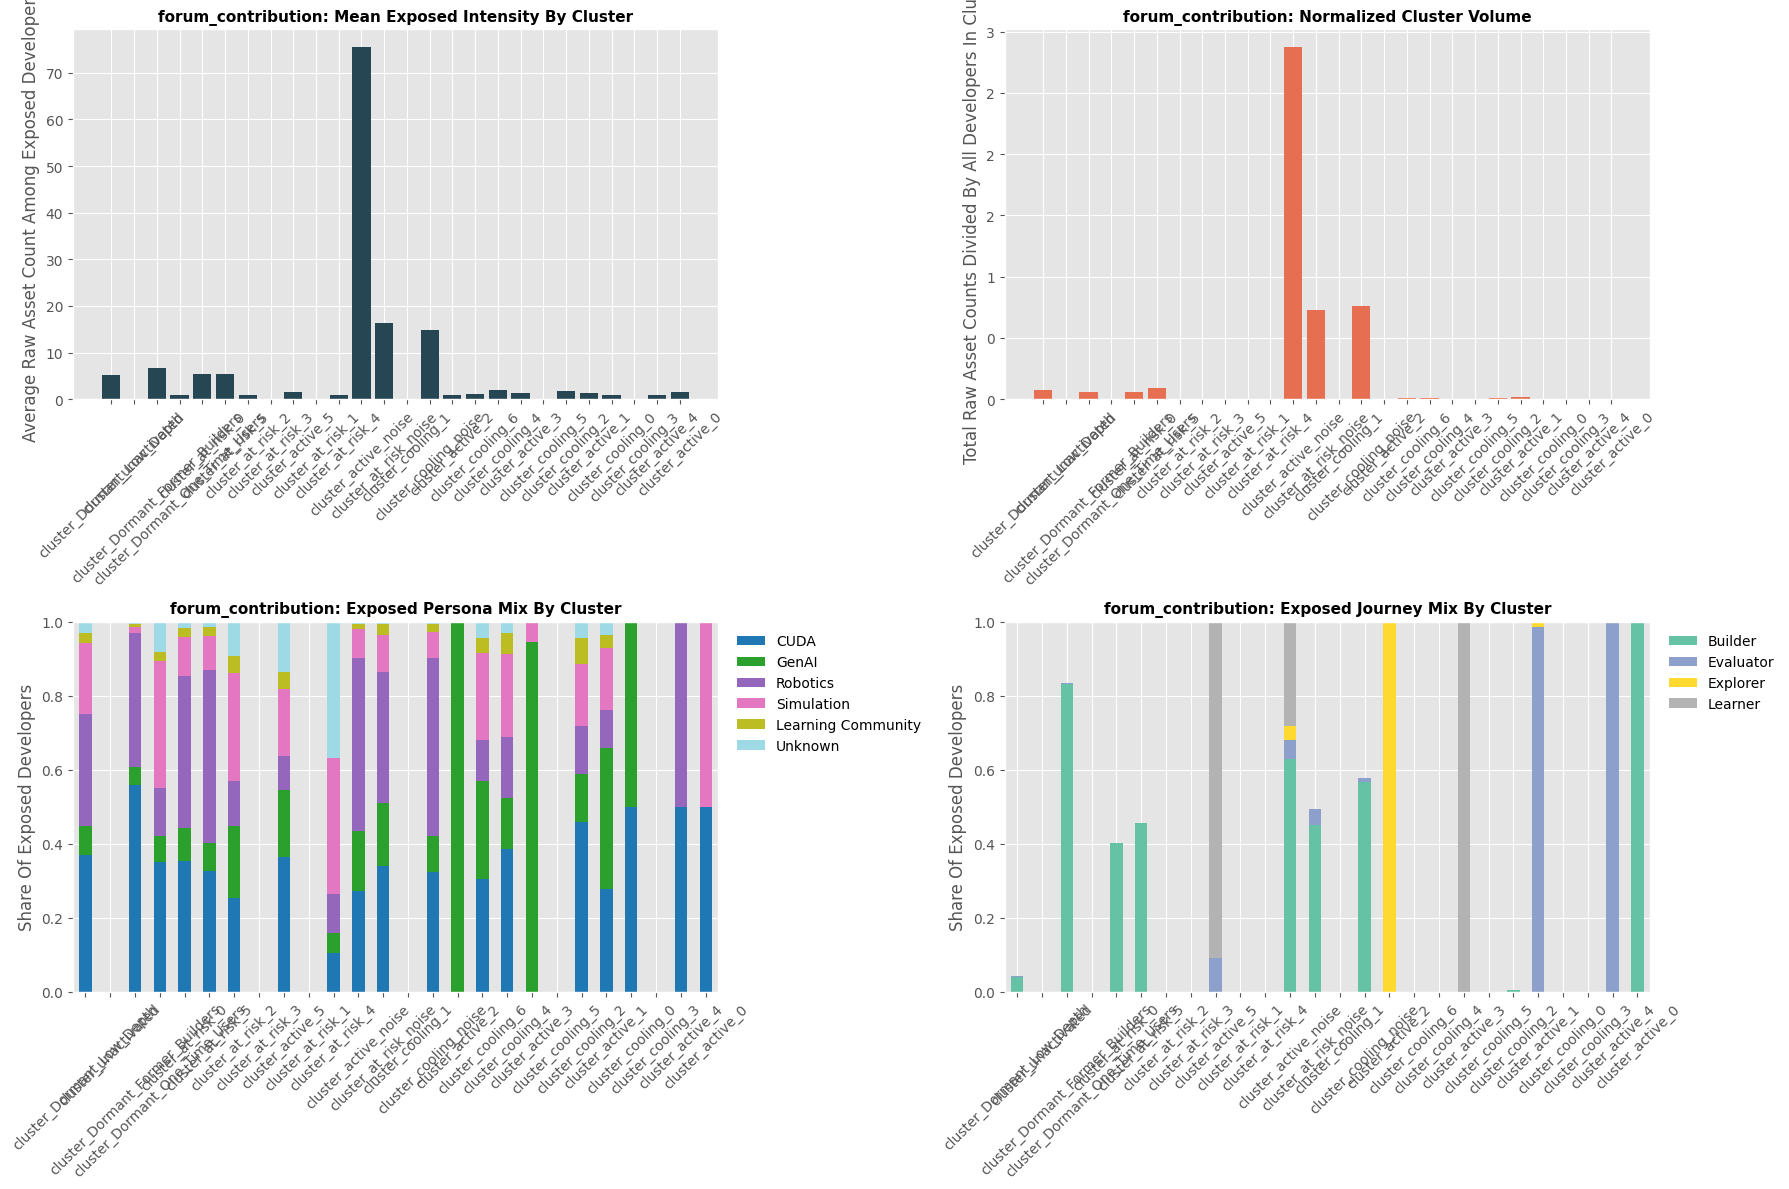

### Asset View: `hackathon`

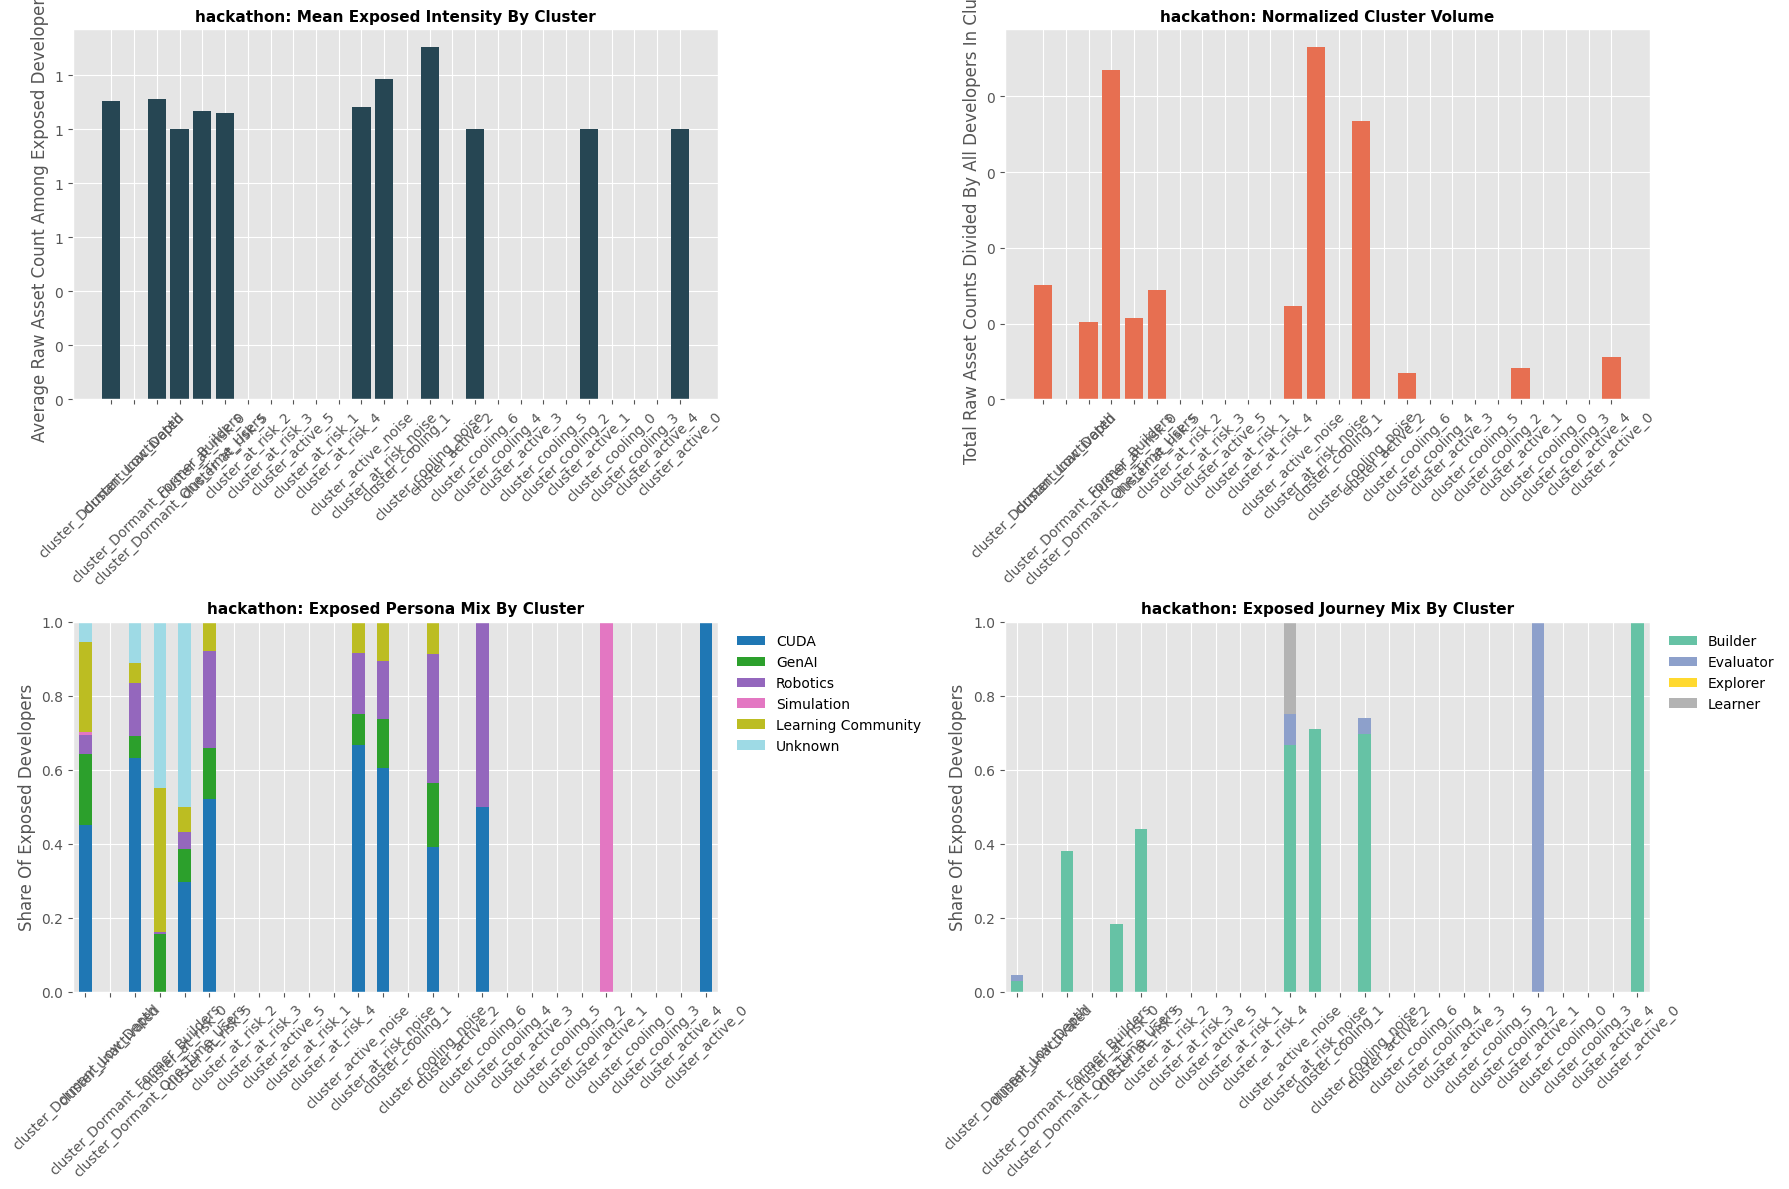

### Asset View: `devzone_download`

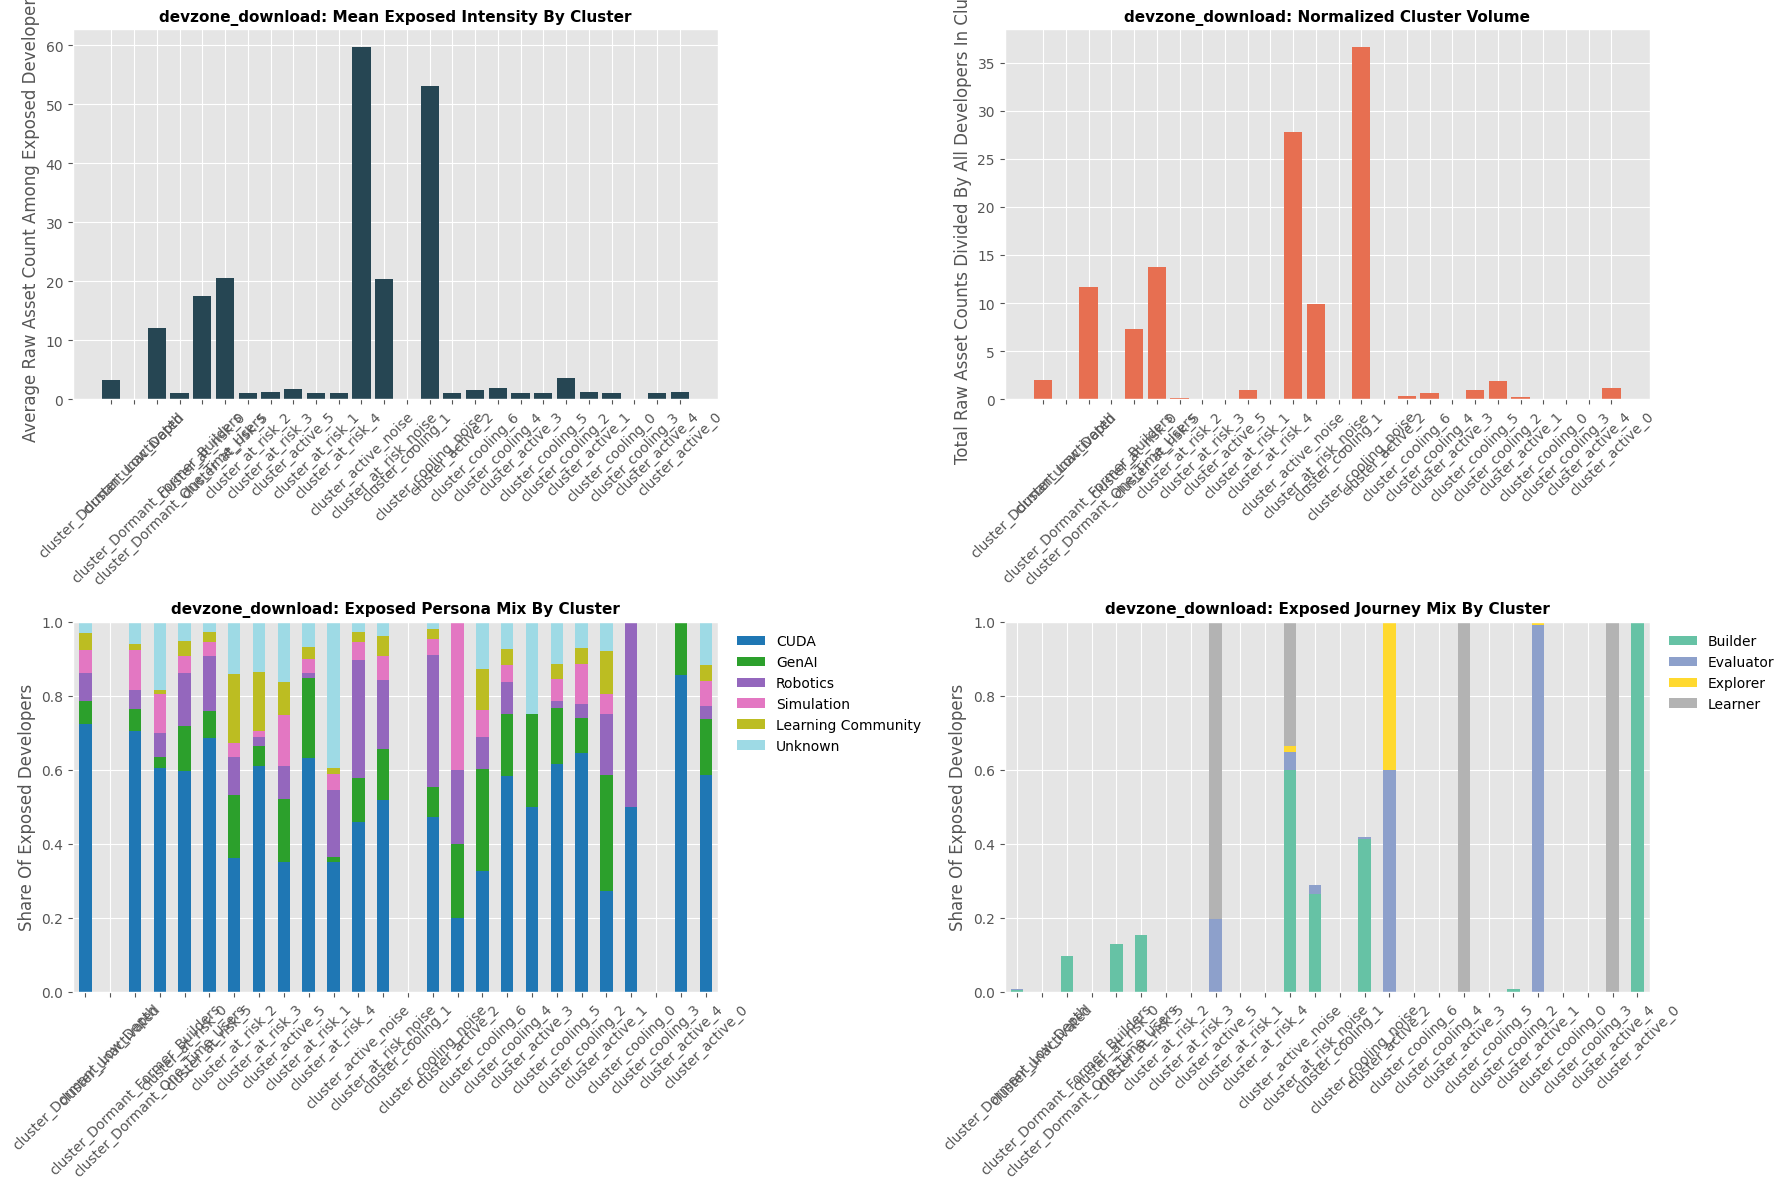

### Asset View: `ngc_download`

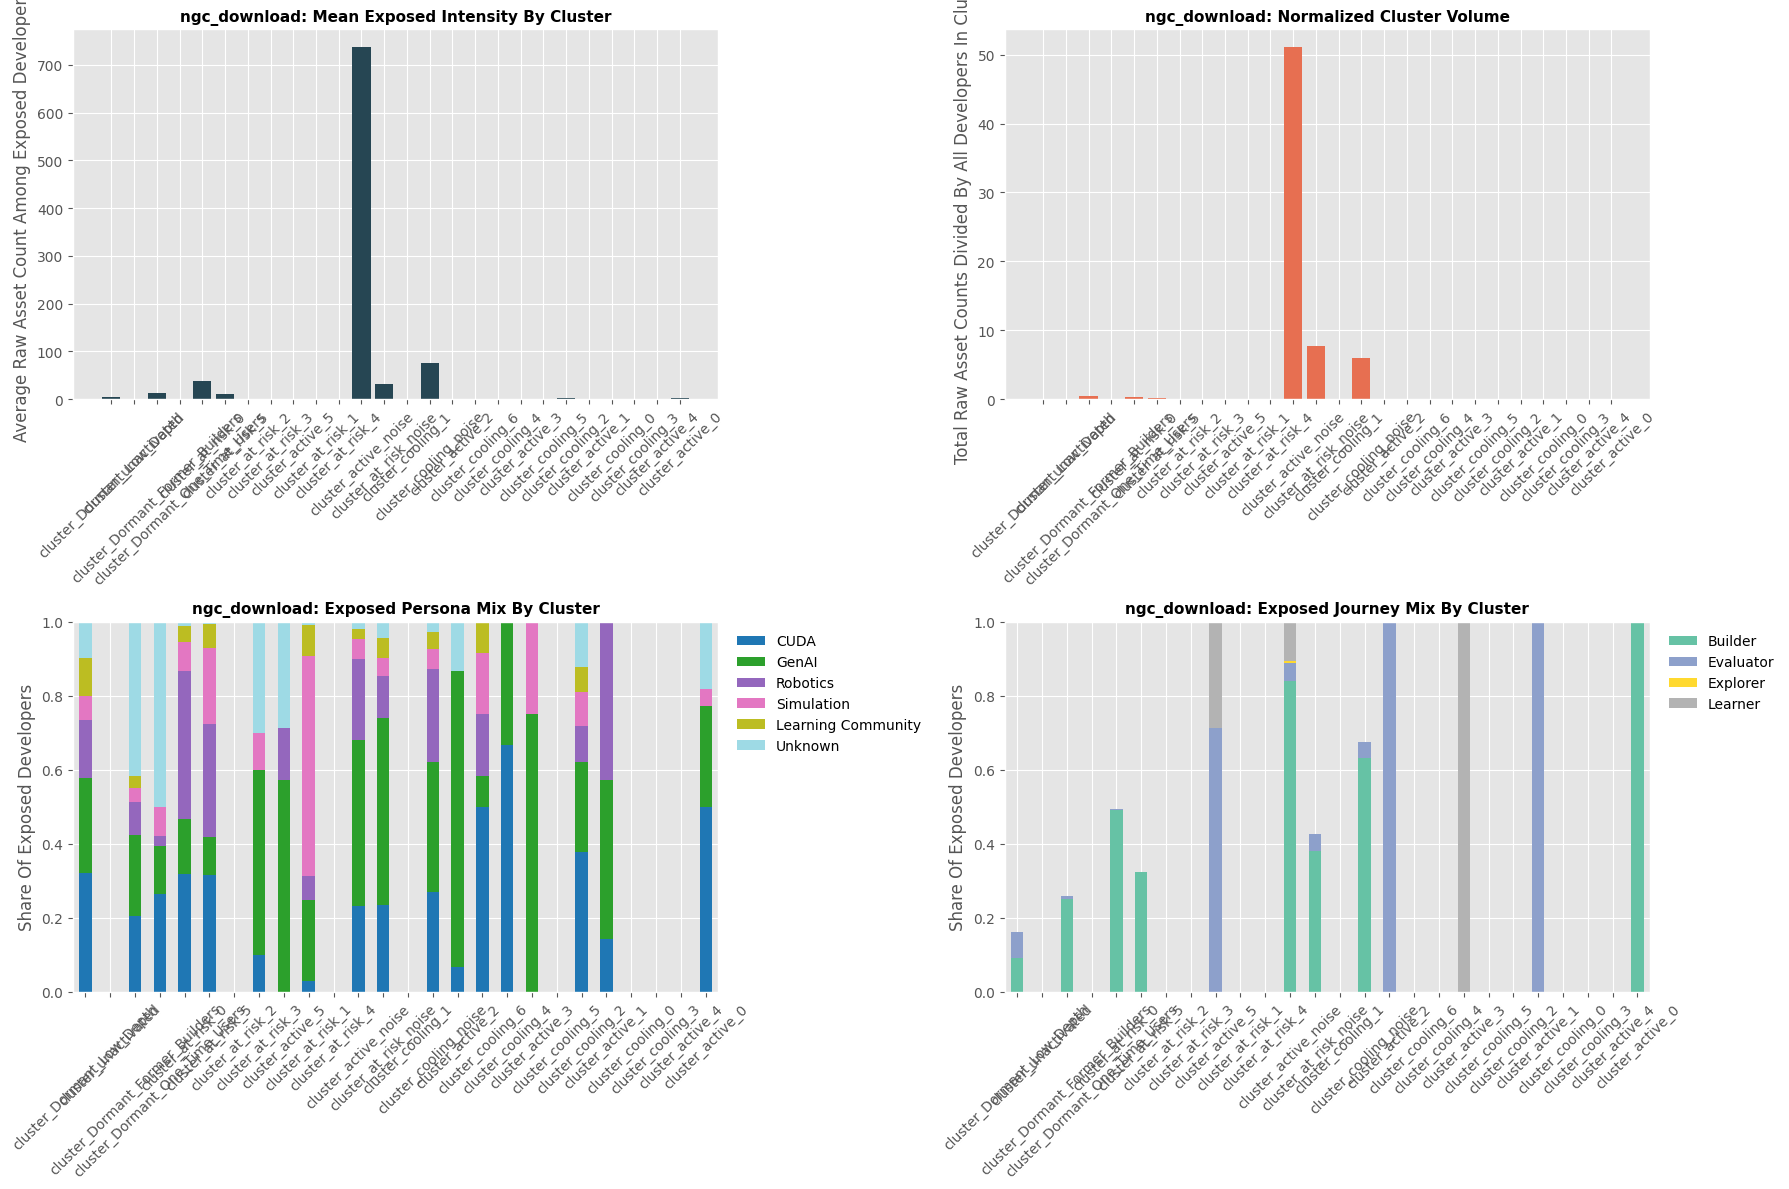

### Asset View: `bug_filed`

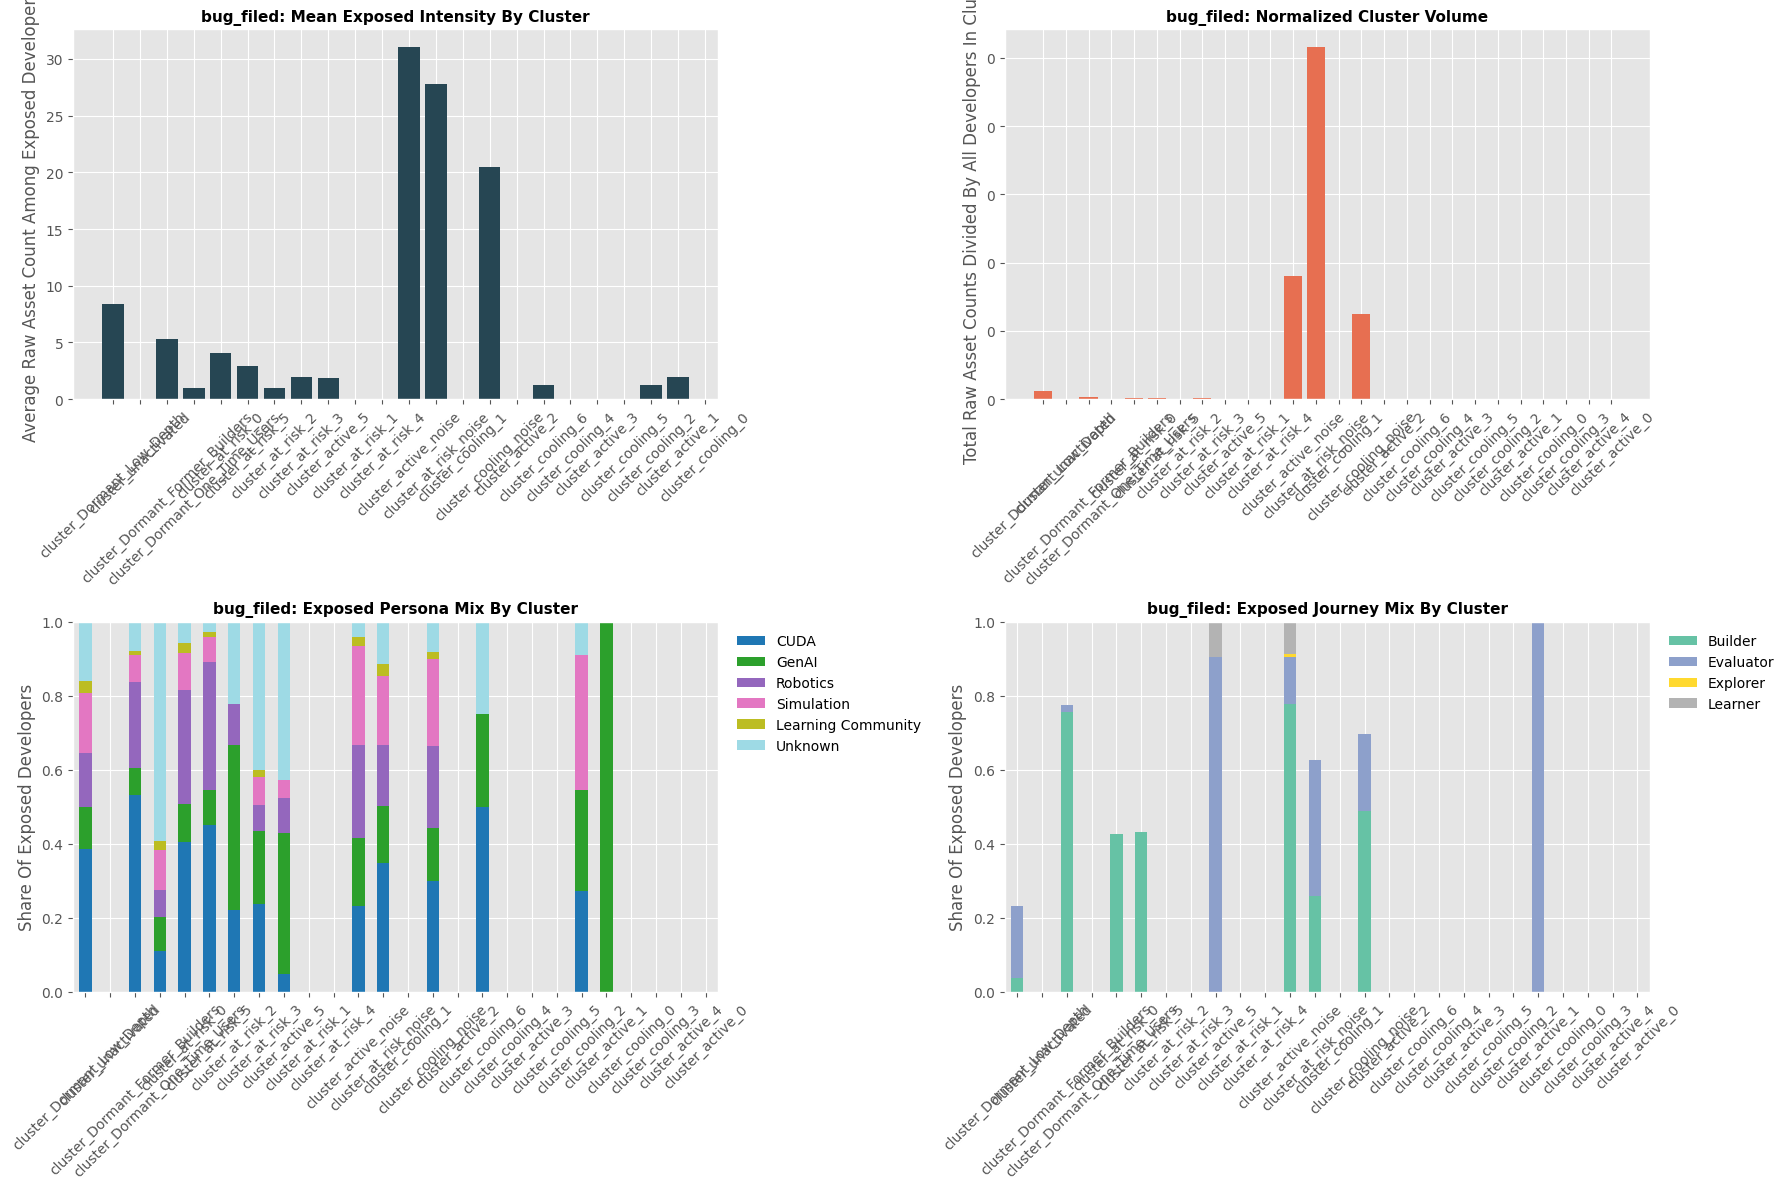

In [13]:
from matplotlib.ticker import StrMethodFormatter, PercentFormatter
import matplotlib.cm as cm
import numpy as np

cluster_order_df = con.execute(f"SELECT cluster_label, developers FROM {CLUSTER_ASSET_SUMMARY_TABLE} ORDER BY developers DESC").fetchdf()
cluster_order = cluster_order_df['cluster_label'].tolist()
cluster_sizes = dict(zip(cluster_order_df['cluster_label'], cluster_order_df['developers']))

summary_df = con.execute(f"SELECT * FROM {CLUSTER_ASSET_SUMMARY_TABLE}").fetchdf()
intensity_df = con.execute(f"SELECT * FROM {CLUSTER_ASSET_INTENSITY_TABLE}").fetchdf()
profile_df = con.execute(f"SELECT * FROM {CLUSTER_ASSET_EXPOSED_PROFILE_TABLE}").fetchdf()
priority_df = con.execute(f"SELECT * FROM {CLUSTER_ASSET_PRIORITY_TABLE}").fetchdf()
persona_cluster_df = con.execute(f"SELECT * FROM {CLUSTER_PERSONA_PROFILE_TABLE}").fetchdf()
journey_cluster_df = con.execute(f"SELECT * FROM {CLUSTER_JOURNEY_PROFILE_TABLE}").fetchdf()
journey_state_cluster_df = con.execute(f"SELECT * FROM {CLUSTER_JOURNEY_STATE_PROFILE_TABLE}").fetchdf()
lifecycle_cluster_df = con.execute(f"SELECT * FROM {CLUSTER_LIFECYCLE_PROFILE_TABLE}").fetchdf()
dormancy_cluster_df = con.execute(f"SELECT * FROM {CLUSTER_DORMANCY_PROFILE_TABLE}").fetchdf()
effort_cluster_df = con.execute(f"SELECT * FROM {CLUSTER_EFFORT_PROFILE_TABLE}").fetchdf()

for df in [summary_df, intensity_df, profile_df, priority_df,
           persona_cluster_df, journey_cluster_df, journey_state_cluster_df, lifecycle_cluster_df,
           dormancy_cluster_df, effort_cluster_df]:
    df['cluster_label'] = pd.Categorical(df['cluster_label'], categories=cluster_order, ordered=True)

def finish_axes(ax, title, xlabel='', ylabel=''):
    ax.set_title(title, fontsize=11, weight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

def apply_plain_number_format(ax, axis='x'):
    fmt = StrMethodFormatter('{x:,.0f}')
    if axis == 'x':
        ax.xaxis.set_major_formatter(fmt)
    else:
        ax.yaxis.set_major_formatter(fmt)

# ============================================================
# Build a stable color map per share dimension so categories
# get the same color in every cluster
# ============================================================
def build_category_color_map(df, bucket_col, cmap_name):
    categories = sorted(df[bucket_col].dropna().unique().tolist())
    cmap = cm.get_cmap(cmap_name, max(len(categories), 1))
    return {cat: cmap(i) for i, cat in enumerate(categories)}, categories

persona_colors, persona_categories = build_category_color_map(persona_cluster_df, 'persona_bucket', 'tab20')
journey_colors, journey_categories = build_category_color_map(journey_cluster_df, 'journey_bucket', 'Set2')
journey_state_colors, journey_state_categories = build_category_color_map(journey_state_cluster_df, 'journey_state_bucket', 'Set3')
lifecycle_colors, lifecycle_categories = build_category_color_map(lifecycle_cluster_df, 'lifecycle_bucket', 'tab20b')
dormancy_colors, dormancy_categories = build_category_color_map(dormancy_cluster_df, 'dormancy_bucket', 'Paired')
effort_colors, effort_categories = build_category_color_map(effort_cluster_df, 'effort_bucket', 'Accent')

def plot_share_panel(ax, df, bucket_col, title, color_map, categories, cluster):
    pivot = df.pivot(index='cluster_label', columns=bucket_col, values='pct_within_cluster').fillna(0)
    # Reindex columns to the full category list so colors and order stay consistent
    pivot = pivot.reindex(columns=categories, fill_value=0)
    if cluster in pivot.index:
        row = pivot.loc[[cluster]]
        colors = [color_map[c] for c in categories]
        row.plot(kind='barh', stacked=True, ax=ax, color=colors, width=0.6, legend=False)
        ax.set_yticks([])
        ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0 if row.values.max() <= 1.0 else 100))
        finish_axes(ax, title, xlabel='Share Of Developers In Cluster')
        ax.legend(categories, loc='center left', bbox_to_anchor=(1.01, 0.5),
                  frameon=False, fontsize=7, ncol=1)
    else:
        ax.axis('off')
        ax.set_title(title, fontsize=11, weight='bold')

# ============================================================
# PART 1: CLUSTER-BY-CLUSTER SECTIONS
# ============================================================
display(Markdown('## Cluster-By-Cluster Breakdown'))

for cluster in cluster_order:
    size = cluster_sizes.get(cluster, 0)
    display(Markdown(f'### Cluster: `{cluster}` ({size:,} developers)'))

    fig = plt.figure(figsize=(20, 22))
    gs = fig.add_gridspec(4, 3, hspace=0.9, wspace=0.55,
                          left=0.05, right=0.82, top=0.96, bottom=0.04)

    # Row 0: persona (wide), journey stage
    ax_persona = fig.add_subplot(gs[0, 0:2])
    plot_share_panel(ax_persona, persona_cluster_df, 'persona_bucket',
                     'Persona Share', persona_colors, persona_categories, cluster)

    ax_journey = fig.add_subplot(gs[0, 2])
    plot_share_panel(ax_journey, journey_cluster_df, 'journey_bucket',
                     'Journey Stage Share', journey_colors, journey_categories, cluster)

    # Row 1: journey state, lifecycle, dormancy
    ax_journey_state = fig.add_subplot(gs[1, 0])
    plot_share_panel(ax_journey_state, journey_state_cluster_df, 'journey_state_bucket',
                     'Current Journey State Share', journey_state_colors, journey_state_categories, cluster)

    ax_lifecycle = fig.add_subplot(gs[1, 1])
    plot_share_panel(ax_lifecycle, lifecycle_cluster_df, 'lifecycle_bucket',
                     'Final Lifecycle Status Share', lifecycle_colors, lifecycle_categories, cluster)

    ax_dormancy = fig.add_subplot(gs[1, 2])
    plot_share_panel(ax_dormancy, dormancy_cluster_df, 'dormancy_bucket',
                     'Dormancy Share', dormancy_colors, dormancy_categories, cluster)

    # Row 2: effort, full width
    ax_effort = fig.add_subplot(gs[2, :])
    plot_share_panel(ax_effort, effort_cluster_df, 'effort_bucket',
                     'Effort Level Share', effort_colors, effort_categories, cluster)

    # Row 3: top assets by normalized volume, breadth, intensity
    ax_vol = fig.add_subplot(gs[3, 0])
    vol_df = priority_df[(priority_df['cluster_label'].astype(str) == cluster) &
                         (priority_df['rank_by_total_volume'] <= 5)
                         ].sort_values('asset_volume_per_cluster_developer', ascending=True)
    if not vol_df.empty:
        ax_vol.barh(vol_df['asset_name'], vol_df['asset_volume_per_cluster_developer'], color='#2a9d8f')
        apply_plain_number_format(ax_vol, axis='x')
        finish_axes(ax_vol, 'Top Assets By Normalized Volume',
                    xlabel='Activity Counts Per Cluster Developer')
    else:
        ax_vol.axis('off')
        ax_vol.set_title('Top Assets By Normalized Volume', fontsize=11, weight='bold')

    ax_breadth = fig.add_subplot(gs[3, 1])
    breadth_df = priority_df[(priority_df['cluster_label'].astype(str) == cluster) &
                             (priority_df['rank_by_breadth'] <= 5)
                             ].sort_values('exposure_rate', ascending=True)
    if not breadth_df.empty:
        ax_breadth.barh(breadth_df['asset_name'], breadth_df['exposure_rate'], color='#577590')
        ax_breadth.xaxis.set_major_formatter(
            PercentFormatter(xmax=1.0 if breadth_df['exposure_rate'].max() <= 1.0 else 100))
        finish_axes(ax_breadth, 'Top Assets By Breadth',
                    xlabel='Share Of Developers With >0 Usage')
    else:
        ax_breadth.axis('off')
        ax_breadth.set_title('Top Assets By Breadth', fontsize=11, weight='bold')

    ax_int = fig.add_subplot(gs[3, 2])
    int_df = priority_df[(priority_df['cluster_label'].astype(str) == cluster) &
                         (priority_df['rank_by_intensity'] <= 5)
                         ].sort_values('avg_exposure_value_exposed', ascending=True)
    if not int_df.empty:
        ax_int.barh(int_df['asset_name'], int_df['avg_exposure_value_exposed'], color='#f3722c')
        apply_plain_number_format(ax_int, axis='x')
        finish_axes(ax_int, 'Top Assets By Intensity',
                    xlabel='Avg Asset Count Among Exposed')
    else:
        ax_int.axis('off')
        ax_int.set_title('Top Assets By Intensity', fontsize=11, weight='bold')

    fig.suptitle(f'Cluster {cluster} — Composition And Top Activity Assets',
                 fontsize=14, weight='bold', y=0.985)
    plt.show()

# ============================================================
# PART 2: AGGREGATE / OVERVIEW
# ============================================================
display(Markdown('## Aggregate Overview Across Clusters'))

display(Markdown('### Cluster-Level Activity And Exposure Overview'))
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
overview_specs = [
    ('avg_rankable_activity_assets_exposed', 'Average Rankable Activity Assets Exposed'),
    ('avg_behavior_descriptors_active', 'Average Behavior Descriptors Active'),
    ('avg_activity_count_0_30d', 'Average Activity Count 0-30d'),
    ('avg_activity_count_30_90d', 'Average Activity Count 30-90d')
]
for ax, (col, title) in zip(axes.flatten(), overview_specs):
    plot_df = summary_df.sort_values('cluster_label')
    ax.bar(plot_df['cluster_label'].astype(str), plot_df[col], color='#1f77b4')
    apply_plain_number_format(ax, axis='y')
    finish_axes(ax, title, ylabel='Value')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

for label, df, bucket_col, color_map, categories in [
    ('Persona Share By Cluster', persona_cluster_df, 'persona_bucket', persona_colors, persona_categories),
    ('Journey Stage Share By Cluster', journey_cluster_df, 'journey_bucket', journey_colors, journey_categories),
    ('Current Journey State Share By Cluster', journey_state_cluster_df, 'journey_state_bucket', journey_state_colors, journey_state_categories),
    ('Final Lifecycle Status Share By Cluster', lifecycle_cluster_df, 'lifecycle_bucket', lifecycle_colors, lifecycle_categories),
    ('Dormancy Share By Cluster', dormancy_cluster_df, 'dormancy_bucket', dormancy_colors, dormancy_categories),
    ('Effort Level Share By Cluster', effort_cluster_df, 'effort_bucket', effort_colors, effort_categories),
]:
    display(Markdown(f'### {label}'))
    pivot = df.pivot(index='cluster_label', columns=bucket_col, values='pct_within_cluster').fillna(0).sort_index()
    pivot = pivot.reindex(columns=categories, fill_value=0)
    colors = [color_map[c] for c in categories]
    fig, ax = plt.subplots(figsize=(16, 7))
    pivot.plot(kind='bar', stacked=True, ax=ax, color=colors)
    finish_axes(ax, label, ylabel='Share Of Developers In Cluster')
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0 if pivot.values.max() <= 1.0 else 100))
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False, title=bucket_col.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

# ============================================================
# PART 3: PER-ASSET VIEWS
# ============================================================
display(Markdown('## Per-Asset Views'))

asset_plot_df = intensity_df[intensity_df['analysis_role'] == 'rankable_activity_asset'].copy()
asset_names = asset_plot_df['asset_name'].drop_duplicates().tolist()

persona_cols = [
    ('pct_cuda', 'CUDA'),
    ('pct_genai', 'GenAI'),
    ('pct_robotics', 'Robotics'),
    ('pct_simulation', 'Simulation'),
    ('pct_learning_community', 'Learning Community'),
    ('pct_unknown_persona', 'Unknown')
]
journey_cols = [
    ('pct_builder', 'Builder'),
    ('pct_evaluator', 'Evaluator'),
    ('pct_explorer', 'Explorer'),
    ('pct_learner', 'Learner')
]

# Stable colors for the per-asset persona/journey panels
asset_persona_labels = [label for _, label in persona_cols]
asset_journey_labels = [label for _, label in journey_cols]
asset_persona_cmap = cm.get_cmap('tab20', len(asset_persona_labels))
asset_journey_cmap = cm.get_cmap('Set2', len(asset_journey_labels))
asset_persona_colors = [asset_persona_cmap(i) for i in range(len(asset_persona_labels))]
asset_journey_colors = [asset_journey_cmap(i) for i in range(len(asset_journey_labels))]

for asset_name in asset_names:
    intensity_asset = asset_plot_df[asset_plot_df['asset_name'] == asset_name].sort_values('cluster_label')
    profile_asset = profile_df[(profile_df['asset_name'] == asset_name) &
                               (profile_df['analysis_role'] == 'rankable_activity_asset')].sort_values('cluster_label')
    if intensity_asset.empty or profile_asset.empty:
        continue

    display(Markdown(f'### Asset View: `{asset_name}`'))
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    axes[0, 0].bar(intensity_asset['cluster_label'].astype(str), intensity_asset['avg_exposure_value_exposed'], color='#264653')
    apply_plain_number_format(axes[0, 0], axis='y')
    finish_axes(axes[0, 0], f'{asset_name}: Mean Exposed Intensity By Cluster',
                ylabel='Average Raw Asset Count Among Exposed Developers')
    axes[0, 0].tick_params(axis='x', rotation=45)

    axes[0, 1].bar(intensity_asset['cluster_label'].astype(str), intensity_asset['asset_volume_per_cluster_developer'], color='#e76f51')
    apply_plain_number_format(axes[0, 1], axis='y')
    finish_axes(axes[0, 1], f'{asset_name}: Normalized Cluster Volume',
                ylabel='Total Raw Asset Counts Divided By All Developers In Cluster')
    axes[0, 1].tick_params(axis='x', rotation=45)

    persona_plot = profile_asset[['cluster_label'] + [c for c, _ in persona_cols]].copy().set_index('cluster_label')
    persona_plot.columns = asset_persona_labels
    persona_plot.plot(kind='bar', stacked=True, ax=axes[1, 0], color=asset_persona_colors)
    finish_axes(axes[1, 0], f'{asset_name}: Exposed Persona Mix By Cluster',
                ylabel='Share Of Exposed Developers')
    axes[1, 0].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False)
    axes[1, 0].tick_params(axis='x', rotation=45)

    journey_plot = profile_asset[['cluster_label'] + [c for c, _ in journey_cols]].copy().set_index('cluster_label')
    journey_plot.columns = asset_journey_labels
    journey_plot.plot(kind='bar', stacked=True, ax=axes[1, 1], color=asset_journey_colors)
    finish_axes(axes[1, 1], f'{asset_name}: Exposed Journey Mix By Cluster',
                ylabel='Share Of Exposed Developers')
    axes[1, 1].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False)
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

In [14]:
con.close()